# 正常的轨迹可视化

In [2]:
from agents.algorithm.ppo    import PPO
from agents.algorithm.sac    import SAC
from agents.algorithm.ddpg    import DDPG
from agents.agent            import Agent

from discriminators.gail     import GAIL
from discriminators.vail     import VAIL
from discriminators.airl     import AIRL
from discriminators.vairl    import VAIRL
from discriminators.eairl    import EAIRL
from discriminators.sqil    import SQIL
from utils.utils             import RunningMeanStd, Dict, make_transition

from configparser            import ConfigParser
from argparse                import ArgumentParser

import os
from envDesign.environment import InteractionEnv
from envDesign.environmentTest import InteractionEnvForTest
import numpy as np

import torch

os.makedirs('./model_weights', exist_ok=True)
envTest = InteractionEnvForTest('/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_state_pedestrain_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_state_vehicle_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_position_pedestrain_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_position_vehicle_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_done_group_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_num_pedestrain_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_num_vehicle_train.npy')

print('测试环境读取完成')

action_dim = envTest.action_dim
state_dim = envTest.state_dim
parser = ArgumentParser('parameters')


parser.add_argument('--test', type=bool, default=False, help="True if test, False if train (default: False)")
parser.add_argument('--render', type=bool, default=False, help="(default: False)")
parser.add_argument('--epochs', type=int, default=1001, help='number of epochs, (default: 1001)')
parser.add_argument("--agent", type=str, default = 'sac', help = 'actor training algorithm(default: ppo)')
parser.add_argument("--discriminator", type=str, default = 'airl', help = 'discriminator training algorithm(default: gail)')
parser.add_argument("--save_interval", type=int, default = 100, help = 'save interval')
parser.add_argument("--print_interval", type=int, default = 1, help = 'print interval')
parser.add_argument('--tensorboard', type=bool, default=False, help='use_tensorboard, (default: True)')

args = parser.parse_args(args=[])
parser = ConfigParser()
parser.read('config.ini')

torch.manual_seed(0)
np.random.seed(0)

demonstrations_location_args = Dict(parser,'demonstrations_location',True)
agent_args = Dict(parser,args.agent)
discriminator_args = Dict(parser,args.discriminator)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if args.tensorboard:
    from torch.utils.tensorboard import SummaryWriter

    writer = SummaryWriter('runs')
else:
    writer = None

if args.discriminator == 'airl':
    discriminator = AIRL(writer, device, state_dim, action_dim, discriminator_args)

elif args.discriminator == 'vairl':
    discriminator = VAIRL(writer, device, state_dim, action_dim, discriminator_args)
elif args.discriminator == 'gail':
    discriminator = GAIL(writer, device, state_dim, action_dim, discriminator_args)
elif args.discriminator == 'vail':
    discriminator = VAIL(writer, device, state_dim, action_dim, discriminator_args)
elif args.discriminator == 'eairl':
    discriminator = EAIRL(writer, device, state_dim, action_dim, discriminator_args)
elif args.discriminator == 'sqil':
    discriminator = SQIL(writer, device, state_dim, action_dim, discriminator_args)
else:
    raise NotImplementedError

print('逆强化学习构建完成')
max_action = 5
if args.agent == 'ppo':
    algorithm = PPO(device, state_dim, action_dim, agent_args)
elif args.agent == 'sac':
    algorithm = SAC(device, state_dim, action_dim, agent_args)
    algorithm_nongame = SAC(device, state_dim, action_dim, agent_args)
elif args.agent == 'ddpg':
    algorithm = DDPG(state_dim, action_dim, max_action)
else:
    raise NotImplementedError
print('强化学习构建完成')

agent = Agent(algorithm, writer, device, state_dim, action_dim, agent_args, demonstrations_location_args)
agent_nongame = Agent(algorithm_nongame, writer, device, state_dim, action_dim, agent_args, demonstrations_location_args)
print('智能体构建完成')
if device == 'cuda':
    agent = agent.cuda()
    agent_nongame = agent_nongame.cuda()
    discriminator = discriminator.cuda()


discriminator.load('./model_weights/[0.7570072946452949, 0.7416145066491182, 0.5701982544919296, 0.5663083209622656, 1.1435990703512442, 1.2926992029237097, 0.7015418705263115, 0.7071762430926871, 80]')
agent.brain.load('./model_weights/[0.7570072946452949, 0.7416145066491182, 0.5701982544919296, 0.5663083209622656, 1.1435990703512442, 1.2926992029237097, 0.7015418705263115, 0.7071762430926871, 80]')
agent_nongame.brain.load('./model_weights_without_game/[0.9552461267411442, 0.9015960633741323, 0.5702812053631935, 0.556503415511401, 1.6406708829874004, 1.288006816960458, 0.7332928976593167, 0.6902695518913933, 90]')

print('参数读取完成')





ls_tra_mae = []
ls_speed_mae = []
ls_tra_hd = []
ls_speed_hd = []
ls_real_tra = []
ls_predicted_tra = []
ls_real_speed = []
ls_predicted_speed = []
for i in range(envTest.env_state_pedestrain.shape[0]):
    state_flat_test, all_state_test = envTest.reset()
    doneTest = False
    while not doneTest:
        action, log_prob = agent.get_action(torch.from_numpy(envTest.state).float().to(device))
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]

        tra_mae, speed_mae, tra_hd, speed_hd, doneTest, real_tra, predicted_tra, real_speed, predicted_speed = envTest.step_for_analysis(action)
    ls_tra_mae.append(tra_mae)
    ls_speed_mae.append(speed_mae)
    ls_tra_hd.append(tra_hd)
    ls_speed_hd.append(speed_hd)
    ls_real_tra.append(real_tra)
    ls_predicted_tra.append(predicted_tra)
    ls_real_speed.append(real_speed)
    ls_predicted_speed.append(predicted_speed)

ls_predicted_tra_without_game = []
ls_predicted_speed_without_game = []
for i in range(envTest.env_state_pedestrain.shape[0]):
    state_flat_test, all_state_test = envTest.reset()
    doneTest = False
    while not doneTest:
        action, log_prob = agent_nongame.get_action(torch.from_numpy(envTest.state).float().to(device))
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]

        tra_mae, speed_mae, tra_hd, speed_hd, doneTest, real_tra, predicted_tra, real_speed, predicted_speed = envTest.step_for_analysis(action)
    ls_predicted_tra_without_game.append(predicted_tra)
    ls_predicted_speed_without_game.append(predicted_speed)

tra_mae = np.array(ls_tra_mae)
speed_mae = np.array(ls_speed_mae)
tra_hd = np.array(ls_tra_hd)
speed_hd = np.array(ls_speed_hd)
tra_mae = np.mean(tra_mae, axis=0)
speed_mae = np.mean(speed_mae, axis=0)
tra_hd = np.mean(tra_hd, axis=0)
speed_hd = np.mean(speed_hd, axis=0)

print(f'P_X_MAE:{tra_mae[0]}; P_Y_MAE:{tra_mae[1]}')
print(f'V_X_MAE:{speed_mae[0]}; V_Y_MAE:{speed_mae[1]}')
print(f'P_X_HD:{tra_hd[0]}; P_Y_HD:{tra_hd[1]}')
print(f'V_X_HD:{speed_hd[0]}; V_Y_HD:{speed_hd[1]}')

测试环境读取完成
逆强化学习构建完成
强化学习构建完成
智能体构建完成
参数读取完成


/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environmentTest.py:92: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_1278226/2281622907.py:131: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]
/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environmentTes

P_X_MAE:0.7620778119735424; P_Y_MAE:0.7143743150422937
V_X_MAE:0.5677283869677033; V_Y_MAE:0.5517036248032962
P_X_HD:1.1583693472793668; P_Y_HD:1.2549757673013553
V_X_HD:0.7030806714334028; V_Y_HD:0.694249155687551


In [3]:
import pandas as pd

In [4]:
dt_tra_mae = pd.DataFrame(np.concatenate(ls_tra_mae,axis=0).reshape(-1,2),columns=['P_X_MAE','P_Y_MAE'])
dt_speed_mae = pd.DataFrame(np.concatenate(ls_speed_mae,axis=0).reshape(-1,2),columns=['V_X_MAE','V_Y_MAE'])
dt_mae = pd.concat([dt_tra_mae,dt_speed_mae],axis=1)
dt_mae['mean'] = dt_mae.mean(axis=1)
dt_mae[dt_mae['mean']<0.2].sort_values(by='mean')

,P_X_MAE,P_Y_MAE,V_X_MAE,V_Y_MAE,mean
1,0.044029,0.057129,0.060621,0.078674,0.060113
140,0.030948,0.030310,0.072362,0.125774,0.064849
87,0.036785,0.023204,0.137221,0.064272,0.065371
158,0.015467,0.022651,0.103506,0.126978,0.067150
267,0.102978,0.029602,0.088178,0.077427,0.074546
...,...,...,...,...,...
303,0.185203,0.053567,0.213302,0.334823,0.196724
354,0.010573,0.219296,0.093349,0.468803,0.198005
398,0.067506,0.253801,0.148070,0.323148,0.198131
353,0.051524,0.189878,0.426785,0.126322,0.198627


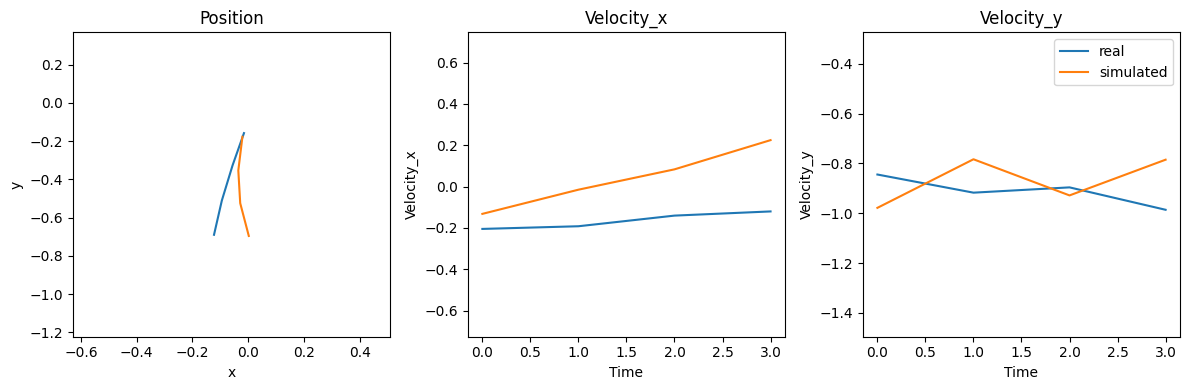

In [5]:
import matplotlib.pyplot as plt

# 假设 pedestrian_position, pedestrian_velocity, pedestrian_acceleration 是已经定义的变量
# pedestrian_position = ...
# pedestrian_velocity = ...
# pedestrian_acceleration = ...

# 创建一个 fig 和 ax 对象
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

scene = 164
# 绘制位置数据
axs[0].plot(ls_real_tra[scene][:,0],ls_real_tra[scene][:,1],label='real')
axs[0].plot(ls_predicted_tra[scene][:,0],ls_predicted_tra[scene][:,1],label='simulated')
axs[0].set_title('Position')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_xlim(axs[0].get_xlim()[0]-0.5,axs[0].get_xlim()[1]+0.5)
axs[0].set_ylim(axs[0].get_ylim()[0]-0.5,axs[0].get_ylim()[1]+0.5)

# 绘制速度数据
axs[1].plot(ls_real_speed[scene][:,0],label='real')
axs[1].plot(ls_predicted_speed[scene][:,0],label='simulated')
axs[1].set_title('Velocity_x')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Velocity_x')
axs[1].set_ylim(axs[1].get_ylim()[0]-0.5,axs[1].get_ylim()[1]+0.5)

# 绘制加速度数据
axs[2].plot(ls_real_speed[scene][:,1],label='real')
axs[2].plot(ls_predicted_speed[scene][:,1],label='simulated')
axs[2].set_title('Velocity_y')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Velocity_y')
axs[2].set_ylim(axs[2].get_ylim()[0]-0.5,axs[2].get_ylim()[1]+0.5)
# 调整布局
plt.legend()
plt.tight_layout()

# 显示图像
plt.show()

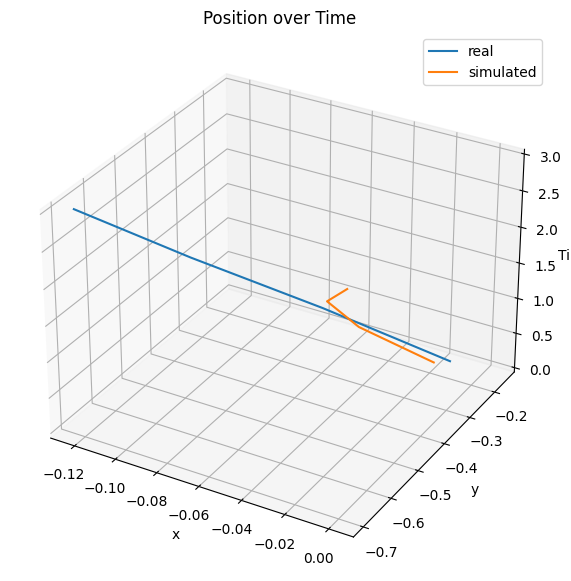

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 假设 env_position_pedestrain1 和 env_position_vehicle1 是已经定义的变量
# env_position_pedestrain1 = ...
# env_position_vehicle1 = ...

# 创建一个 fig 和 ax 对象
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

time_steps = range(ls_real_tra[scene].shape[0])

# 绘制行人位置数据
ax.plot(ls_real_tra[scene][:, 0], ls_real_tra[scene][:, 1], time_steps, label='real')

# 绘制车辆位置数据
ax.plot(ls_predicted_tra[scene][:, 0], ls_predicted_tra[scene][:, 1], time_steps, label='simulated')

# 设置标题和标签
ax.set_title('Position over Time')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Time')
ax.legend()

# 显示图像
plt.show()

# 消去行人影响的轨迹可视化

In [7]:
env_state_pedestrain = np.load('/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_state_pedestrain_train.npy',allow_pickle=True)
env_state_vehicle = np.load('/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_state_vehicle_train.npy',allow_pickle=True)
env_position_pedestrain = np.load('/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_position_pedestrain_train.npy',allow_pickle=True)
env_position_vehicle = np.load('/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_position_vehicle_train.npy',allow_pickle=True)
env_done_group = np.load('/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_done_group_train.npy',allow_pickle=True)
env_num_pedestrain = np.load('/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_num_pedestrain_train.npy',allow_pickle=True)
env_num_vehicle = np.load('/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_num_vehicle_train.npy',allow_pickle=True)


In [8]:
for i in range(env_state_pedestrain.shape[0]):
    env_state_pedestrain[i][:, 1:, :] = 0
    env_position_pedestrain[i][:, 1:, :] = 0
    env_num_pedestrain[i][:] = 1

In [9]:
from agents.algorithm.ppo    import PPO
from agents.algorithm.sac    import SAC
from agents.algorithm.ddpg    import DDPG
from agents.agent            import Agent

from discriminators.gail     import GAIL
from discriminators.vail     import VAIL
from discriminators.airl     import AIRL
from discriminators.vairl    import VAIRL
from discriminators.eairl    import EAIRL
from discriminators.sqil    import SQIL
from utils.utils             import RunningMeanStd, Dict, make_transition

from configparser            import ConfigParser
from argparse                import ArgumentParser

import os
from envDesign.environment import InteractionEnv
from envDesign.environmentTest import InteractionEnvForTest
import numpy as np

import torch

os.makedirs('./model_weights', exist_ok=True)
envTest_no_peer = InteractionEnvForTest('/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_state_pedestrain_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_state_vehicle_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_position_pedestrain_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_position_vehicle_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_done_group_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_num_pedestrain_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_num_vehicle_train.npy')

envTest_no_peer.env_state_pedestrain = env_state_pedestrain
envTest_no_peer.env_position_pedestrain = env_position_pedestrain
envTest_no_peer.env_num_pedestrain = env_num_pedestrain

print('测试环境读取完成')

action_dim = envTest_no_peer.action_dim
state_dim = envTest_no_peer.state_dim
parser = ArgumentParser('parameters')


parser.add_argument('--test', type=bool, default=False, help="True if test, False if train (default: False)")
parser.add_argument('--render', type=bool, default=False, help="(default: False)")
parser.add_argument('--epochs', type=int, default=1001, help='number of epochs, (default: 1001)')
parser.add_argument("--agent", type=str, default = 'sac', help = 'actor training algorithm(default: ppo)')
parser.add_argument("--discriminator", type=str, default = 'airl', help = 'discriminator training algorithm(default: gail)')
parser.add_argument("--save_interval", type=int, default = 100, help = 'save interval')
parser.add_argument("--print_interval", type=int, default = 1, help = 'print interval')
parser.add_argument('--tensorboard', type=bool, default=False, help='use_tensorboard, (default: True)')

args = parser.parse_args(args=[])
parser = ConfigParser()
parser.read('config.ini')

torch.manual_seed(0)
np.random.seed(0)

demonstrations_location_args = Dict(parser,'demonstrations_location',True)
agent_args = Dict(parser,args.agent)
discriminator_args = Dict(parser,args.discriminator)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if args.tensorboard:
    from torch.utils.tensorboard import SummaryWriter

    writer = SummaryWriter('runs')
else:
    writer = None

if args.discriminator == 'airl':
    discriminator = AIRL(writer, device, state_dim, action_dim, discriminator_args)

elif args.discriminator == 'vairl':
    discriminator = VAIRL(writer, device, state_dim, action_dim, discriminator_args)
elif args.discriminator == 'gail':
    discriminator = GAIL(writer, device, state_dim, action_dim, discriminator_args)
elif args.discriminator == 'vail':
    discriminator = VAIL(writer, device, state_dim, action_dim, discriminator_args)
elif args.discriminator == 'eairl':
    discriminator = EAIRL(writer, device, state_dim, action_dim, discriminator_args)
elif args.discriminator == 'sqil':
    discriminator = SQIL(writer, device, state_dim, action_dim, discriminator_args)
else:
    raise NotImplementedError

print('逆强化学习构建完成')
max_action = 5
if args.agent == 'ppo':
    algorithm = PPO(device, state_dim, action_dim, agent_args)
elif args.agent == 'sac':
    algorithm = SAC(device, state_dim, action_dim, agent_args)
elif args.agent == 'ddpg':
    algorithm = DDPG(state_dim, action_dim, max_action)
else:
    raise NotImplementedError
print('强化学习构建完成')


agent = Agent(algorithm, writer, device, state_dim, action_dim, agent_args, demonstrations_location_args)
print('智能体构建完成')
if device == 'cuda':
    agent = agent.cuda()
    discriminator = discriminator.cuda()


discriminator.load('./model_weights/[0.7570072946452949, 0.7416145066491182, 0.5701982544919296, 0.5663083209622656, 1.1435990703512442, 1.2926992029237097, 0.7015418705263115, 0.7071762430926871, 80]')
agent.brain.load('./model_weights/[0.7570072946452949, 0.7416145066491182, 0.5701982544919296, 0.5663083209622656, 1.1435990703512442, 1.2926992029237097, 0.7015418705263115, 0.7071762430926871, 80]')

print('参数读取完成')




ls_tra_mae_no_peer = []
ls_speed_mae_no_peer = []
ls_tra_hd_no_peer = []
ls_speed_hd_no_peer = []
ls_real_tra_no_peer = []
ls_predicted_tra_no_peer = []
ls_real_speed_no_peer = []
ls_predicted_speed_no_peer = []
for i in range(envTest_no_peer.env_state_pedestrain.shape[0]):
    state_flat_test, all_state_test = envTest_no_peer.reset()
    doneTest = False
    while not doneTest:
        action, log_prob = agent.get_action(torch.from_numpy(envTest_no_peer.state).float().to(device))
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]

        tra_mae, speed_mae, tra_hd, speed_hd, doneTest, real_tra, predicted_tra, real_speed, predicted_speed = envTest_no_peer.step_for_analysis(action)
    ls_tra_mae_no_peer.append(tra_mae)
    ls_speed_mae_no_peer.append(speed_mae)
    ls_tra_hd_no_peer.append(tra_hd)
    ls_speed_hd_no_peer.append(speed_hd)
    ls_real_tra_no_peer.append(real_tra)
    ls_predicted_tra_no_peer.append(predicted_tra)
    ls_real_speed_no_peer.append(real_speed)
    ls_predicted_speed_no_peer.append(predicted_speed)
tra_mae = np.array(ls_tra_mae_no_peer)
speed_mae = np.array(ls_speed_mae_no_peer)
tra_hd = np.array(ls_tra_hd_no_peer)
speed_hd = np.array(ls_speed_hd_no_peer)
tra_mae = np.mean(tra_mae, axis=0)
speed_mae = np.mean(speed_mae, axis=0)
tra_hd = np.mean(tra_hd, axis=0)
speed_hd = np.mean(speed_hd, axis=0)

print(f'P_X_MAE:{tra_mae[0]}; P_Y_MAE:{tra_mae[1]}')
print(f'V_X_MAE:{speed_mae[0]}; V_Y_MAE:{speed_mae[1]}')
print(f'P_X_HD:{tra_hd[0]}; P_Y_HD:{tra_hd[1]}')
print(f'V_X_HD:{speed_hd[0]}; V_Y_HD:{speed_hd[1]}')

测试环境读取完成
逆强化学习构建完成
强化学习构建完成
智能体构建完成
参数读取完成


/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environmentTest.py:92: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_1278226/3045896512.py:131: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]
/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environmentTes

P_X_MAE:0.7479228470605614; P_Y_MAE:0.7326718628924751
V_X_MAE:0.5564644626200383; V_Y_MAE:0.5654323229370432
P_X_HD:1.07516130945981; P_Y_HD:1.321748960878032
V_X_HD:0.6910811472278042; V_Y_HD:0.7026308660655631


In [10]:
dt_tra_mae_no_peer = pd.DataFrame(np.concatenate(ls_tra_mae_no_peer,axis=0).reshape(-1,2),columns=['P_X_MAE','P_Y_MAE'])
dt_speed_mae_no_peer = pd.DataFrame(np.concatenate(ls_speed_mae_no_peer,axis=0).reshape(-1,2),columns=['V_X_MAE','V_Y_MAE'])
dt_mae_no_peer = pd.concat([dt_tra_mae_no_peer,dt_speed_mae_no_peer],axis=1)
dt_mae_no_peer['mean_no_peer'] = dt_mae_no_peer.mean(axis=1)


In [11]:
pd.concat([dt_mae,dt_mae_no_peer],axis=1).sort_values(by='mean').tail(50)

,P_X_MAE,P_Y_MAE,V_X_MAE,V_Y_MAE,mean,P_X_MAE,P_Y_MAE,V_X_MAE,V_Y_MAE,mean_no_peer
450,0.455761,3.282488,0.314769,2.028117,1.520284,0.358808,3.069702,0.343719,1.888082,1.415078
284,2.002264,1.982560,1.143560,1.067953,1.549084,0.947702,2.118936,0.581549,1.143515,1.197926
108,3.586814,0.246138,2.100758,0.302286,1.558999,3.493487,0.372729,2.046031,0.386264,1.574628
465,2.485083,2.161282,0.893314,0.799745,1.584856,2.757081,3.035349,0.619727,1.007799,1.854989
407,0.953854,3.590343,0.729939,1.110250,1.596097,1.128692,2.827265,0.288747,1.094417,1.334780
125,2.361436,1.822612,1.266446,1.055602,1.626524,2.367685,1.960556,1.292655,1.248812,1.717427
392,2.047020,2.648972,0.858547,1.022077,1.644154,1.581102,2.985879,0.726812,1.141243,1.608759
67,0.773084,4.116555,0.379020,1.396090,1.666187,1.434940,1.643390,0.598785,0.724197,1.100328
429,2.198909,2.047818,1.176367,1.345822,1.692229,2.334064,1.804558,1.518979,1.161878,1.704870
336,3.749934,1.540626,1.116683,0.377823,1.696267,2.546996,0.739178,0.806393,0.528931,1.155374


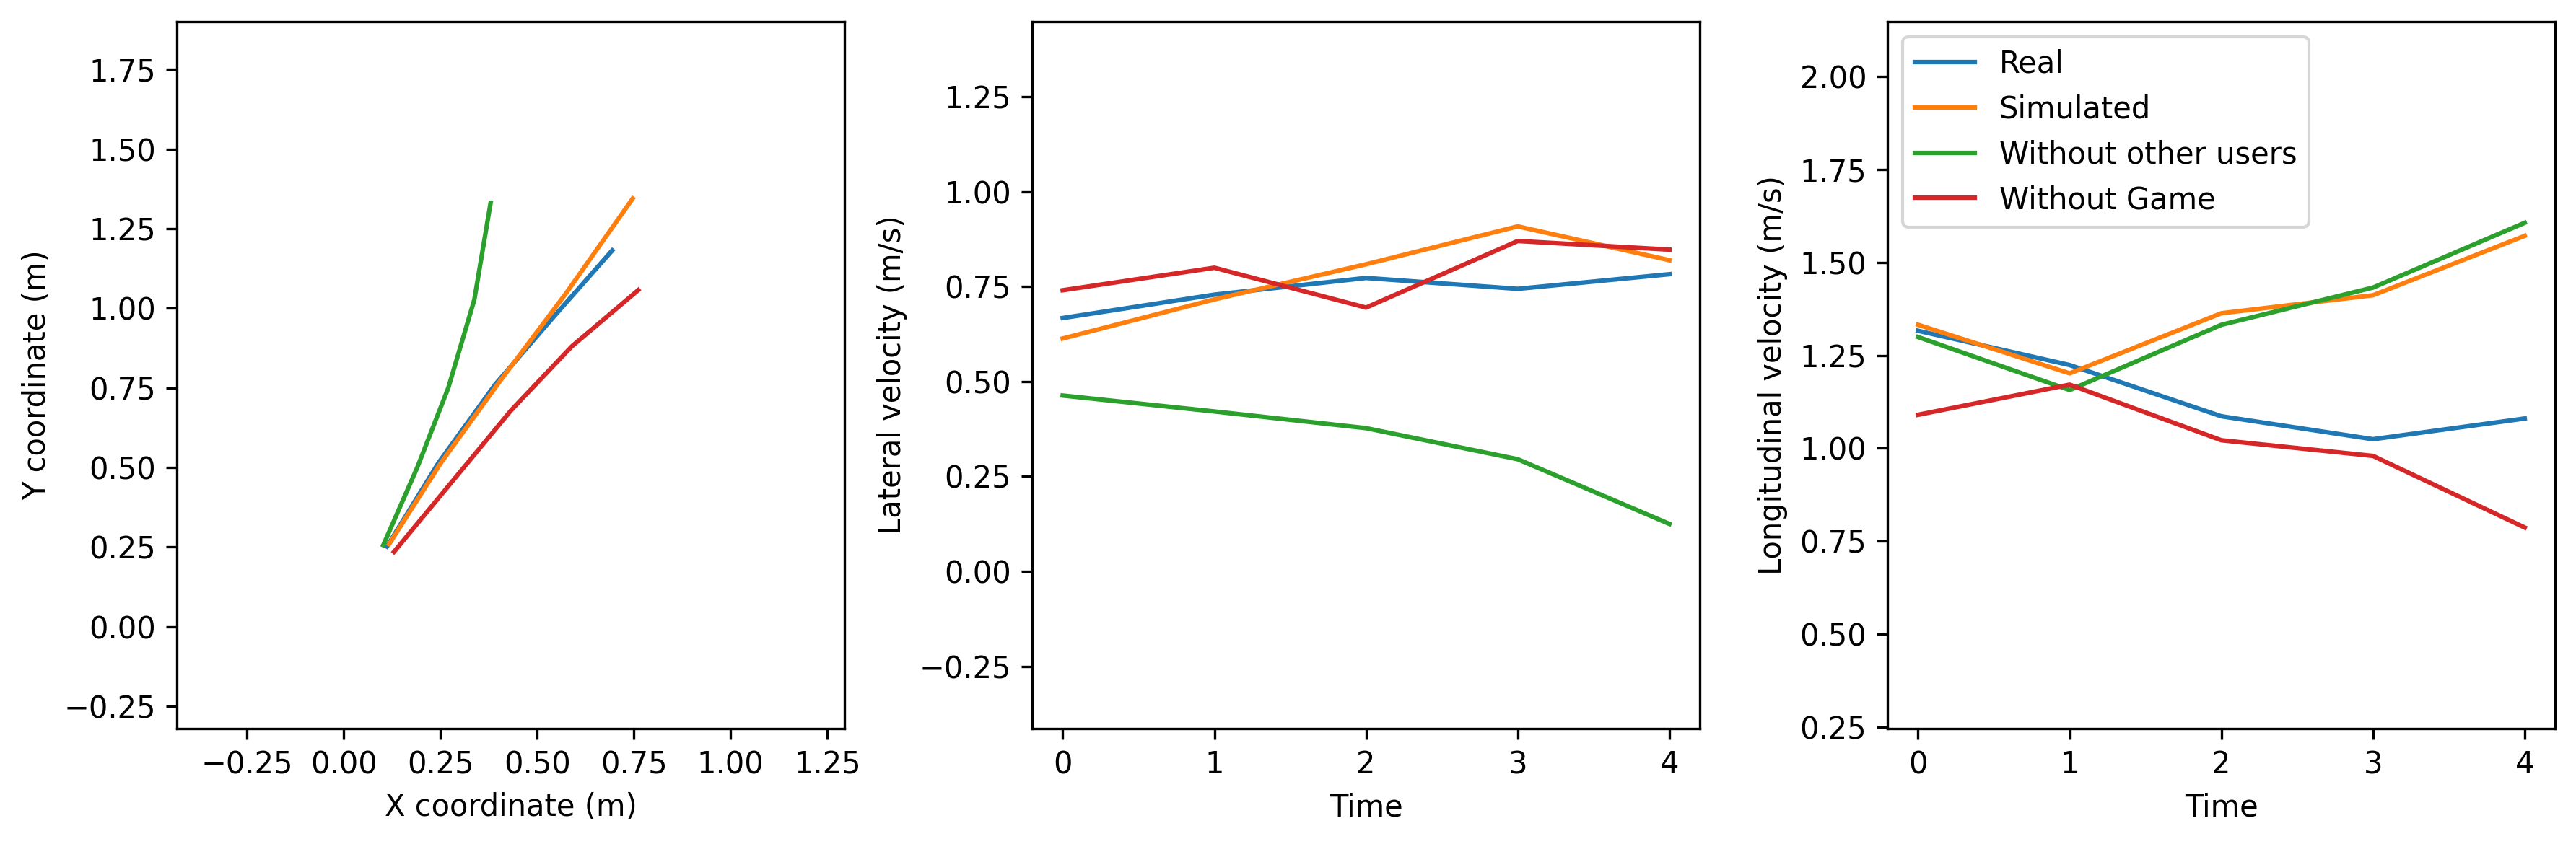

In [12]:
## 282-393-406-254可以
import matplotlib.pyplot as plt

# 假设 pedestrian_position, pedestrian_velocity, pedestrian_acceleration 是已经定义的变量
# pedestrian_position = ...
# pedestrian_velocity = ...
# pedestrian_acceleration = ...

# 创建一个 fig 和 ax 对象
fig, axs = plt.subplots(1, 3, figsize=(12, 4),dpi=300)

scene = 282
# 绘制位置数据
axs[0].plot(ls_real_tra[scene][:,0],ls_real_tra[scene][:,1],label='Real')
axs[0].plot(ls_predicted_tra[scene][:,0],ls_predicted_tra[scene][:,1],label='Simulated')
axs[0].plot(ls_predicted_tra_no_peer[scene][:,0],ls_predicted_tra_no_peer[scene][:,1],label='Without other users')
axs[0].plot(ls_predicted_tra_without_game[scene][:,0],ls_predicted_tra_without_game[scene][:,1],label='Without Game')
# axs[0].set_title('Position')
axs[0].set_xlabel('X coordinate (m)')
axs[0].set_ylabel('Y coordinate (m)')
axs[0].set_xlim(axs[0].get_xlim()[0]-0.5,axs[0].get_xlim()[1]+0.5)
axs[0].set_ylim(axs[0].get_ylim()[0]-0.5,axs[0].get_ylim()[1]+0.5)

# 绘制速度数据
axs[1].plot(ls_real_speed[scene][:,0],label='Real')
axs[1].plot(ls_predicted_speed[scene][:,0],label='Simulated')
axs[1].plot(ls_predicted_speed_no_peer[scene][:,0],label='Without other users')
axs[1].plot(ls_predicted_speed_without_game[scene][:,0],label='Without Game')
# axs[1].set_title('Velocity_x')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Lateral velocity (m/s)')
axs[1].set_ylim(axs[1].get_ylim()[0]-0.5,axs[1].get_ylim()[1]+0.5)

# 绘制加速度数据
axs[2].plot(ls_real_speed[scene][:,1],label='Real')
axs[2].plot(ls_predicted_speed[scene][:,1],label='Simulated')
axs[2].plot(ls_predicted_speed_no_peer[scene][:,1],label='Without other users')
axs[2].plot(ls_predicted_speed_without_game[scene][:,1],label='Without Game')
# axs[2].set_title('Velocity_y')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Longitudinal velocity (m/s)')
axs[2].set_ylim(axs[2].get_ylim()[0]-0.5,axs[2].get_ylim()[1]+0.5)
# 调整布局
plt.legend()
plt.tight_layout()
plt.savefig('figs/scene282.png',dpi=300)
# 显示图像
plt.show()

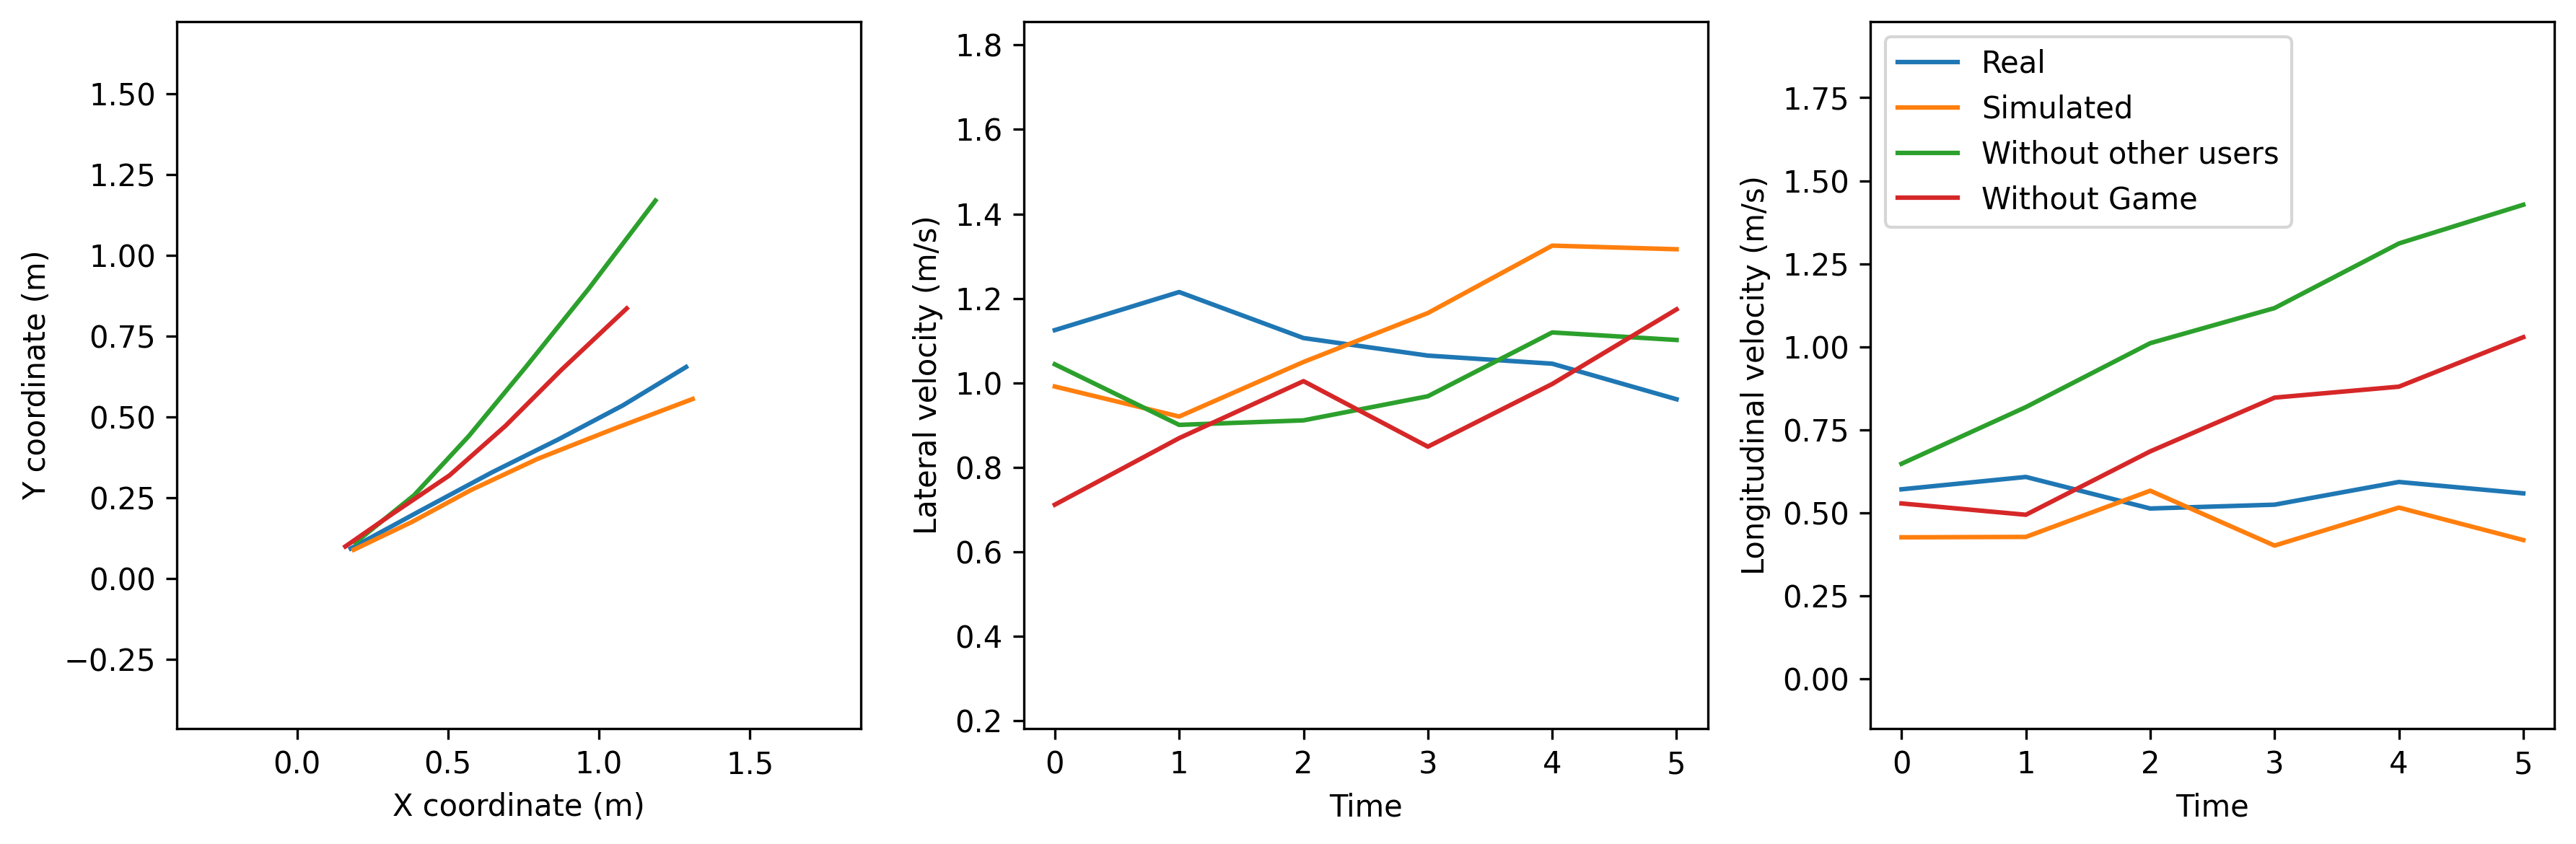

In [13]:
## 282-393-406-254可以
import matplotlib.pyplot as plt

# 假设 pedestrian_position, pedestrian_velocity, pedestrian_acceleration 是已经定义的变量
# pedestrian_position = ...
# pedestrian_velocity = ...
# pedestrian_acceleration = ...

# 创建一个 fig 和 ax 对象
fig, axs = plt.subplots(1, 3, figsize=(12, 4),dpi=300)

scene = 406
# 绘制位置数据
axs[0].plot(ls_real_tra[scene][:,0],ls_real_tra[scene][:,1],label='Real')
axs[0].plot(ls_predicted_tra[scene][:,0],ls_predicted_tra[scene][:,1],label='Simulated')
axs[0].plot(ls_predicted_tra_no_peer[scene][:,0],ls_predicted_tra_no_peer[scene][:,1],label='Without other users')
axs[0].plot(ls_predicted_tra_without_game[scene][:,0],ls_predicted_tra_without_game[scene][:,1],label='Without Game')
# axs[0].set_title('Position')
axs[0].set_xlabel('X coordinate (m)')
axs[0].set_ylabel('Y coordinate (m)')
axs[0].set_xlim(axs[0].get_xlim()[0]-0.5,axs[0].get_xlim()[1]+0.5)
axs[0].set_ylim(axs[0].get_ylim()[0]-0.5,axs[0].get_ylim()[1]+0.5)

# 绘制速度数据
axs[1].plot(ls_real_speed[scene][:,0],label='Real')
axs[1].plot(ls_predicted_speed[scene][:,0],label='Simulated')
axs[1].plot(ls_predicted_speed_no_peer[scene][:,0],label='Without other users')
axs[1].plot(ls_predicted_speed_without_game[scene][:,0],label='Without Game')
# axs[1].set_title('Velocity_x')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Lateral velocity (m/s)')
axs[1].set_ylim(axs[1].get_ylim()[0]-0.5,axs[1].get_ylim()[1]+0.5)

# 绘制加速度数据
axs[2].plot(ls_real_speed[scene][:,1],label='Real')
axs[2].plot(ls_predicted_speed[scene][:,1],label='Simulated')
axs[2].plot(ls_predicted_speed_no_peer[scene][:,1],label='Without other users')
axs[2].plot(ls_predicted_speed_without_game[scene][:,1],label='Without Game')
# axs[2].set_title('Velocity_y')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Longitudinal velocity (m/s)')
axs[2].set_ylim(axs[2].get_ylim()[0]-0.5,axs[2].get_ylim()[1]+0.5)
# 调整布局
plt.legend()
plt.tight_layout()
plt.savefig('figs/scene406.png',dpi=300)
# 显示图像
plt.show()

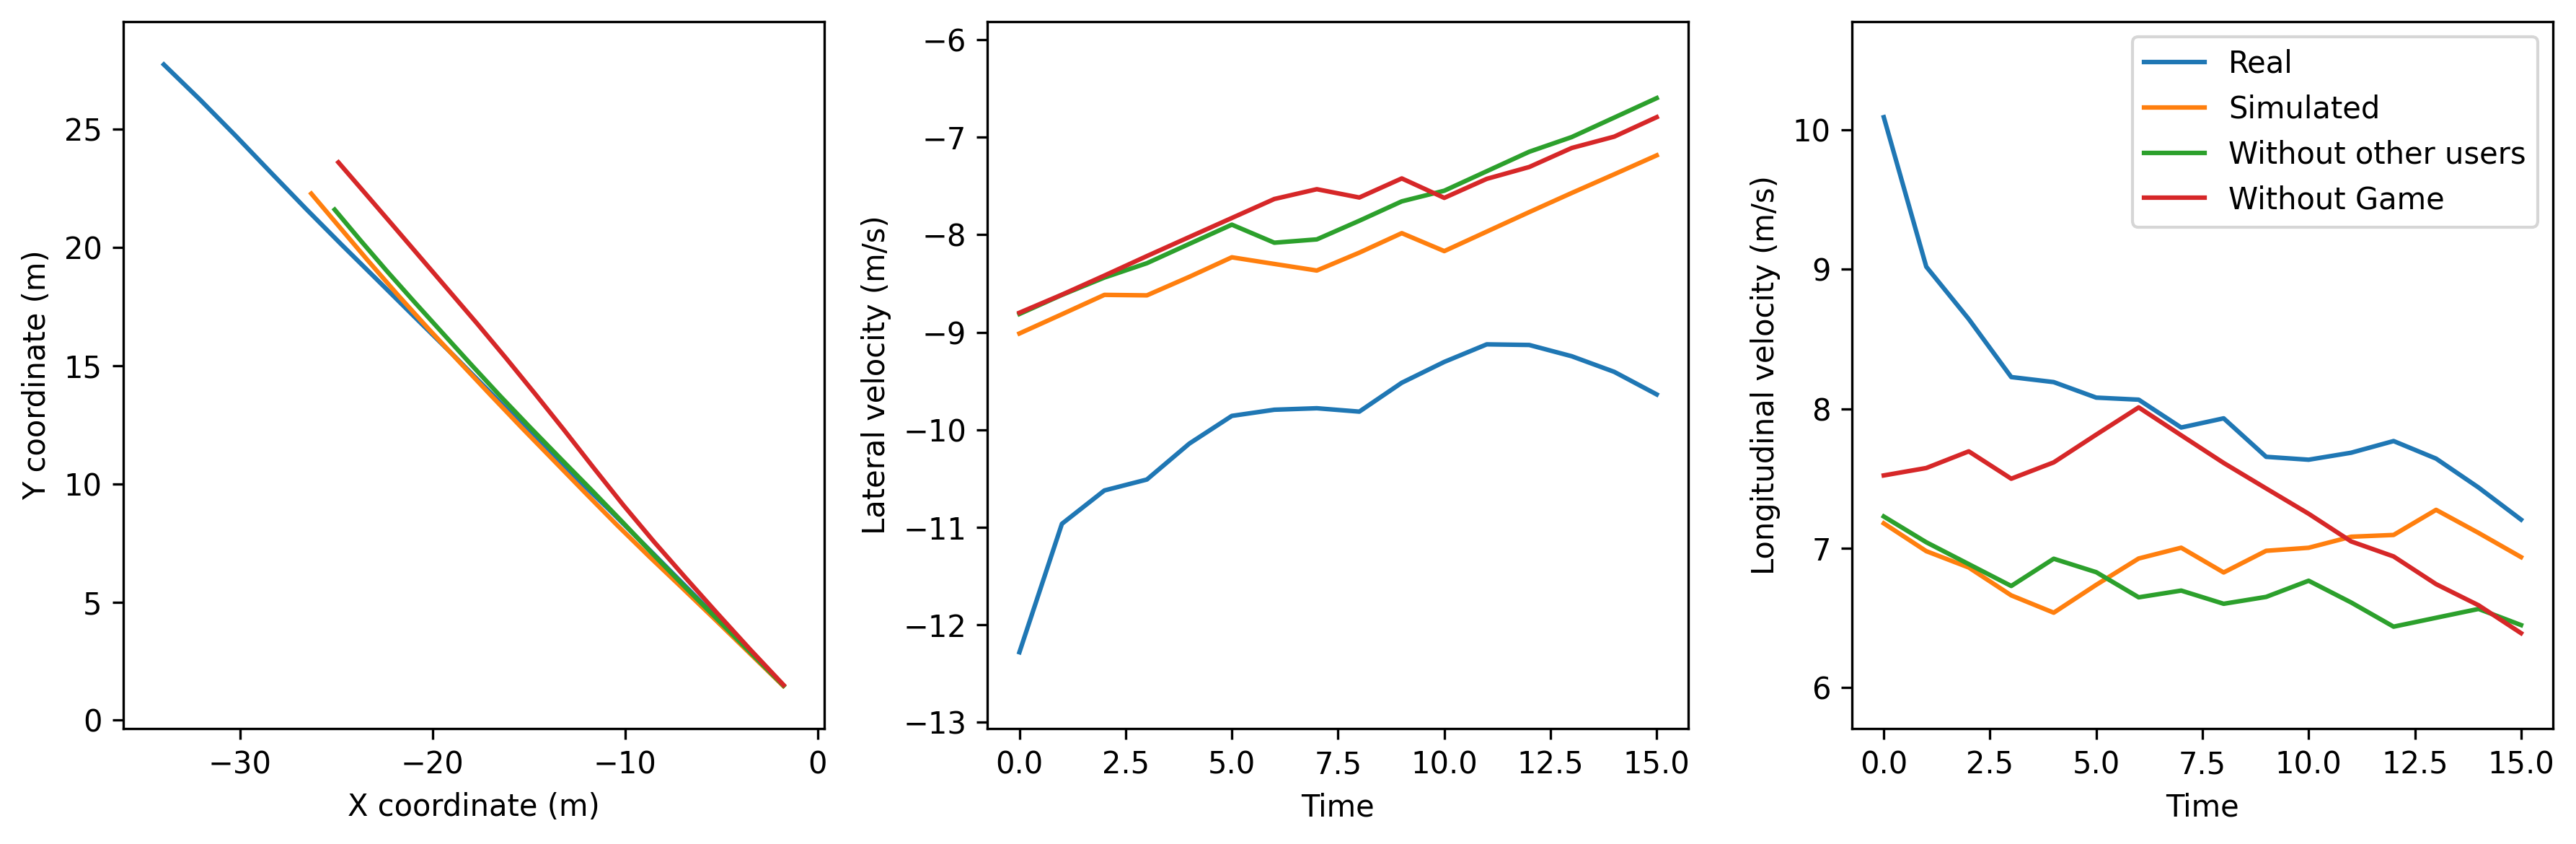

In [14]:
## 282-393-406-254可以
import matplotlib.pyplot as plt

# 假设 pedestrian_position, pedestrian_velocity, pedestrian_acceleration 是已经定义的变量
# pedestrian_position = ...
# pedestrian_velocity = ...
# pedestrian_acceleration = ...

# 创建一个 fig 和 ax 对象
fig, axs = plt.subplots(1, 3, figsize=(12, 4),dpi=300)

scene = 254
# 绘制位置数据
axs[0].plot(ls_real_tra[scene][:,0],ls_real_tra[scene][:,1],label='Real')
axs[0].plot(ls_predicted_tra[scene][:,0],ls_predicted_tra[scene][:,1],label='Simulated')
axs[0].plot(ls_predicted_tra_no_peer[scene][:,0],ls_predicted_tra_no_peer[scene][:,1],label='Without other users')
axs[0].plot(ls_predicted_tra_without_game[scene][:,0],ls_predicted_tra_without_game[scene][:,1],label='Without Game')
# axs[0].set_title('Position')
axs[0].set_xlabel('X coordinate (m)')
axs[0].set_ylabel('Y coordinate (m)')
axs[0].set_xlim(axs[0].get_xlim()[0]-0.5,axs[0].get_xlim()[1]+0.5)
axs[0].set_ylim(axs[0].get_ylim()[0]-0.5,axs[0].get_ylim()[1]+0.5)

# 绘制速度数据
axs[1].plot(ls_real_speed[scene][:,0],label='Real')
axs[1].plot(ls_predicted_speed[scene][:,0],label='Simulated')
axs[1].plot(ls_predicted_speed_no_peer[scene][:,0],label='Without other users')
axs[1].plot(ls_predicted_speed_without_game[scene][:,0],label='Without Game')
# axs[1].set_title('Velocity_x')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Lateral velocity (m/s)')
axs[1].set_ylim(axs[1].get_ylim()[0]-0.5,axs[1].get_ylim()[1]+0.5)

# 绘制加速度数据
axs[2].plot(ls_real_speed[scene][:,1],label='Real')
axs[2].plot(ls_predicted_speed[scene][:,1],label='Simulated')
axs[2].plot(ls_predicted_speed_no_peer[scene][:,1],label='Without other users')
axs[2].plot(ls_predicted_speed_without_game[scene][:,1],label='Without Game')
# axs[2].set_title('Velocity_y')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Longitudinal velocity (m/s)')
axs[2].set_ylim(axs[2].get_ylim()[0]-0.5,axs[2].get_ylim()[1]+0.5)
# 调整布局
plt.legend()
plt.tight_layout()
plt.savefig('figs/scene254.png',dpi=300)
# 显示图像
plt.show()

# 奖励值的可视化

In [14]:
from envDesign.environment import InteractionEnv
import math

In [15]:
# discriminator.load('./model_weights/[0.9992950294551568, 0.9848406460614667, 0.6000547860479556, 0.605082754483777, 1.71901808359782, 1.6373727841446695, 0.8009303661658126, 0.7793628897146919, 40]')

In [16]:
discriminator.load('./model_weights/[1.357779349338535, 1.4124643787710067, 0.9900410416545227, 1.0636065075855168, 2.632993079806612, 3.119678312305758, 1.45793490022538, 1.635005860595004, 24260]')

In [17]:
env = InteractionEnv('/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_state_pedestrain_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_state_vehicle_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_position_pedestrain_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_position_vehicle_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_done_group_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_num_pedestrain_train.npy',
                        '/mnt/f/公开数据集/Yandex/人车交互数据/环境数据/env优化滤波/env_num_vehicle_train.npy')

In [18]:
## 场景初始化

In [19]:
## 获取平均值，用来赋值
## vx_pedestrian
ls_ax_pedestrian_sum = []
ls_ax_pedestrian_num = []
for i in range(env.env_state_pedestrain.shape[0]):
    ls_ax_pedestrian_sum.append(np.abs(env.env_state_pedestrain[i][:,0,3]).sum())
    ls_ax_pedestrian_num.append(np.abs(env.env_state_pedestrain[i][:,0,3]).shape[0])
v_x_pedestrian = sum(ls_ax_pedestrian_sum) / sum(ls_ax_pedestrian_num)

## vy_pedestrian
ls_ax_pedestrian_sum = []
ls_ax_pedestrian_num = []
for i in range(env.env_state_pedestrain.shape[0]):
    ls_ax_pedestrian_sum.append(np.abs(env.env_state_pedestrain[i][:,0,4]).sum())
    ls_ax_pedestrian_num.append(np.abs(env.env_state_pedestrain[i][:,0,4]).shape[0])
v_y_pedestrian = sum(ls_ax_pedestrian_sum) / sum(ls_ax_pedestrian_num)

## ax_pedestrian
ls_ax_pedestrian_sum = []
ls_ax_pedestrian_num = []
for i in range(env.env_state_pedestrain.shape[0]):
    ls_ax_pedestrian_sum.append(np.abs(env.env_state_pedestrain[i][:,0,5]).sum())
    ls_ax_pedestrian_num.append(np.abs(env.env_state_pedestrain[i][:,0,5]).shape[0])
a_x_pedestrian = sum(ls_ax_pedestrian_sum) / sum(ls_ax_pedestrian_num)

## ay_pedestrian
ls_ax_pedestrian_sum = []
ls_ax_pedestrian_num = []
for i in range(env.env_state_pedestrain.shape[0]):
    ls_ax_pedestrian_sum.append(np.abs(env.env_state_pedestrain[i][:,0,6]).sum())
    ls_ax_pedestrian_num.append(np.abs(env.env_state_pedestrain[i][:,0,6]).shape[0])
a_y_pedestrian = sum(ls_ax_pedestrian_sum) / sum(ls_ax_pedestrian_num)

## vx_vehicle
ls_ax_pedestrian_sum = []
ls_ax_pedestrian_num = []
for i in range(env.env_state_pedestrain.shape[0]):
    ls_ax_pedestrian_sum.append(np.abs(env.env_state_vehicle[i][:,1,3]).sum())
    ls_ax_pedestrian_num.append(np.abs(env.env_state_vehicle[i][:,1,3]).shape[0])
v_x_vehicle = sum(ls_ax_pedestrian_sum) / sum(ls_ax_pedestrian_num)

## vy_vehicle
ls_ax_pedestrian_sum = []
ls_ax_pedestrian_num = []
for i in range(env.env_state_pedestrain.shape[0]):
    ls_ax_pedestrian_sum.append(np.abs(env.env_state_vehicle[i][:,1,4]).sum())
    ls_ax_pedestrian_num.append(np.abs(env.env_state_vehicle[i][:,1,4]).shape[0])
v_y_vehicle = sum(ls_ax_pedestrian_sum) / sum(ls_ax_pedestrian_num)

## ax_vehicle
ls_ax_pedestrian_sum = []
ls_ax_pedestrian_num = []
for i in range(env.env_state_pedestrain.shape[0]):
    ls_ax_pedestrian_sum.append(np.abs(env.env_state_vehicle[i][:,1,5]).sum())
    ls_ax_pedestrian_num.append(np.abs(env.env_state_vehicle[i][:,1,5]).shape[0])
a_x_vehicle = sum(ls_ax_pedestrian_sum) / sum(ls_ax_pedestrian_num)

## ay_vehicle
ls_ax_pedestrian_sum = []
ls_ax_pedestrian_num = []
for i in range(env.env_state_pedestrain.shape[0]):
    ls_ax_pedestrian_sum.append(np.abs(env.env_state_vehicle[i][:,1,6]).sum())
    ls_ax_pedestrian_num.append(np.abs(env.env_state_vehicle[i][:,1,6]).shape[0])
a_y_vehicle = sum(ls_ax_pedestrian_sum) / sum(ls_ax_pedestrian_num)

## gap_x
ls_ax_pedestrian_sum = []
ls_ax_pedestrian_num = []
for i in range(env.env_state_pedestrain.shape[0]):
    ls_ax_pedestrian_sum.append(np.abs(env.env_position_vehicle[i][:,0,0] - env.env_position_vehicle[i][:,1,0]).sum())
    ls_ax_pedestrian_num.append(np.abs(env.env_position_vehicle[i][:,0,0]).shape[0])
gap_x = sum(ls_ax_pedestrian_sum) / sum(ls_ax_pedestrian_num)

## gap_y
ls_ax_pedestrian_sum = []
ls_ax_pedestrian_num = []
for i in range(env.env_state_pedestrain.shape[0]):
    ls_ax_pedestrian_sum.append(np.abs(env.env_position_vehicle[i][:,0,1] - env.env_position_vehicle[i][:,1,1]).sum())
    ls_ax_pedestrian_num.append(np.abs(env.env_position_vehicle[i][:,0,1]).shape[0])
gap_y = sum(ls_ax_pedestrian_sum) / sum(ls_ax_pedestrian_num)

In [20]:
## 调整车速和横纵向距离

In [21]:
def update(action,state):
    next_vx = state[3] + action[0] * 0.2
    next_vy = state[4] + action[1] * 0.2
    next_x = state[96] + state[3] * 0.2 + 0.5 * action[0] * 0.2 ** 2
    next_y = state[97] + state[4] * 0.2 + 0.5 * action[1] * 0.2 ** 2
    next_yaw_pedestrain = math.atan2(next_vy, next_vx)
    new_state = state.copy()
    ## 行人更新
    new_state[3], new_state[51] = [next_vx]*2
    new_state[4], new_state[52] = [next_vy]*2
    new_state[5], new_state[53] = [action[0]]*2
    new_state[6], new_state[54] = [action[1]]*2
    new_state[96], new_state[108]  = [next_x]*2
    new_state[97], new_state[109]  = [next_y]*2
    new_state[7], new_state[55]  = [next_yaw_pedestrain]*2

    ## 车辆更新
    next_vx_v = state[59] + state[61] * 0.2
    next_vy_v = state[60] + state[62] * 0.2
    next_x_v = state[110] + state[59] * 0.2 + 0.5 * state[61] * 0.2 ** 2
    next_y_v = state[111] + state[60] * 0.2 + 0.5 * state[62] * 0.2 ** 2
    next_yaw_v = math.atan2(next_vy_v, next_vx_v)

    new_state[59] = next_vx_v
    new_state[60] = next_vy_v
    new_state[110] = next_x_v
    new_state[111] = next_y_v
    new_state[63] = next_yaw_v
    return new_state

## 周边没有行人时的可视化

In [22]:
## 横、纵向距离改变
record_test1 = np.zeros((21,21))
for change1 in range(0,21):
    for change2 in range(0,21):
        state_flat, all_state = env.reset()

        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = gap_x * change2 / 10
        position_y_pedestrian = gap_y * (20 - change1) / 10
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 1
        vehicle_num = 2

        # 行人状态设置
        all_state[0][0][1:,:] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))

        # 车辆状态设置
        all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][1:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian

        ## 车辆位置设置
        all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[8:48] = 0
        state_flat[64:96] = 0
        state_flat[98:108] = 0
        state_flat[112:] = 0

        ## 行人设置
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置

        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test1[change1,change2] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/4198307238.py:100: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


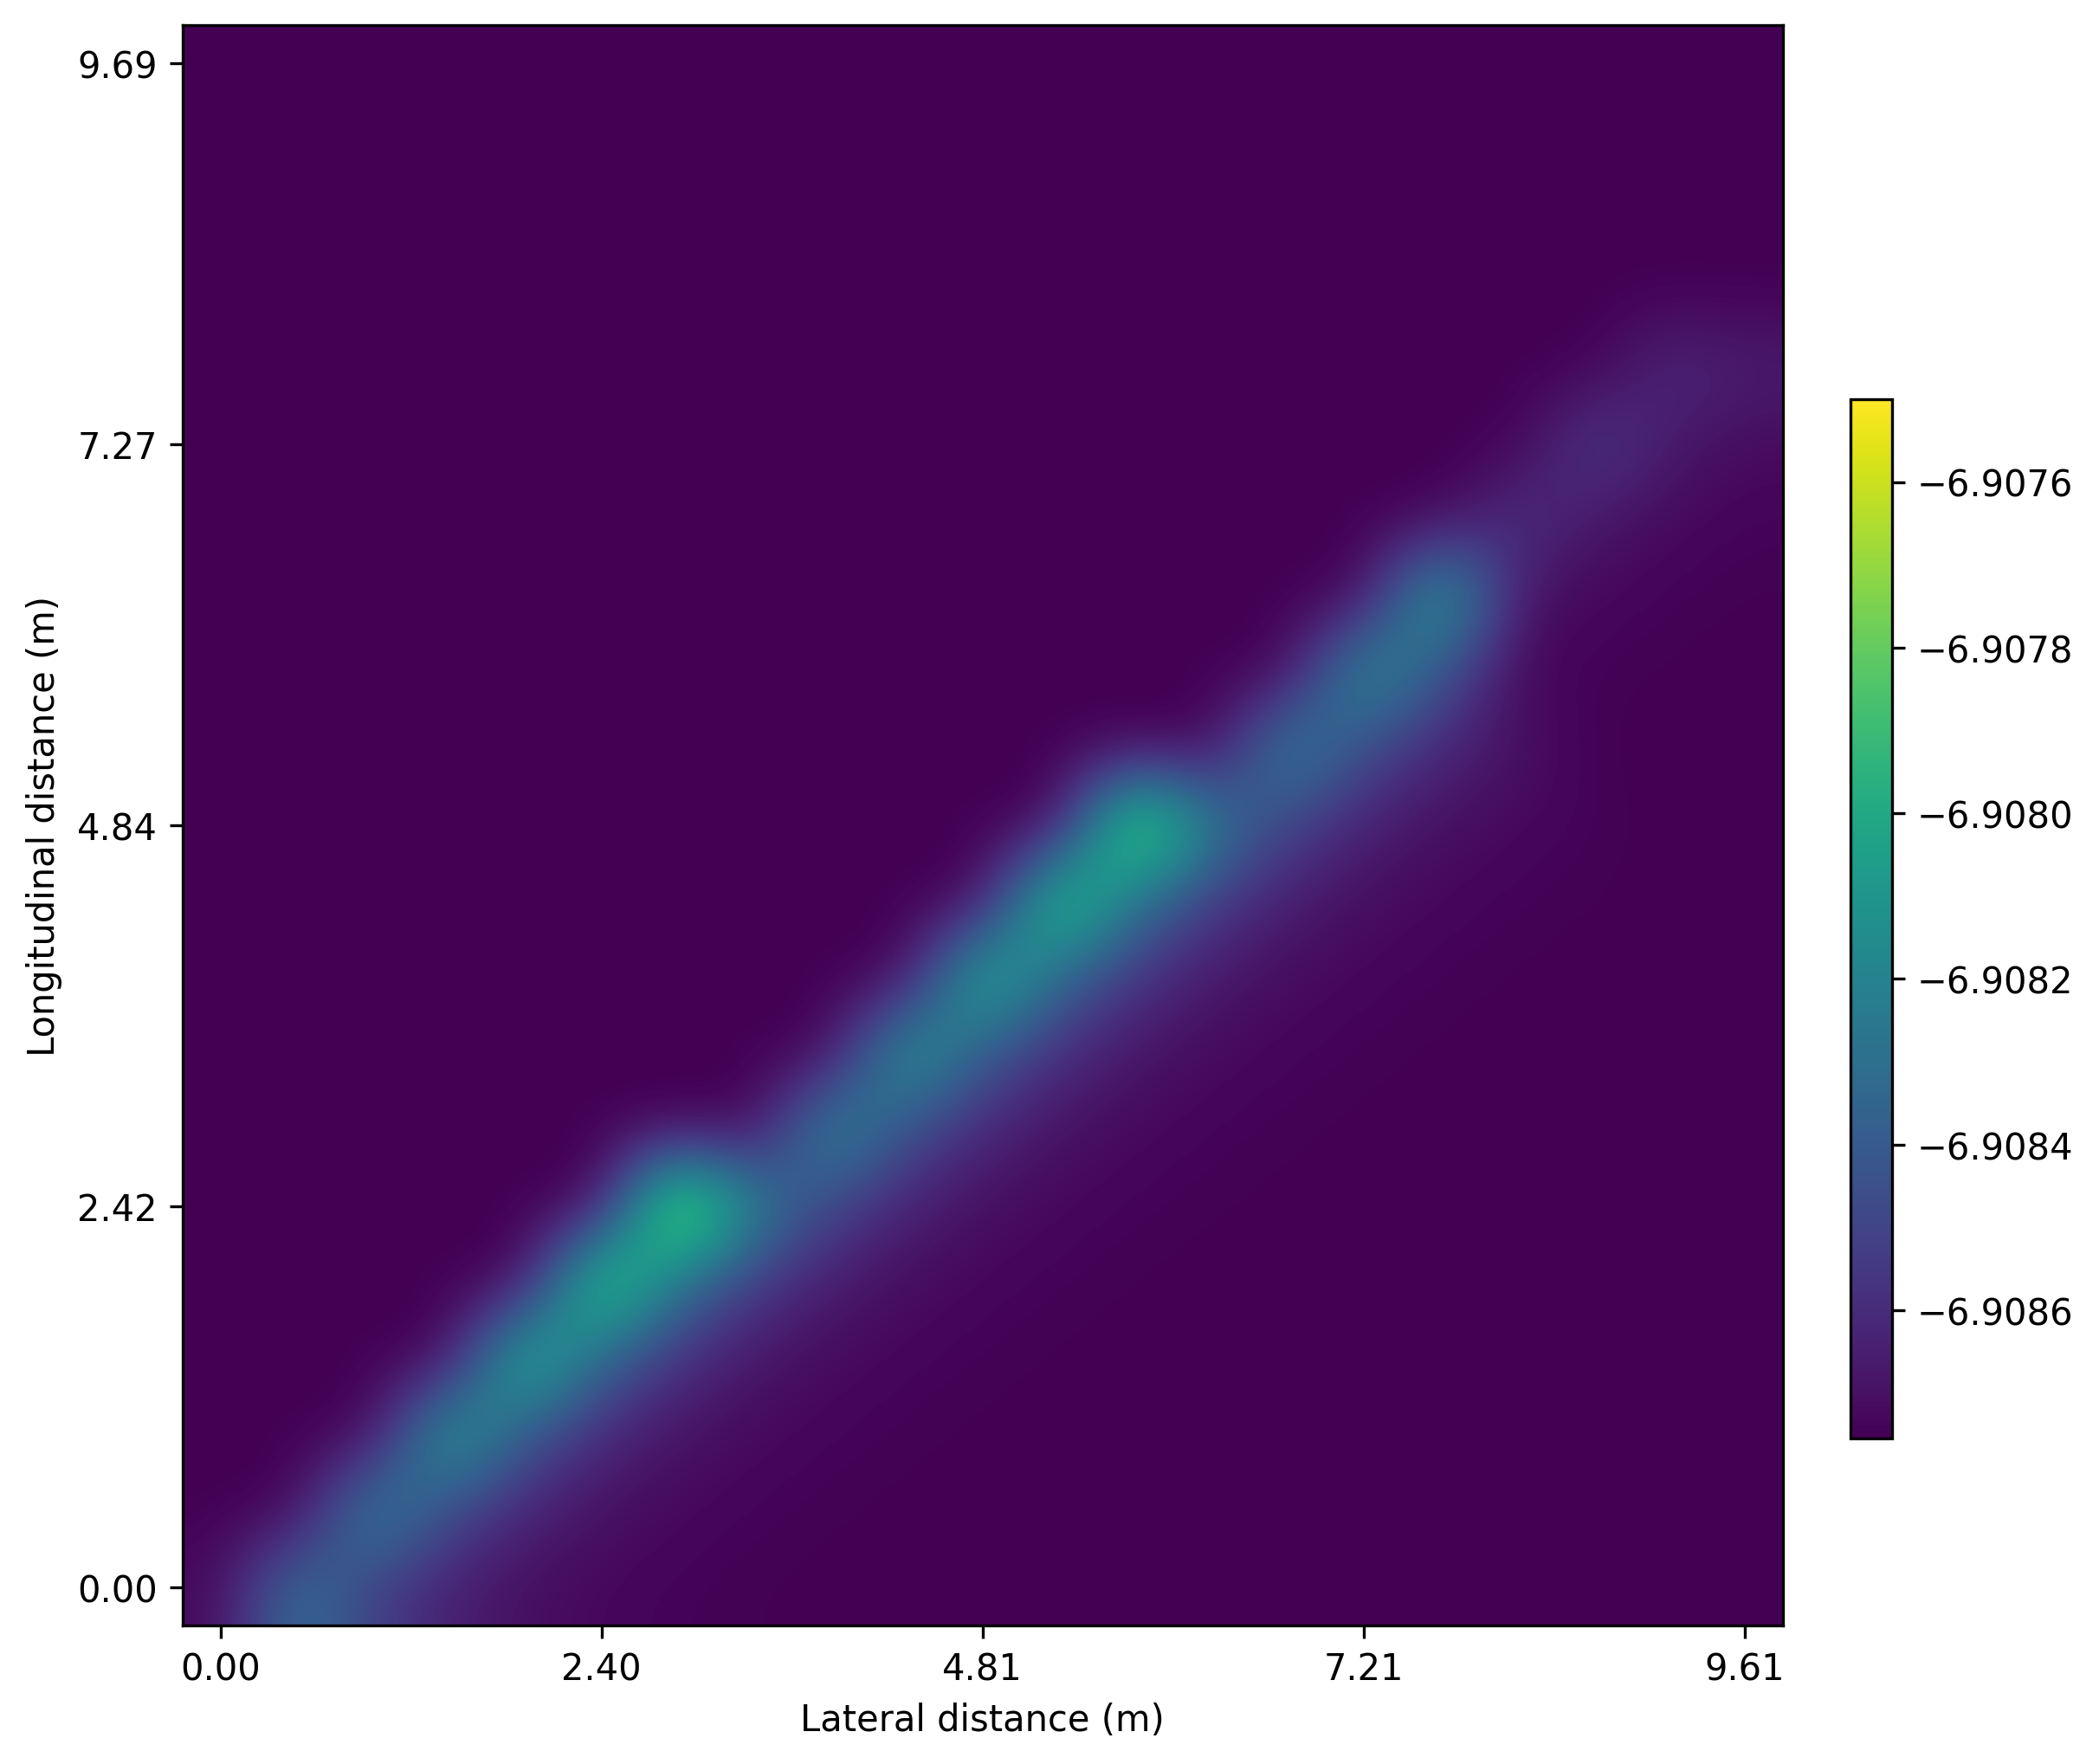

In [23]:
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
plt.imshow(record_test1, cmap='viridis', interpolation='bicubic')
plt.xlabel('Lateral distance (m)')
plt.ylabel('Longitudinal distance (m)')
plt.xticks(np.arange(0,21,5),[f"{i * gap_x / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*gap_y / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gapy-gapx-no_peer.jpg')
plt.show()


In [24]:
## 横距离、行人横向速度改变
record_test2 = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        state_flat, all_state = env.reset()

        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian * changex / 10
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = gap_x  * (20 - changey) / 10
        position_y_pedestrian = gap_y 
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 1
        vehicle_num = 2

        # 行人状态设置
        all_state[0][0][1:,:] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))

        # 车辆状态设置
        all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][1:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian

        ## 车辆位置设置
        all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[8:48] = 0
        state_flat[64:96] = 0
        state_flat[98:108] = 0
        state_flat[112:] = 0

        ## 行人设置
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置

        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test2[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/299780296.py:100: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


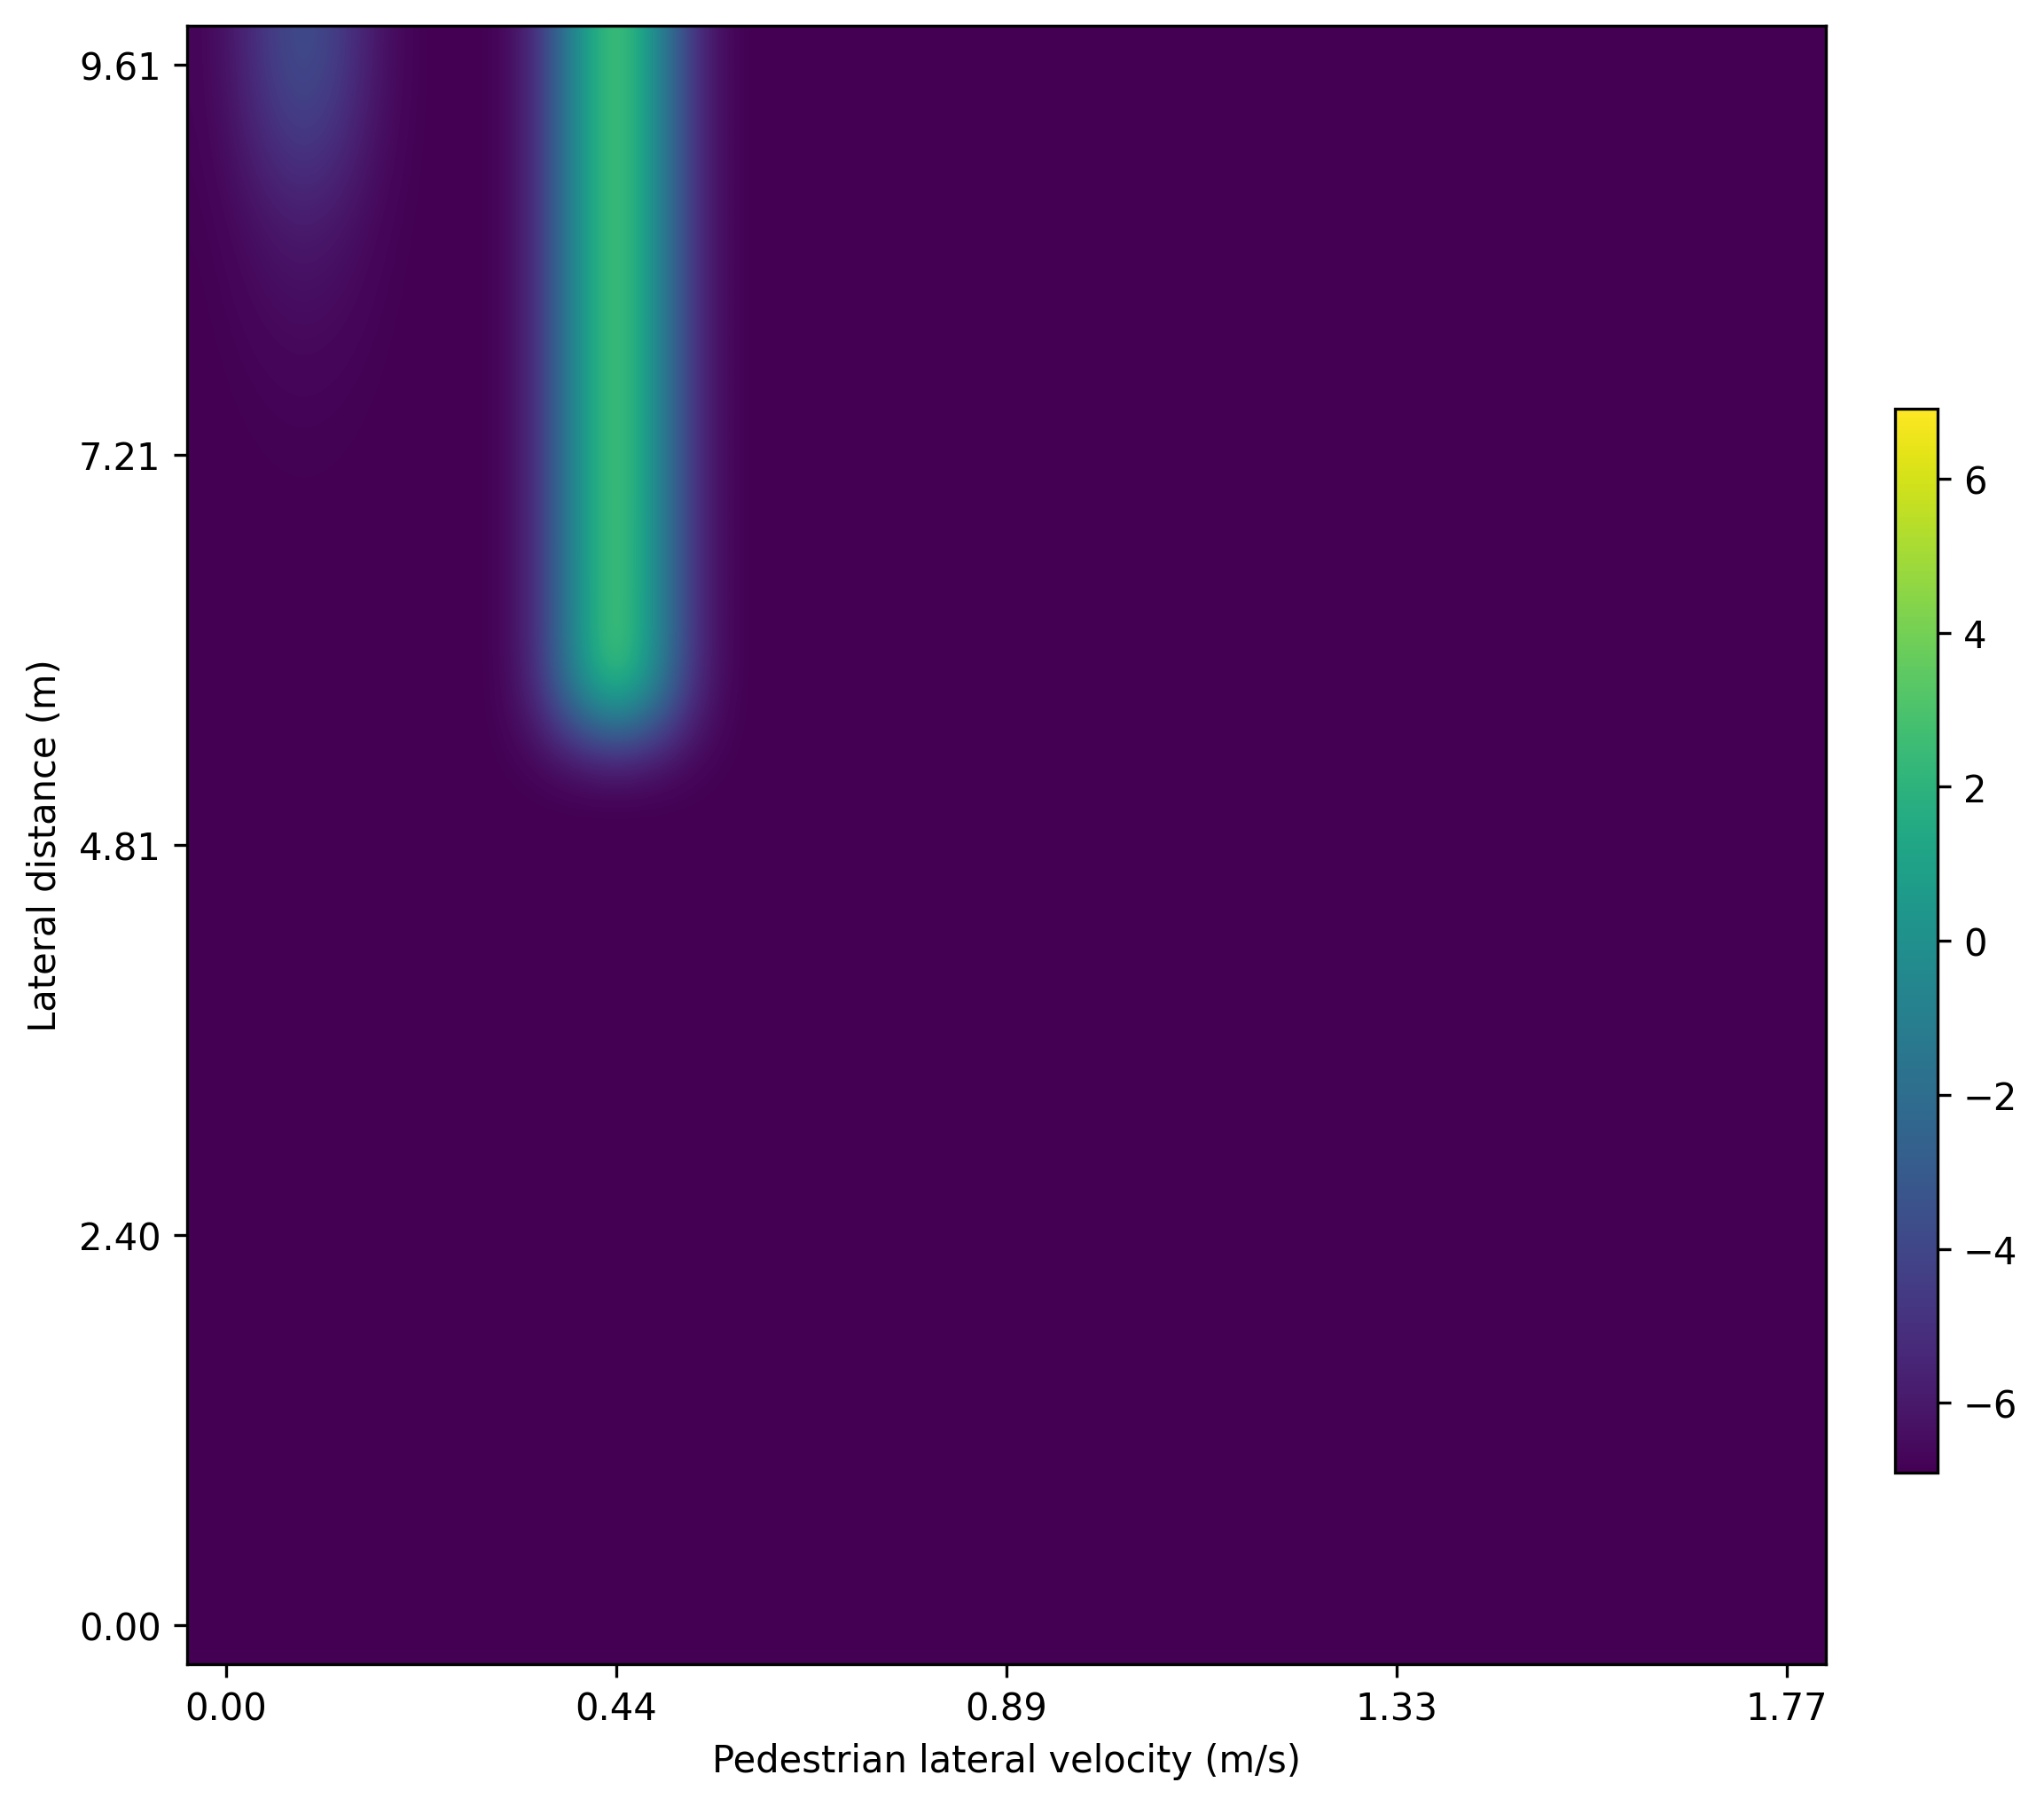

In [25]:
## Gap大的时候可以慢一点，因为人在前面，GAP小的时候要快一点，人像离车远一点
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
plt.imshow(record_test2, cmap='viridis', interpolation='bicubic')
plt.xlabel('Pedestrian lateral velocity (m/s)')
plt.ylabel('Lateral distance (m)')
plt.xticks(np.arange(0,21,5),[f"{i * v_x_pedestrian / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*gap_x / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gapx-vpx-no_peer.jpg')
plt.show()


In [26]:
## 纵距离、行人纵向速度改变
record_test3 = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        state_flat, all_state = env.reset()

        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian * changex / 10
        speed_x_vehicle = v_x_vehicle 
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = gap_x 
        position_y_pedestrian = gap_y * (20 - changey) / 10
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 1
        vehicle_num = 2

        # 行人状态设置
        all_state[0][0][1:,:] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))

        # 车辆状态设置
        all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][1:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian

        ## 车辆位置设置
        all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[8:48] = 0
        state_flat[64:96] = 0
        state_flat[98:108] = 0
        state_flat[112:] = 0

        ## 行人设置
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置

        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test3[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/3601356450.py:100: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


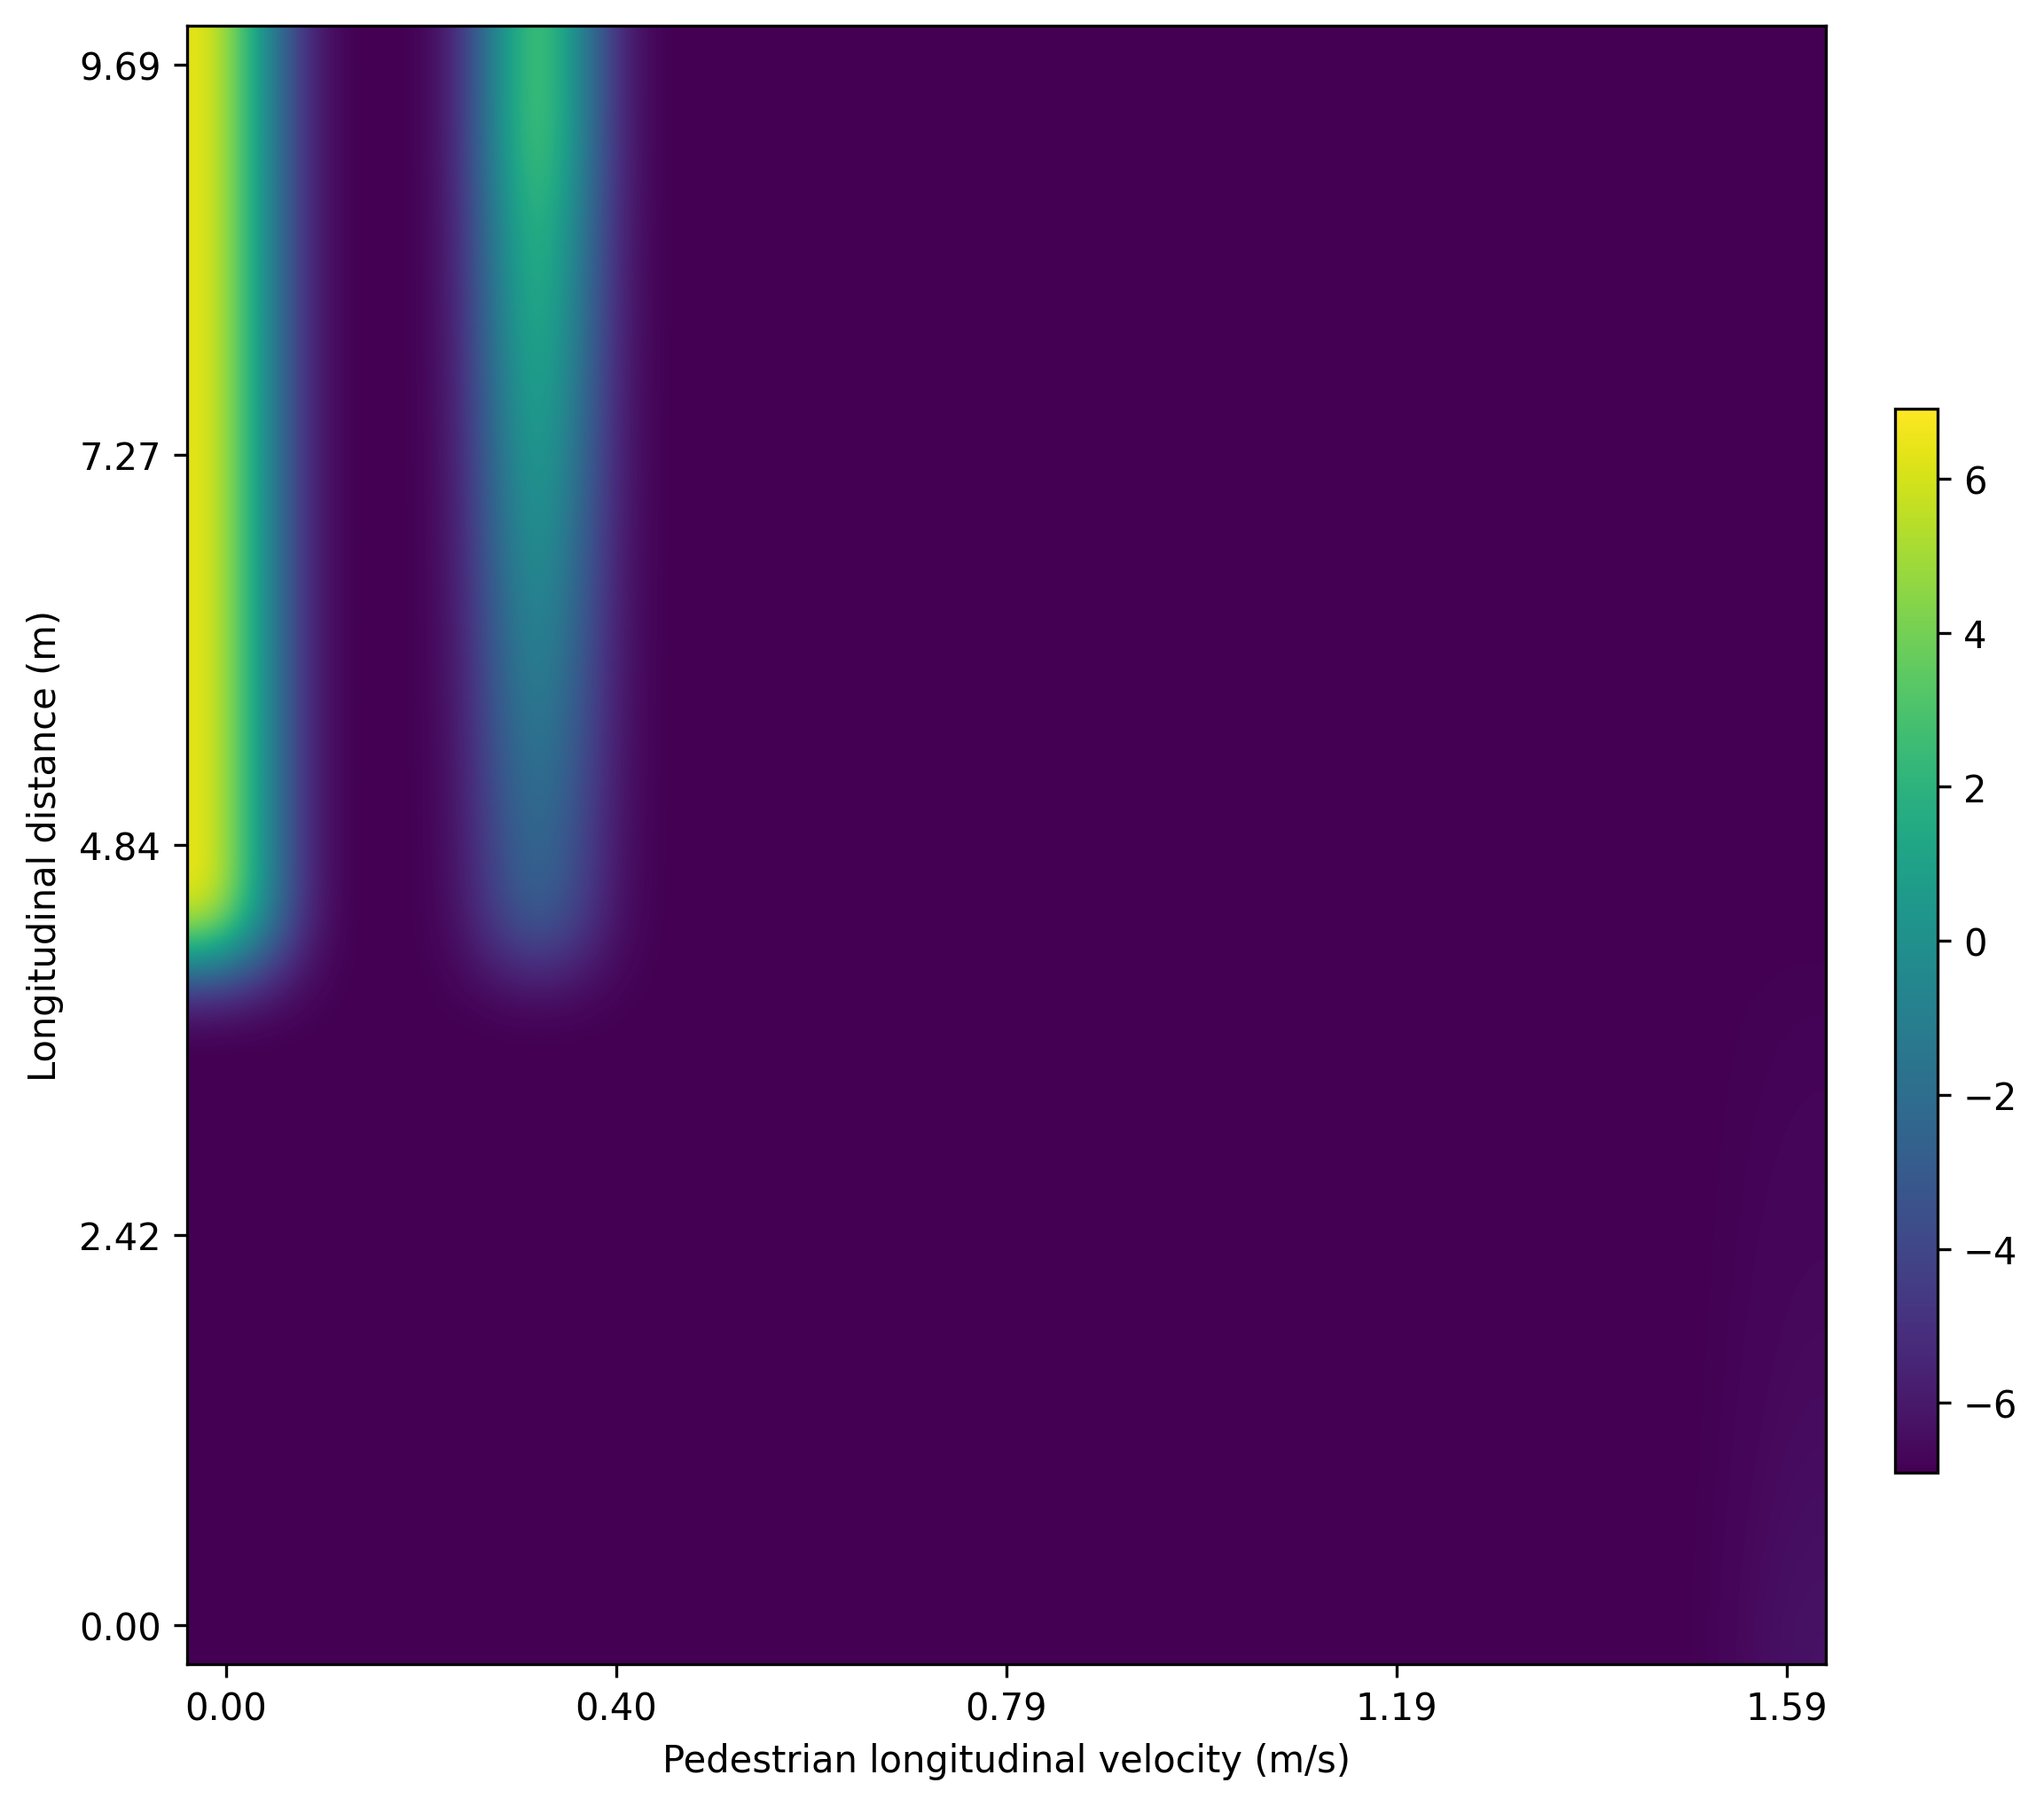

In [27]:
## 一样的道理
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
plt.imshow(record_test3, cmap='viridis', interpolation='bicubic')
plt.xlabel('Pedestrian longitudinal velocity (m/s)')
plt.ylabel('Longitudinal distance (m)')
plt.xticks(np.arange(0,21,5),[f"{i * v_y_pedestrian / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*gap_y / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gapy-vpy-no_peer.jpg')

plt.show()


In [28]:
## 横距离、车横向速度改变
record_test_4 = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        state_flat, all_state = env.reset()

        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle * (20 - changey) / 10
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = gap_x * changex / 10
        position_y_pedestrian = gap_y
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 1
        vehicle_num = 2

        # 行人状态设置
        all_state[0][0][1:,:] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))

        # 车辆状态设置
        all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][1:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian

        ## 车辆位置设置
        all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[8:48] = 0
        state_flat[64:96] = 0
        state_flat[98:108] = 0
        state_flat[112:] = 0

        ## 行人设置
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置

        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test_4[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/4202796688.py:100: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


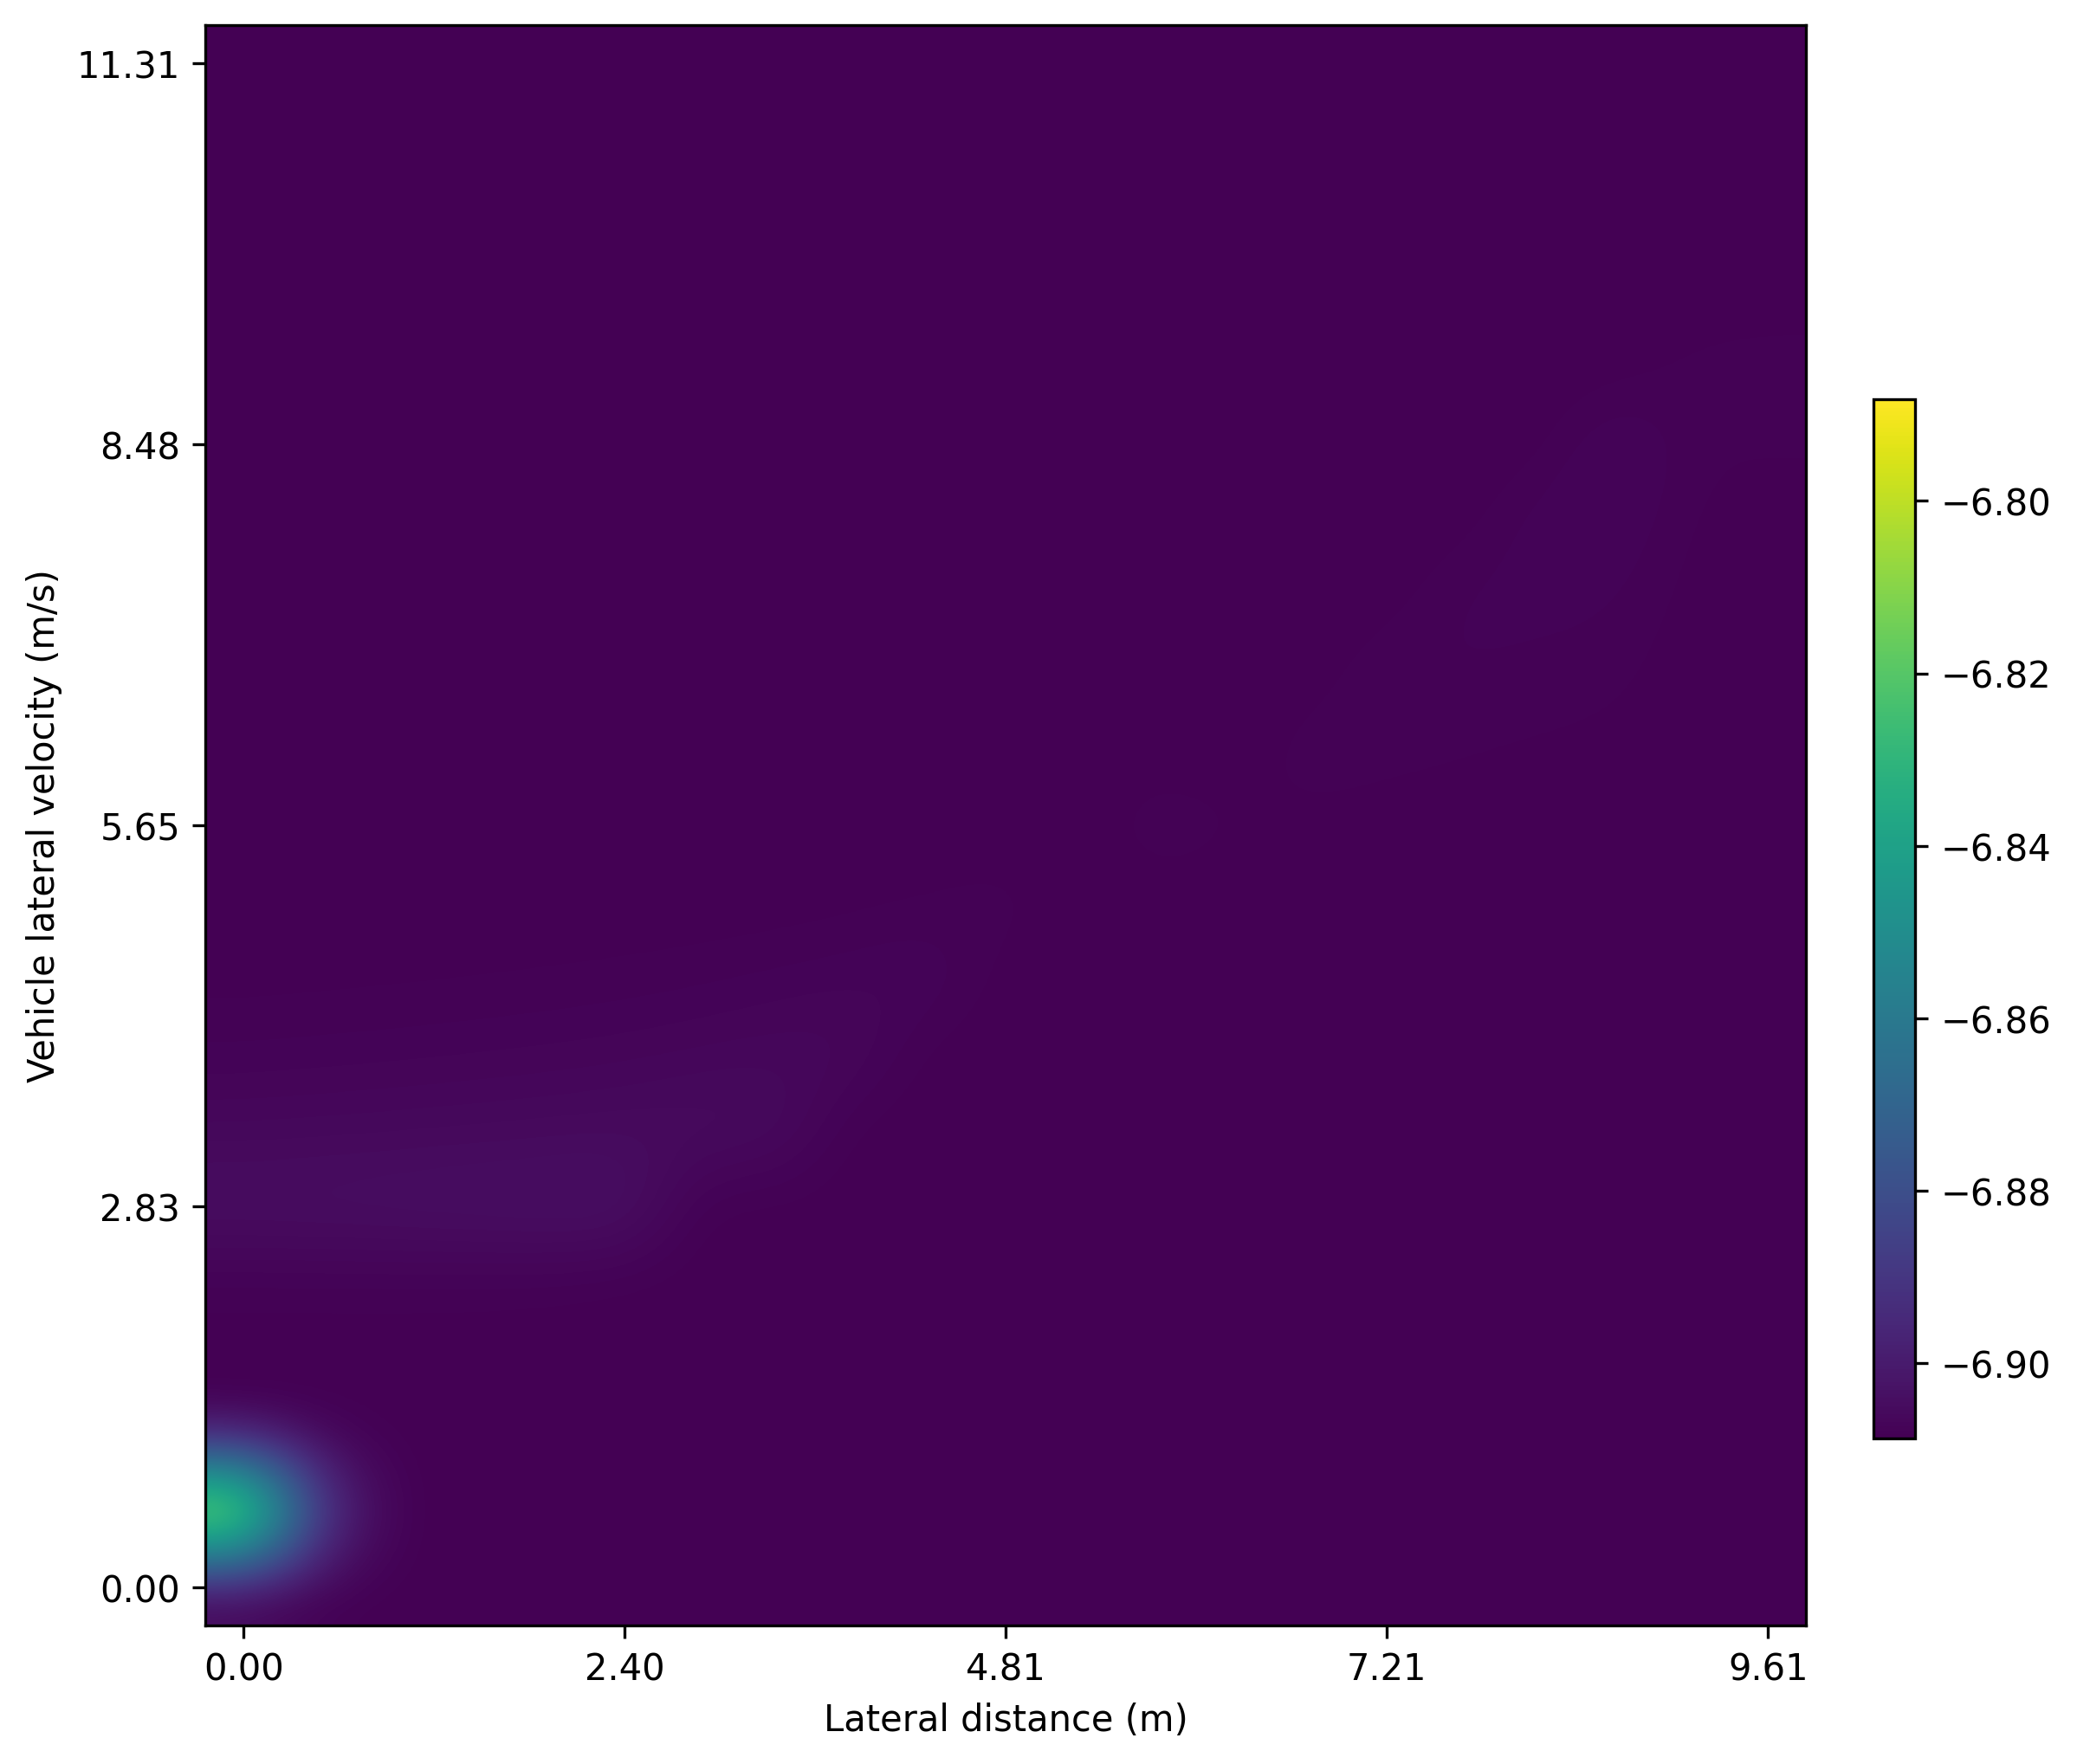

In [29]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
plt.imshow(record_test_4, cmap='viridis', interpolation='bicubic')
plt.xlabel('Lateral distance (m)')
plt.ylabel('Vehicle lateral velocity (m/s)')
plt.xticks(np.arange(0,21,5),[f"{i * gap_x / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*v_x_vehicle / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/vvx-gapx-no_peer.jpg')

plt.show()


In [30]:
## 纵距离、行人纵向速度改变
record_test5 = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        state_flat, all_state = env.reset()

        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle * (20 - changey) / 10

        position_x_pedestrian = gap_x
        position_y_pedestrian = gap_y * changex / 10
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 1
        vehicle_num = 2

        # 行人状态设置
        all_state[0][0][1:,:] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))

        # 车辆状态设置
        all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][1:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian

        ## 车辆位置设置
        all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[8:48] = 0
        state_flat[64:96] = 0
        state_flat[98:108] = 0
        state_flat[112:] = 0

        ## 行人设置
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置

        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test5[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/1842721137.py:100: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


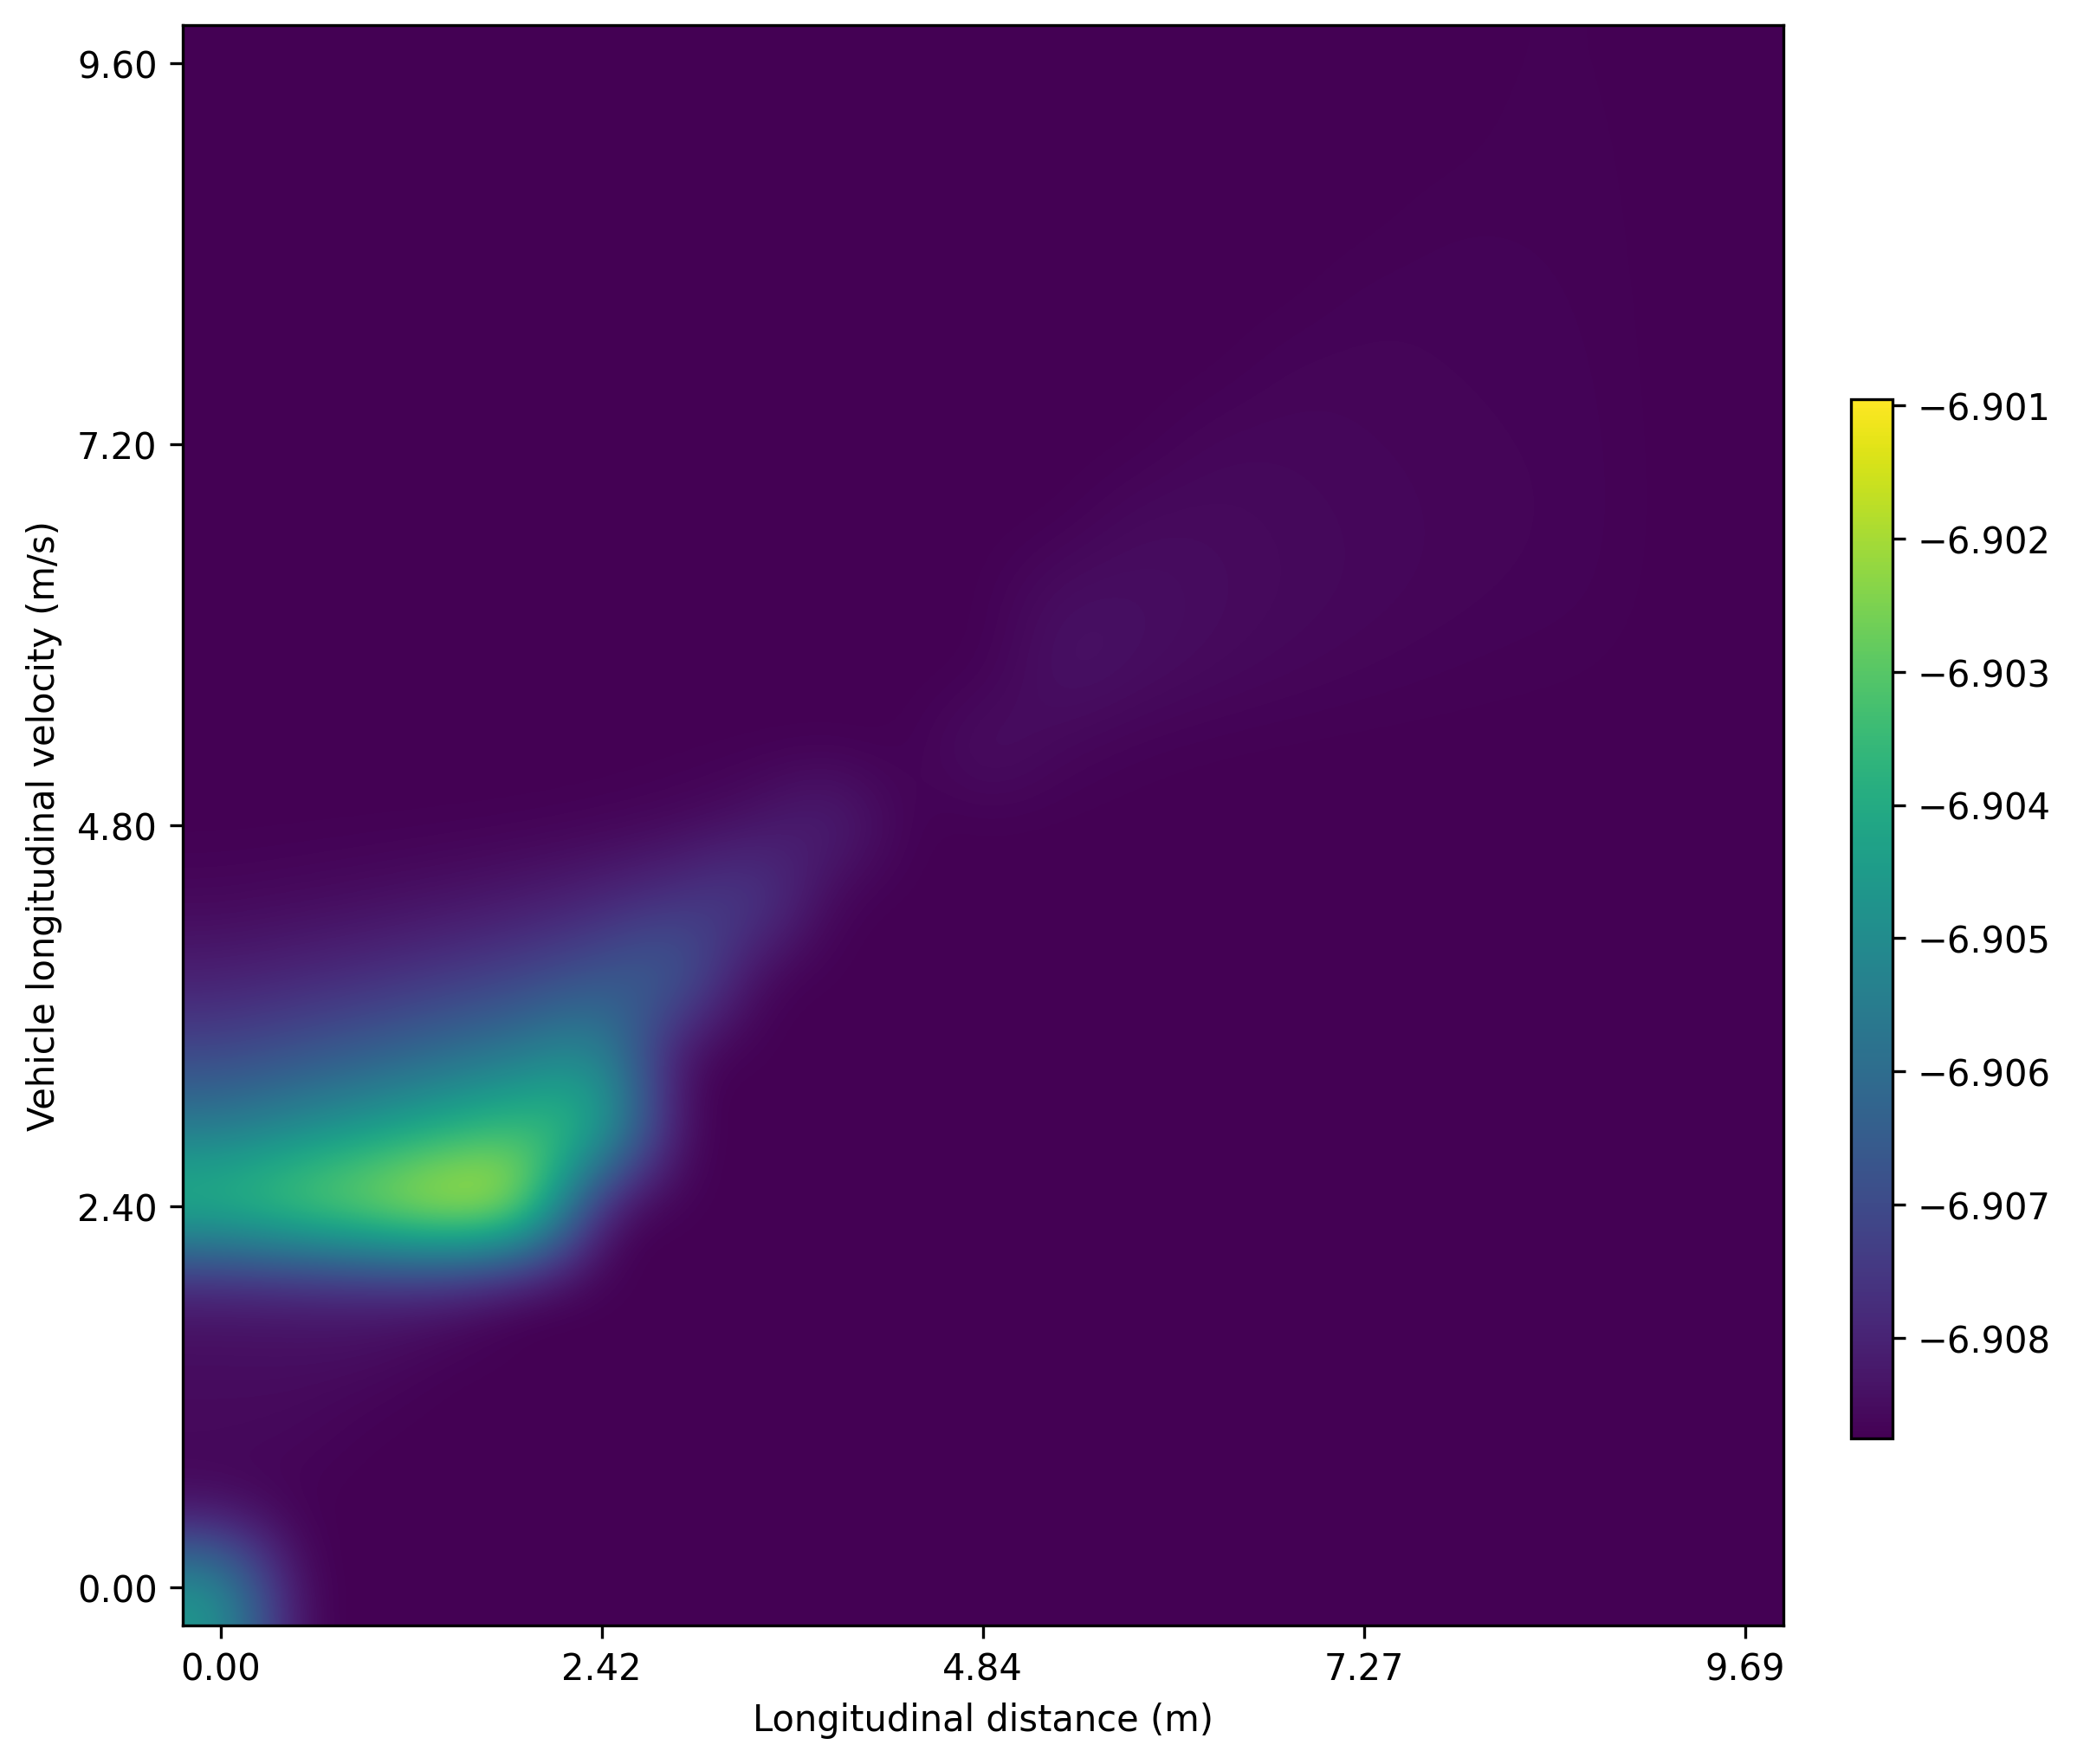

In [31]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
plt.imshow(record_test5, cmap='viridis', interpolation='bicubic')
plt.xlabel('Longitudinal distance (m)')
plt.ylabel('Vehicle longitudinal velocity (m/s)')
plt.xticks(np.arange(0,21,5),[f"{i * gap_y / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*v_y_vehicle / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/vvy-gapy-no_peer.jpg')

plt.show()


## 五等环绕

In [32]:
## 横纵gap改变
record_test1_five = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        state_flat, all_state = env.reset()
        original_position = (gap_x * changex / 10 , gap_y* (20 - changey) / 10)

        # 半径
        radius = 1  # 可以根据需要调整

        # 计算五个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 6)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angle), original_position[1] + radius * np.sin(angle)) for angle in angles]

        # 包含原行人在内，总共六个人
        all_positions = [original_position] + new_positions

        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = gap_x * changex / 10 
        position_y_pedestrian = gap_y* (20 - changey) / 10
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 6
        vehicle_num = 6

        # 行人状态设置
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1:, 0] = all_state[0][0][0, 0]
        all_state[0][0][1:, 1] = all_state[0][0][0, 1]
        all_state[0][0][1:, 2] = all_state[0][0][0, 2]
        all_state[0][0][1:, 3] = v_x_pedestrian
        all_state[0][0][1:, 4] = v_y_pedestrian
        all_state[0][0][1:, 5] = a_x_pedestrian
        all_state[0][0][1:, 6] = a_y_pedestrian
        all_state[0][0][1:, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        # all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        # all_state[0][2][1:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1:, :]  = np.array(new_positions)

        ## 车辆位置设置
        # all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        # state_flat[8:48] = 0
        # state_flat[64:96] = 0
        # state_flat[98:108] = 0
        # state_flat[112:] = 0

        ## 行人设置
        state_flat[0:48:8] = state_flat[0]
        state_flat[1:48:8] = state_flat[1]
        state_flat[2:48:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:48:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:48:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:48:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:48:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:48:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:108] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test1_five[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/3952484598.py:131: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


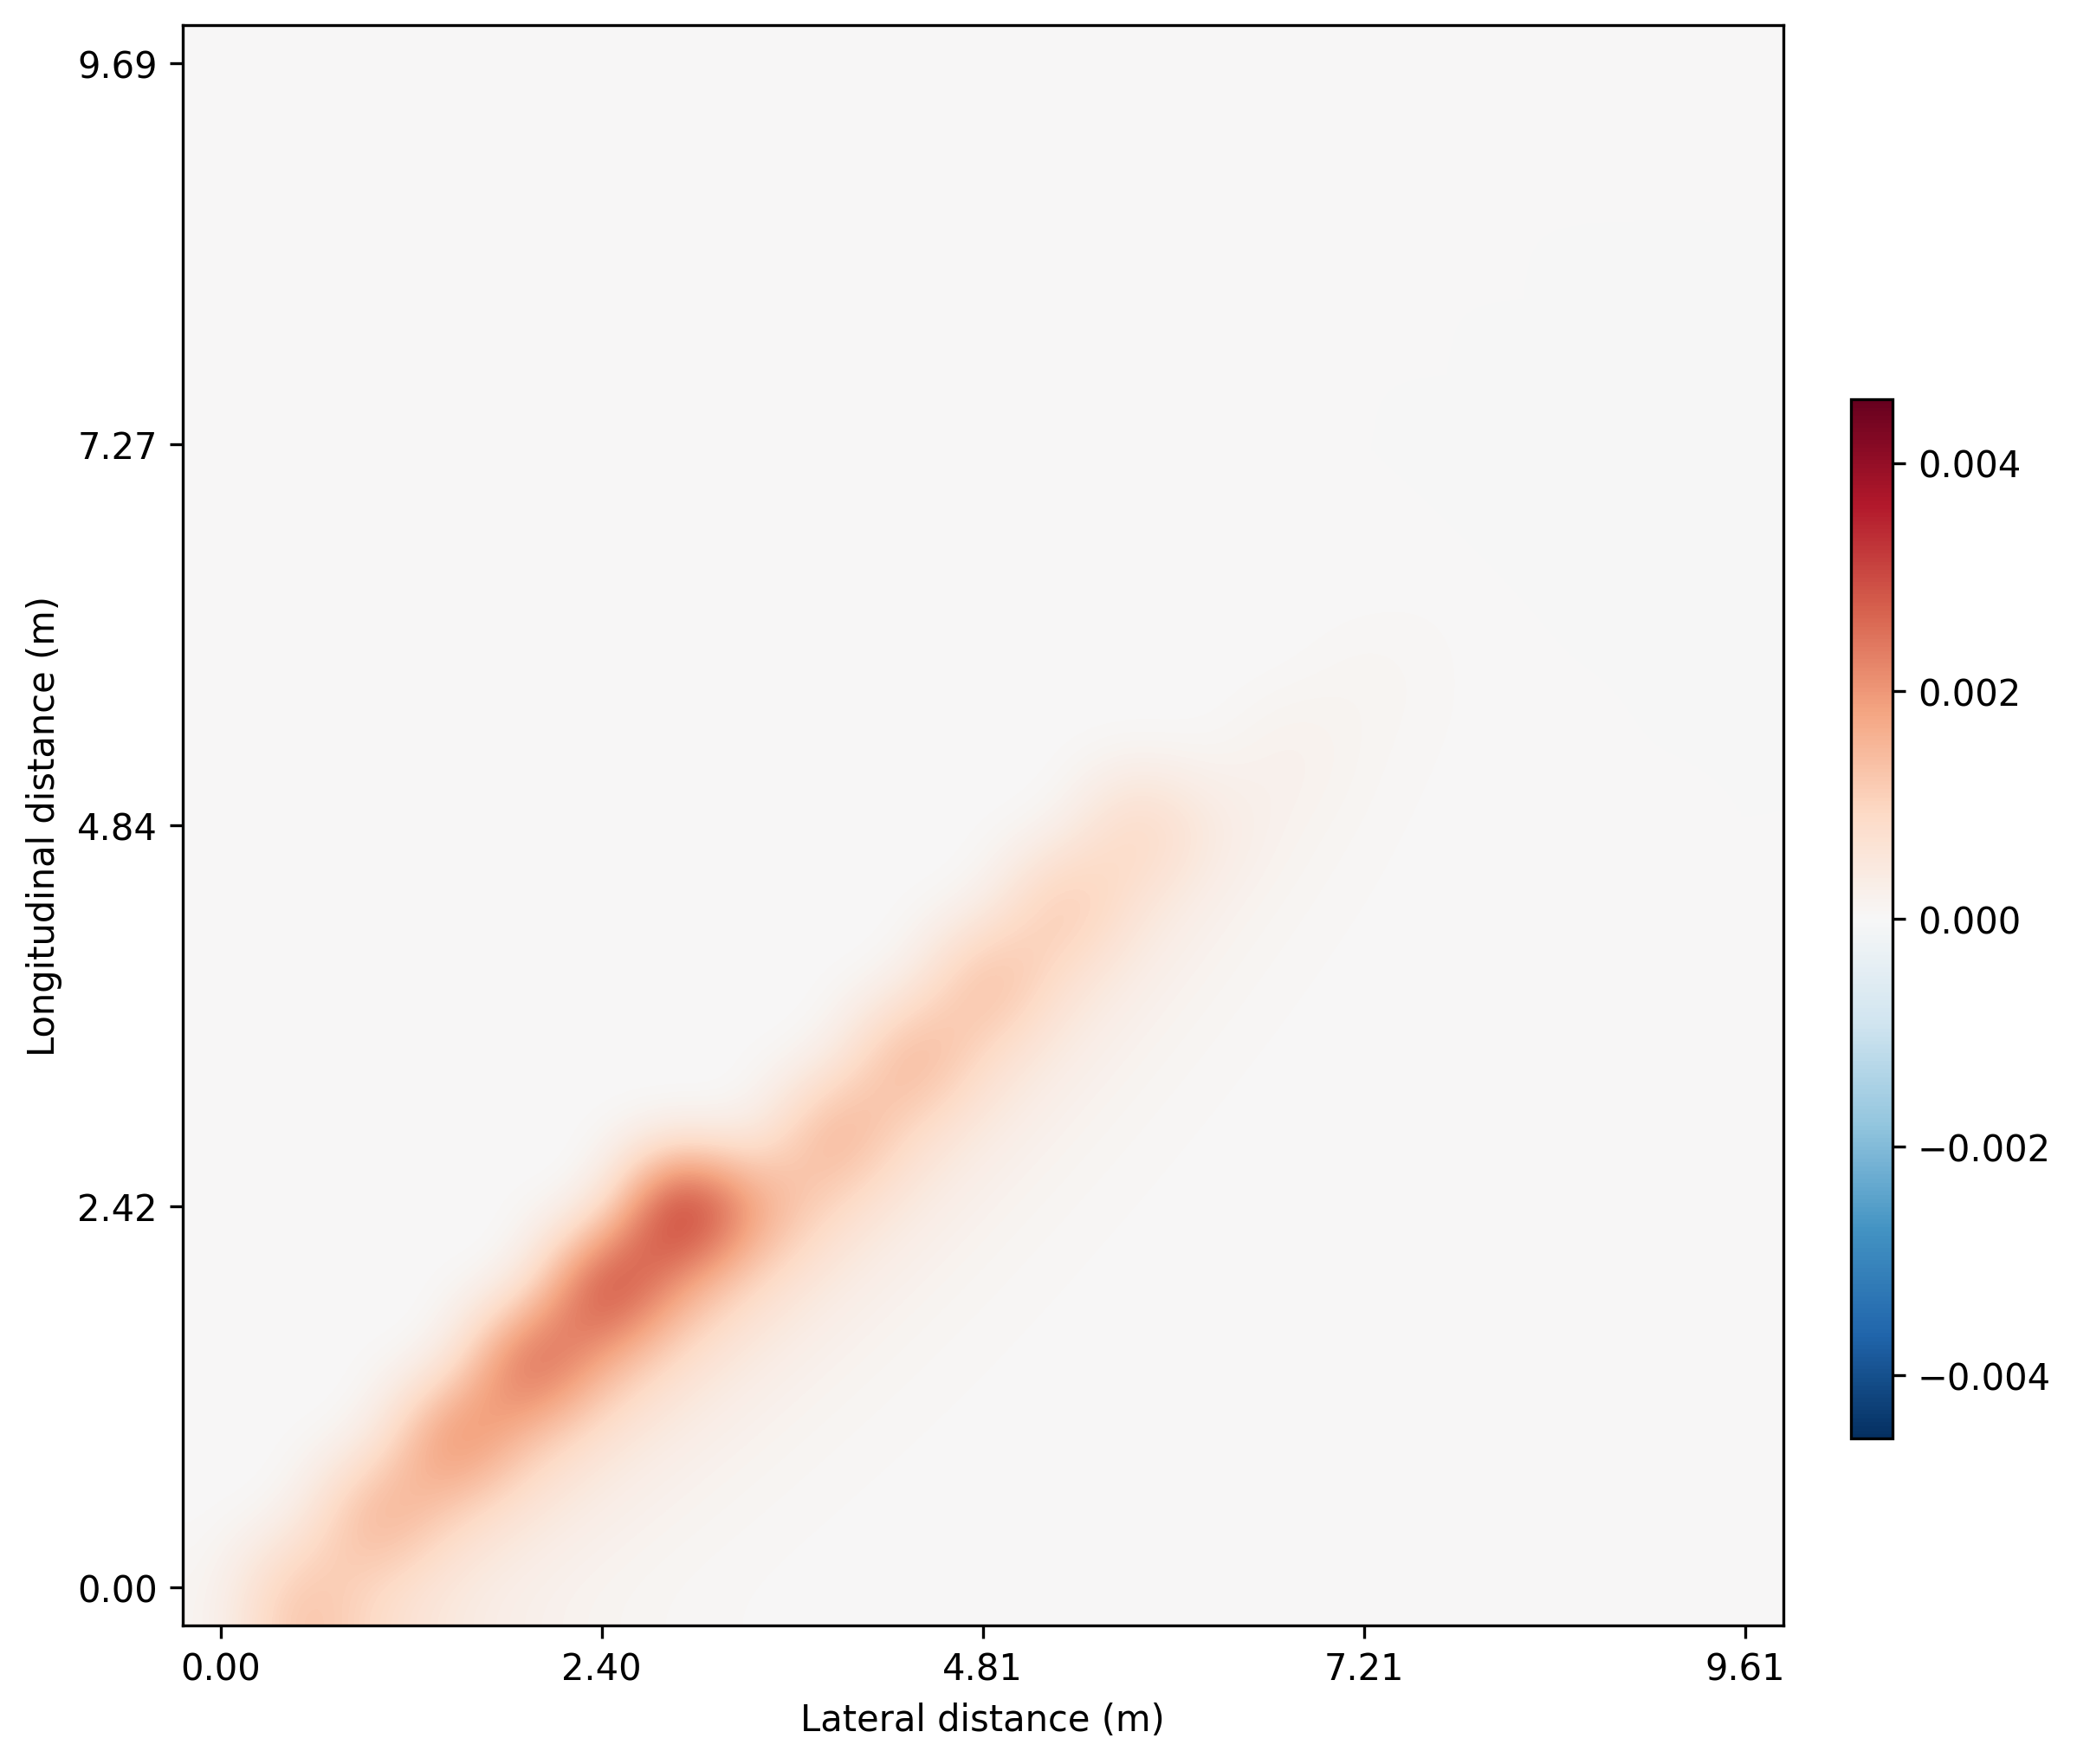

In [33]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
vmax = np.abs(record_test1_five - record_test1).max()
plt.imshow(record_test1_five - record_test1, cmap='RdBu_r', interpolation='bicubic', vmax=vmax, vmin=-vmax)
plt.xlabel('Lateral distance (m)')
plt.ylabel('Longitudinal distance (m)')
plt.xticks(np.arange(0,21,5),[f"{i * gap_x / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*gap_y / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gapy-gapx-five.jpg')

plt.show()


In [34]:
## 横距离、横速度
record_test2_five = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        state_flat, all_state = env.reset()
        original_position = (gap_x  * (20 - changey) / 10 , gap_y)

        # 半径
        radius = 1  # 可以根据需要调整

        # 计算五个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 6)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angle), original_position[1] + radius * np.sin(angle)) for angle in angles]

        # 包含原行人在内，总共六个人
        all_positions = [original_position] + new_positions

        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian * changex / 10 
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = gap_x * (20 - changey) / 10
        position_y_pedestrian = gap_y
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 6
        vehicle_num = 6

        # 行人状态设置
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1:, 0] = all_state[0][0][0, 0]
        all_state[0][0][1:, 1] = all_state[0][0][0, 1]
        all_state[0][0][1:, 2] = all_state[0][0][0, 2]
        all_state[0][0][1:, 3] = v_x_pedestrian
        all_state[0][0][1:, 4] = v_y_pedestrian
        all_state[0][0][1:, 5] = a_x_pedestrian
        all_state[0][0][1:, 6] = a_y_pedestrian
        all_state[0][0][1:, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        # all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        # all_state[0][2][1:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1:, :]  = np.array(new_positions)

        ## 车辆位置设置
        # all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        # state_flat[8:48] = 0
        # state_flat[64:96] = 0
        # state_flat[98:108] = 0
        # state_flat[112:] = 0

        ## 行人设置
        state_flat[0:48:8] = state_flat[0]
        state_flat[1:48:8] = state_flat[1]
        state_flat[2:48:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:48:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:48:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:48:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:48:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:48:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:108] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test2_five[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/1982611842.py:131: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


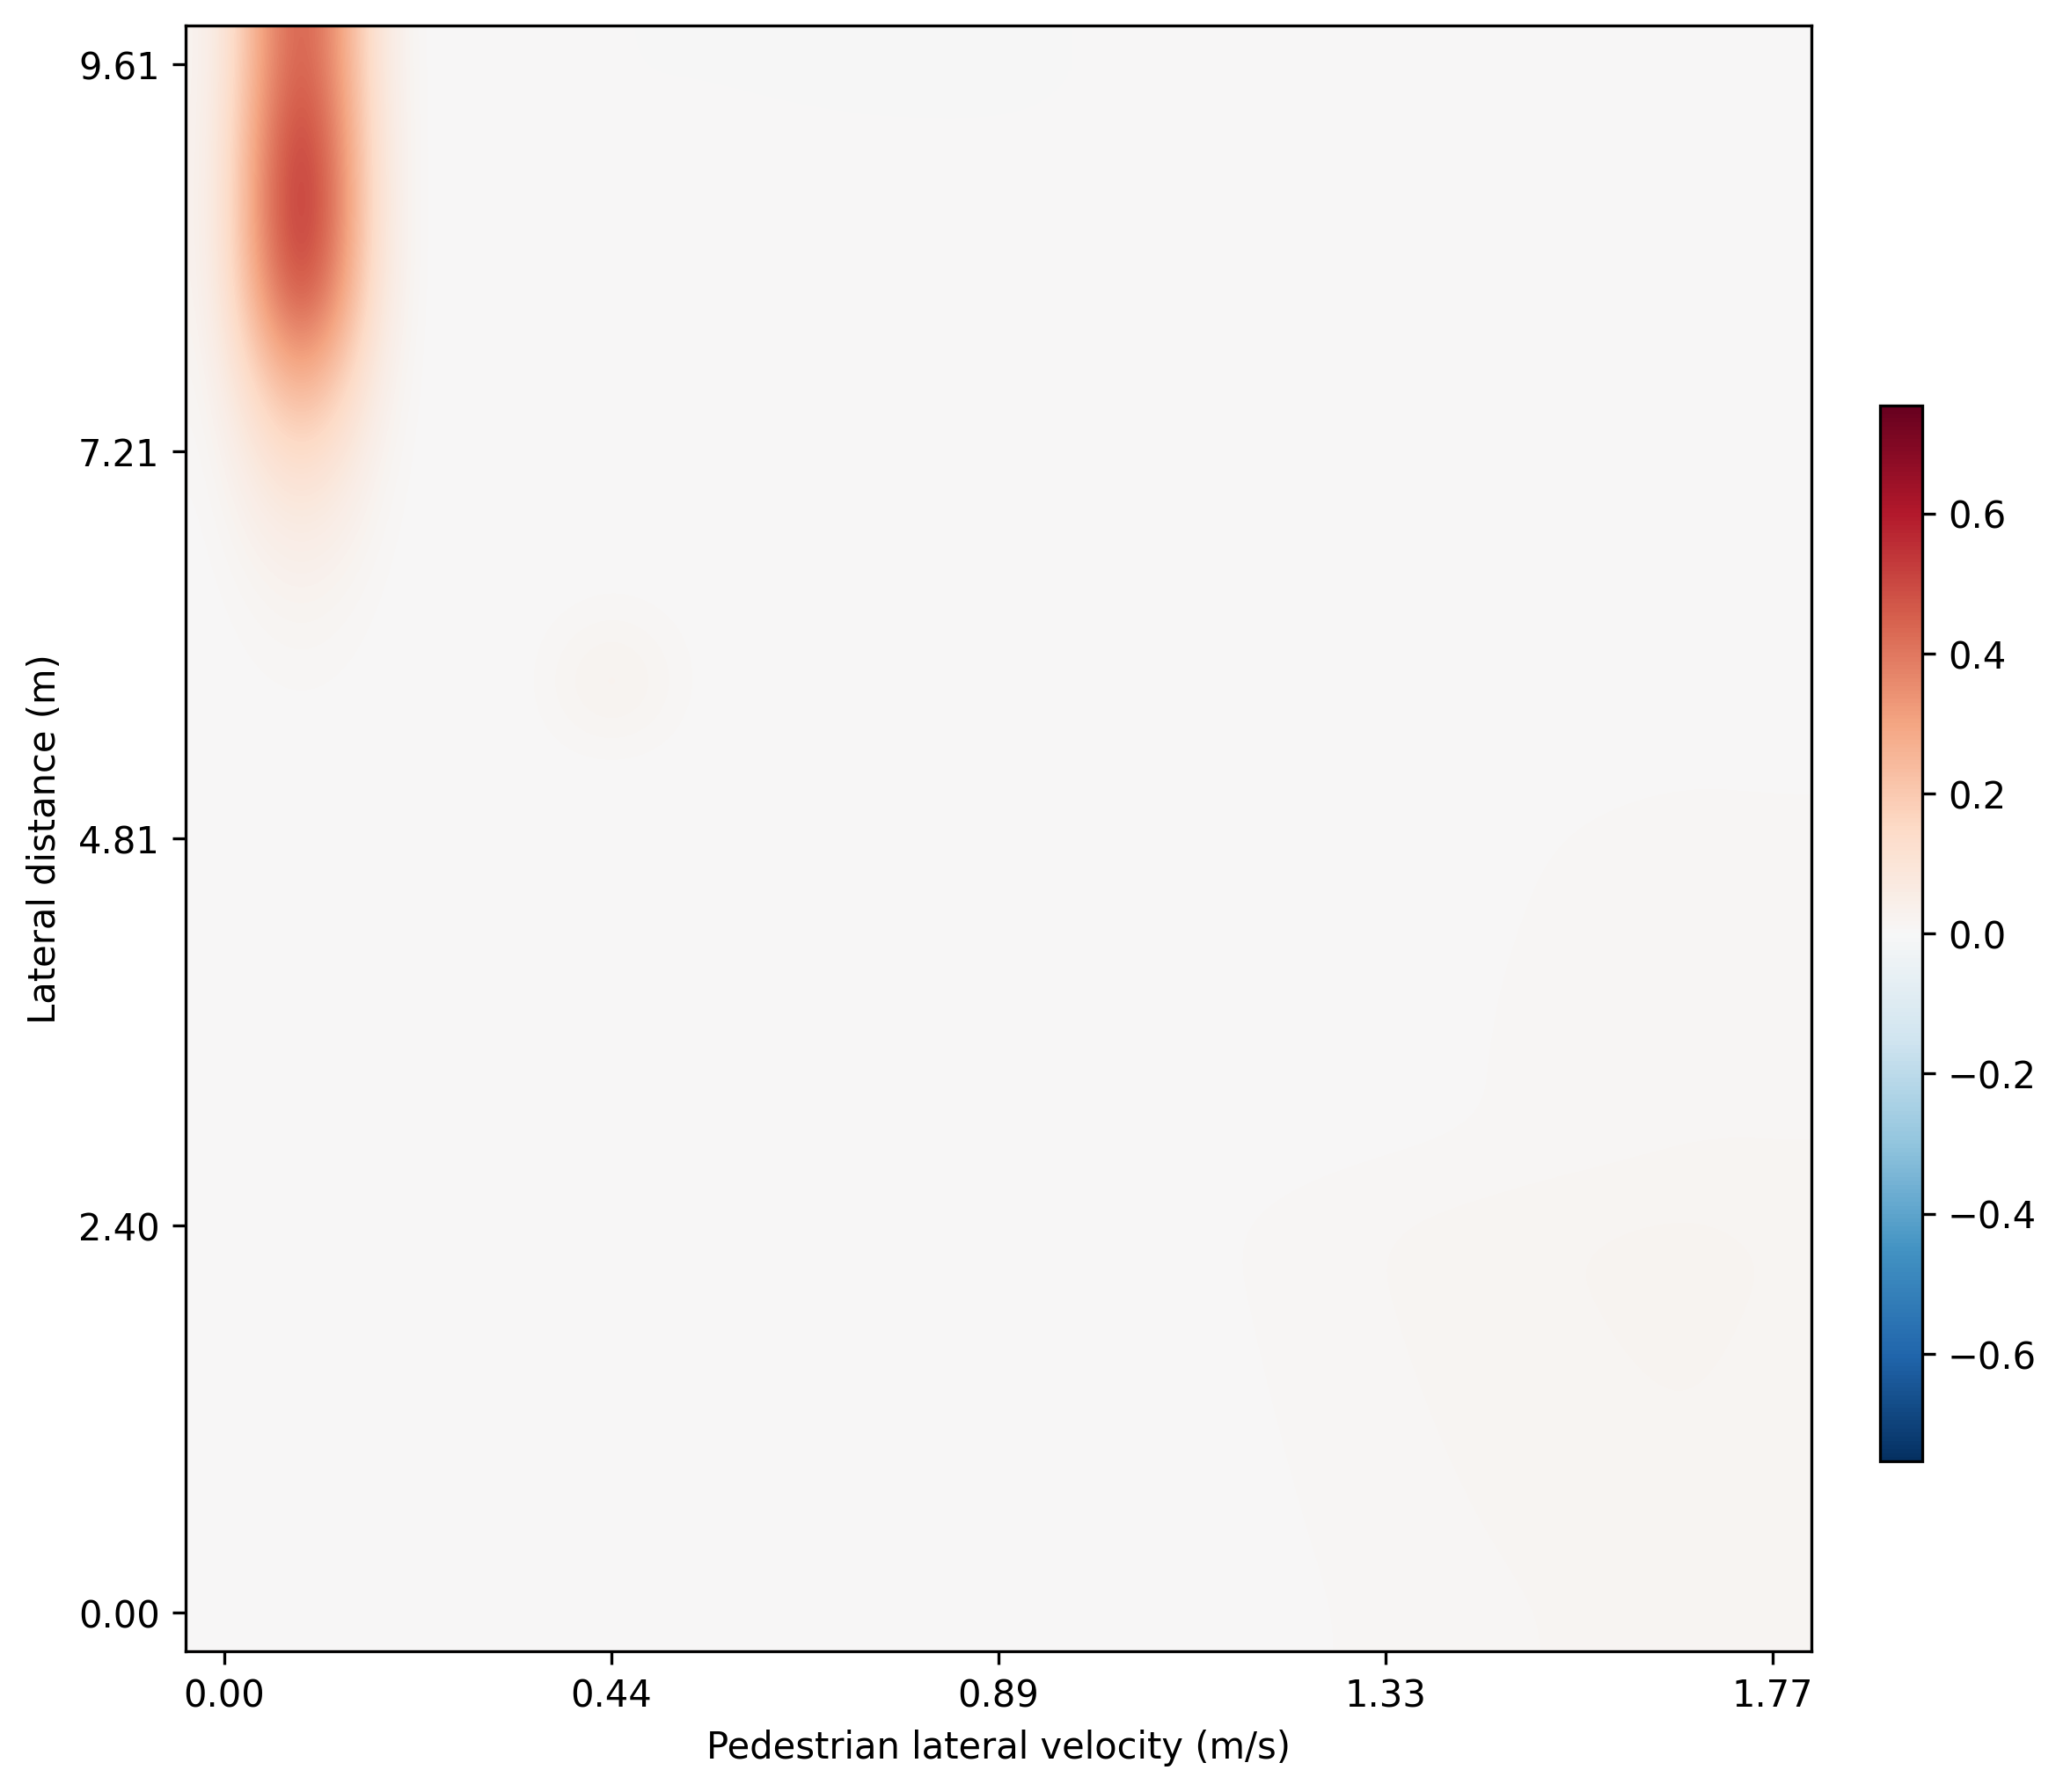

In [35]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
vmax = np.abs(record_test2_five - record_test2).max()
plt.imshow(record_test2_five - record_test2, cmap='RdBu_r', interpolation='bicubic', vmax=vmax, vmin=-vmax)
plt.xlabel('Pedestrian lateral velocity (m/s)')
plt.ylabel('Lateral distance (m)')
plt.xticks(np.arange(0,21,5),[f"{i * v_x_pedestrian / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*gap_x / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gapx-vpx-five.jpg')

plt.show()


In [36]:
## 纵距离、纵速度
record_test3_five = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        state_flat, all_state = env.reset()
        original_position = (gap_x , gap_y * (20 - changey) / 10)

        # 半径
        radius = 1  # 可以根据需要调整

        # 计算五个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 6)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angle), original_position[1] + radius * np.sin(angle)) for angle in angles]

        # 包含原行人在内，总共六个人
        all_positions = [original_position] + new_positions

        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian * changex / 10 
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = gap_x
        position_y_pedestrian = gap_y * (20 - changey) / 10
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 6
        vehicle_num = 6

        # 行人状态设置
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1:, 0] = all_state[0][0][0, 0]
        all_state[0][0][1:, 1] = all_state[0][0][0, 1]
        all_state[0][0][1:, 2] = all_state[0][0][0, 2]
        all_state[0][0][1:, 3] = v_x_pedestrian
        all_state[0][0][1:, 4] = v_y_pedestrian
        all_state[0][0][1:, 5] = a_x_pedestrian
        all_state[0][0][1:, 6] = a_y_pedestrian
        all_state[0][0][1:, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        # all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        # all_state[0][2][1:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1:, :]  = np.array(new_positions)

        ## 车辆位置设置
        # all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        # state_flat[8:48] = 0
        # state_flat[64:96] = 0
        # state_flat[98:108] = 0
        # state_flat[112:] = 0

        ## 行人设置
        state_flat[0:48:8] = state_flat[0]
        state_flat[1:48:8] = state_flat[1]
        state_flat[2:48:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:48:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:48:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:48:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:48:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:48:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:108] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test3_five[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/4135902045.py:131: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


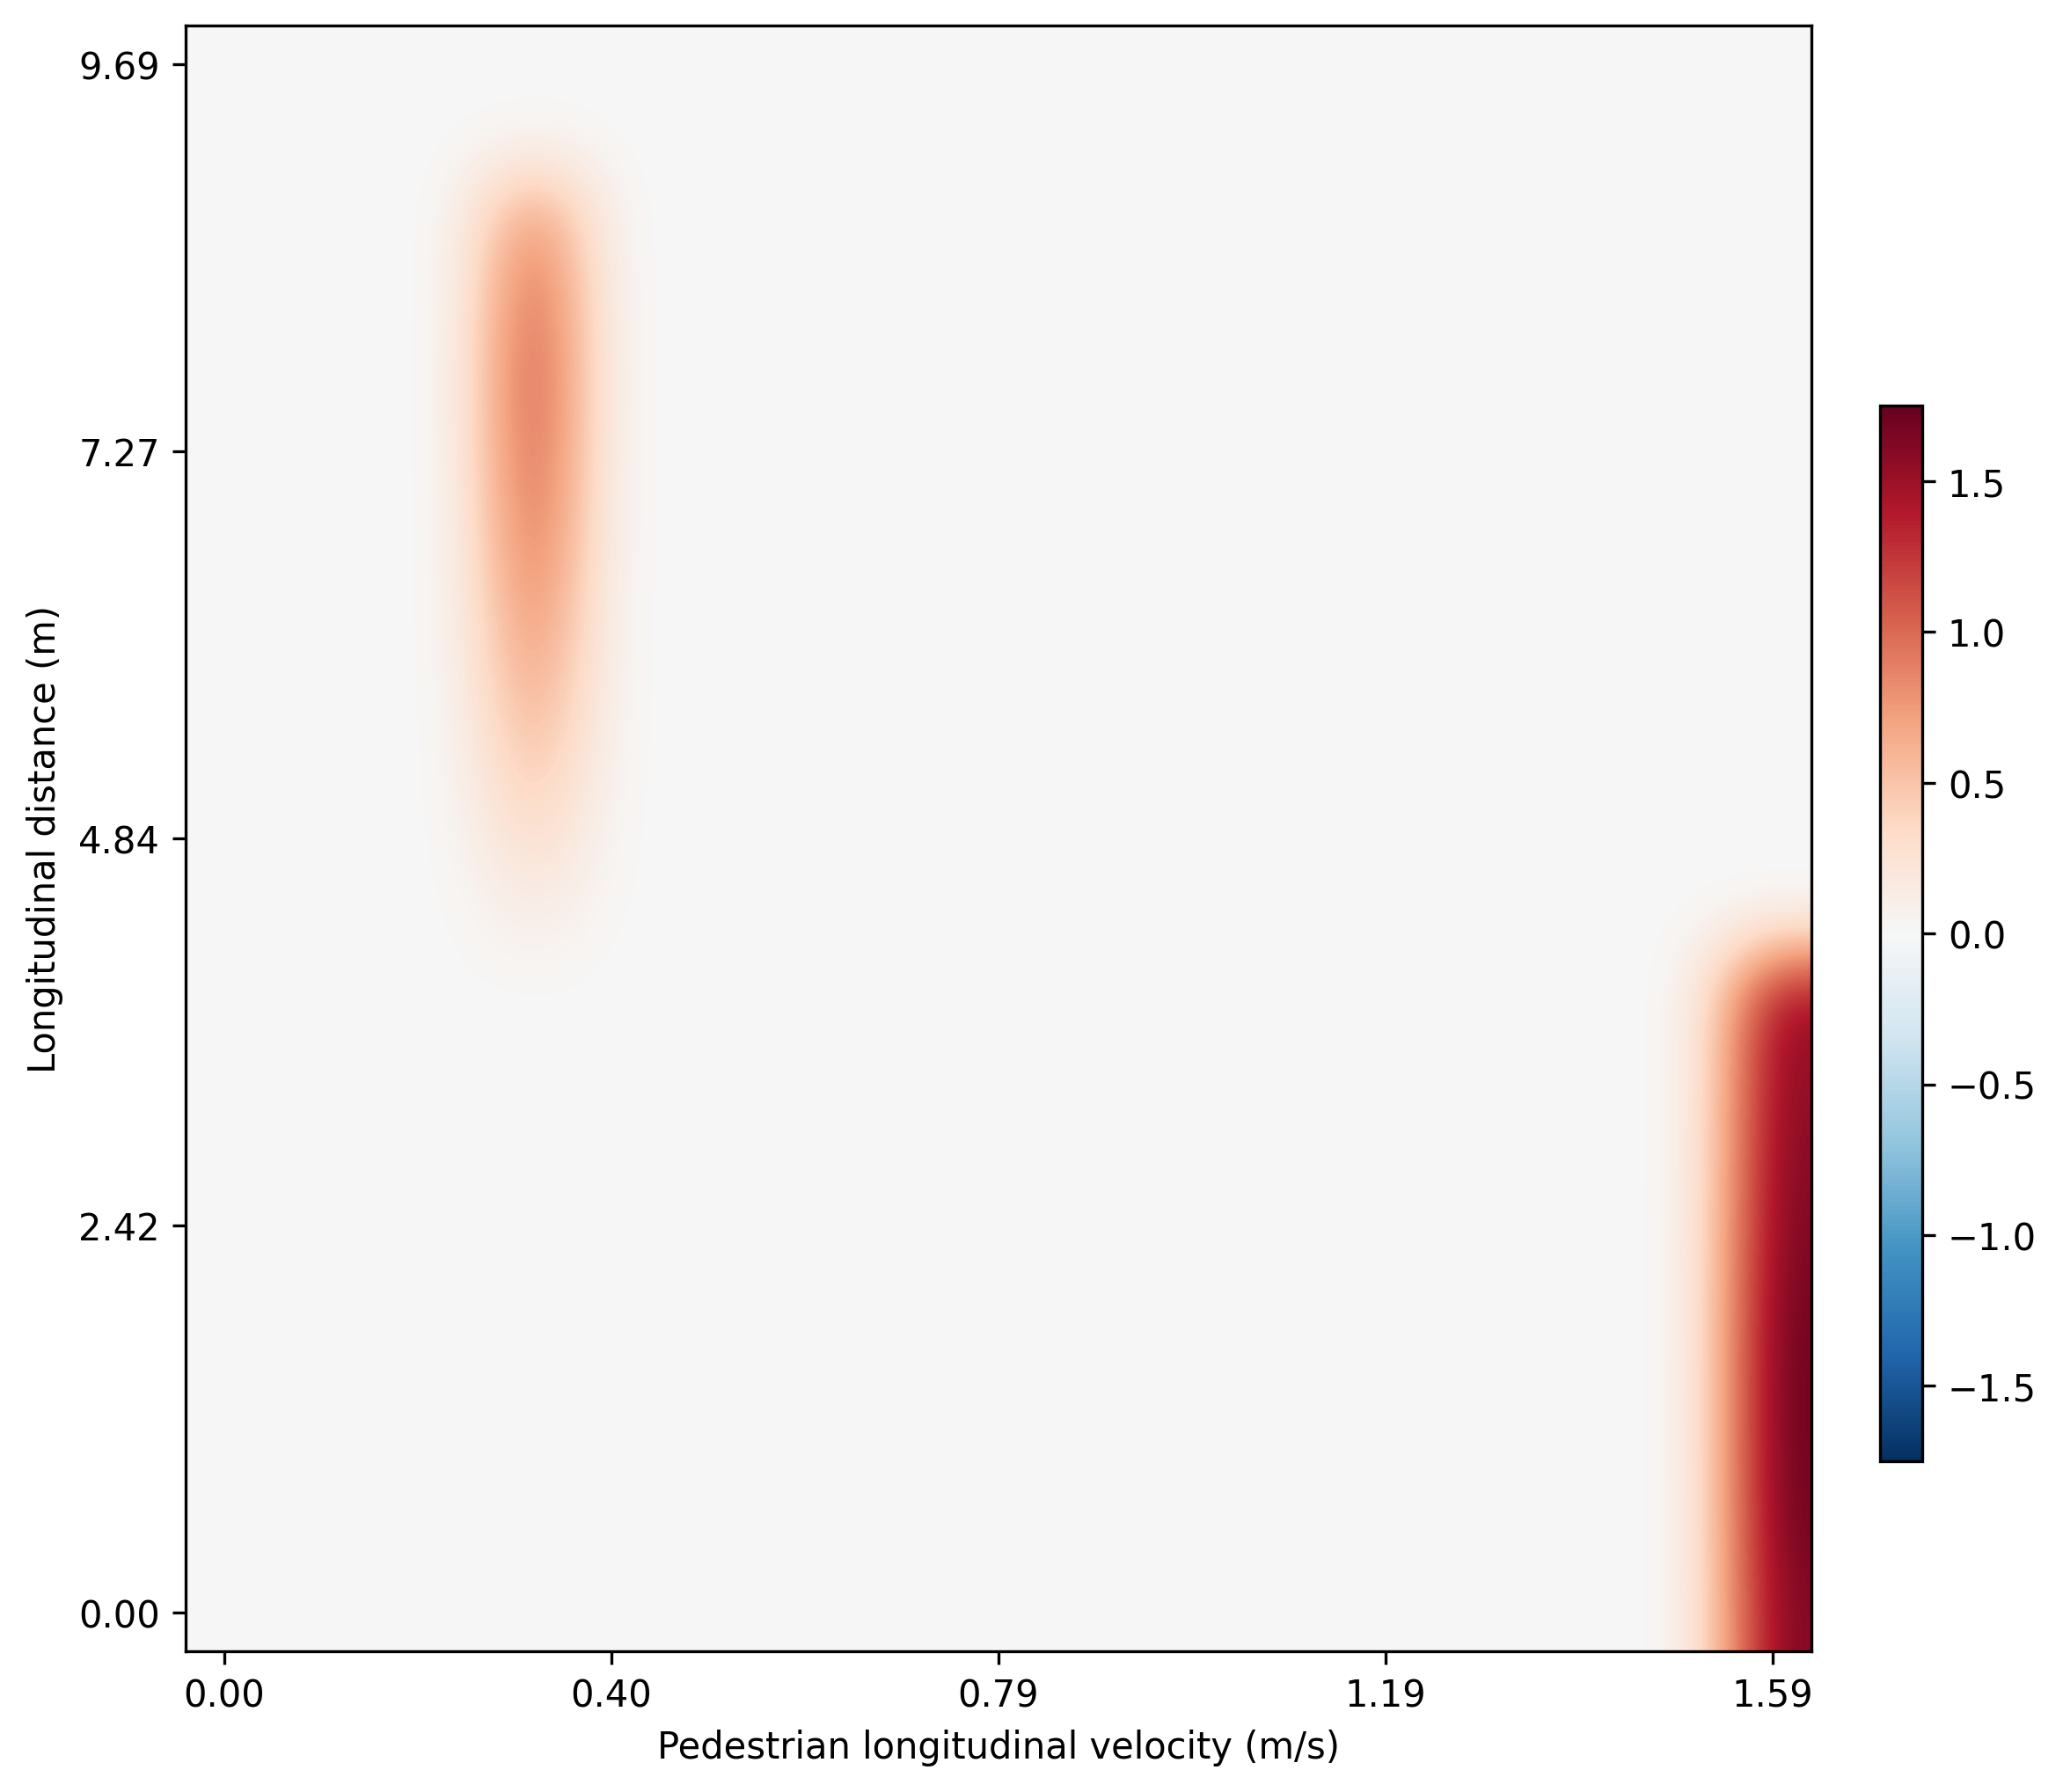

In [37]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
vmax = np.abs(record_test3_five - record_test3).max()
plt.imshow(record_test3_five - record_test3, cmap='RdBu_r', interpolation='bicubic', vmax=vmax, vmin=-vmax)
plt.xlabel('Pedestrian longitudinal velocity (m/s)')
plt.ylabel('Longitudinal distance (m)')
plt.xticks(np.arange(0,21,5),[f"{i * v_y_pedestrian / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*gap_y / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gapy-vpy-five.jpg')

plt.show()


In [38]:
## 车横速度、横距离
record_test4_five = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        state_flat, all_state = env.reset()
        original_position = (gap_x * changex / 10  , gap_y )

        # 半径
        radius = 1  # 可以根据需要调整

        # 计算五个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 6)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angle), original_position[1] + radius * np.sin(angle)) for angle in angles]

        # 包含原行人在内，总共六个人
        all_positions = [original_position] + new_positions

        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle* (20 - changey) / 10
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = gap_x * changex / 10
        position_y_pedestrian = gap_y
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 6
        vehicle_num = 6

        # 行人状态设置
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1:, 0] = all_state[0][0][0, 0]
        all_state[0][0][1:, 1] = all_state[0][0][0, 1]
        all_state[0][0][1:, 2] = all_state[0][0][0, 2]
        all_state[0][0][1:, 3] = v_x_pedestrian
        all_state[0][0][1:, 4] = v_y_pedestrian
        all_state[0][0][1:, 5] = a_x_pedestrian
        all_state[0][0][1:, 6] = a_y_pedestrian
        all_state[0][0][1:, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        # all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        # all_state[0][2][1:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1:, :]  = np.array(new_positions)

        ## 车辆位置设置
        # all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        # state_flat[8:48] = 0
        # state_flat[64:96] = 0
        # state_flat[98:108] = 0
        # state_flat[112:] = 0

        ## 行人设置
        state_flat[0:48:8] = state_flat[0]
        state_flat[1:48:8] = state_flat[1]
        state_flat[2:48:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:48:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:48:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:48:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:48:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:48:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:108] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test4_five[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/1501572265.py:131: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


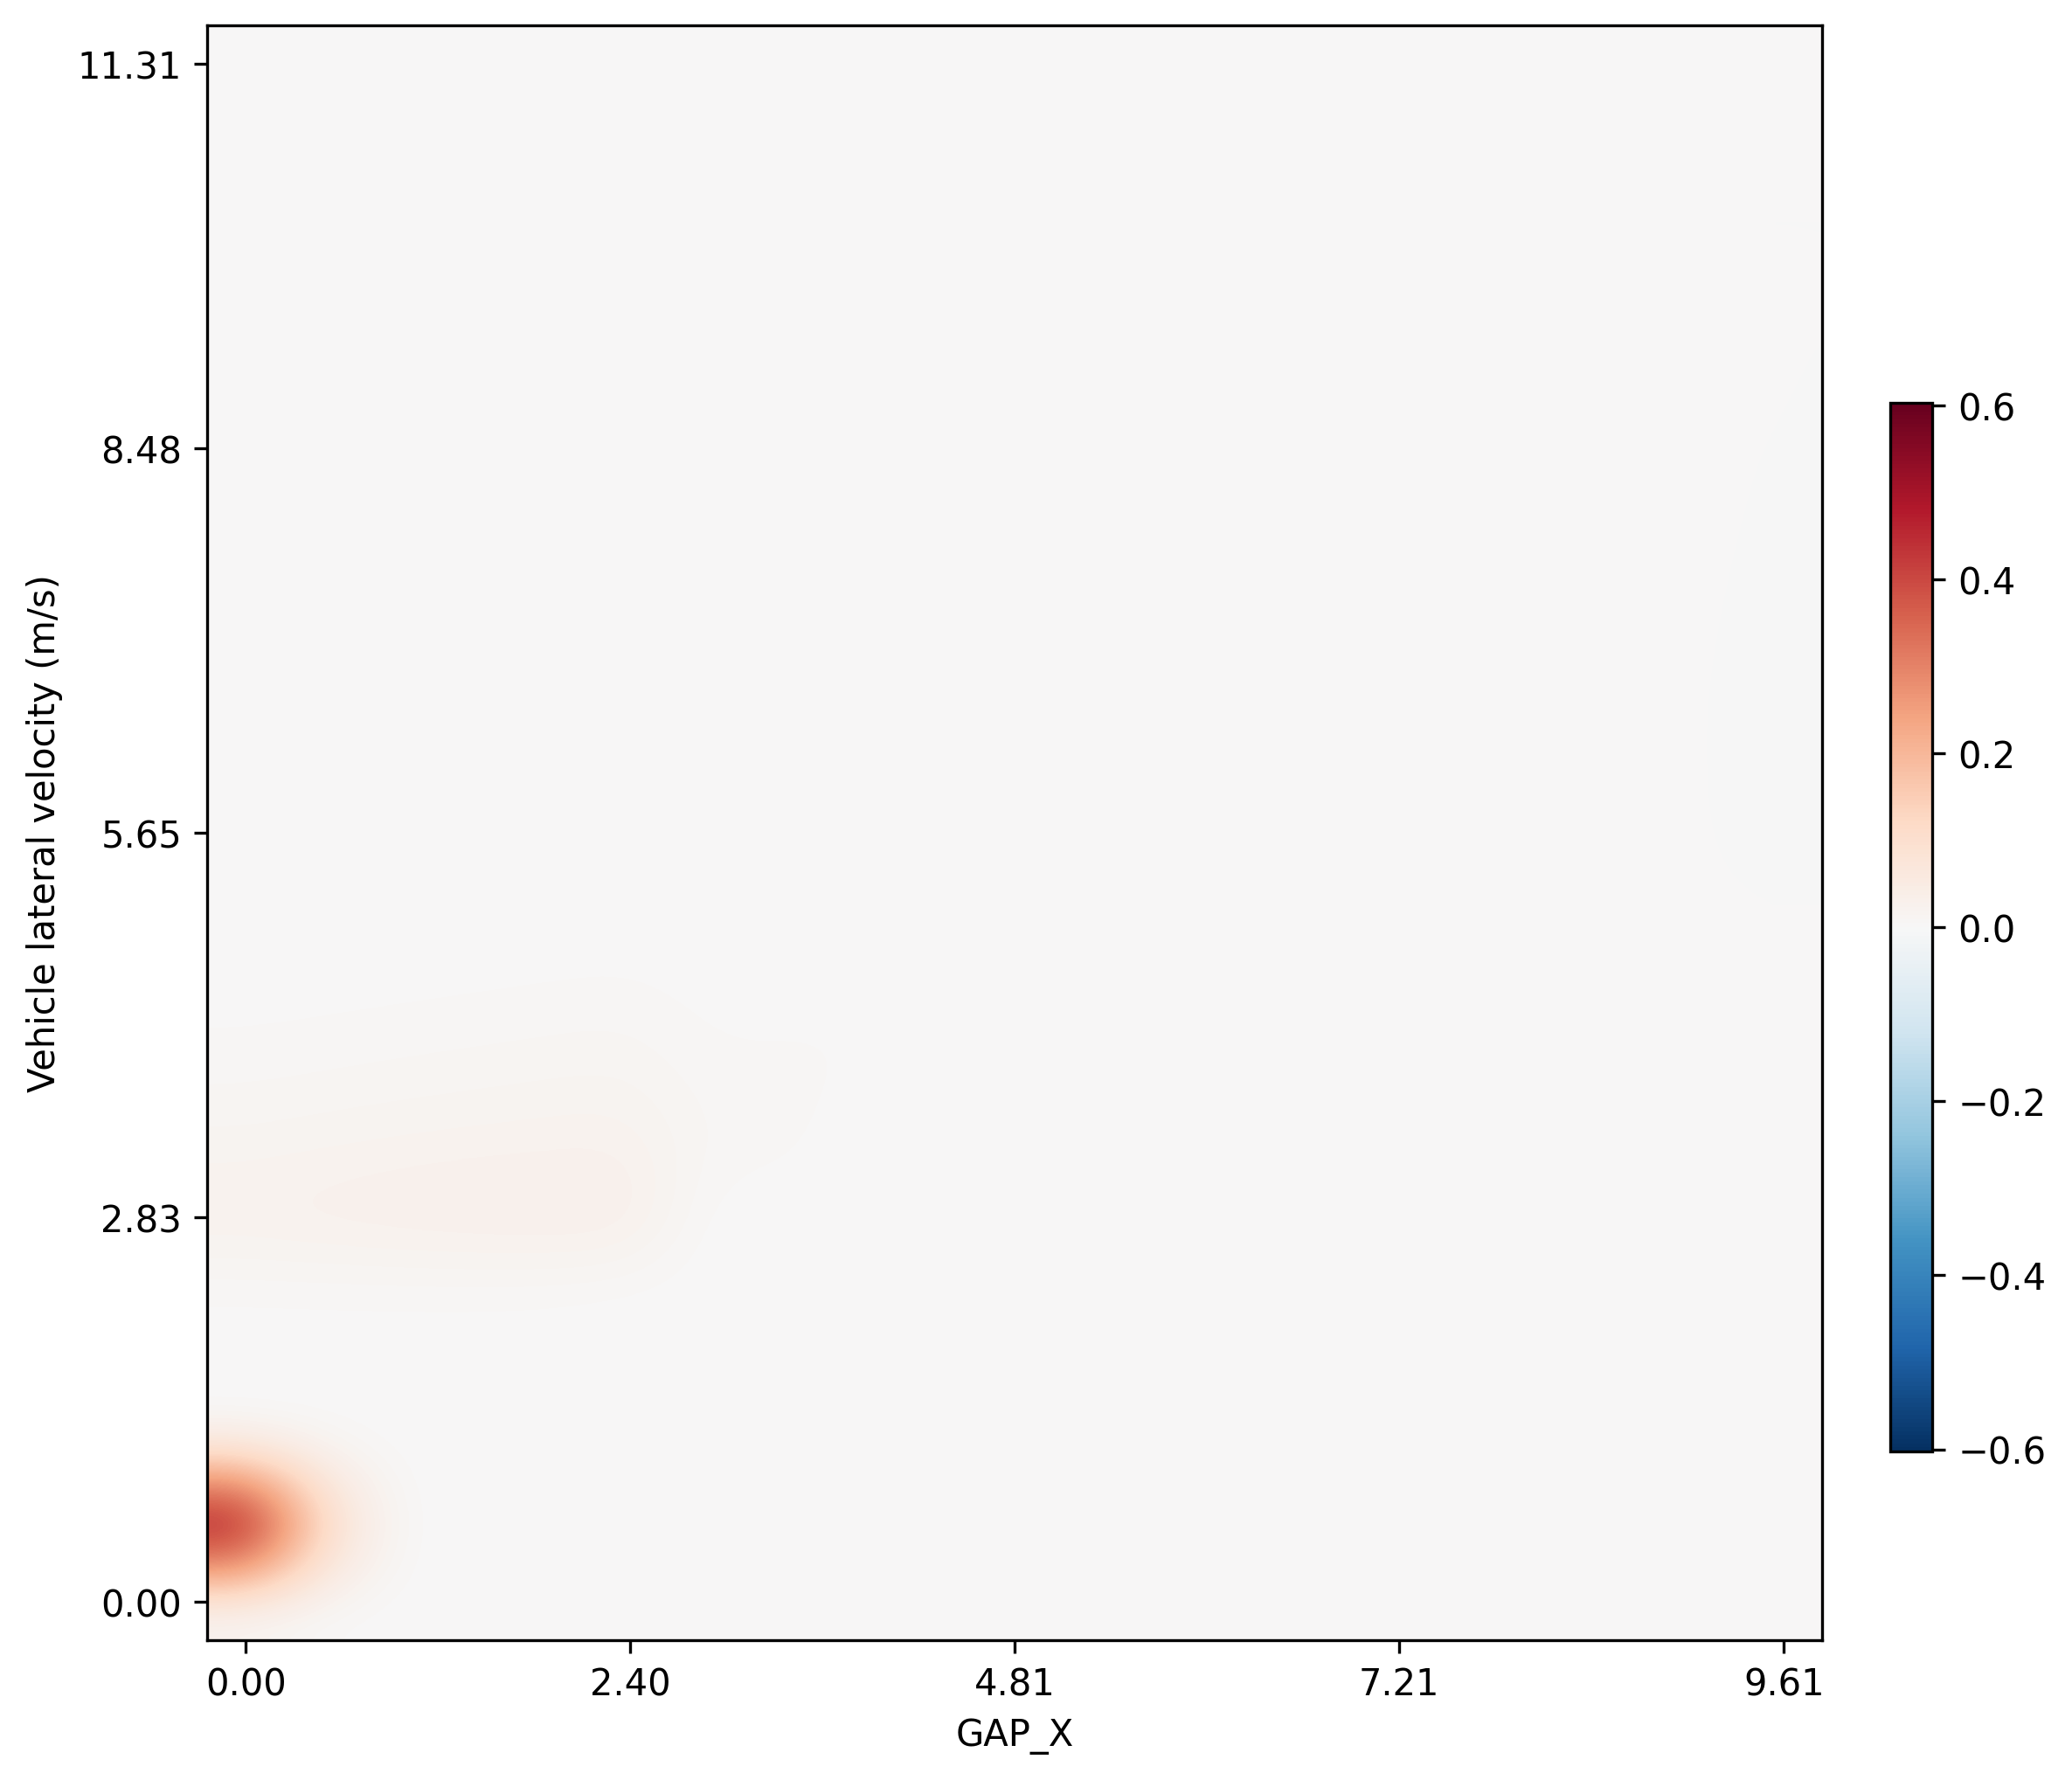

In [39]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
vmax = np.abs(record_test4_five - record_test_4).max()
plt.imshow(record_test4_five - record_test_4, cmap='RdBu_r', interpolation='bicubic', vmax=vmax, vmin=-vmax)
plt.xlabel('GAP_X')
plt.ylabel('Vehicle lateral velocity (m/s)')
plt.xticks(np.arange(0,21,5),[f"{i * gap_x / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*v_x_vehicle / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/vvx-gapx-five.jpg')

plt.show()


In [40]:
## 车纵速度、纵距离
record_test5_five = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        state_flat, all_state = env.reset()
        original_position = (gap_x , gap_y * changex / 10)

        # 半径
        radius = 1  # 可以根据需要调整

        # 计算五个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 6)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angle), original_position[1] + radius * np.sin(angle)) for angle in angles]

        # 包含原行人在内，总共六个人
        all_positions = [original_position] + new_positions

        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle * (20 - changey) / 10

        position_x_pedestrian = gap_x 
        position_y_pedestrian = gap_y * changex / 10
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 6
        vehicle_num = 6

        # 行人状态设置
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1:, 0] = all_state[0][0][0, 0]
        all_state[0][0][1:, 1] = all_state[0][0][0, 1]
        all_state[0][0][1:, 2] = all_state[0][0][0, 2]
        all_state[0][0][1:, 3] = v_x_pedestrian
        all_state[0][0][1:, 4] = v_y_pedestrian
        all_state[0][0][1:, 5] = a_x_pedestrian
        all_state[0][0][1:, 6] = a_y_pedestrian
        all_state[0][0][1:, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        # all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        # all_state[0][2][1:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1:, :]  = np.array(new_positions)

        ## 车辆位置设置
        # all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        # state_flat[8:48] = 0
        # state_flat[64:96] = 0
        # state_flat[98:108] = 0
        # state_flat[112:] = 0

        ## 行人设置
        state_flat[0:48:8] = state_flat[0]
        state_flat[1:48:8] = state_flat[1]
        state_flat[2:48:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:48:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:48:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:48:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:48:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:48:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:108] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test5_five[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/2591624587.py:131: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


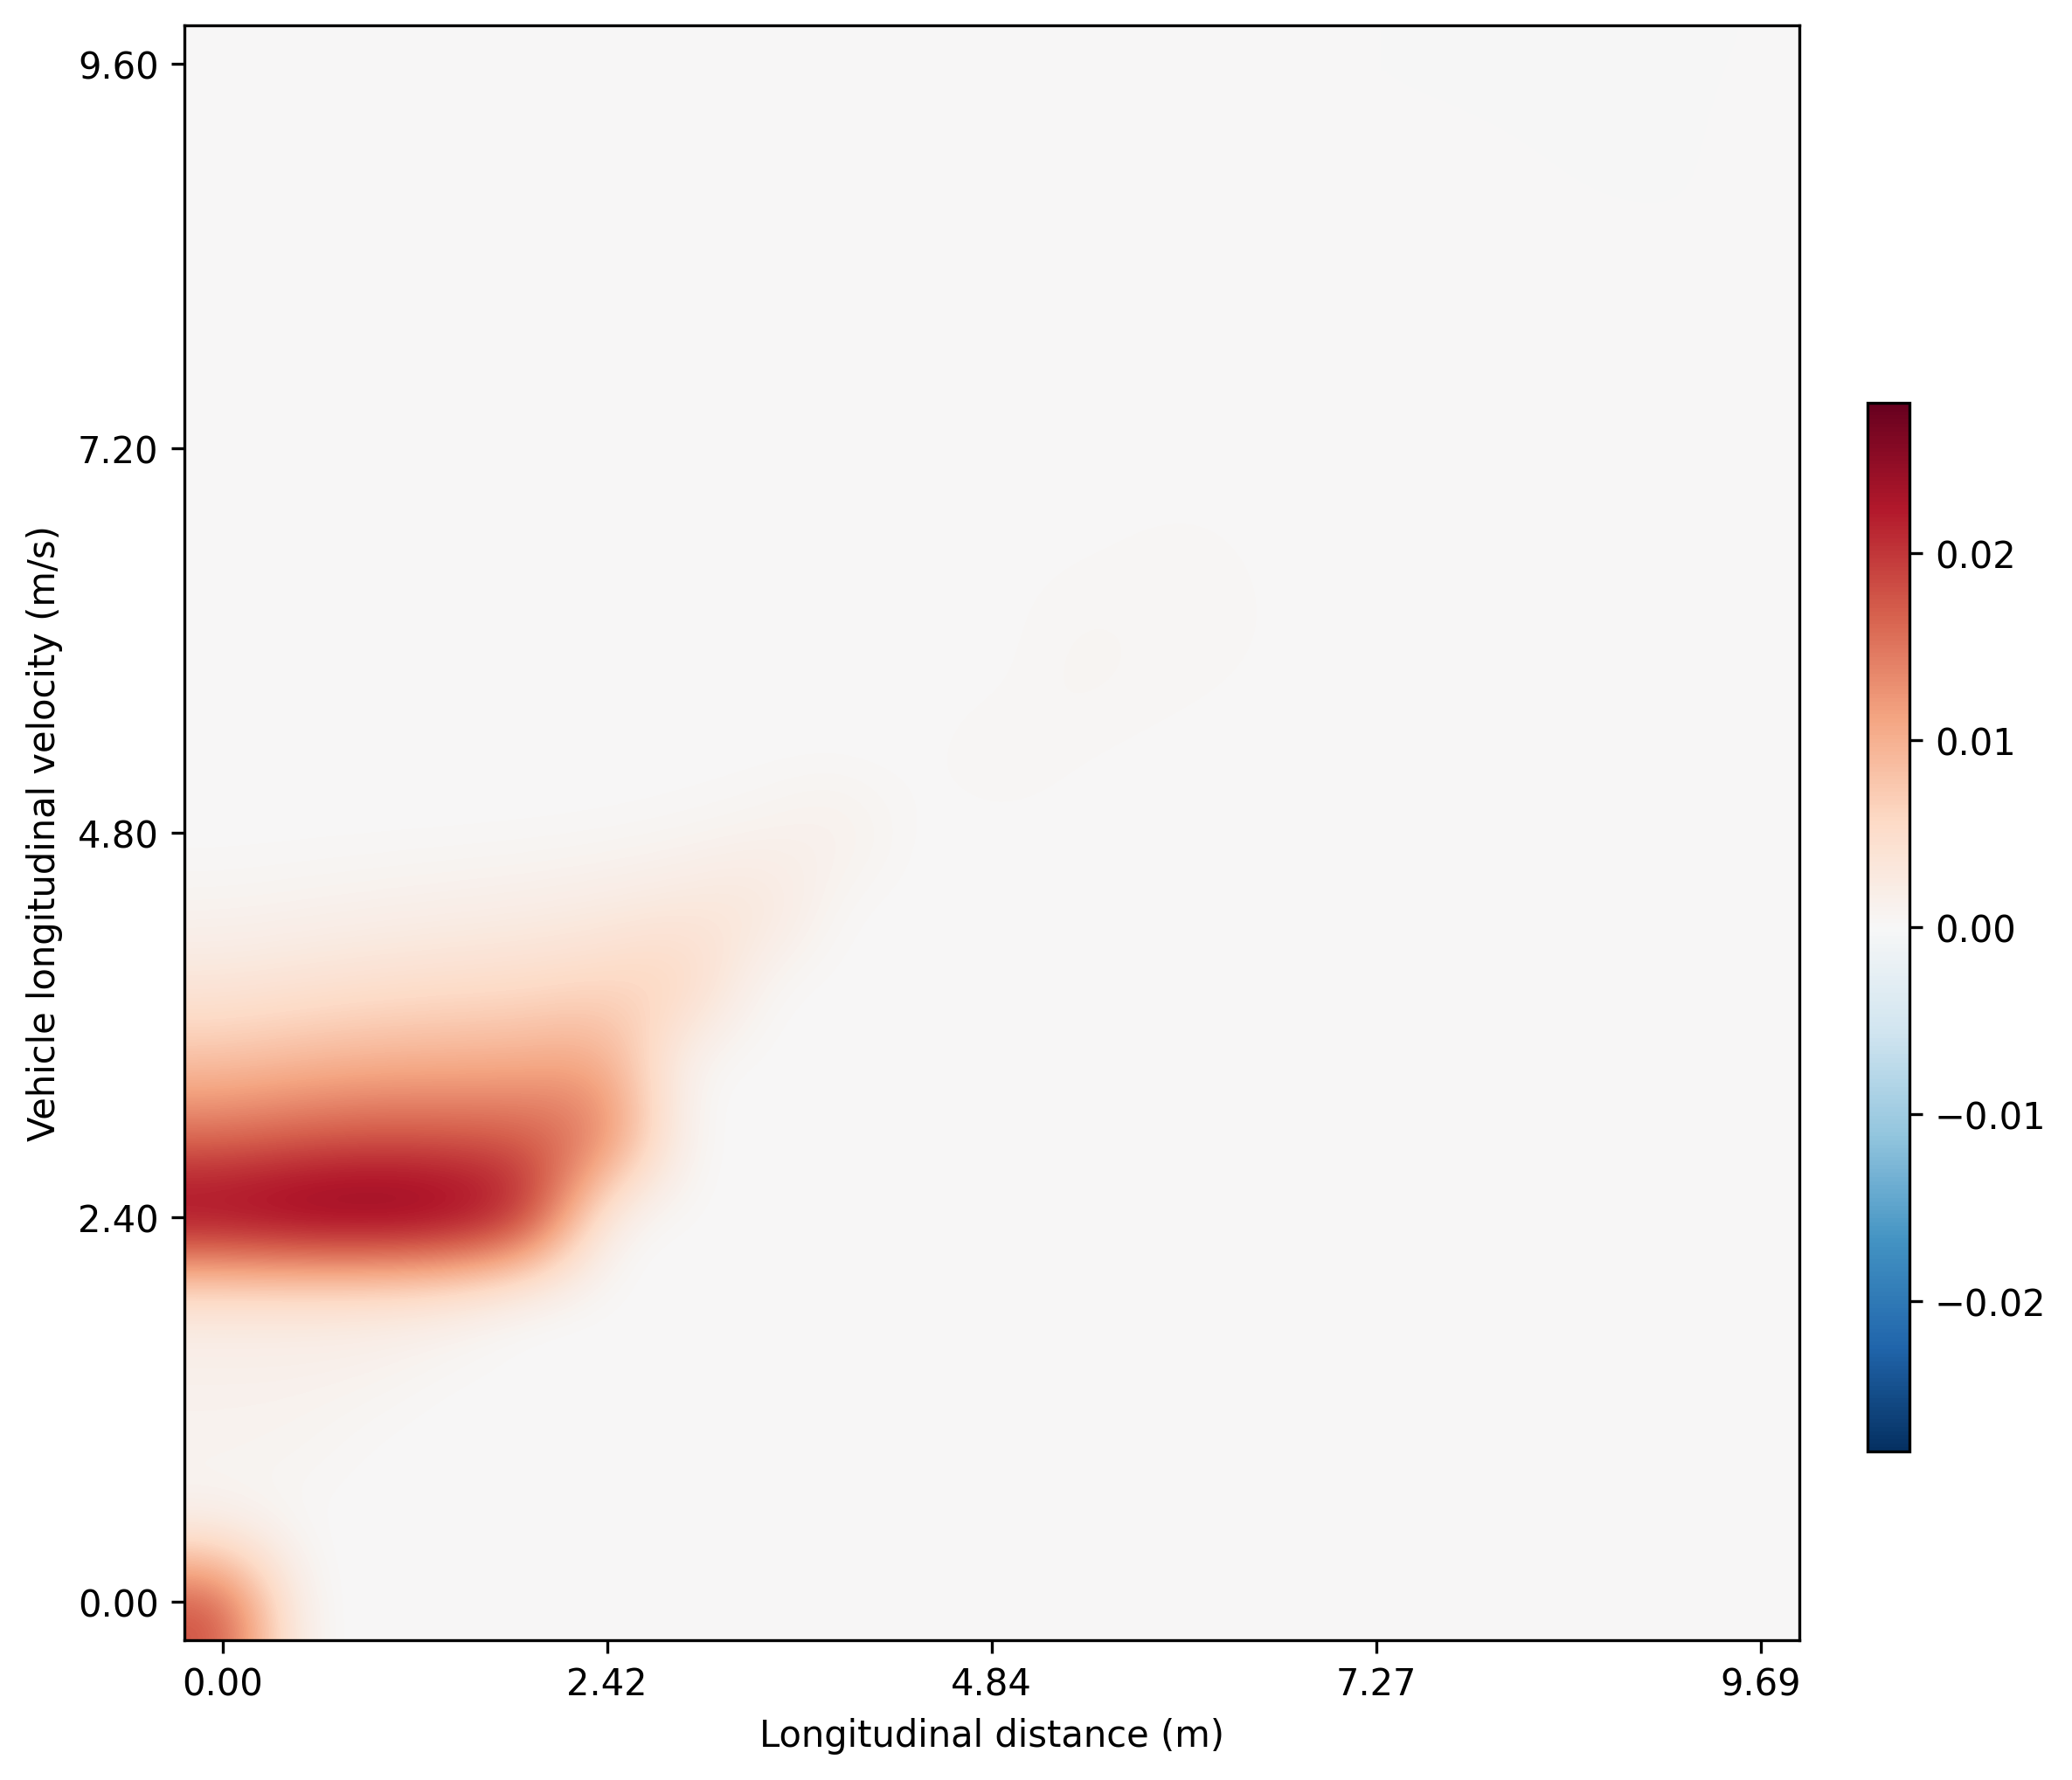

In [41]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
vmax = np.abs(record_test5_five - record_test5).max()
plt.imshow(record_test5_five - record_test5, cmap='RdBu_r', interpolation='bicubic', vmax=vmax, vmin=-vmax)
plt.xlabel('Longitudinal distance (m)')
plt.ylabel('Vehicle longitudinal velocity (m/s)')
plt.xticks(np.arange(0,21,5),[f"{i * gap_y / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*v_y_vehicle / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/vvy-gapy-five.jpg')

plt.show()


## 四等环绕

In [42]:
## 纵向距离，横向距离
record_test1_four = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        import numpy as np

        # 假设原行人的位置为 (gap_x, gap_y)
        original_position = (gap_x * (changex) / 10, gap_y  * (20 - changey) / 10)

        # 半径
        radius = 1   # 可以根据需要调整

        # 计算四个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 5)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angle), original_position[1] + radius * np.sin(angle)) for angle in angles]

        state_flat, all_state = env.reset()

        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = gap_x * (changex) / 10
        position_y_pedestrian = gap_y  * (20 - changey) / 10
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 5
        vehicle_num = 6

        # 行人状态设置
        all_state[0][0][5:, :] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1:5, 0] = all_state[0][0][0, 0]
        all_state[0][0][1:5, 1] = all_state[0][0][0, 1]
        all_state[0][0][1:5, 2] = all_state[0][0][0, 2]
        all_state[0][0][1:5, 3] = v_x_pedestrian
        all_state[0][0][1:5, 4] = v_y_pedestrian
        all_state[0][0][1:5, 5] = a_x_pedestrian
        all_state[0][0][1:5, 6] = a_y_pedestrian
        all_state[0][0][1:5, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        # all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][5:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1:5, :]  = np.array(new_positions)

        ## 车辆位置设置
        # all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[40:48] = 0
        # state_flat[64:96] = 0
        state_flat[106:108] = 0
        # state_flat[112:] = 0

        ## 行人设置
        state_flat[0:40:8] = state_flat[0]
        state_flat[1:40:8] = state_flat[1]
        state_flat[2:40:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:40:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:40:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:40:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:40:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:40:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:106] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test1_four[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/732298971.py:133: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


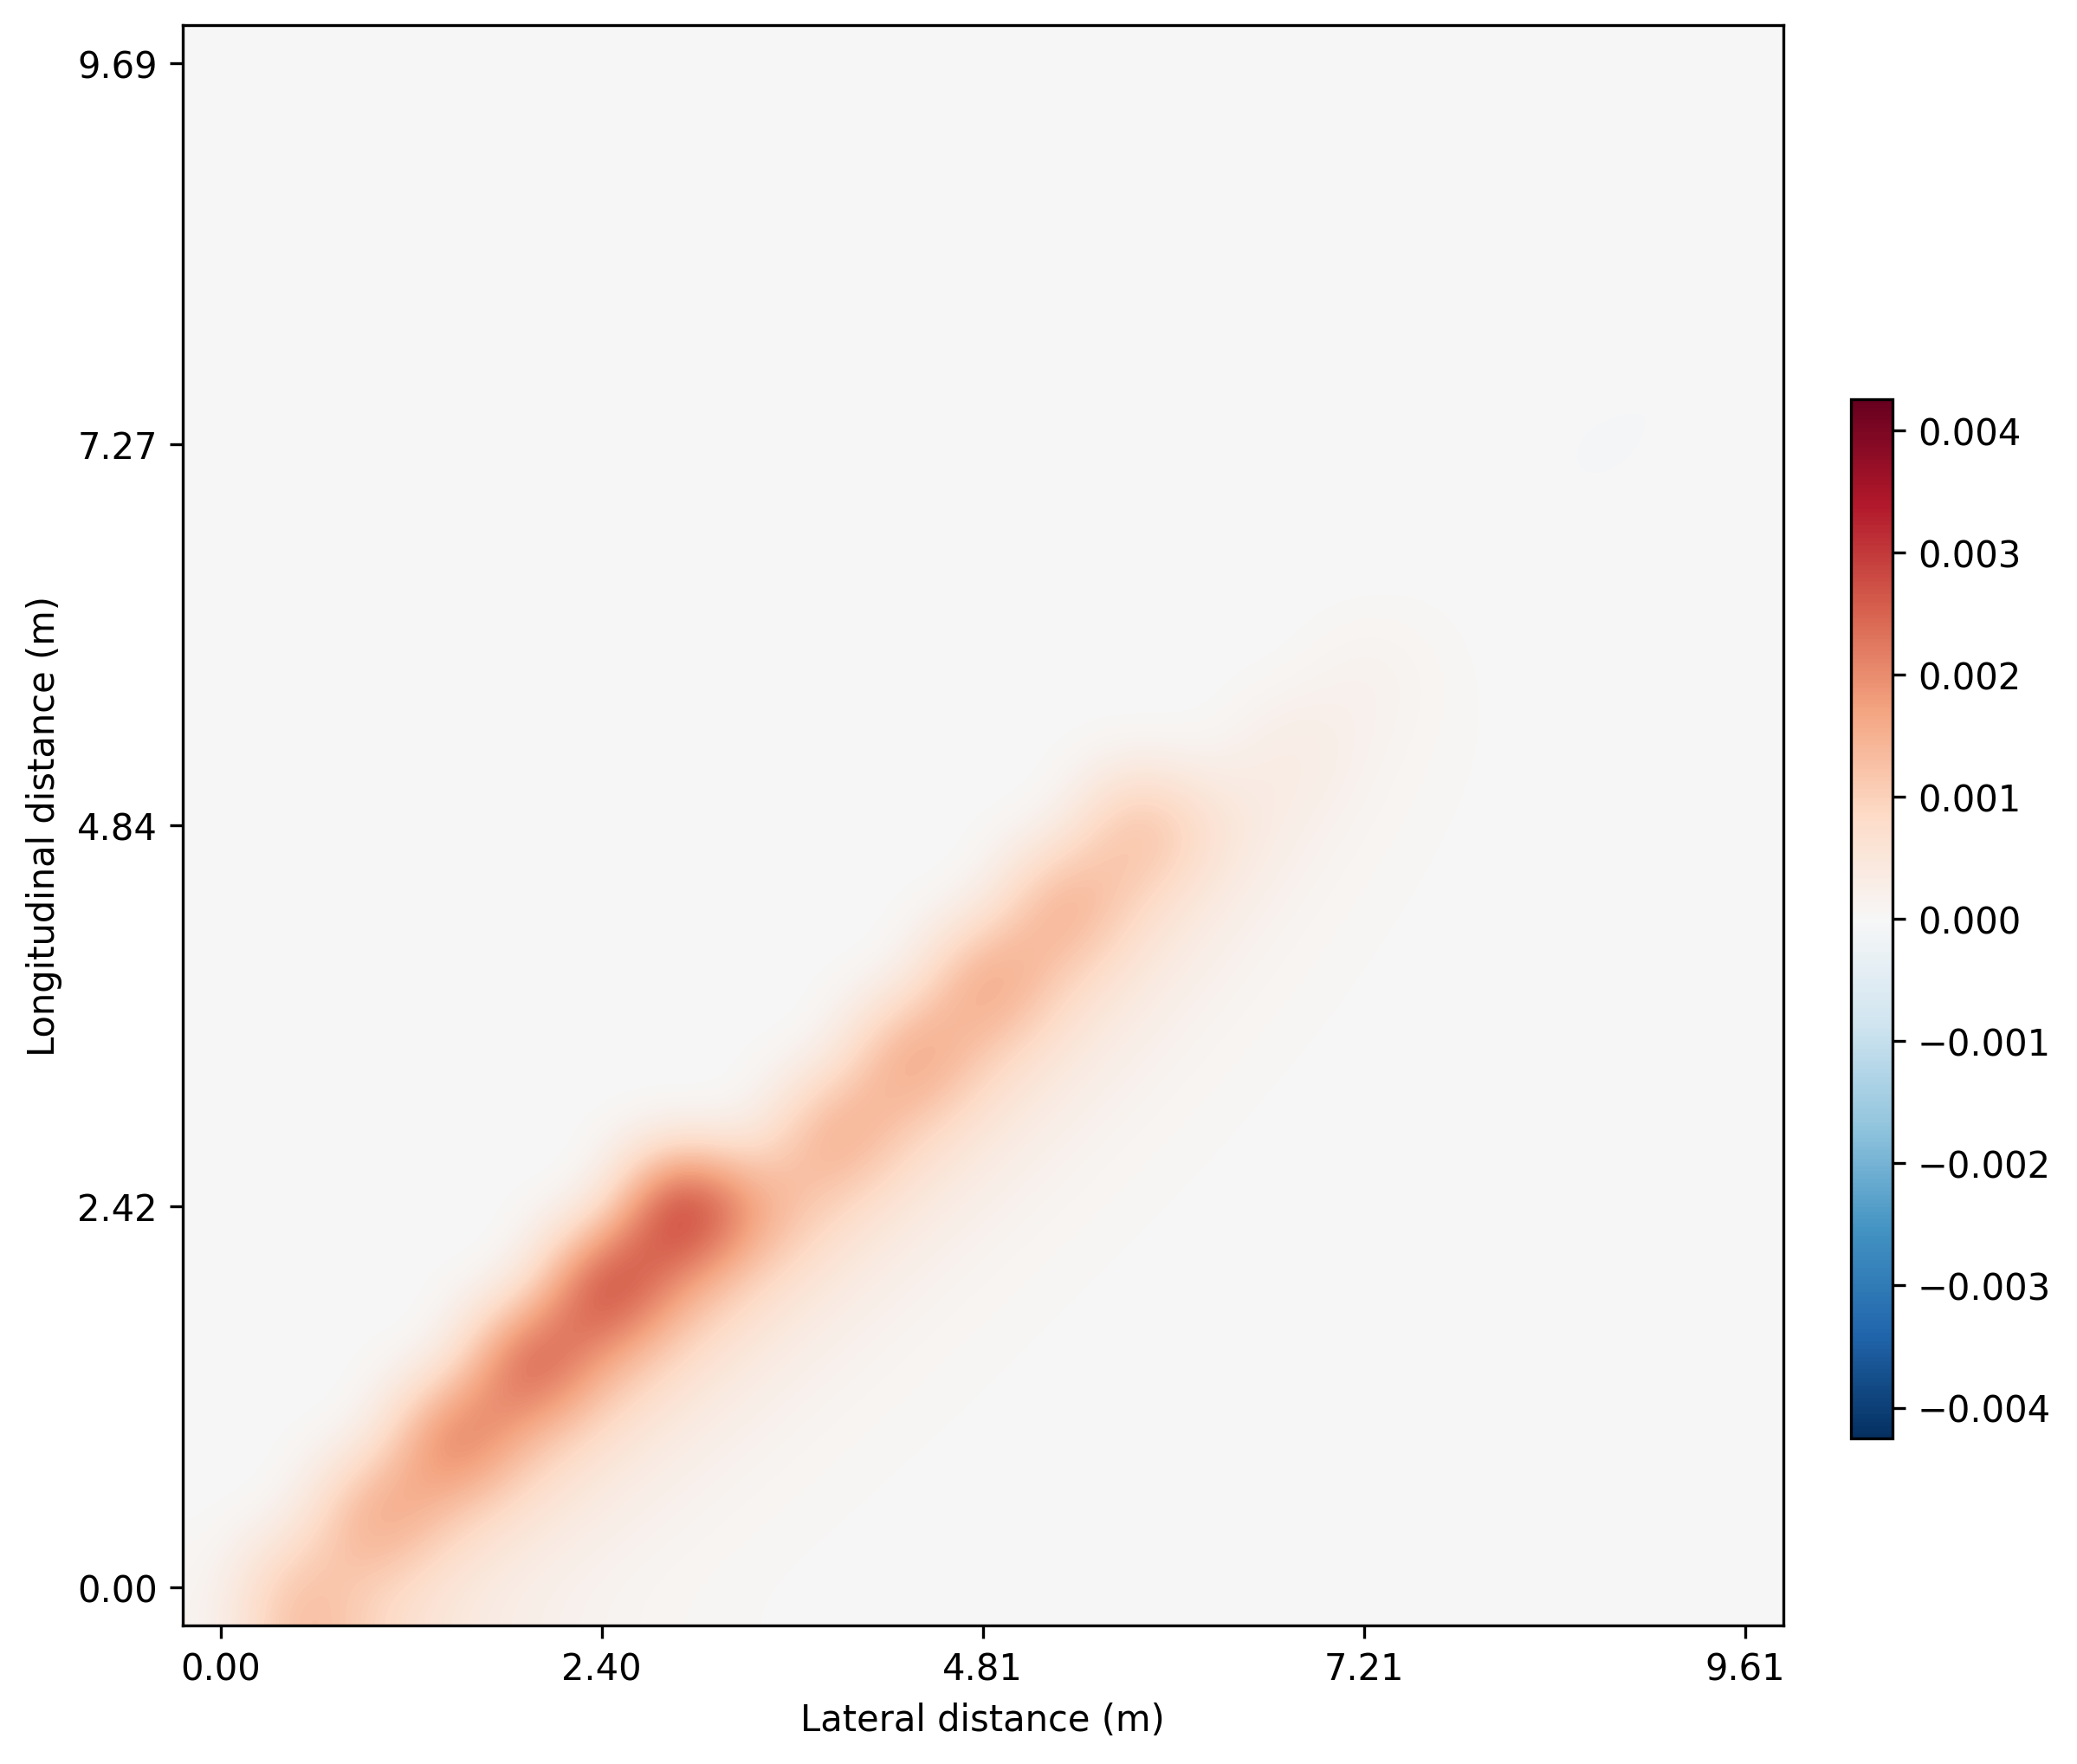

In [43]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
vmax = np.abs(record_test1_four - record_test1).max()
plt.imshow(record_test1_four - record_test1, cmap='RdBu_r', interpolation='bicubic', vmax=vmax, vmin=-vmax)
plt.xlabel('Lateral distance (m)')
plt.ylabel('Longitudinal distance (m)')
plt.xticks(np.arange(0,21,5),[f"{i * gap_x / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*gap_y / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gapy-gapx-four.jpg')

plt.show()


In [44]:
## 横向距离，横向速度
record_test2_four = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        import numpy as np

        # 假设原行人的位置为 (gap_x, gap_y)
        original_position = (gap_x* (20 - changey) / 10, gap_y)

        # 半径
        radius = 1   # 可以根据需要调整

        # 计算四个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 5)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angle), original_position[1] + radius * np.sin(angle)) for angle in angles]

        state_flat, all_state = env.reset()

        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian * (changex) / 10
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = gap_x   * (20 - changey) / 10
        position_y_pedestrian = gap_y 
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 5
        vehicle_num = 6

        # 行人状态设置
        all_state[0][0][5:, :] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1:5, 0] = all_state[0][0][0, 0]
        all_state[0][0][1:5, 1] = all_state[0][0][0, 1]
        all_state[0][0][1:5, 2] = all_state[0][0][0, 2]
        all_state[0][0][1:5, 3] = v_x_pedestrian
        all_state[0][0][1:5, 4] = v_y_pedestrian
        all_state[0][0][1:5, 5] = a_x_pedestrian
        all_state[0][0][1:5, 6] = a_y_pedestrian
        all_state[0][0][1:5, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        # all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][5:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1:5, :]  = np.array(new_positions)

        ## 车辆位置设置
        # all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[40:48] = 0
        # state_flat[64:96] = 0
        state_flat[106:108] = 0
        # state_flat[112:] = 0

        ## 行人设置
        state_flat[0:40:8] = state_flat[0]
        state_flat[1:40:8] = state_flat[1]
        state_flat[2:40:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:40:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:40:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:40:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:40:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:40:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:106] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test2_four[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/89943828.py:133: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


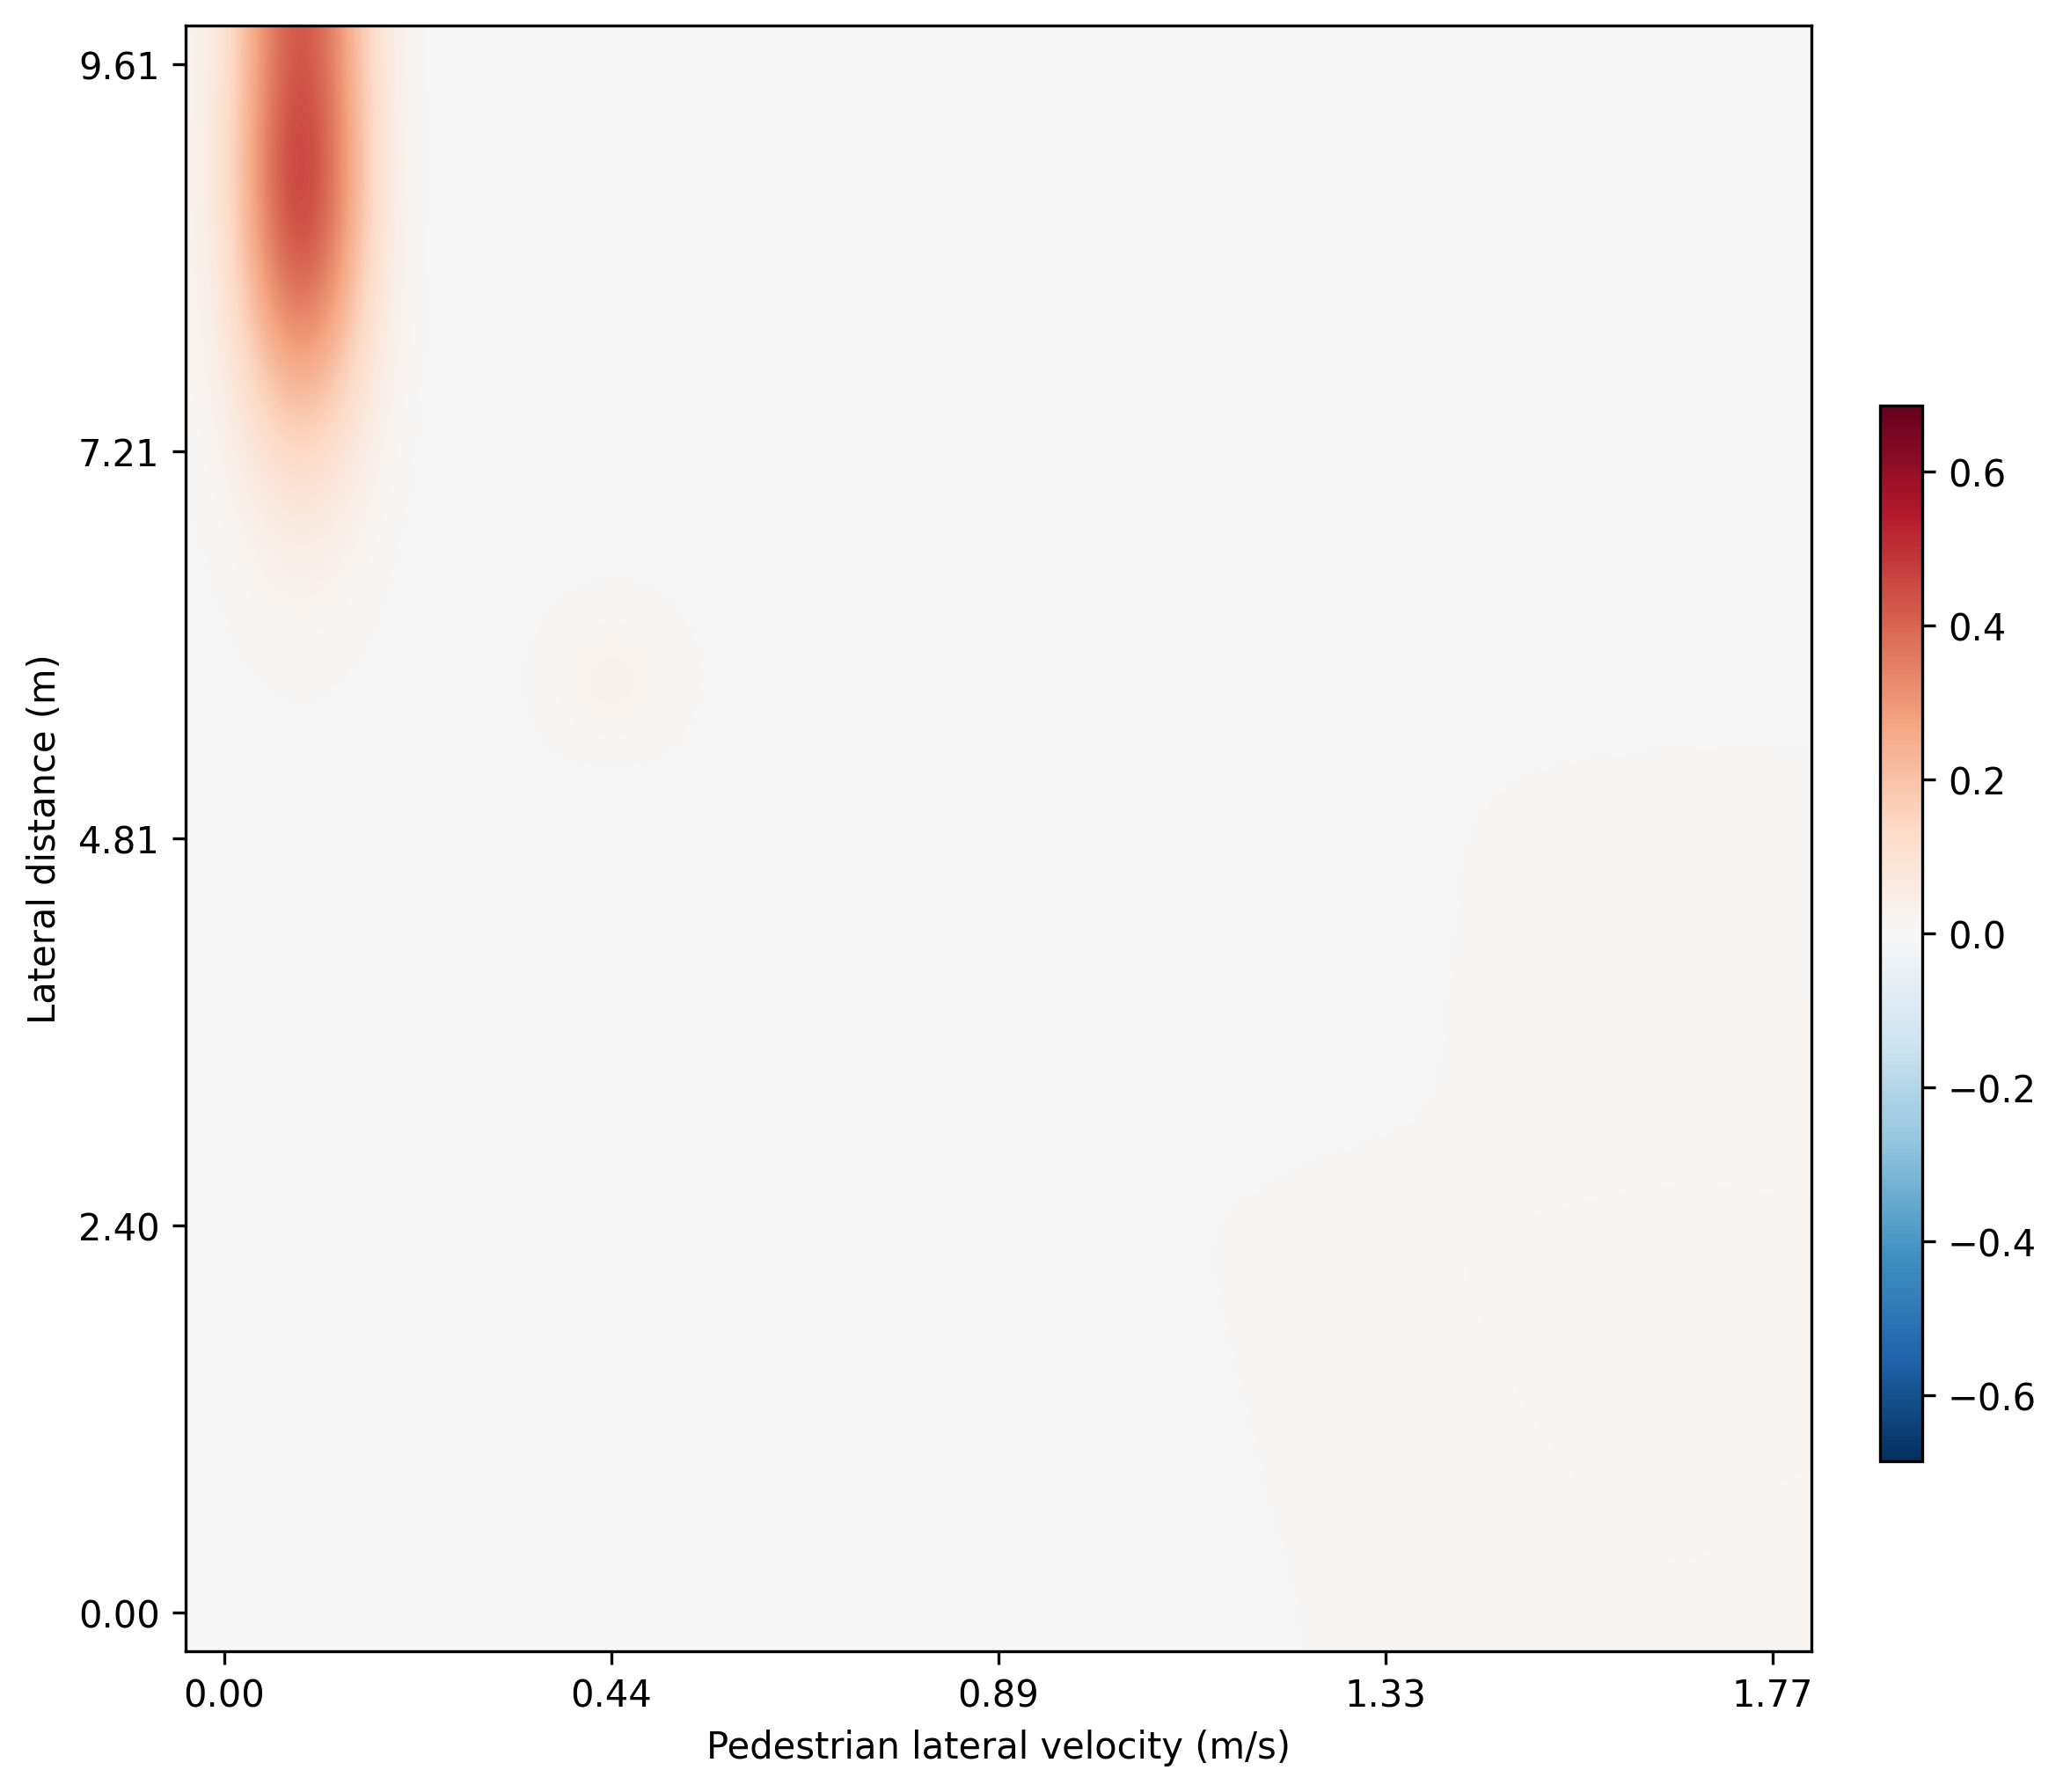

In [45]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
vmax = np.abs(record_test2_four - record_test2).max()
plt.imshow(record_test2_four - record_test2, cmap='RdBu_r', interpolation='bicubic', vmax=vmax, vmin=-vmax)
plt.xlabel('Pedestrian lateral velocity (m/s)')
plt.ylabel('Lateral distance (m)')
plt.xticks(np.arange(0,21,5),[f"{i * v_x_pedestrian / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*gap_x / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gapx-vpx-four.jpg')

plt.show()


In [46]:
## 纵向距离，纵向速度
record_test3_four = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        import numpy as np

        # 假设原行人的位置为 (gap_x, gap_y)
        original_position = (gap_x, gap_y* (20 - changey) / 10)

        # 半径
        radius = 1   # 可以根据需要调整

        # 计算四个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 5)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angle), original_position[1] + radius * np.sin(angle)) for angle in angles]

        state_flat, all_state = env.reset()

        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian * (changex) / 10
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = gap_x
        position_y_pedestrian = gap_y * (20 - changey) / 10 
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 5
        vehicle_num = 6

        # 行人状态设置
        all_state[0][0][5:, :] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1:5, 0] = all_state[0][0][0, 0]
        all_state[0][0][1:5, 1] = all_state[0][0][0, 1]
        all_state[0][0][1:5, 2] = all_state[0][0][0, 2]
        all_state[0][0][1:5, 3] = v_x_pedestrian
        all_state[0][0][1:5, 4] = v_y_pedestrian
        all_state[0][0][1:5, 5] = a_x_pedestrian
        all_state[0][0][1:5, 6] = a_y_pedestrian
        all_state[0][0][1:5, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        # all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][5:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1:5, :]  = np.array(new_positions)

        ## 车辆位置设置
        # all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[40:48] = 0
        # state_flat[64:96] = 0
        state_flat[106:108] = 0
        # state_flat[112:] = 0

        ## 行人设置
        state_flat[0:40:8] = state_flat[0]
        state_flat[1:40:8] = state_flat[1]
        state_flat[2:40:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:40:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:40:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:40:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:40:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:40:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:106] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test3_four[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/1587951343.py:133: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


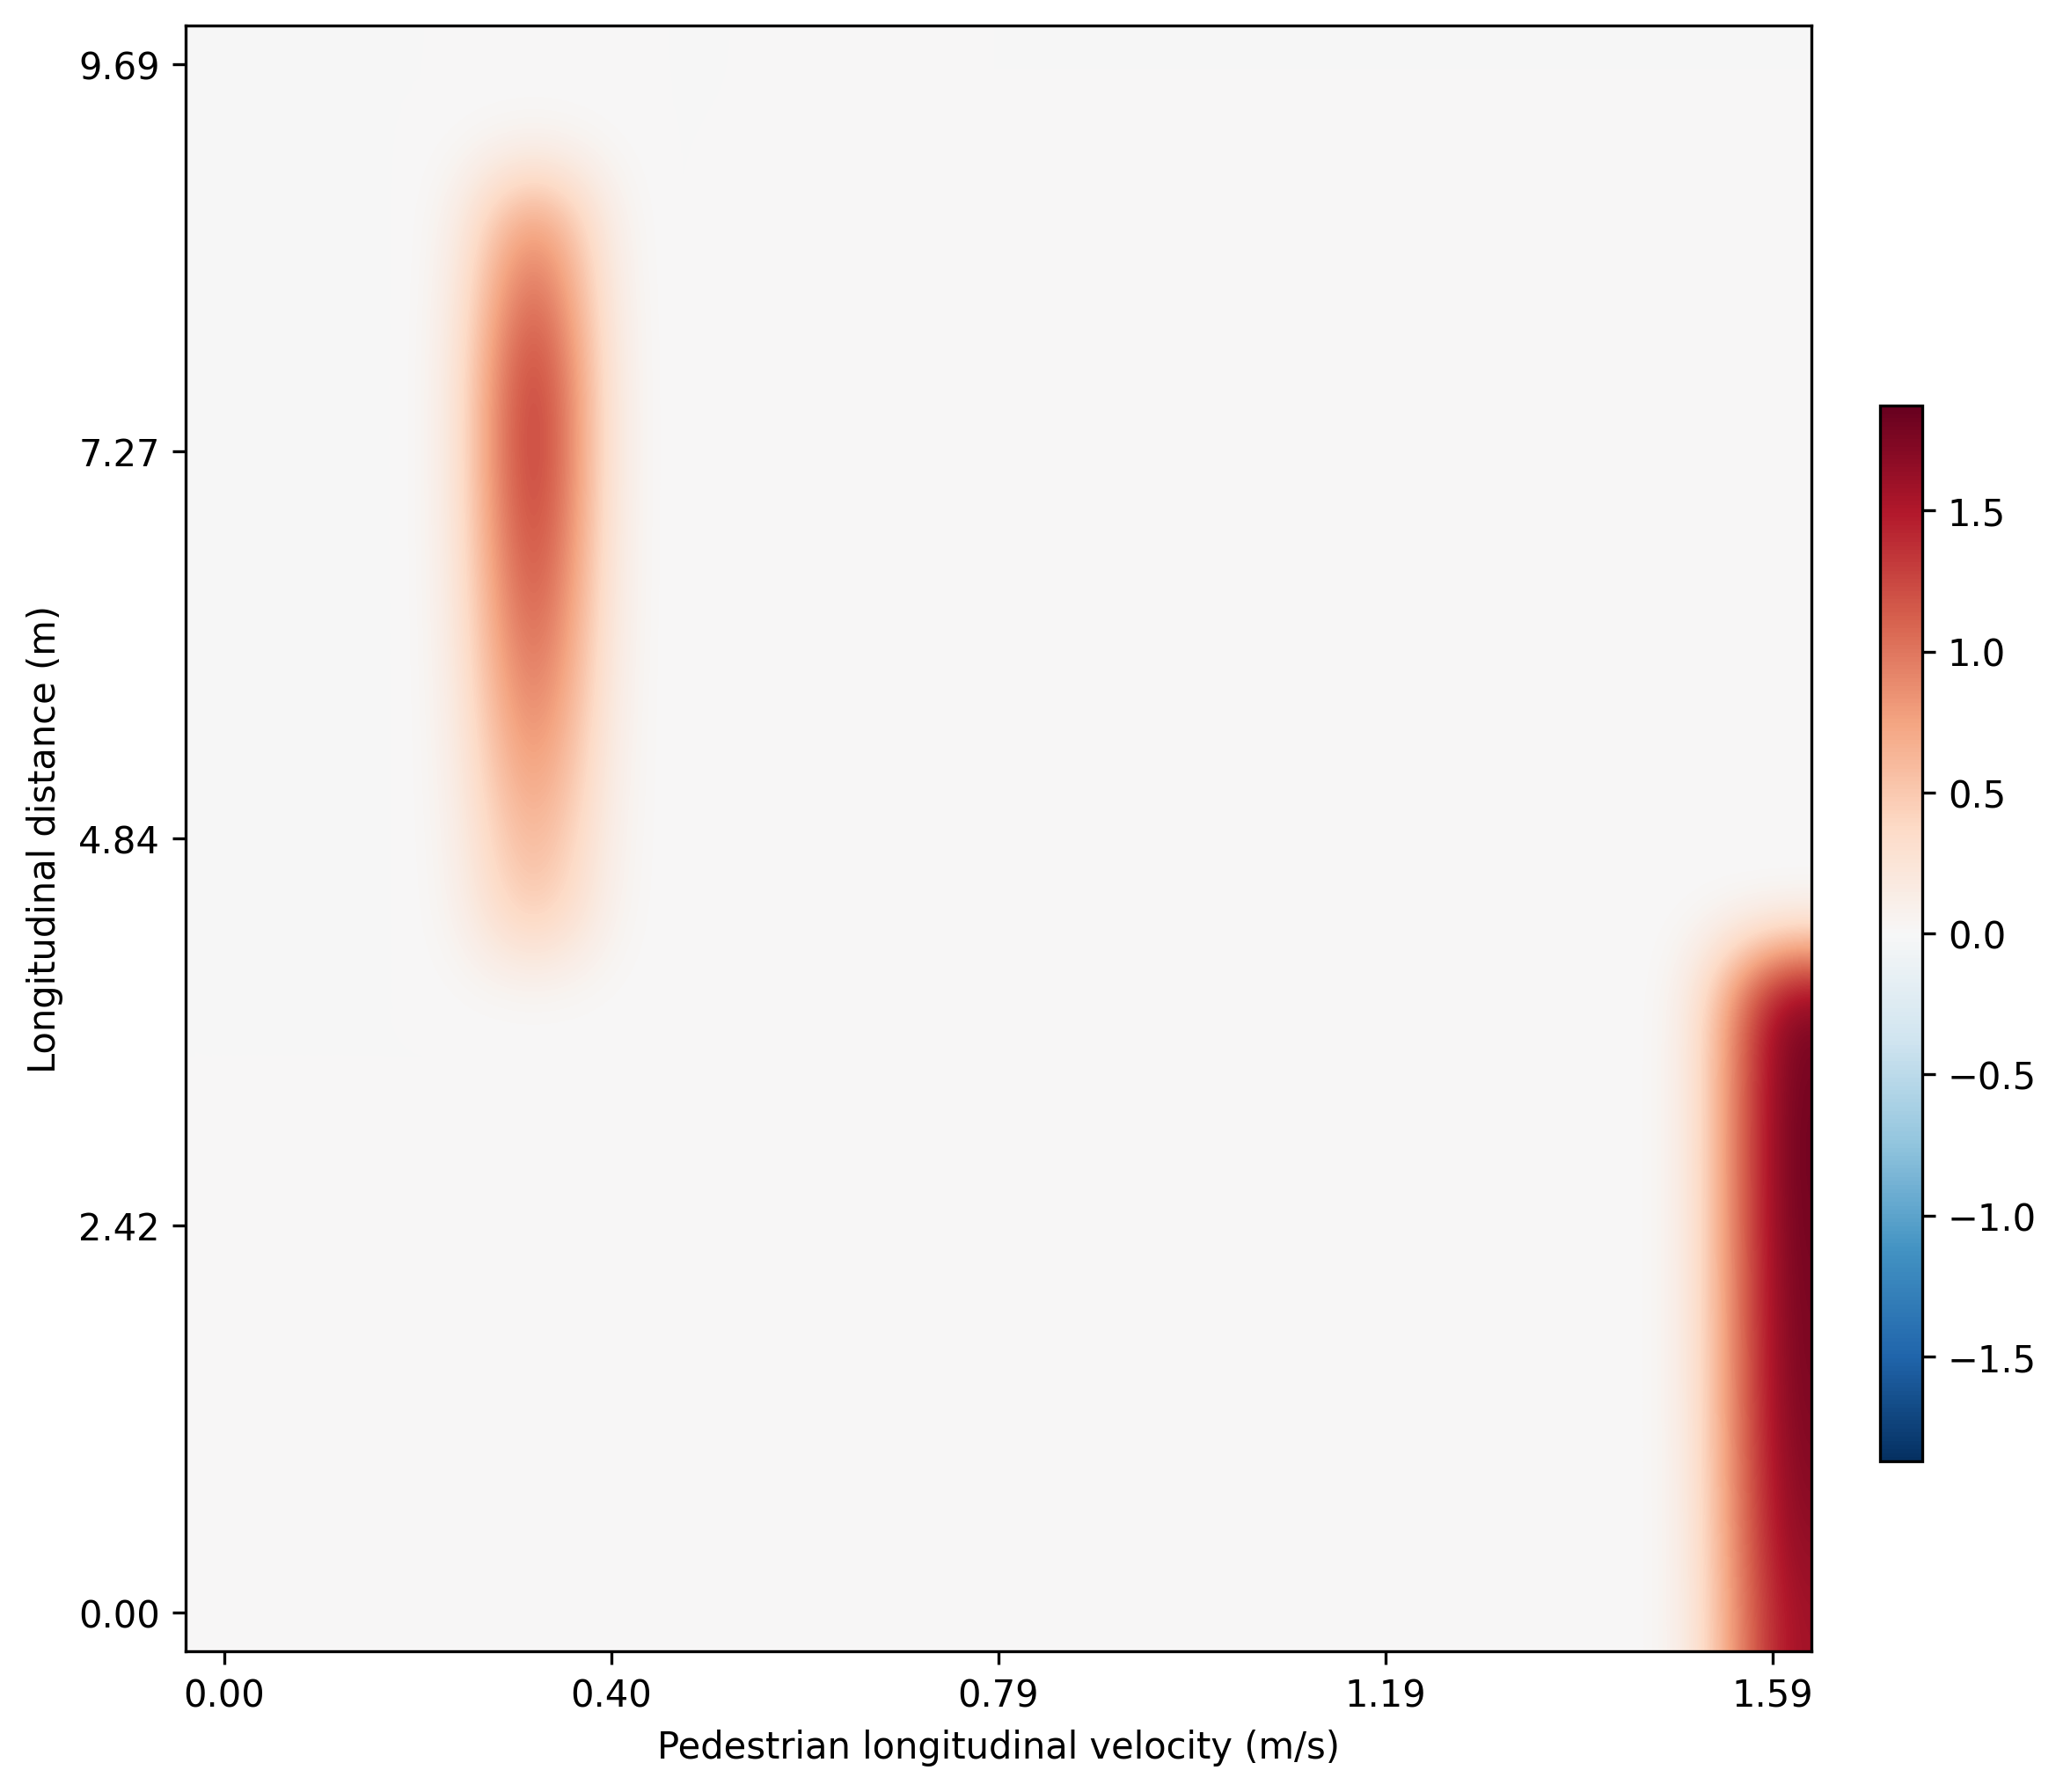

In [47]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
vmax = np.abs(record_test3_four - record_test3).max()
plt.imshow(record_test3_four - record_test3, cmap='RdBu_r', interpolation='bicubic', vmax=vmax, vmin=-vmax)
plt.xlabel('Pedestrian longitudinal velocity (m/s)')
plt.ylabel('Longitudinal distance (m)')
plt.xticks(np.arange(0,21,5),[f"{i * v_y_pedestrian / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*gap_y / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gapy-vpy-four.jpg')

plt.show()


In [48]:
## 车横速度，横距离
record_test4_four = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        import numpy as np

        # 假设原行人的位置为 (gap_x, gap_y)
        original_position = (gap_x * (changex) / 10, gap_y)

        # 半径
        radius = 1   # 可以根据需要调整

        # 计算四个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 5)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angle), original_position[1] + radius * np.sin(angle)) for angle in angles]

        state_flat, all_state = env.reset()

        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian 
        speed_x_vehicle = v_x_vehicle * (20 - changey) / 10
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = gap_x * (changex) / 10
        position_y_pedestrian = gap_y
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 5
        vehicle_num = 6

        # 行人状态设置
        all_state[0][0][5:, :] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1:5, 0] = all_state[0][0][0, 0]
        all_state[0][0][1:5, 1] = all_state[0][0][0, 1]
        all_state[0][0][1:5, 2] = all_state[0][0][0, 2]
        all_state[0][0][1:5, 3] = v_x_pedestrian
        all_state[0][0][1:5, 4] = v_y_pedestrian
        all_state[0][0][1:5, 5] = a_x_pedestrian
        all_state[0][0][1:5, 6] = a_y_pedestrian
        all_state[0][0][1:5, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        # all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][5:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1:5, :]  = np.array(new_positions)

        ## 车辆位置设置
        # all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[40:48] = 0
        # state_flat[64:96] = 0
        state_flat[106:108] = 0
        # state_flat[112:] = 0

        ## 行人设置
        state_flat[0:40:8] = state_flat[0]
        state_flat[1:40:8] = state_flat[1]
        state_flat[2:40:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:40:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:40:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:40:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:40:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:40:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:106] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test4_four[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/3413100083.py:133: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


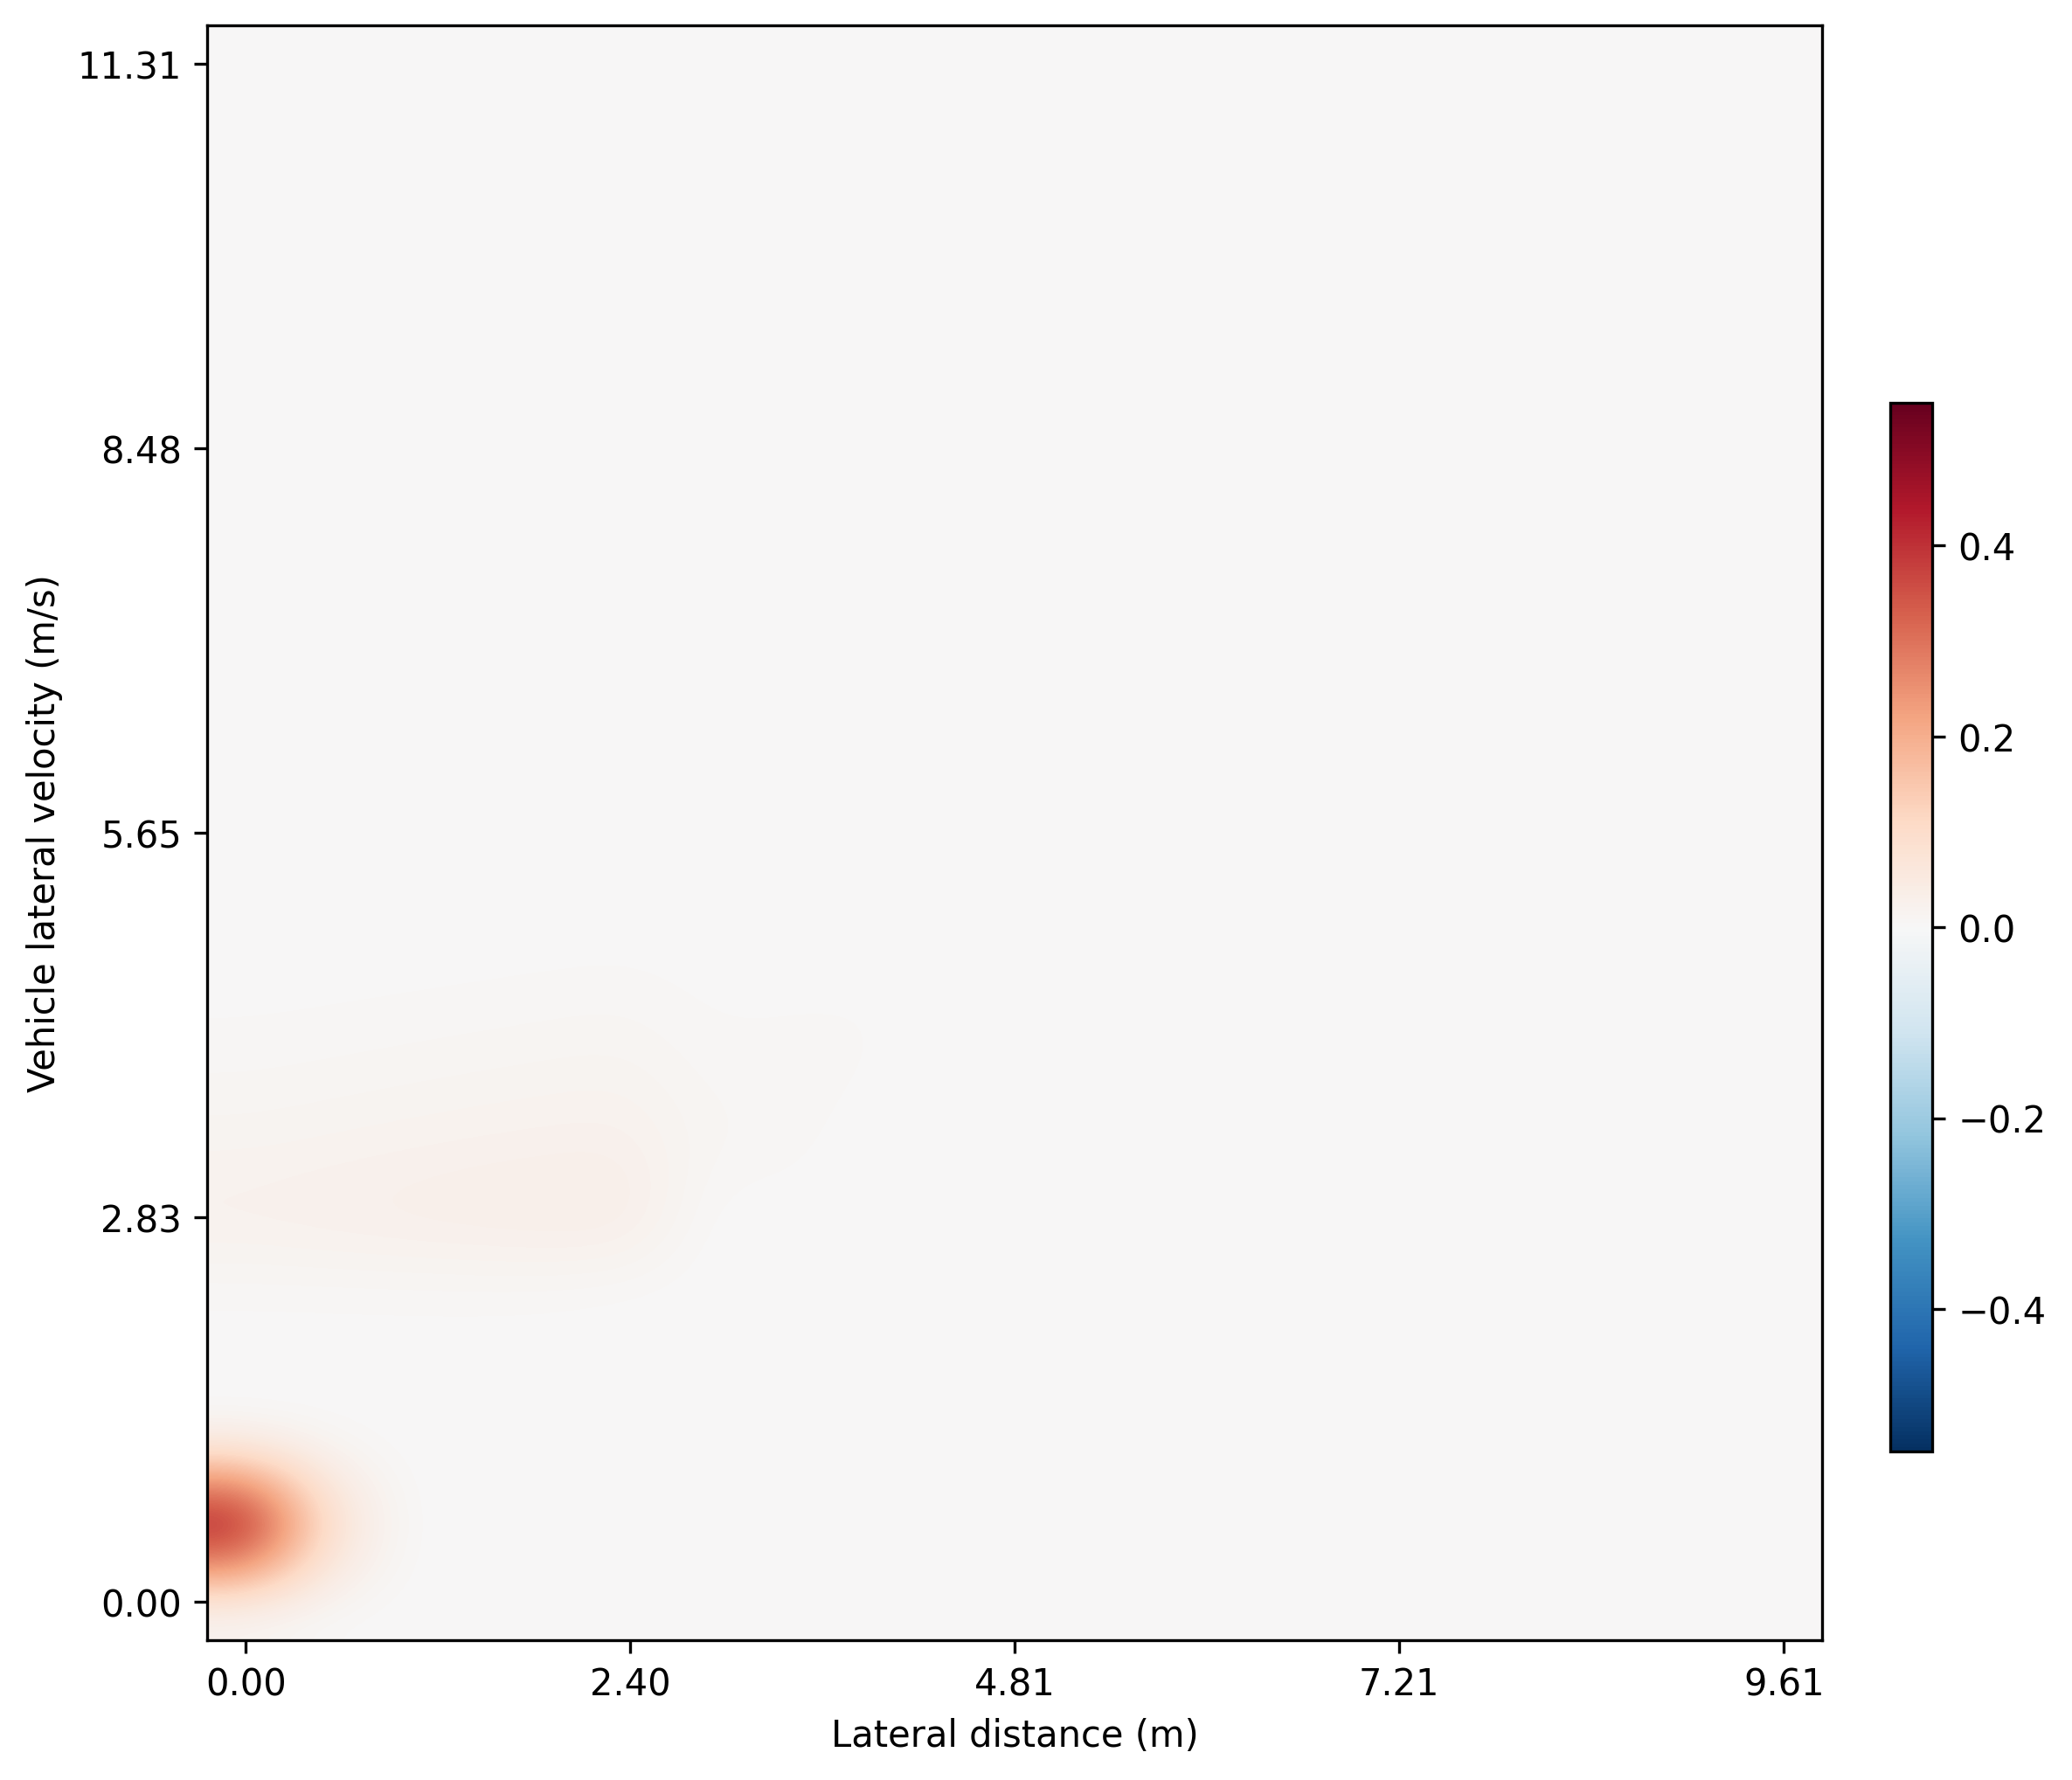

In [49]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
vmax = np.abs(record_test4_four - record_test_4).max()
plt.imshow(record_test4_four - record_test_4, cmap='RdBu_r', interpolation='bicubic', vmax=vmax, vmin=-vmax)
plt.xlabel('Lateral distance (m)')
plt.ylabel('Vehicle lateral velocity (m/s)')
plt.xticks(np.arange(0,21,5),[f"{i * gap_x / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*v_x_vehicle / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/vvx-gapx-four.jpg')

plt.show()


In [50]:
## 车纵速度，纵距离
record_test5_four = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        import numpy as np

        # 假设原行人的位置为 (gap_x, gap_y)
        original_position = (gap_x , gap_y* (changex) / 10)

        # 半径
        radius = 1   # 可以根据需要调整

        # 计算四个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 5)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angle), original_position[1] + radius * np.sin(angle)) for angle in angles]

        state_flat, all_state = env.reset()

        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian 
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle * (20 - changey) / 10

        position_x_pedestrian = gap_x
        position_y_pedestrian = gap_y* (changex) / 10
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 5
        vehicle_num = 6

        # 行人状态设置
        all_state[0][0][5:, :] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1:5, 0] = all_state[0][0][0, 0]
        all_state[0][0][1:5, 1] = all_state[0][0][0, 1]
        all_state[0][0][1:5, 2] = all_state[0][0][0, 2]
        all_state[0][0][1:5, 3] = v_x_pedestrian
        all_state[0][0][1:5, 4] = v_y_pedestrian
        all_state[0][0][1:5, 5] = a_x_pedestrian
        all_state[0][0][1:5, 6] = a_y_pedestrian
        all_state[0][0][1:5, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        # all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][5:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1:5, :]  = np.array(new_positions)

        ## 车辆位置设置
        # all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[40:48] = 0
        # state_flat[64:96] = 0
        state_flat[106:108] = 0
        # state_flat[112:] = 0

        ## 行人设置
        state_flat[0:40:8] = state_flat[0]
        state_flat[1:40:8] = state_flat[1]
        state_flat[2:40:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:40:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:40:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:40:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:40:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:40:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:106] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test5_four[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/1152100301.py:133: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


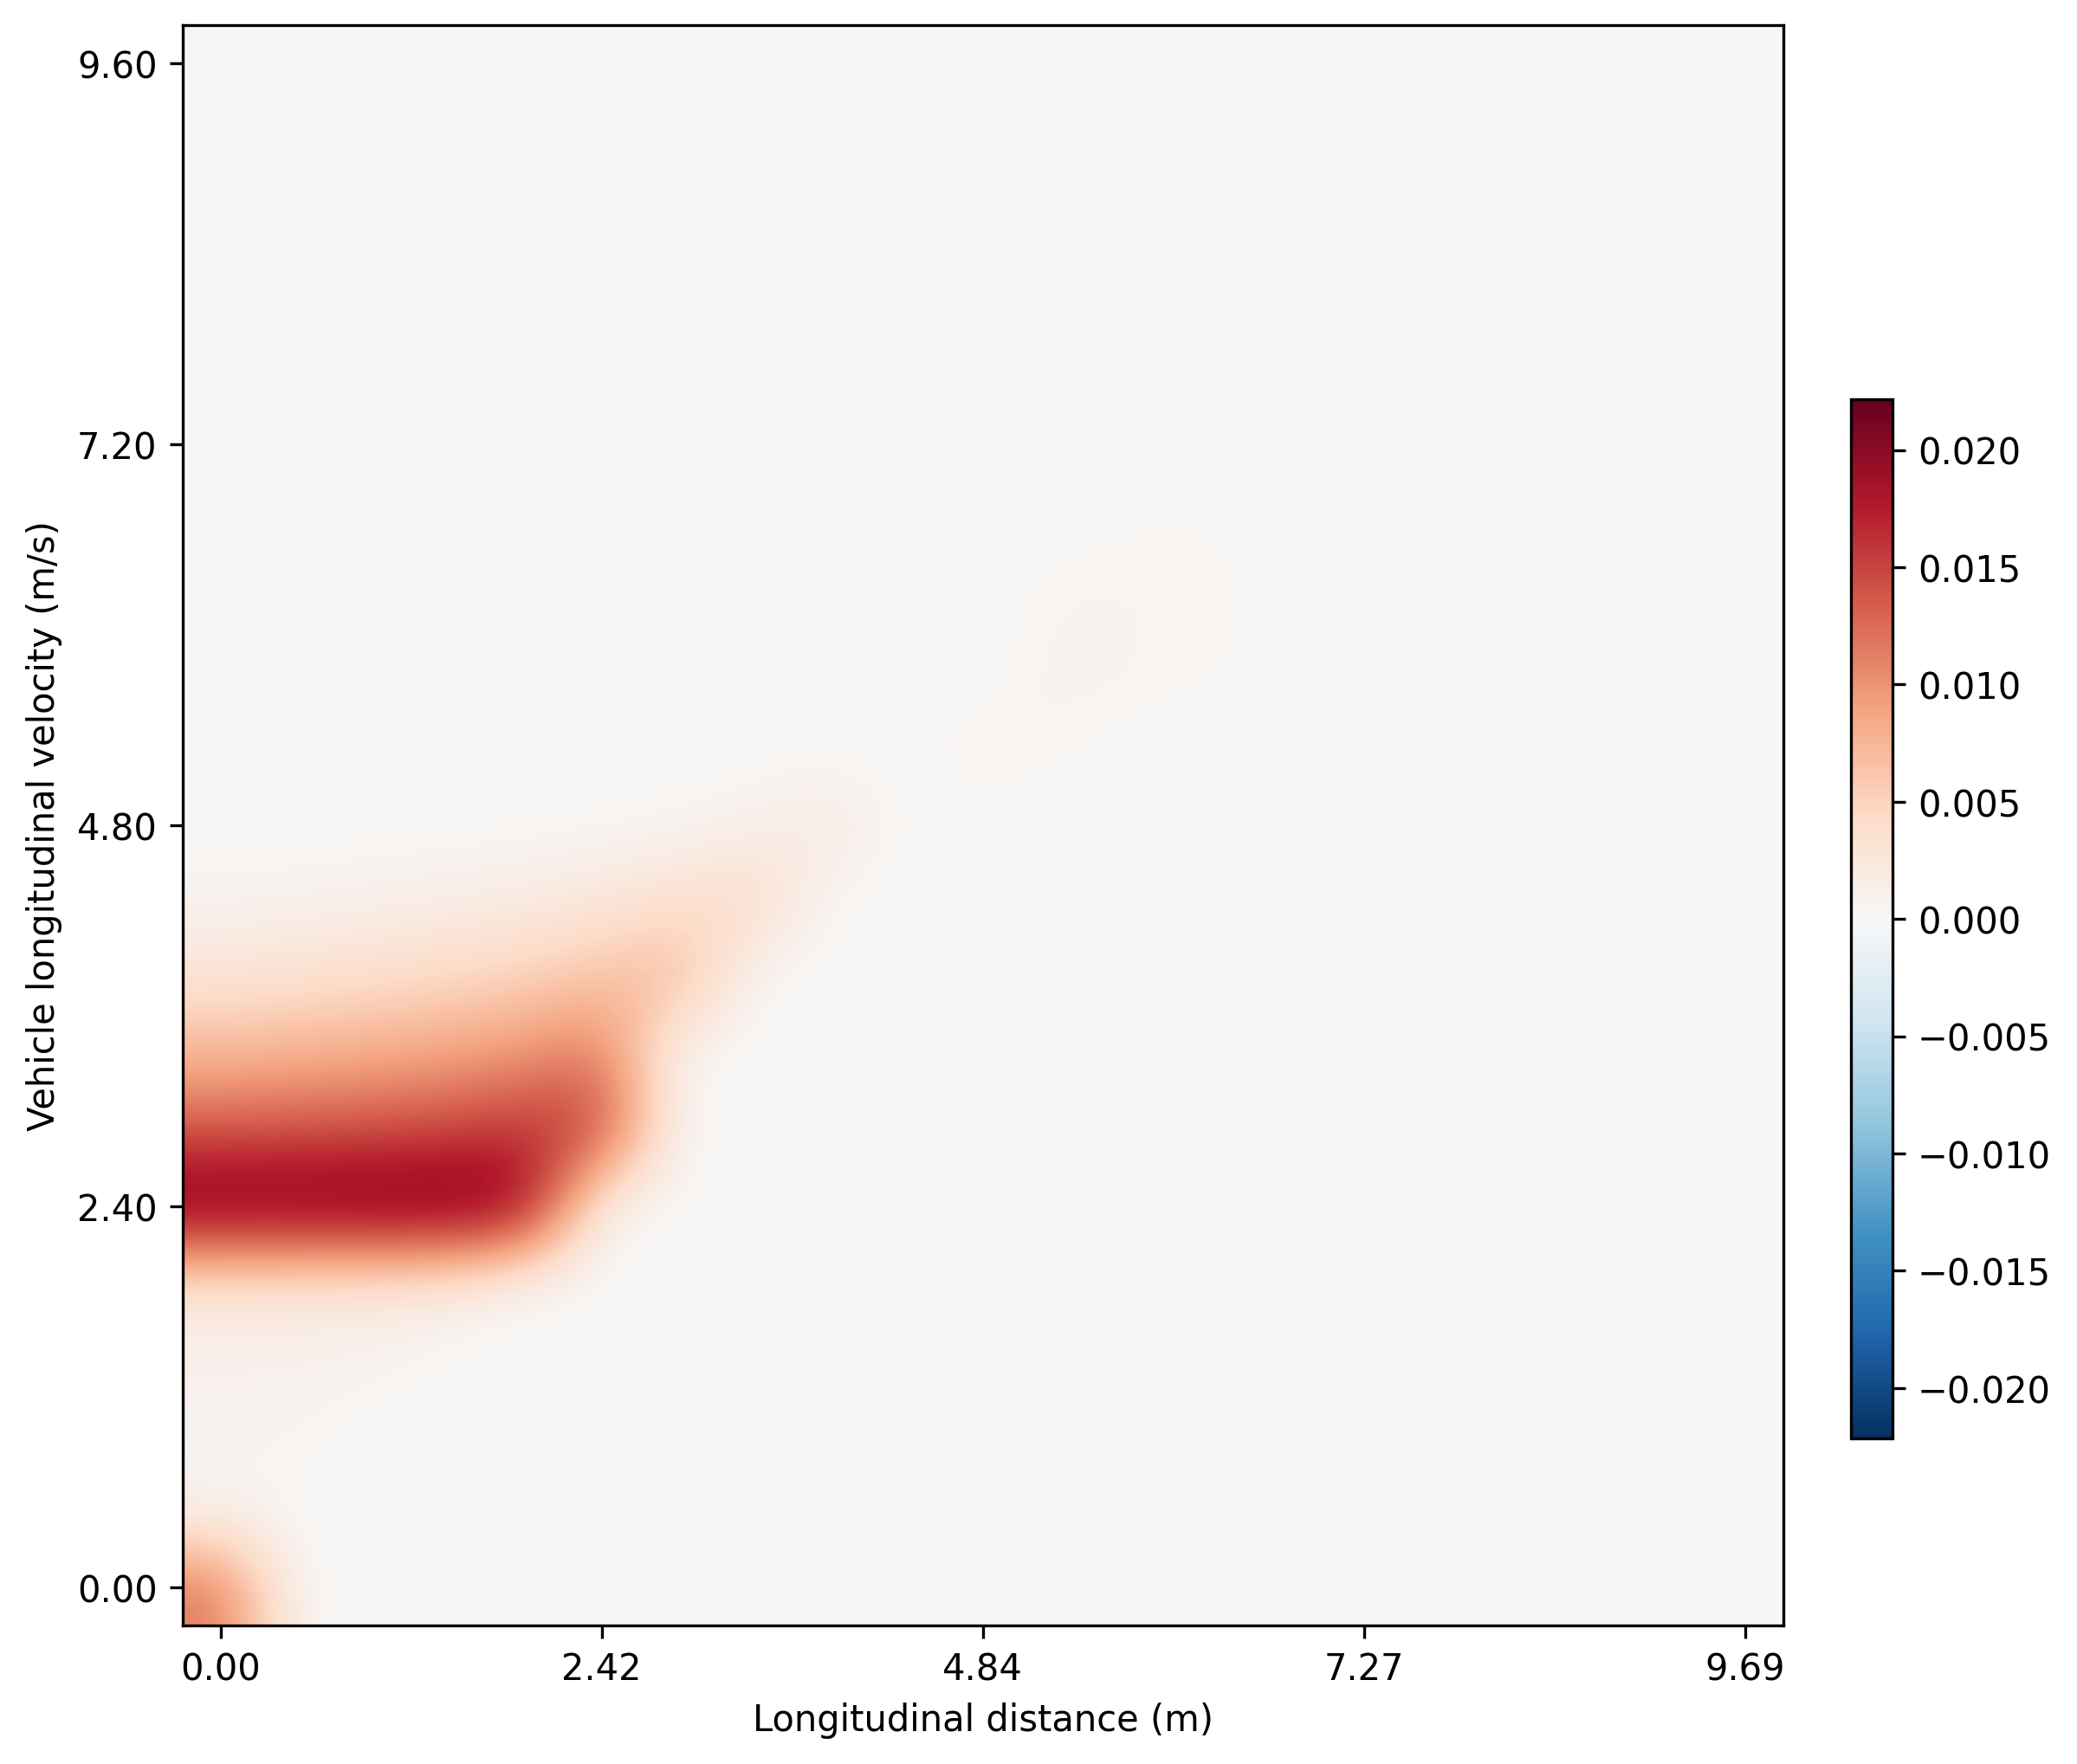

In [51]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
vmax = np.abs(record_test5_four - record_test5).max()
plt.imshow(record_test5_four - record_test5, cmap='RdBu_r', interpolation='bicubic', vmax=vmax, vmin=-vmax)
plt.xlabel('Longitudinal distance (m)')
plt.ylabel('Vehicle longitudinal velocity (m/s)')
plt.xticks(np.arange(0,21,5),[f"{i * gap_y / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*v_y_vehicle / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/vvy-gapy-four.jpg')

plt.show()


## 单人环绕

In [52]:
## 横纵向距离
record_test1_one = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        import numpy as np

        # 假设原行人的位置为 (gap_x, gap_y)
        original_position = (gap_x * (changex) / 10, gap_y * (20 - changey) / 10 )

        # 半径
        radius = 1   # 可以根据需要调整

        # 计算五个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 22)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angles[13]), original_position[1] + radius * np.sin(angles[13]))]

        state_flat, all_state = env.reset()

        # v_x_pedestrian = 0
        # v_y_pedestrian = 0
        # a_x_pedestrian = 0
        # a_y_pedestrian = 0
        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = gap_x * (changex) / 10
        position_y_pedestrian = gap_y * (20 - changey) / 10 
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 2
        vehicle_num = 2

        # 行人状态设置
        all_state[0][0][2:,:] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1, 0] = all_state[0][0][0, 0]
        all_state[0][0][1, 1] = all_state[0][0][0, 1]
        all_state[0][0][1, 2] = all_state[0][0][0, 2]
        all_state[0][0][1, 3] = v_x_pedestrian
        all_state[0][0][1, 4] = v_y_pedestrian
        all_state[0][0][1, 5] = a_x_pedestrian
        all_state[0][0][1, 6] = a_y_pedestrian
        all_state[0][0][1, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][2:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1, :]  = np.array(new_positions)

        ## 车辆位置设置
        all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[16:48] = 0
        state_flat[64:96] = 0
        state_flat[100:108] = 0
        state_flat[112:] = 0

        ## 行人设置
        state_flat[0:16:8] = state_flat[0]
        state_flat[1:16:8] = state_flat[1]
        state_flat[2:16:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:16:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:16:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:16:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:16:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:16:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:100] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test1_one[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/1521018689.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


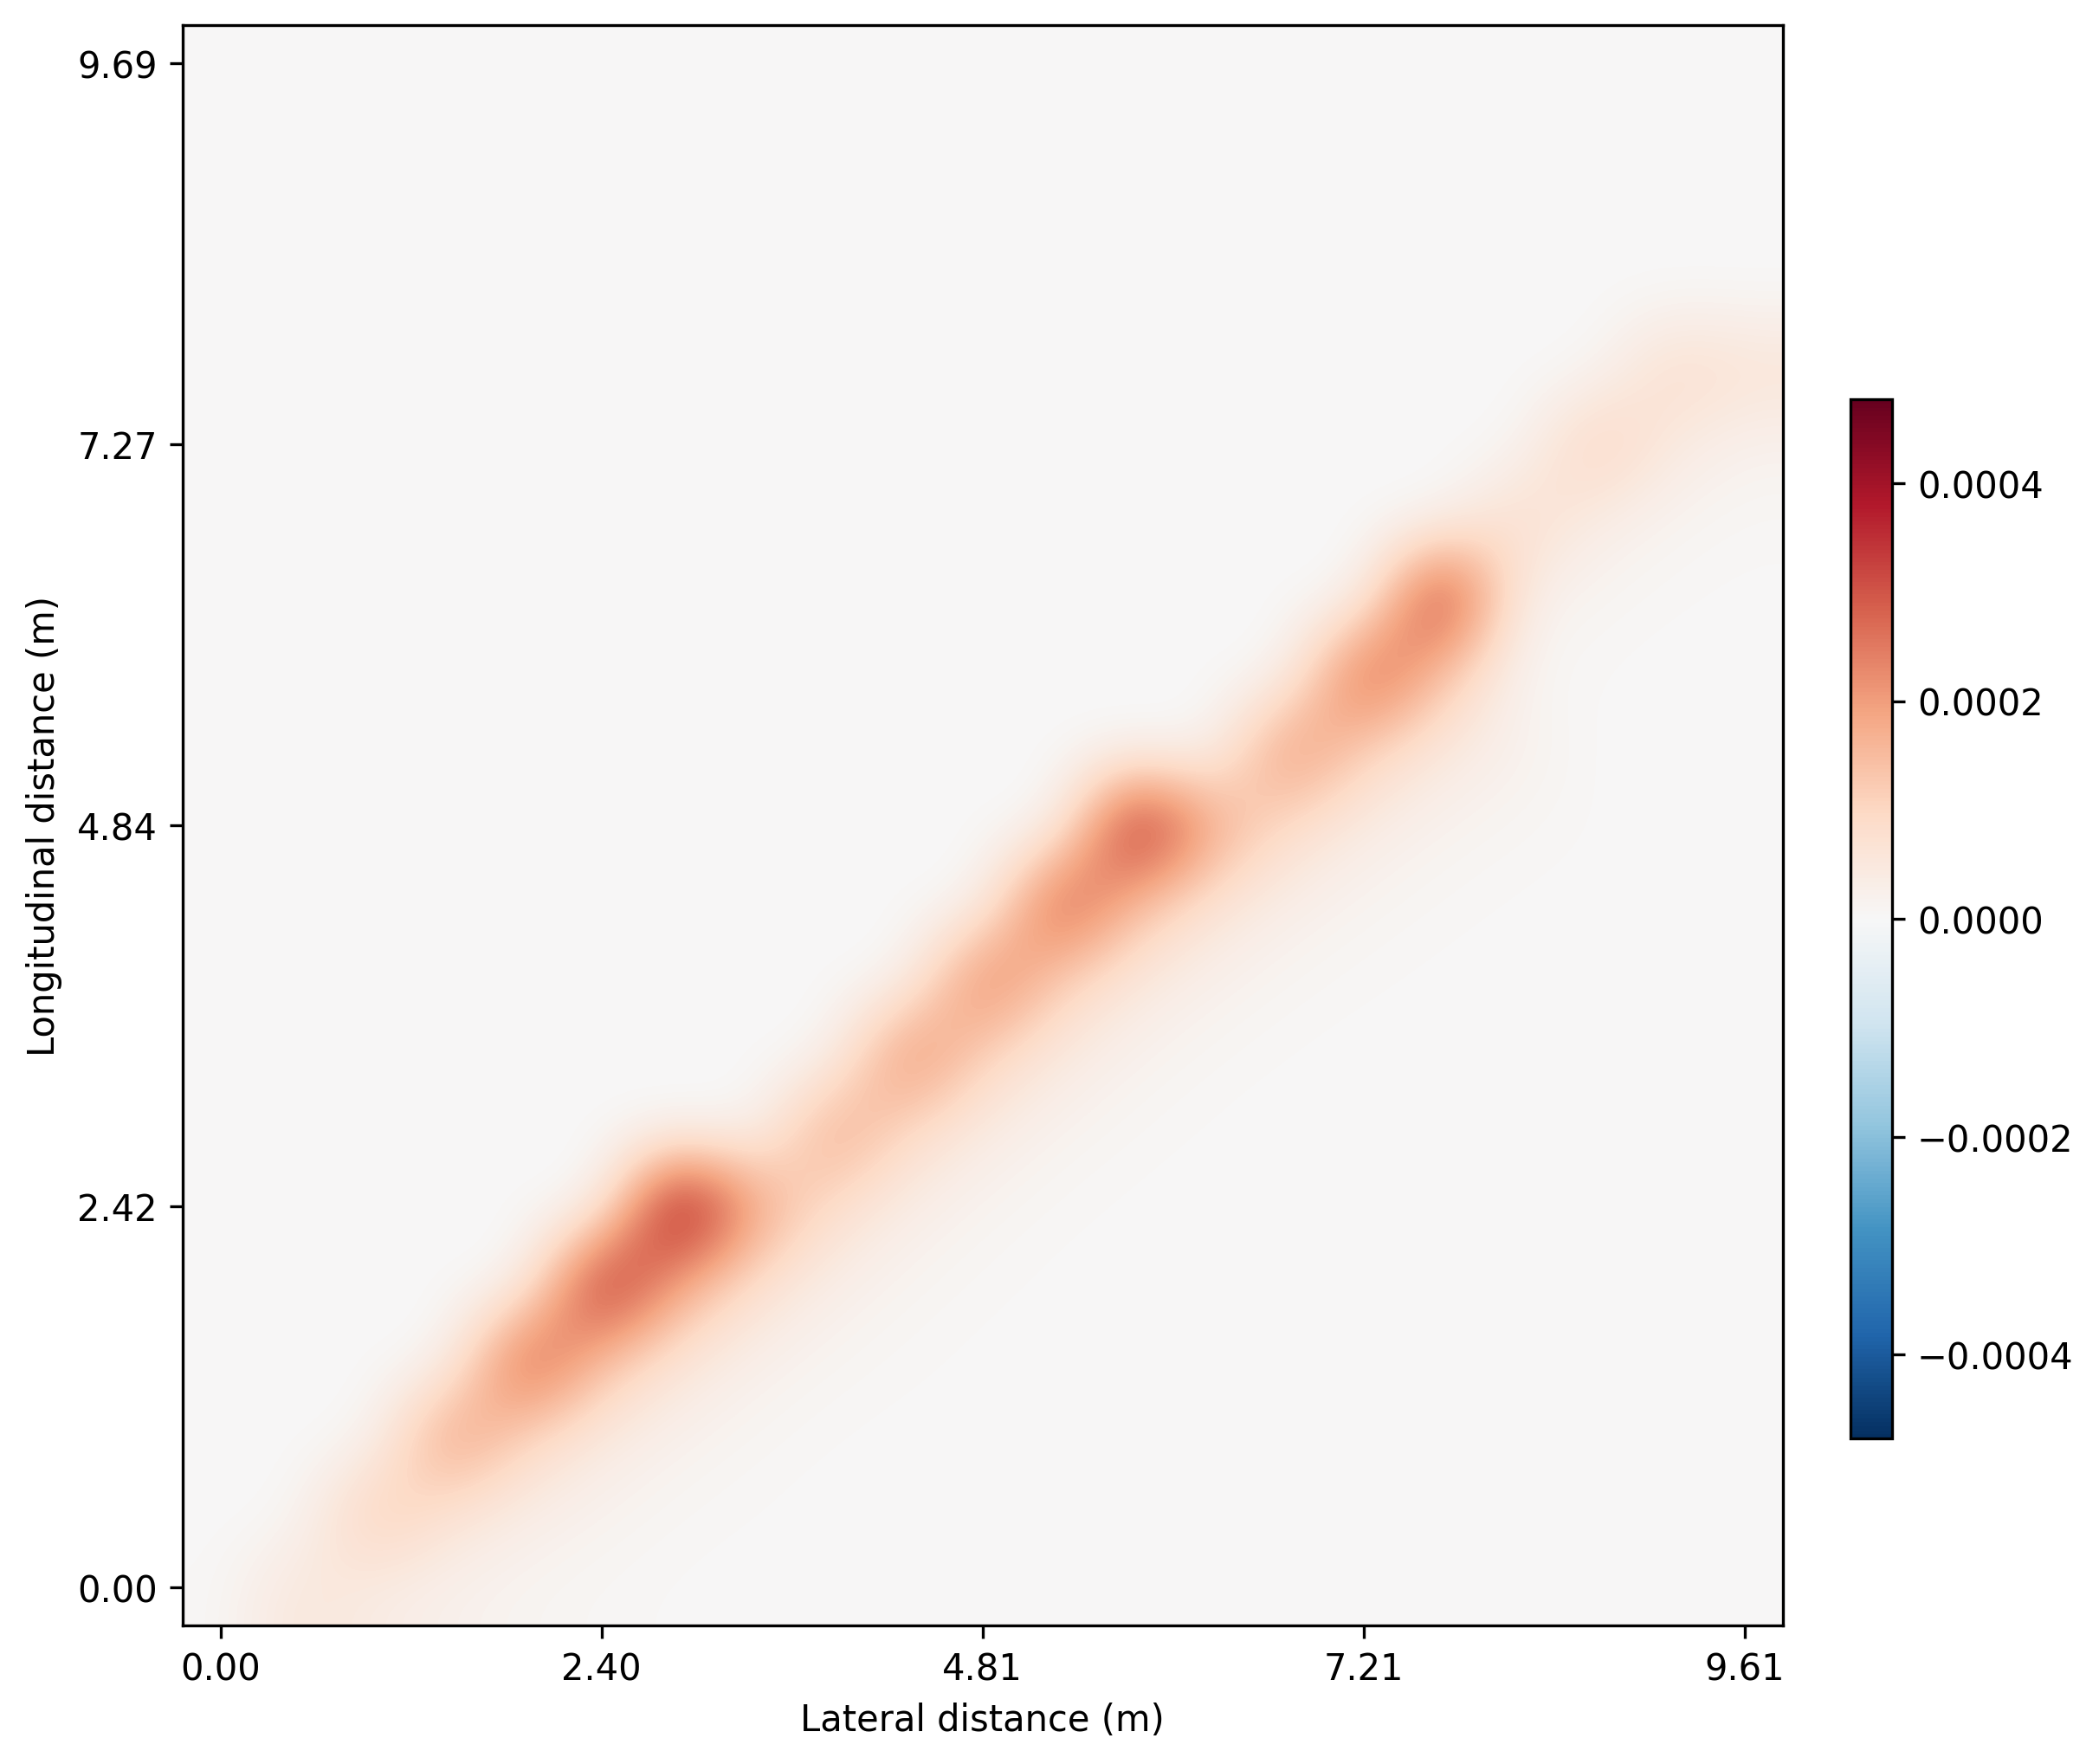

In [53]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
vmax = np.abs(record_test1_one - record_test1).max()
plt.imshow(record_test1_one - record_test1, cmap='RdBu_r', interpolation='bicubic', vmax=vmax, vmin=-vmax)
plt.xlabel('Lateral distance (m)')
plt.ylabel('Longitudinal distance (m)')
plt.xticks(np.arange(0,21,5),[f"{i * gap_x / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*gap_y / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gapy-gapx-one.jpg')

plt.show()


In [54]:
## 横向距离、横向速度 
record_test2_one = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        import numpy as np

        # 假设原行人的位置为 (gap_x, gap_y)
        original_position = (gap_x * (20 - changey) / 10 , gap_y)

        # 半径
        radius = 1   # 可以根据需要调整

        # 计算五个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 22)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angles[13]), original_position[1] + radius * np.sin(angles[13]))]

        state_flat, all_state = env.reset()

        # v_x_pedestrian = 0
        # v_y_pedestrian = 0
        # a_x_pedestrian = 0
        # a_y_pedestrian = 0
        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian * (changex) / 10
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = gap_x * (20 - changey) / 10 
        position_y_pedestrian = gap_y 
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 2
        vehicle_num = 2

        # 行人状态设置
        all_state[0][0][2:,:] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1, 0] = all_state[0][0][0, 0]
        all_state[0][0][1, 1] = all_state[0][0][0, 1]
        all_state[0][0][1, 2] = all_state[0][0][0, 2]
        all_state[0][0][1, 3] = v_x_pedestrian
        all_state[0][0][1, 4] = v_y_pedestrian
        all_state[0][0][1, 5] = a_x_pedestrian
        all_state[0][0][1, 6] = a_y_pedestrian
        all_state[0][0][1, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][2:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1, :]  = np.array(new_positions)

        ## 车辆位置设置
        all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[16:48] = 0
        state_flat[64:96] = 0
        state_flat[100:108] = 0
        state_flat[112:] = 0

        ## 行人设置
        state_flat[0:16:8] = state_flat[0]
        state_flat[1:16:8] = state_flat[1]
        state_flat[2:16:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:16:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:16:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:16:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:16:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:16:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:100] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test2_one[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/2705509406.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


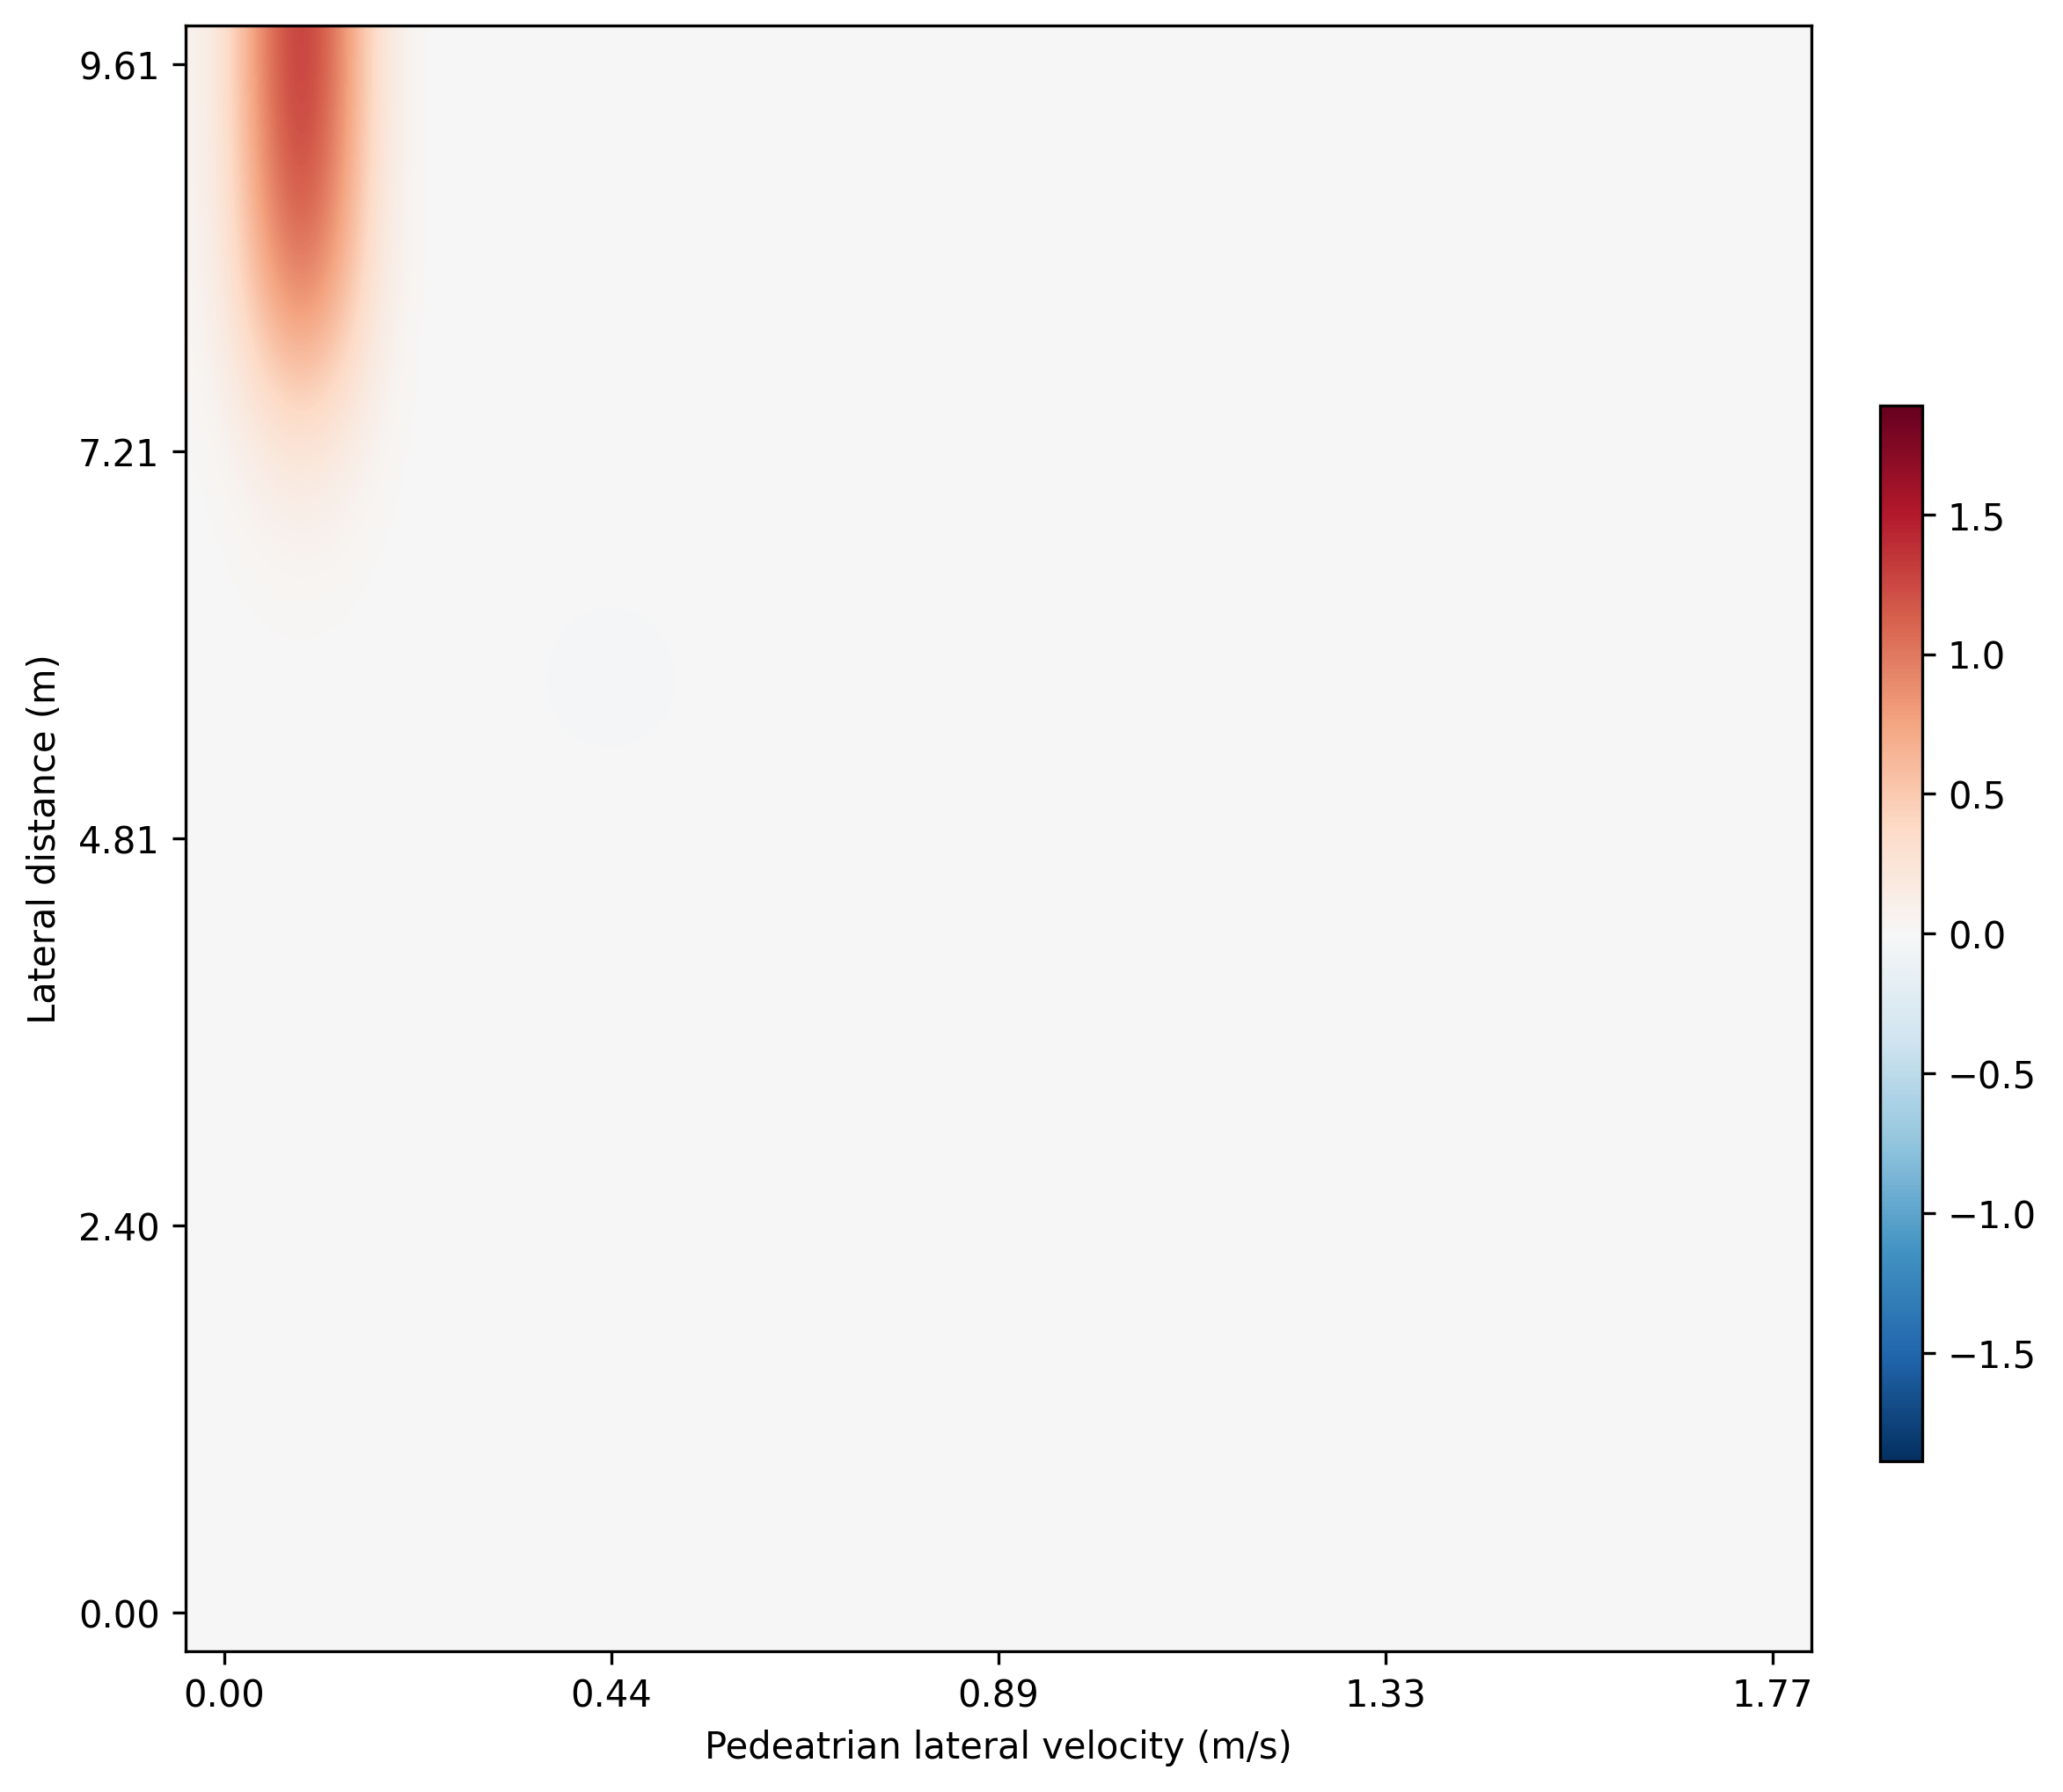

In [55]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
vmax = np.abs(record_test2_one - record_test2).max()
plt.imshow(record_test2_one - record_test2, cmap='RdBu_r', interpolation='bicubic', vmax=vmax, vmin=-vmax)
plt.xlabel('Pedeatrian lateral velocity (m/s)')
plt.ylabel('Lateral distance (m)')
plt.xticks(np.arange(0,21,5),[f"{i * v_x_pedestrian / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*gap_x / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gapx-vpx-one.jpg')

plt.show()


In [56]:
## 纵向距离、纵向速度 
record_test3_one = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        import numpy as np

        # 假设原行人的位置为 (gap_x, gap_y)
        original_position = (gap_x, gap_y * (20 - changey) / 10 )

        # 半径
        radius = 1   # 可以根据需要调整

        # 计算五个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 22)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angles[13]), original_position[1] + radius * np.sin(angles[13]))]

        state_flat, all_state = env.reset()

        # v_x_pedestrian = 0
        # v_y_pedestrian = 0
        # a_x_pedestrian = 0
        # a_y_pedestrian = 0
        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian * (changex) / 10
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = gap_x
        position_y_pedestrian = gap_y  * (20 - changey) / 10 
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 2
        vehicle_num = 2

        # 行人状态设置
        all_state[0][0][2:,:] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1, 0] = all_state[0][0][0, 0]
        all_state[0][0][1, 1] = all_state[0][0][0, 1]
        all_state[0][0][1, 2] = all_state[0][0][0, 2]
        all_state[0][0][1, 3] = v_x_pedestrian
        all_state[0][0][1, 4] = v_y_pedestrian
        all_state[0][0][1, 5] = a_x_pedestrian
        all_state[0][0][1, 6] = a_y_pedestrian
        all_state[0][0][1, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][2:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1, :]  = np.array(new_positions)

        ## 车辆位置设置
        all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[16:48] = 0
        state_flat[64:96] = 0
        state_flat[100:108] = 0
        state_flat[112:] = 0

        ## 行人设置
        state_flat[0:16:8] = state_flat[0]
        state_flat[1:16:8] = state_flat[1]
        state_flat[2:16:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:16:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:16:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:16:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:16:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:16:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:100] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test3_one[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/2574719283.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


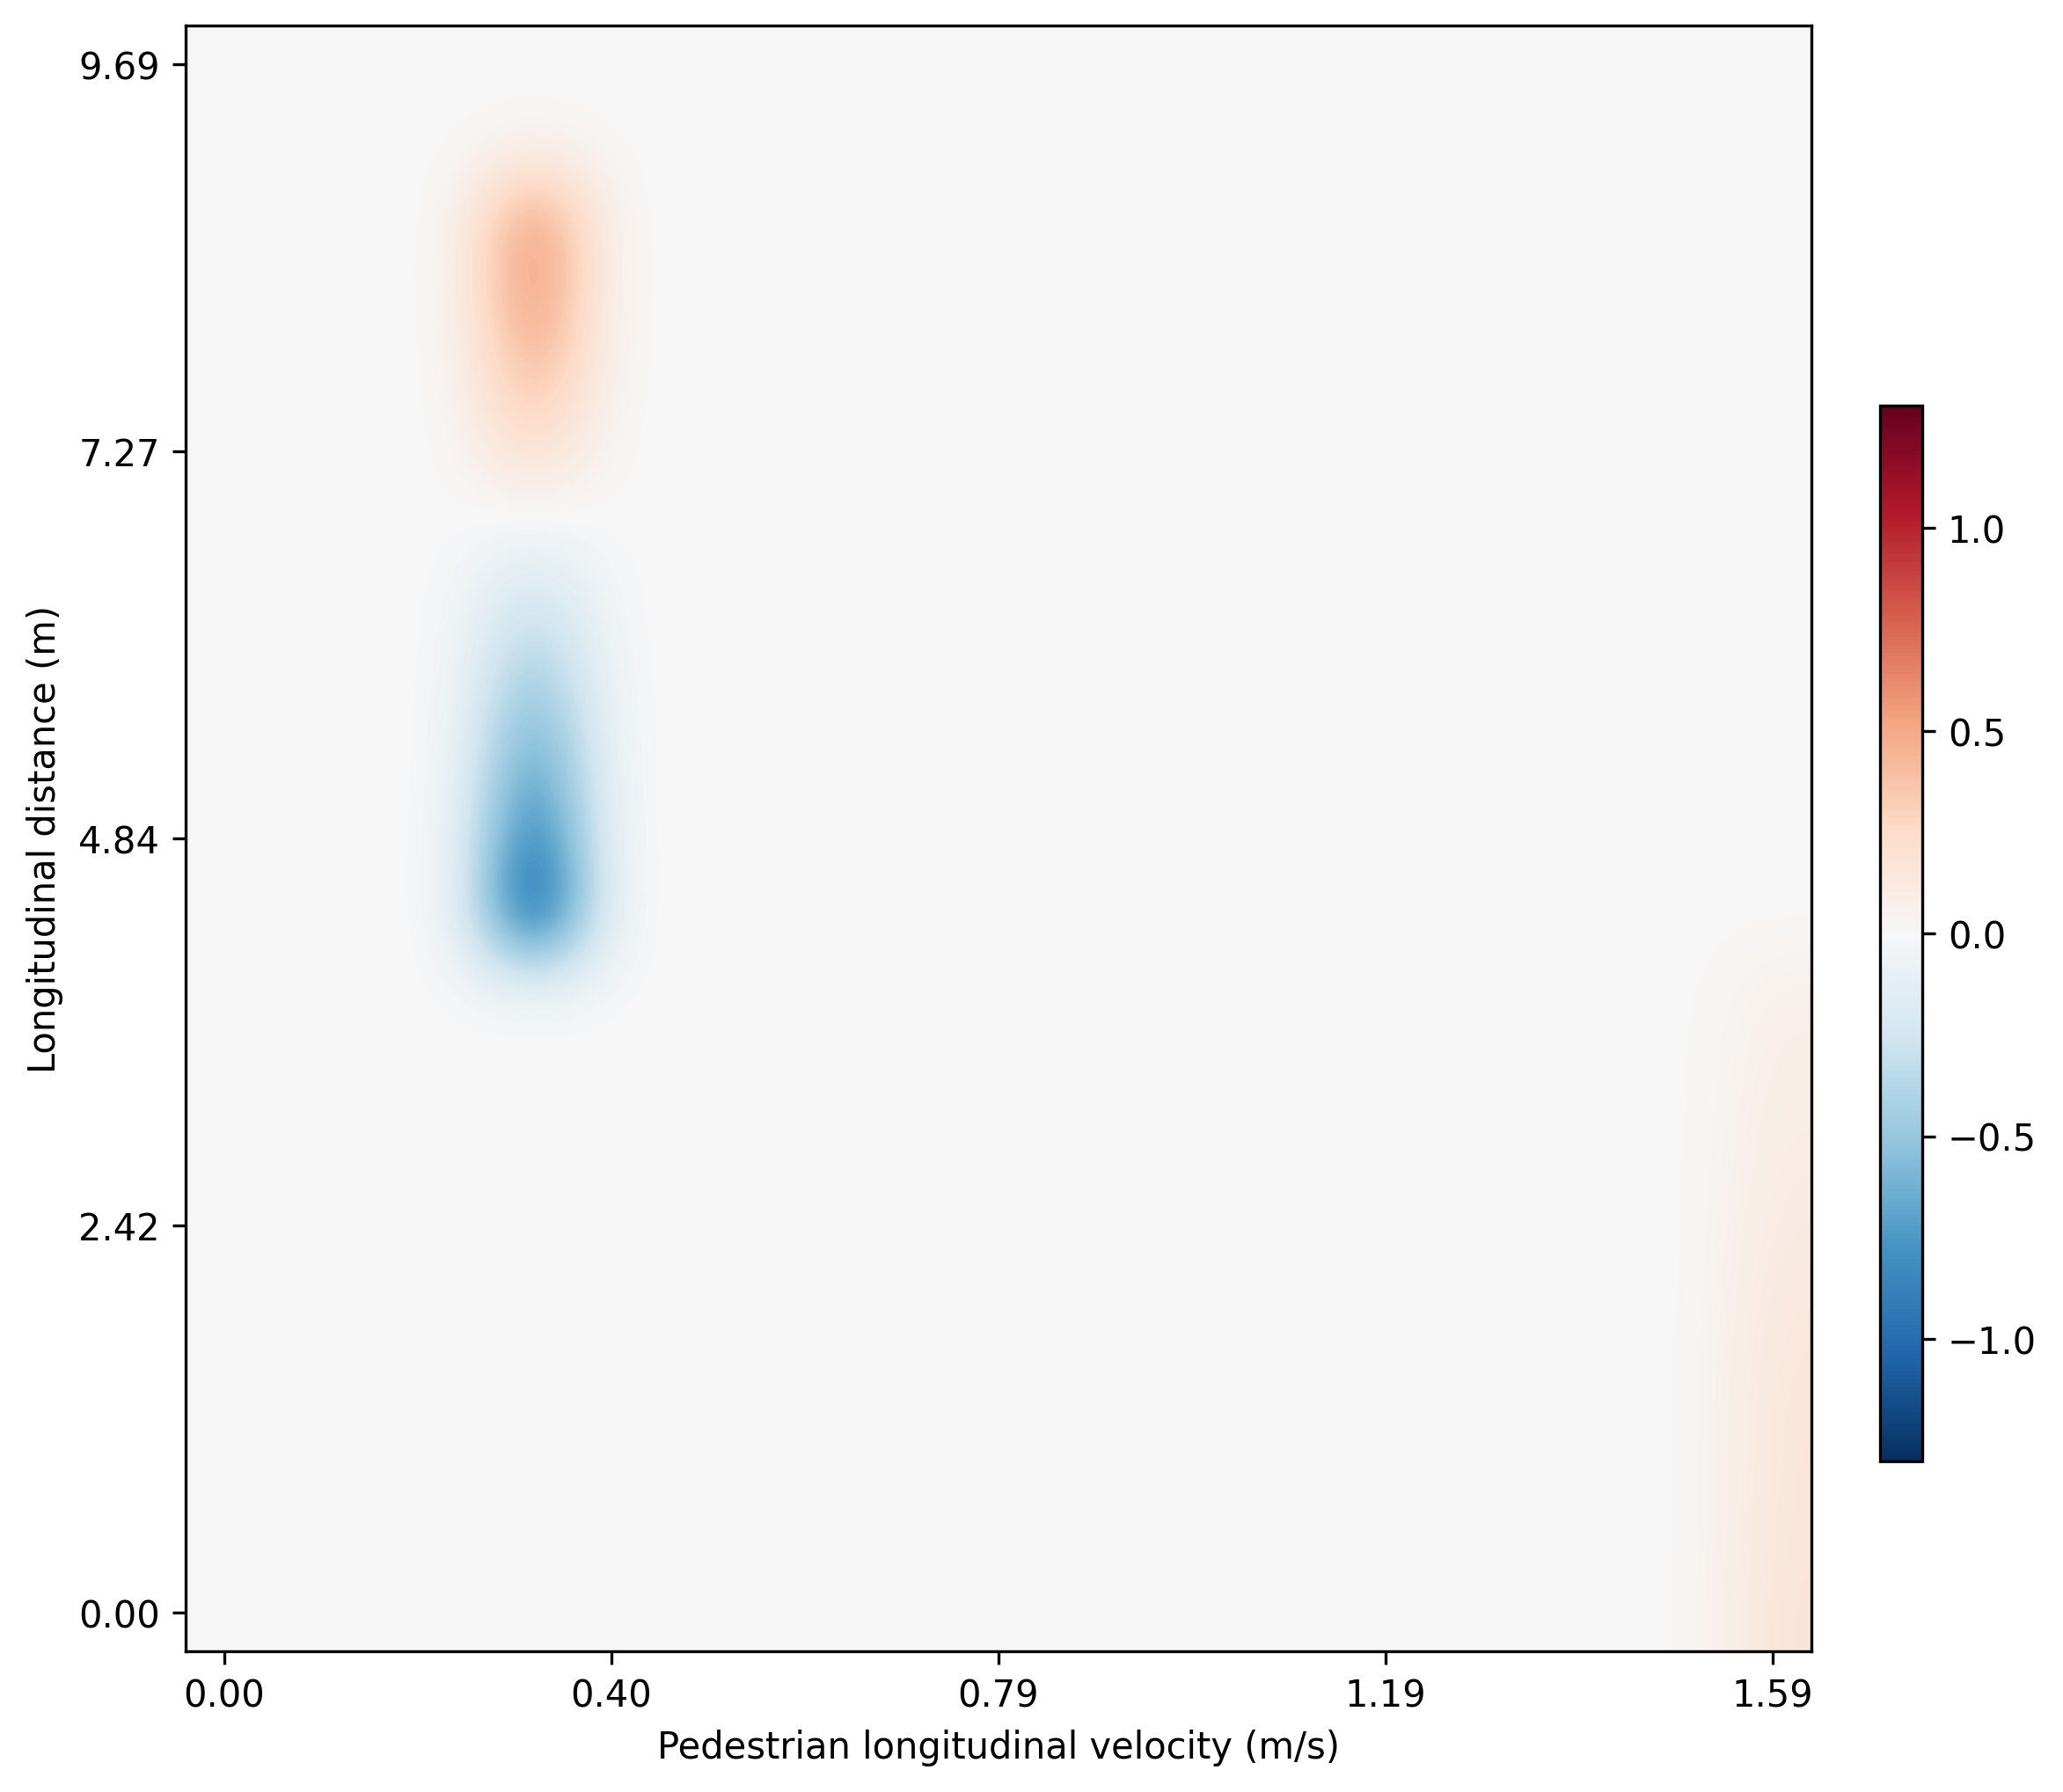

In [57]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
vmax = np.abs(record_test3_one - record_test3).max()
plt.imshow(record_test3_one - record_test3, cmap='RdBu_r', interpolation='bicubic', vmax=vmax, vmin=-vmax)
plt.xlabel('Pedestrian longitudinal velocity (m/s)')
plt.ylabel('Longitudinal distance (m)')
plt.xticks(np.arange(0,21,5),[f"{i * v_y_pedestrian / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*gap_y / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gapy-vpy-one.jpg')

plt.show()


In [58]:
## 车横向速度、横向距离
record_test4_one = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        import numpy as np

        # 假设原行人的位置为 (gap_x, gap_y)
        original_position = (gap_x * (changex) / 10, gap_y)

        # 半径
        radius = 1   # 可以根据需要调整

        # 计算五个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 22)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angles[13]), original_position[1] + radius * np.sin(angles[13]))]

        state_flat, all_state = env.reset()

        # v_x_pedestrian = 0
        # v_y_pedestrian = 0
        # a_x_pedestrian = 0
        # a_y_pedestrian = 0
        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle * (20 - changey) / 10 
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = gap_x * (changex) / 10
        position_y_pedestrian = gap_y 
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 2
        vehicle_num = 2

        # 行人状态设置
        all_state[0][0][2:,:] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1, 0] = all_state[0][0][0, 0]
        all_state[0][0][1, 1] = all_state[0][0][0, 1]
        all_state[0][0][1, 2] = all_state[0][0][0, 2]
        all_state[0][0][1, 3] = v_x_pedestrian
        all_state[0][0][1, 4] = v_y_pedestrian
        all_state[0][0][1, 5] = a_x_pedestrian
        all_state[0][0][1, 6] = a_y_pedestrian
        all_state[0][0][1, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][2:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1, :]  = np.array(new_positions)

        ## 车辆位置设置
        all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[16:48] = 0
        state_flat[64:96] = 0
        state_flat[100:108] = 0
        state_flat[112:] = 0

        ## 行人设置
        state_flat[0:16:8] = state_flat[0]
        state_flat[1:16:8] = state_flat[1]
        state_flat[2:16:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:16:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:16:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:16:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:16:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:16:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:100] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test4_one[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/3362334532.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


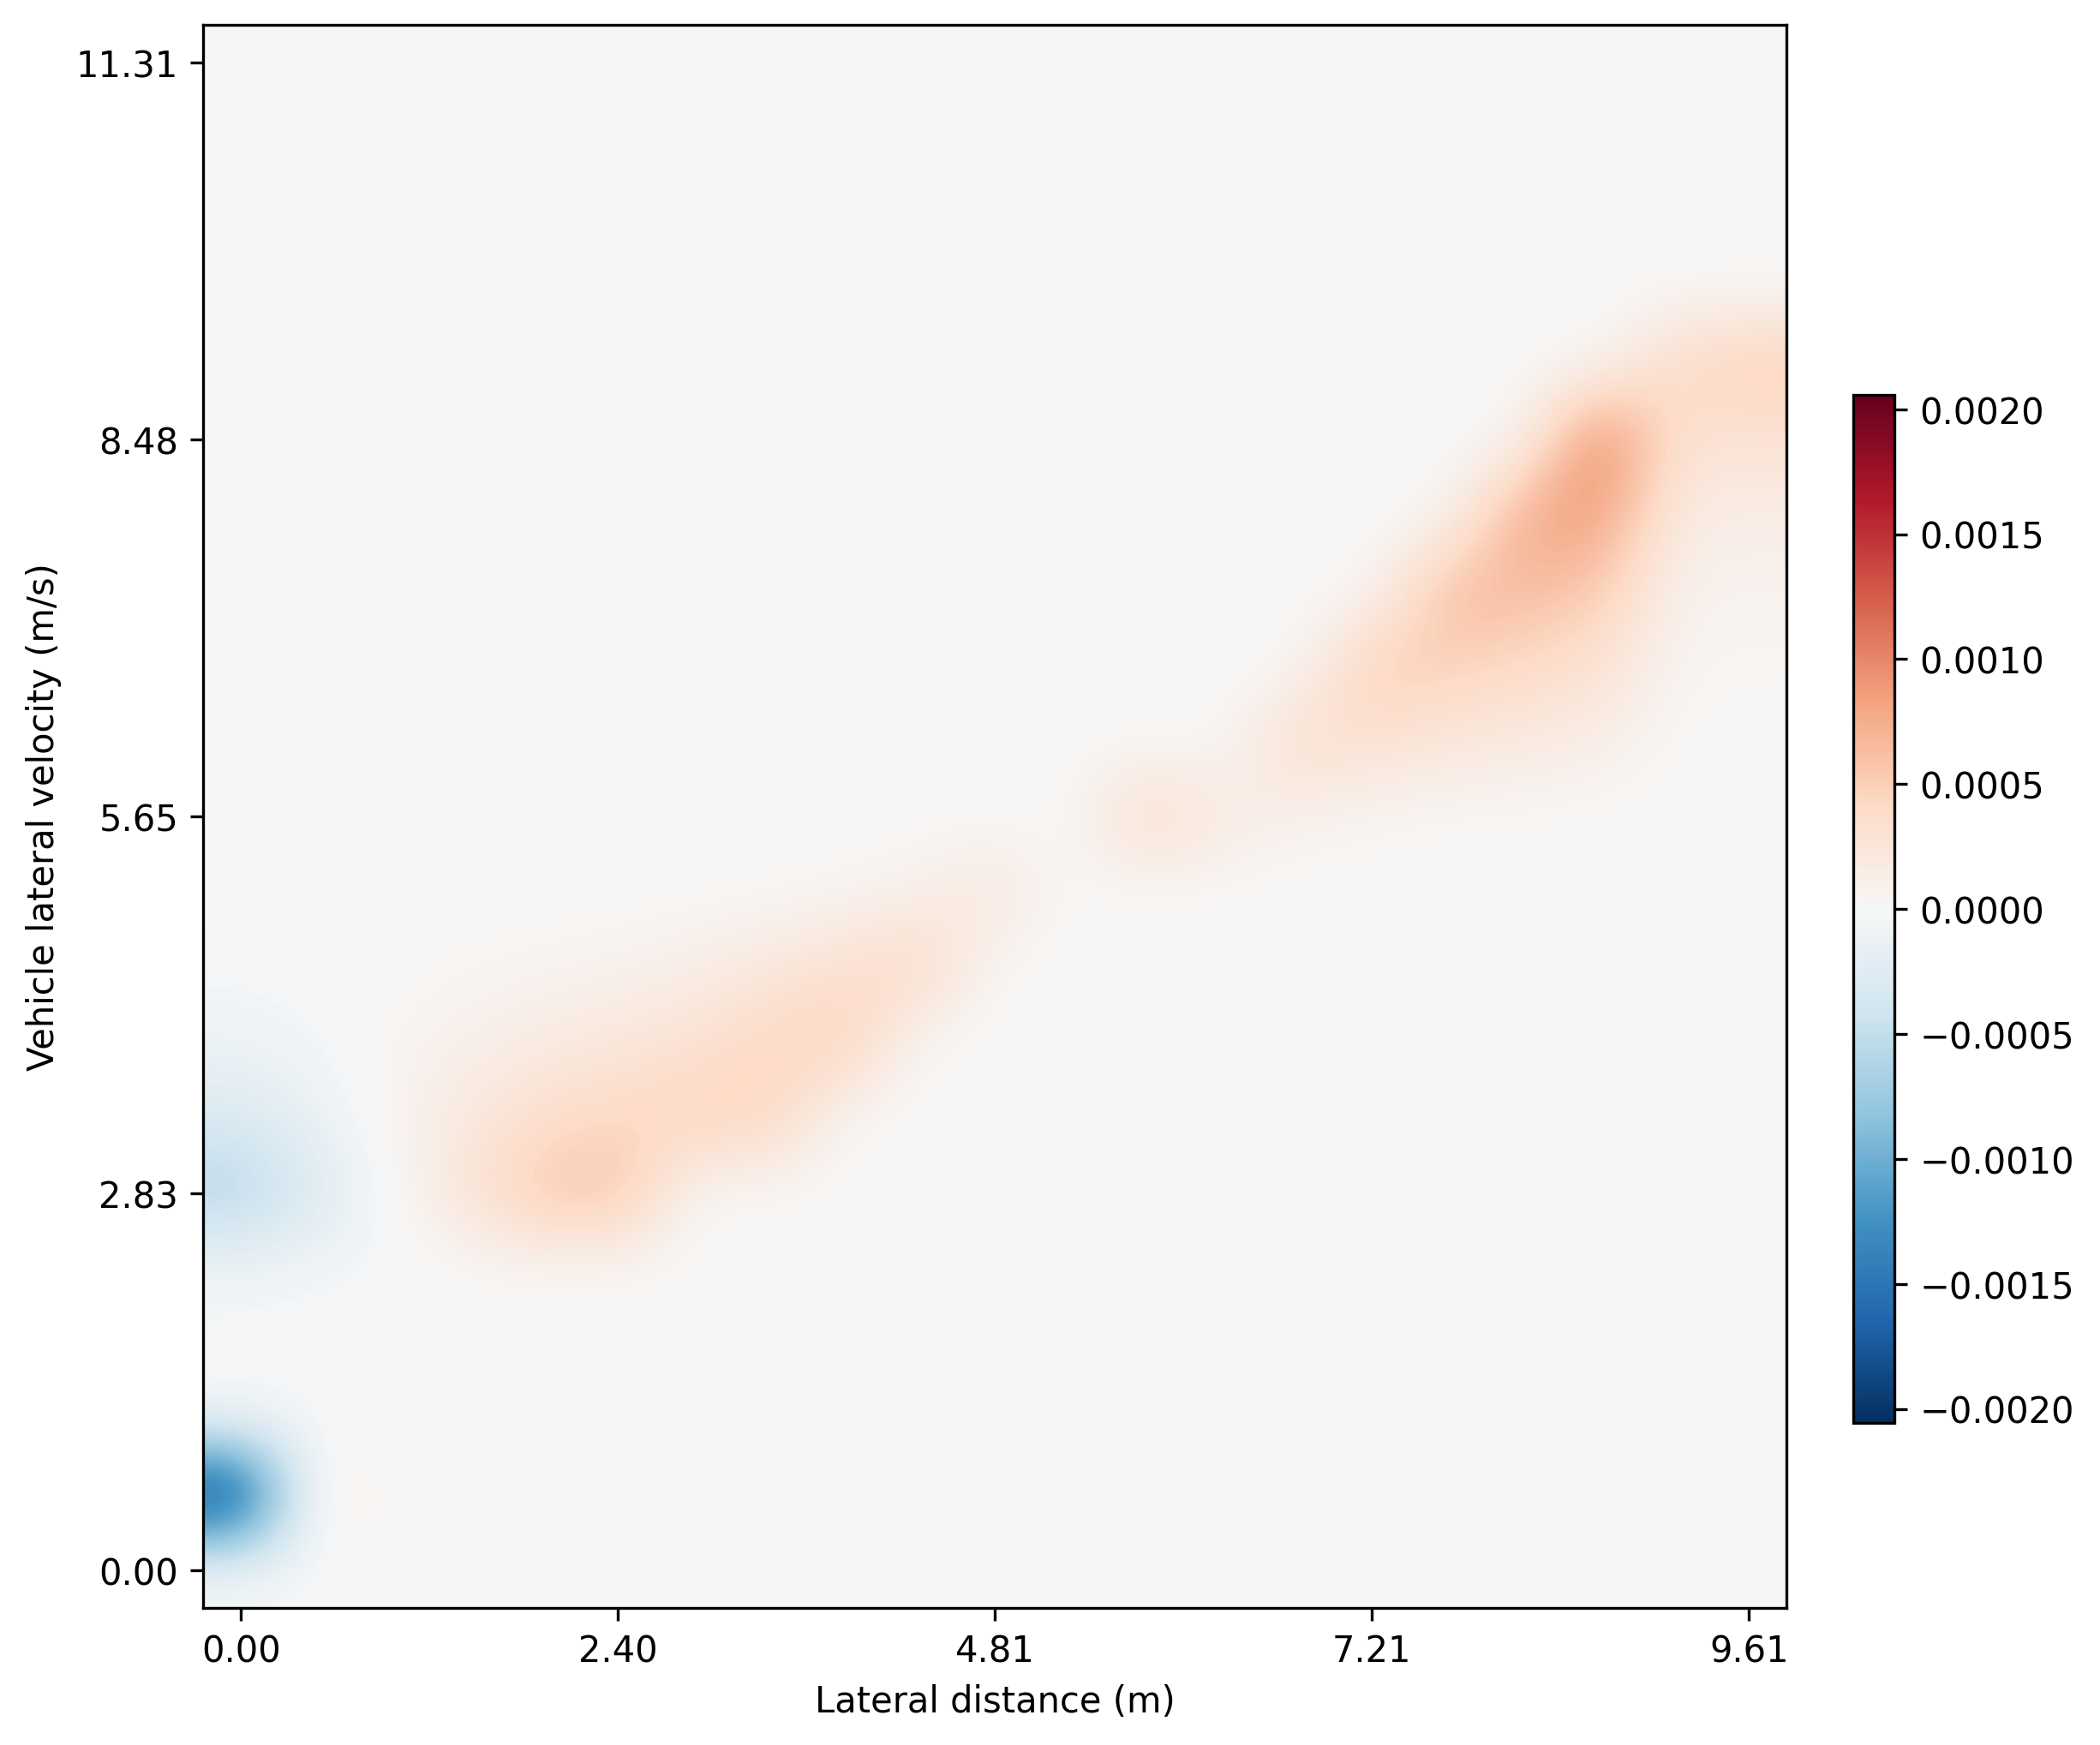

In [59]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
vmax = np.abs(record_test4_one - record_test_4).max()
plt.imshow(record_test4_one - record_test_4, cmap='RdBu_r', interpolation='bicubic', vmax=vmax, vmin=-vmax)
plt.xlabel('Lateral distance (m)')
plt.ylabel('Vehicle lateral velocity (m/s)')
plt.xticks(np.arange(0,21,5),[f"{i * gap_x / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*v_x_vehicle / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gapx-vvx-one.jpg')

plt.show()


In [60]:
## 车纵向速度、纵向距离
record_test5_one = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        import numpy as np

        # 假设原行人的位置为 (gap_x, gap_y)
        original_position = (gap_x , gap_y* (changex) / 10)

        # 半径
        radius = 1   # 可以根据需要调整

        # 计算五个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 22)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angles[13]), original_position[1] + radius * np.sin(angles[13]))]

        state_flat, all_state = env.reset()

        # v_x_pedestrian = 0
        # v_y_pedestrian = 0
        # a_x_pedestrian = 0
        # a_y_pedestrian = 0
        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle * (20 - changey) / 10 

        position_x_pedestrian = gap_x
        position_y_pedestrian = gap_y * (changex) / 10
        position_x_vehicle = 0
        position_y_vehicle = 0

        pedestrian_num = 2
        vehicle_num = 2

        # 行人状态设置
        all_state[0][0][2:,:] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1, 0] = all_state[0][0][0, 0]
        all_state[0][0][1, 1] = all_state[0][0][0, 1]
        all_state[0][0][1, 2] = all_state[0][0][0, 2]
        all_state[0][0][1, 3] = v_x_pedestrian
        all_state[0][0][1, 4] = v_y_pedestrian
        all_state[0][0][1, 5] = a_x_pedestrian
        all_state[0][0][1, 6] = a_y_pedestrian
        all_state[0][0][1, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][2:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1, :]  = np.array(new_positions)

        ## 车辆位置设置
        all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[16:48] = 0
        state_flat[64:96] = 0
        state_flat[100:108] = 0
        state_flat[112:] = 0

        ## 行人设置
        state_flat[0:16:8] = state_flat[0]
        state_flat[1:16:8] = state_flat[1]
        state_flat[2:16:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:16:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:16:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:16:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:16:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:16:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:100] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record_test5_one[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/2164228520.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


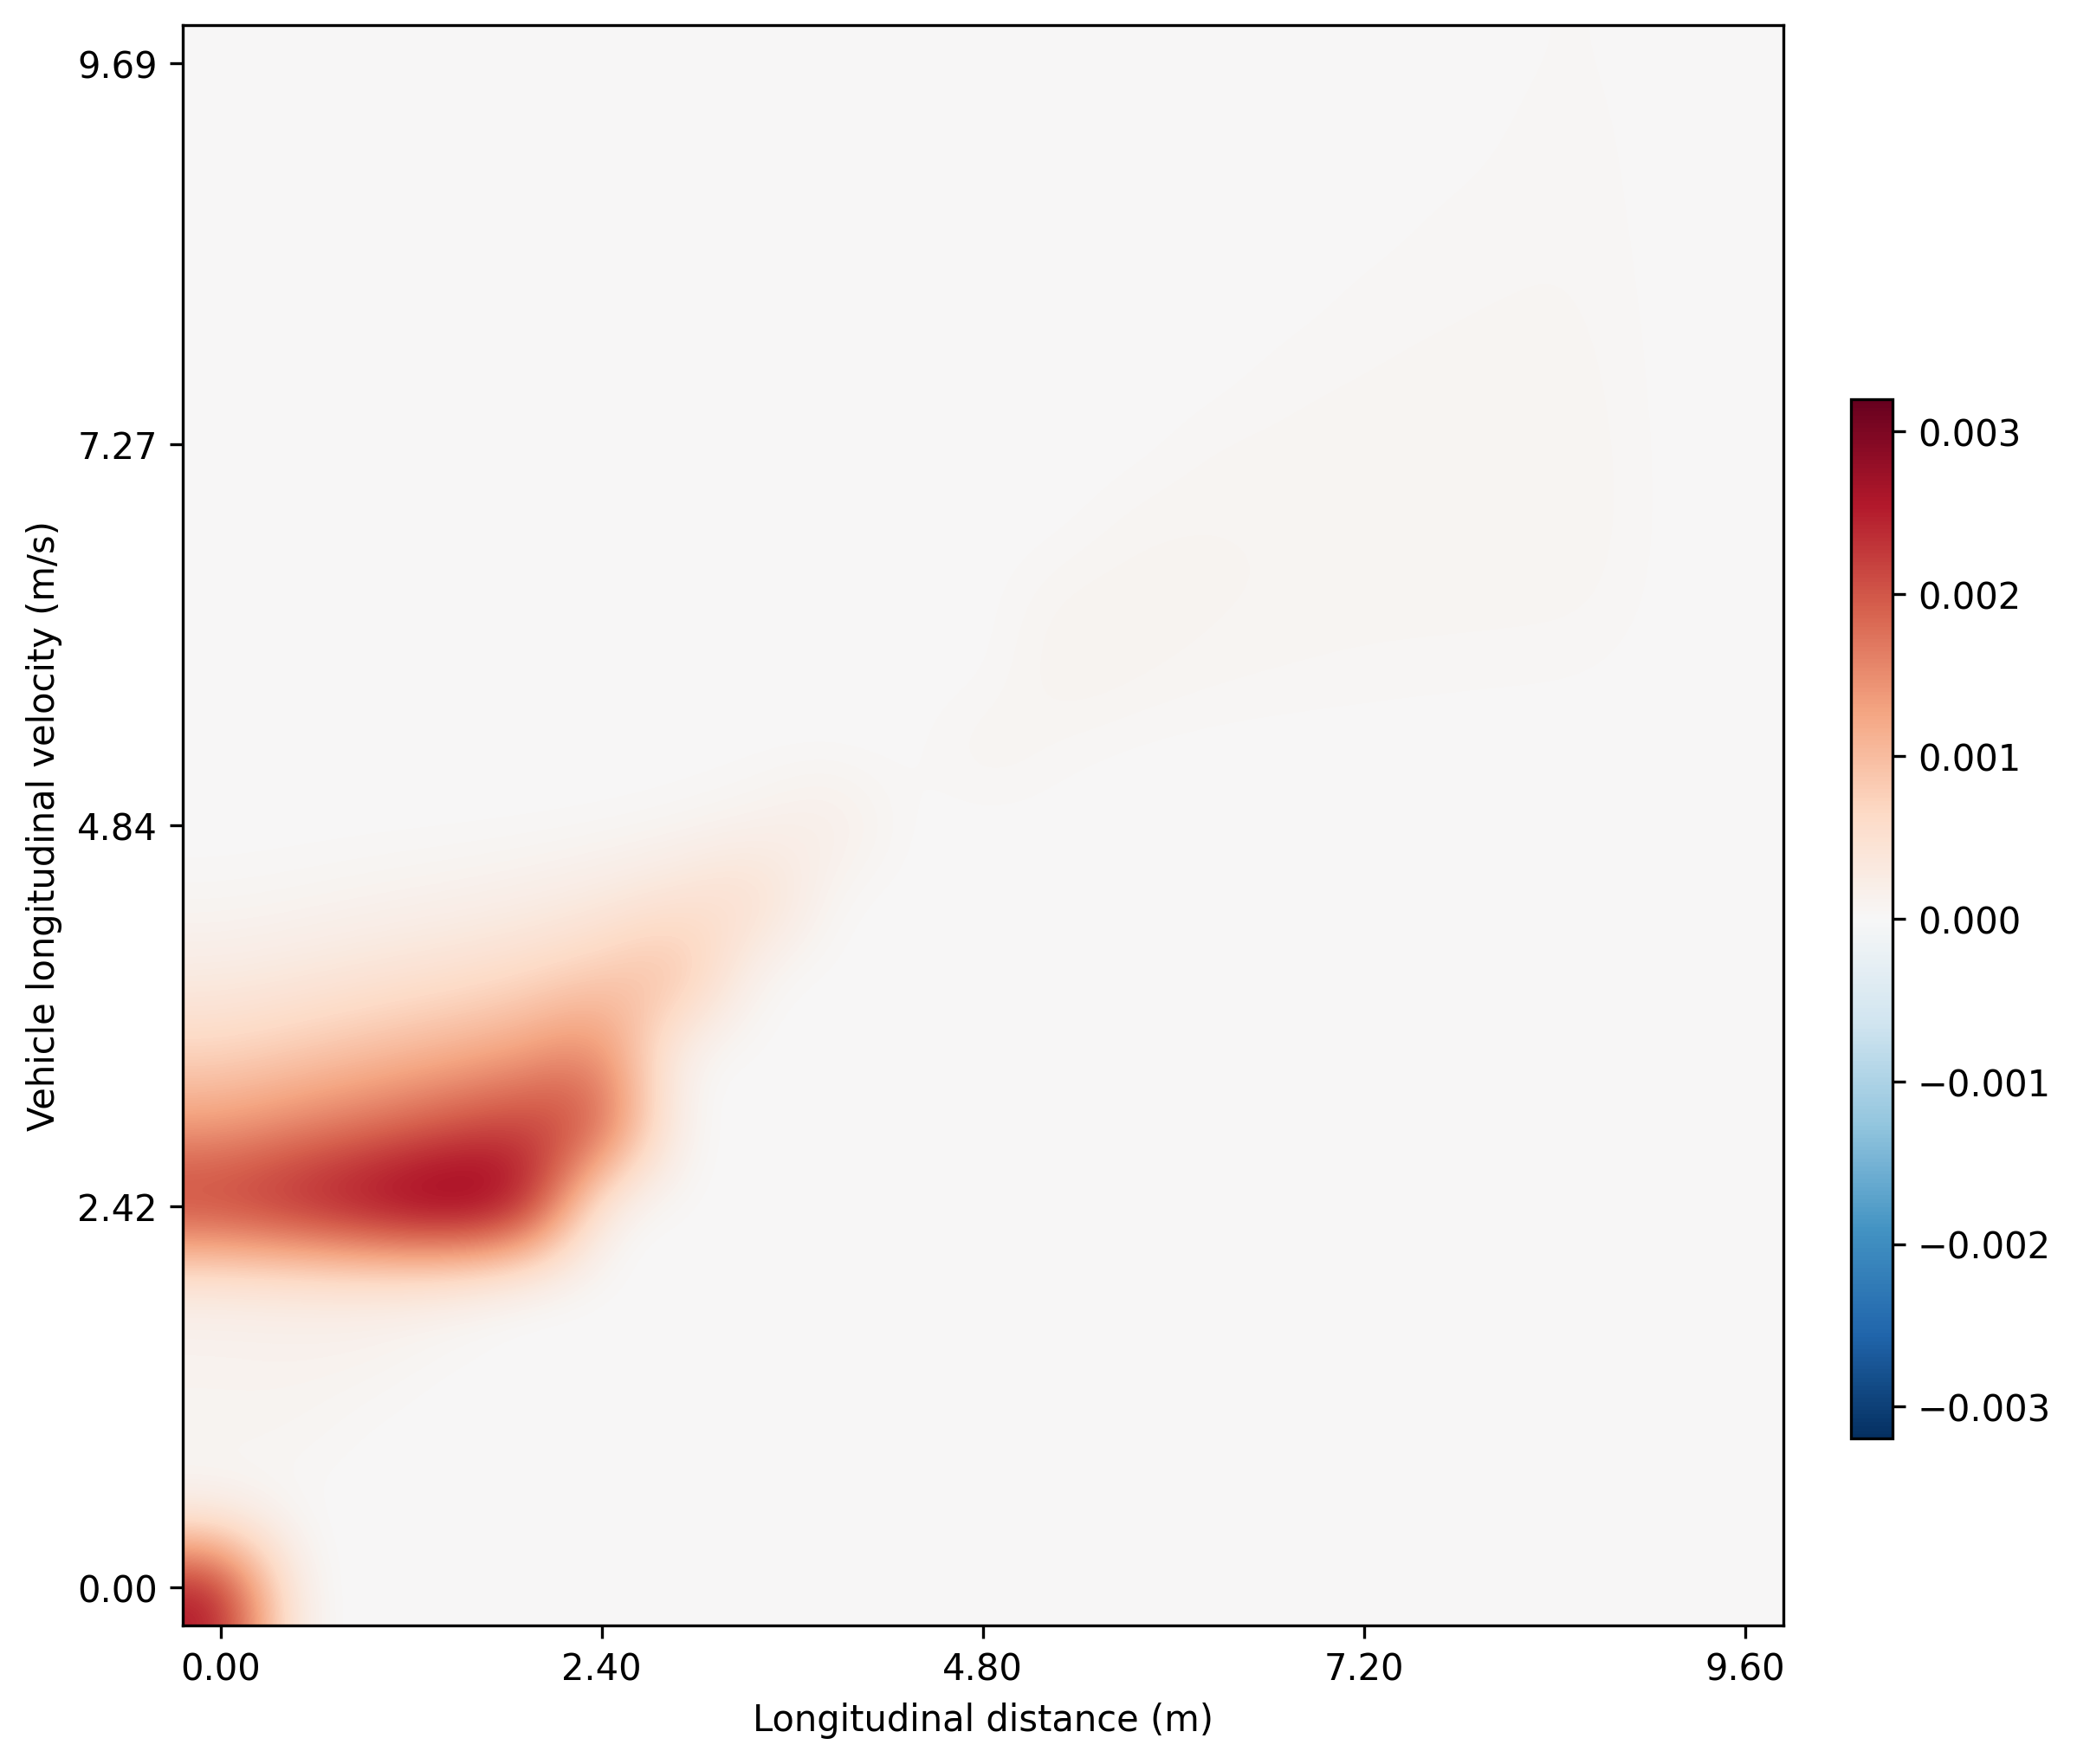

In [61]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
vmax = np.abs(record_test5_one - record_test5).max()
plt.imshow(record_test5_one - record_test5, cmap='RdBu_r', interpolation='bicubic', vmax=vmax, vmin=-vmax)
plt.xlabel('Longitudinal distance (m)')
plt.ylabel('Vehicle longitudinal velocity (m/s)')
plt.xticks(np.arange(0,21,5),[f"{i * v_y_vehicle / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{(20 - i)*gap_y / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gapy-vvy-one.jpg')

plt.show()


## 单人环绕灵敏度

In [62]:
## 角度、保持距离
record = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        import numpy as np

        # 假设原行人的位置为 (gap_x, gap_y)
        original_position = (0, 0)

        # 半径
        radius = 1   # 可以根据需要调整

        # 计算五个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 22)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angles[changex]), original_position[1] + radius * np.sin(angles[changex]))]

        state_flat, all_state = env.reset()

        v_x_pedestrian = 0
        v_y_pedestrian = 0
        # a_x_pedestrian = 0
        # a_y_pedestrian = 0
        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = 0 
        position_y_pedestrian = 0
        position_x_vehicle = -gap_x * (20 - changey) / 10 
        position_y_vehicle = -gap_y * (20 - changey) / 10 

        pedestrian_num = 2
        vehicle_num = 2

        # 行人状态设置
        all_state[0][0][2:,:] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1, 0] = all_state[0][0][0, 0]
        all_state[0][0][1, 1] = all_state[0][0][0, 1]
        all_state[0][0][1, 2] = all_state[0][0][0, 2]
        all_state[0][0][1, 3] = v_x_pedestrian
        all_state[0][0][1, 4] = v_y_pedestrian
        all_state[0][0][1, 5] = a_x_pedestrian
        all_state[0][0][1, 6] = a_y_pedestrian
        all_state[0][0][1, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][2:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1, :]  = np.array(new_positions)

        ## 车辆位置设置
        all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[16:48] = 0
        state_flat[64:96] = 0
        state_flat[100:108] = 0
        state_flat[112:] = 0

        ## 行人设置
        state_flat[0:16:8] = state_flat[0]
        state_flat[1:16:8] = state_flat[1]
        state_flat[2:16:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:16:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:16:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:16:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:16:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:16:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:100] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/511358948.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


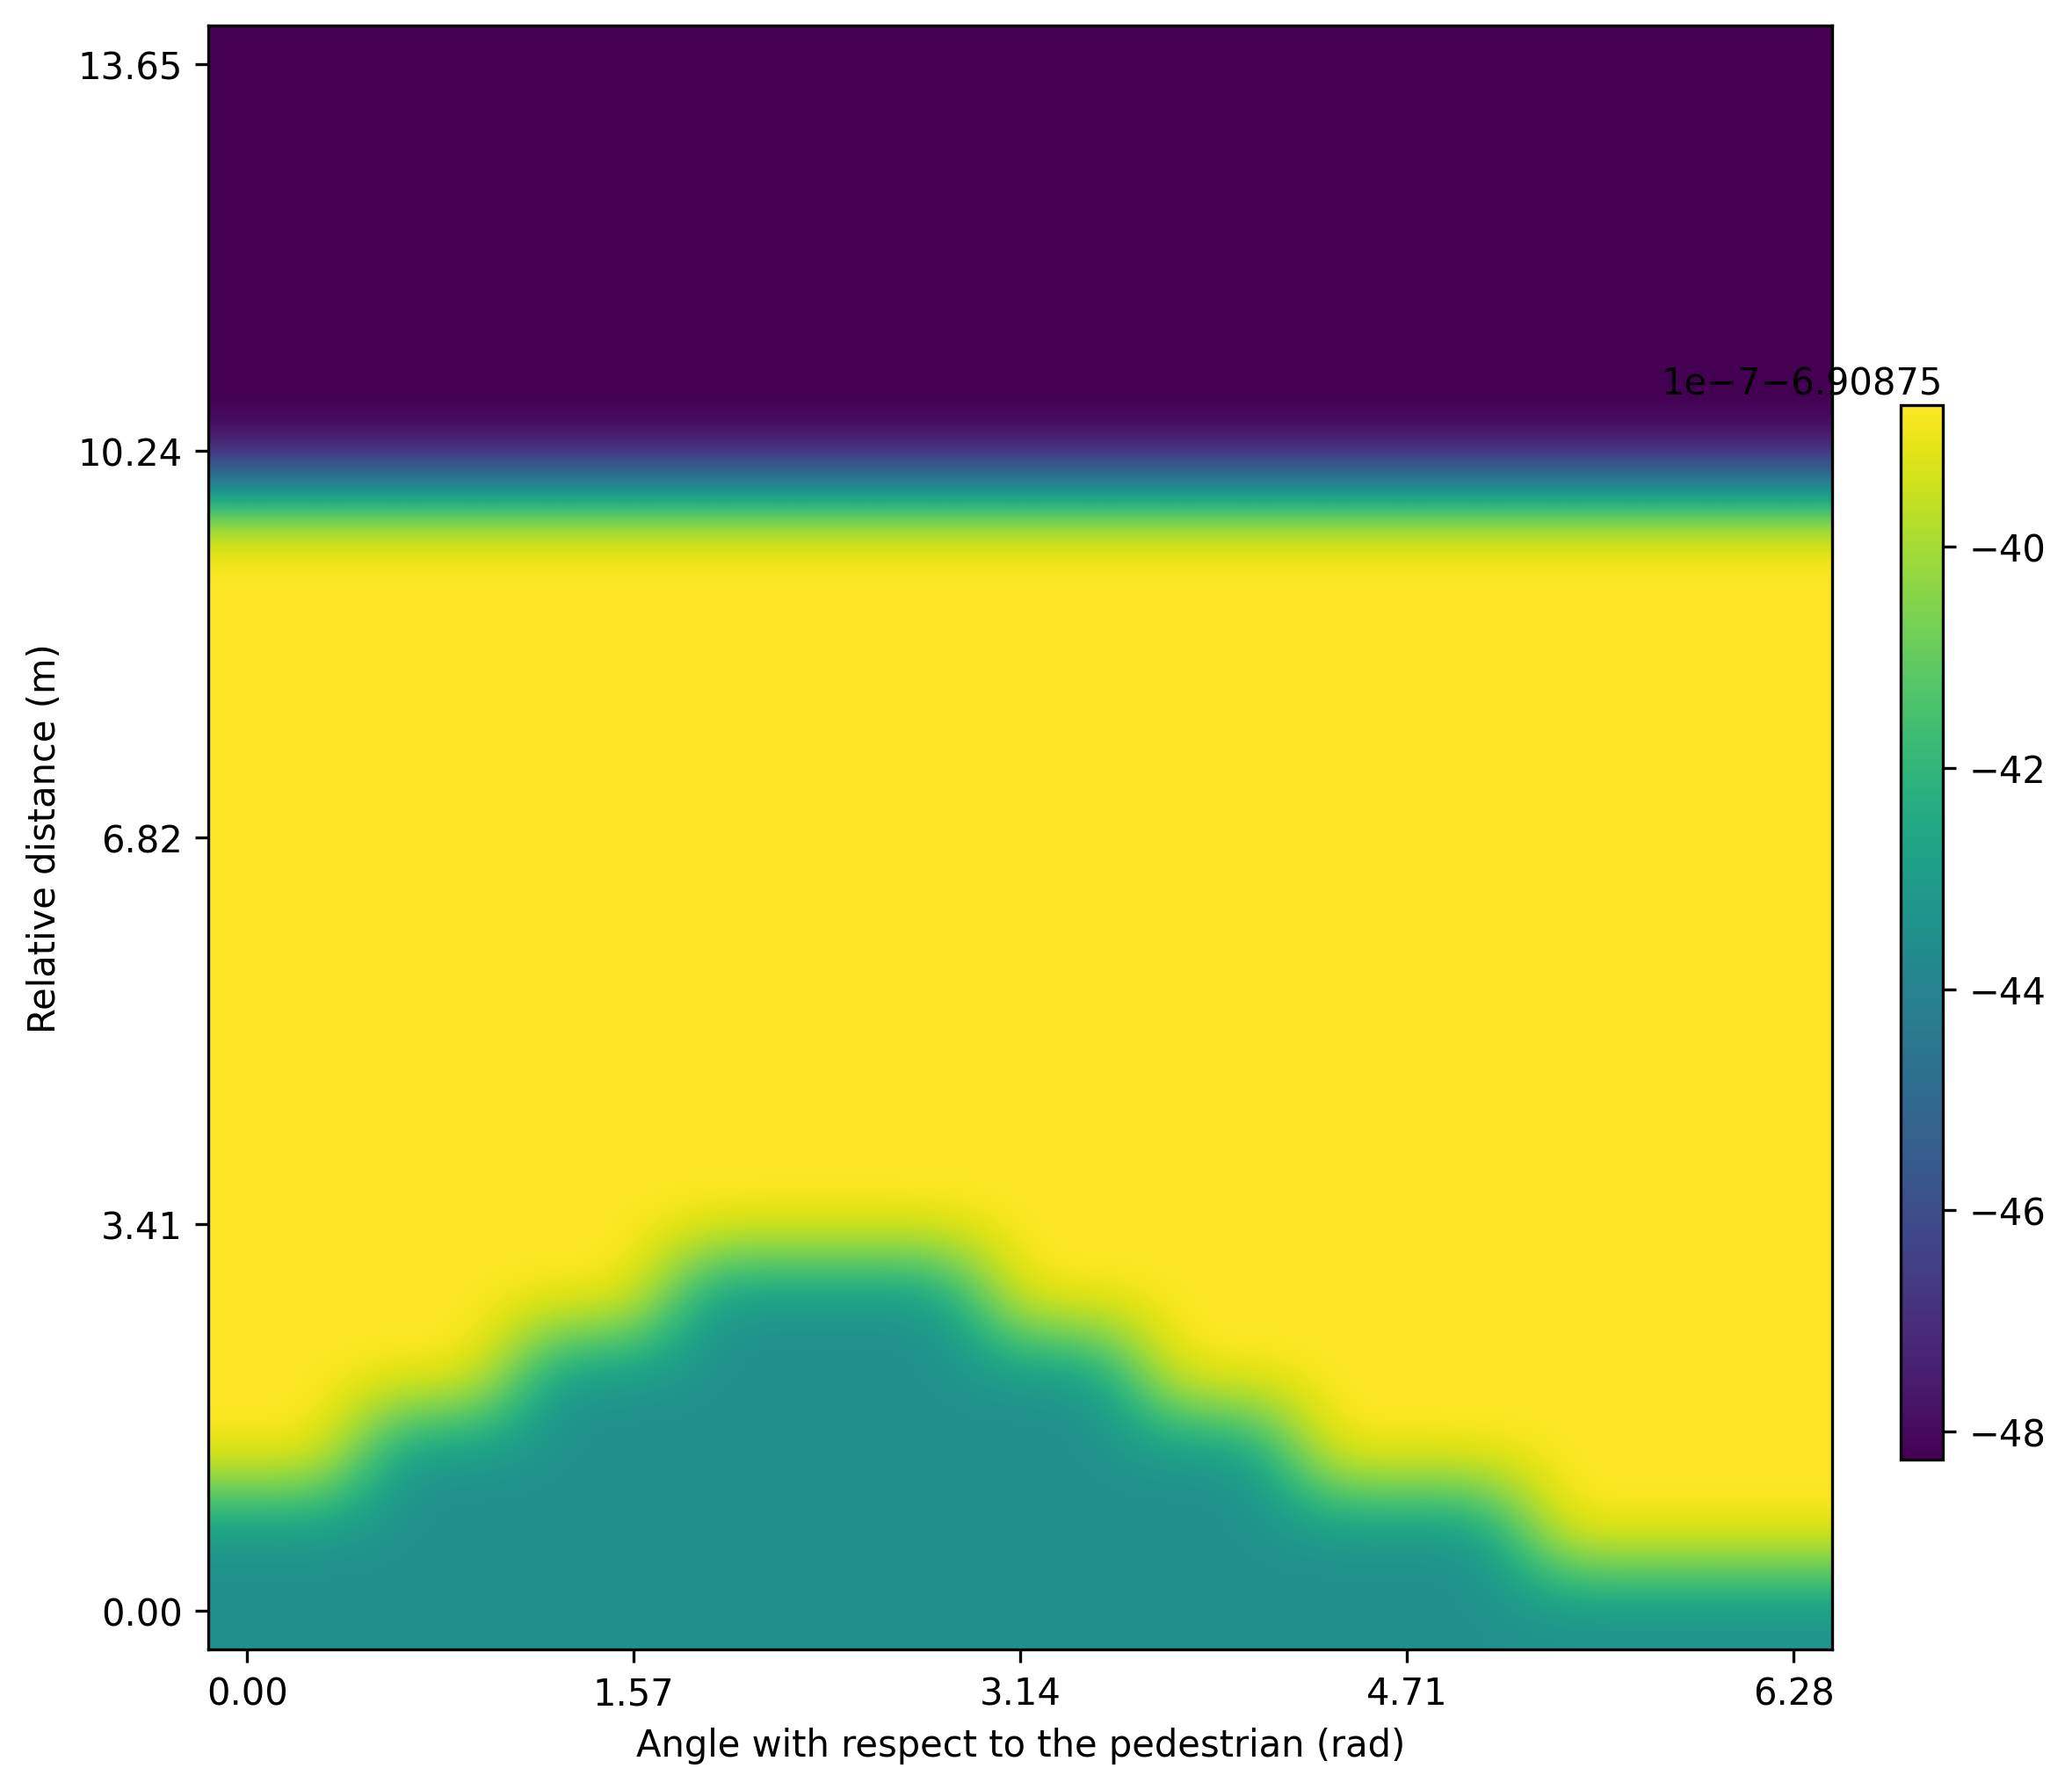

In [63]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
plt.imshow(record, cmap='viridis', interpolation='bicubic')
plt.xlabel('Angle with respect to the pedestrian (rad)')
plt.ylabel('Relative distance (m)')
plt.xticks(np.arange(0,21,5),[f"{(i) * 2 * 3.14 / 20:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{math.sqrt(((20 - i)* gap_y)**2 + ((20 - i)* gap_x)**2) / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gap-angle-one.jpg')

plt.show()


In [64]:
## 距离、保持距离
record = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        import numpy as np

        # 假设原行人的位置为 (gap_x, gap_y)
        original_position = (0, 0)

        # 半径
        radius = 1 * (changex + 0.1) /10  # 可以根据需要调整

        # 计算五个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 22)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angles[13]), original_position[1] + radius * np.sin(angles[13]))]

        state_flat, all_state = env.reset()

        v_x_pedestrian = 0
        v_y_pedestrian = 0
        ## 初始值设置
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = 0 
        position_y_pedestrian = 0
        position_x_vehicle = -gap_x * (20 - changey) / 10 
        position_y_vehicle = -gap_y * (20 - changey) / 10 

        pedestrian_num = 2
        vehicle_num = 2

        # 行人状态设置
        all_state[0][0][2:,:] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1, 0] = all_state[0][0][0, 0]
        all_state[0][0][1, 1] = all_state[0][0][0, 1]
        all_state[0][0][1, 2] = all_state[0][0][0, 2]
        all_state[0][0][1, 3] = v_x_pedestrian
        all_state[0][0][1, 4] = v_y_pedestrian
        all_state[0][0][1, 5] = a_x_pedestrian
        all_state[0][0][1, 6] = a_y_pedestrian
        all_state[0][0][1, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][2:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1, :]  = np.array(new_positions)

        ## 车辆位置设置
        all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[16:48] = 0
        state_flat[64:96] = 0
        state_flat[100:108] = 0
        state_flat[112:] = 0

        ## 行人设置
        state_flat[0:16:8] = state_flat[0]
        state_flat[1:16:8] = state_flat[1]
        state_flat[2:16:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:16:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:16:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:16:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:16:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:16:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:100] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/4178836098.py:135: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


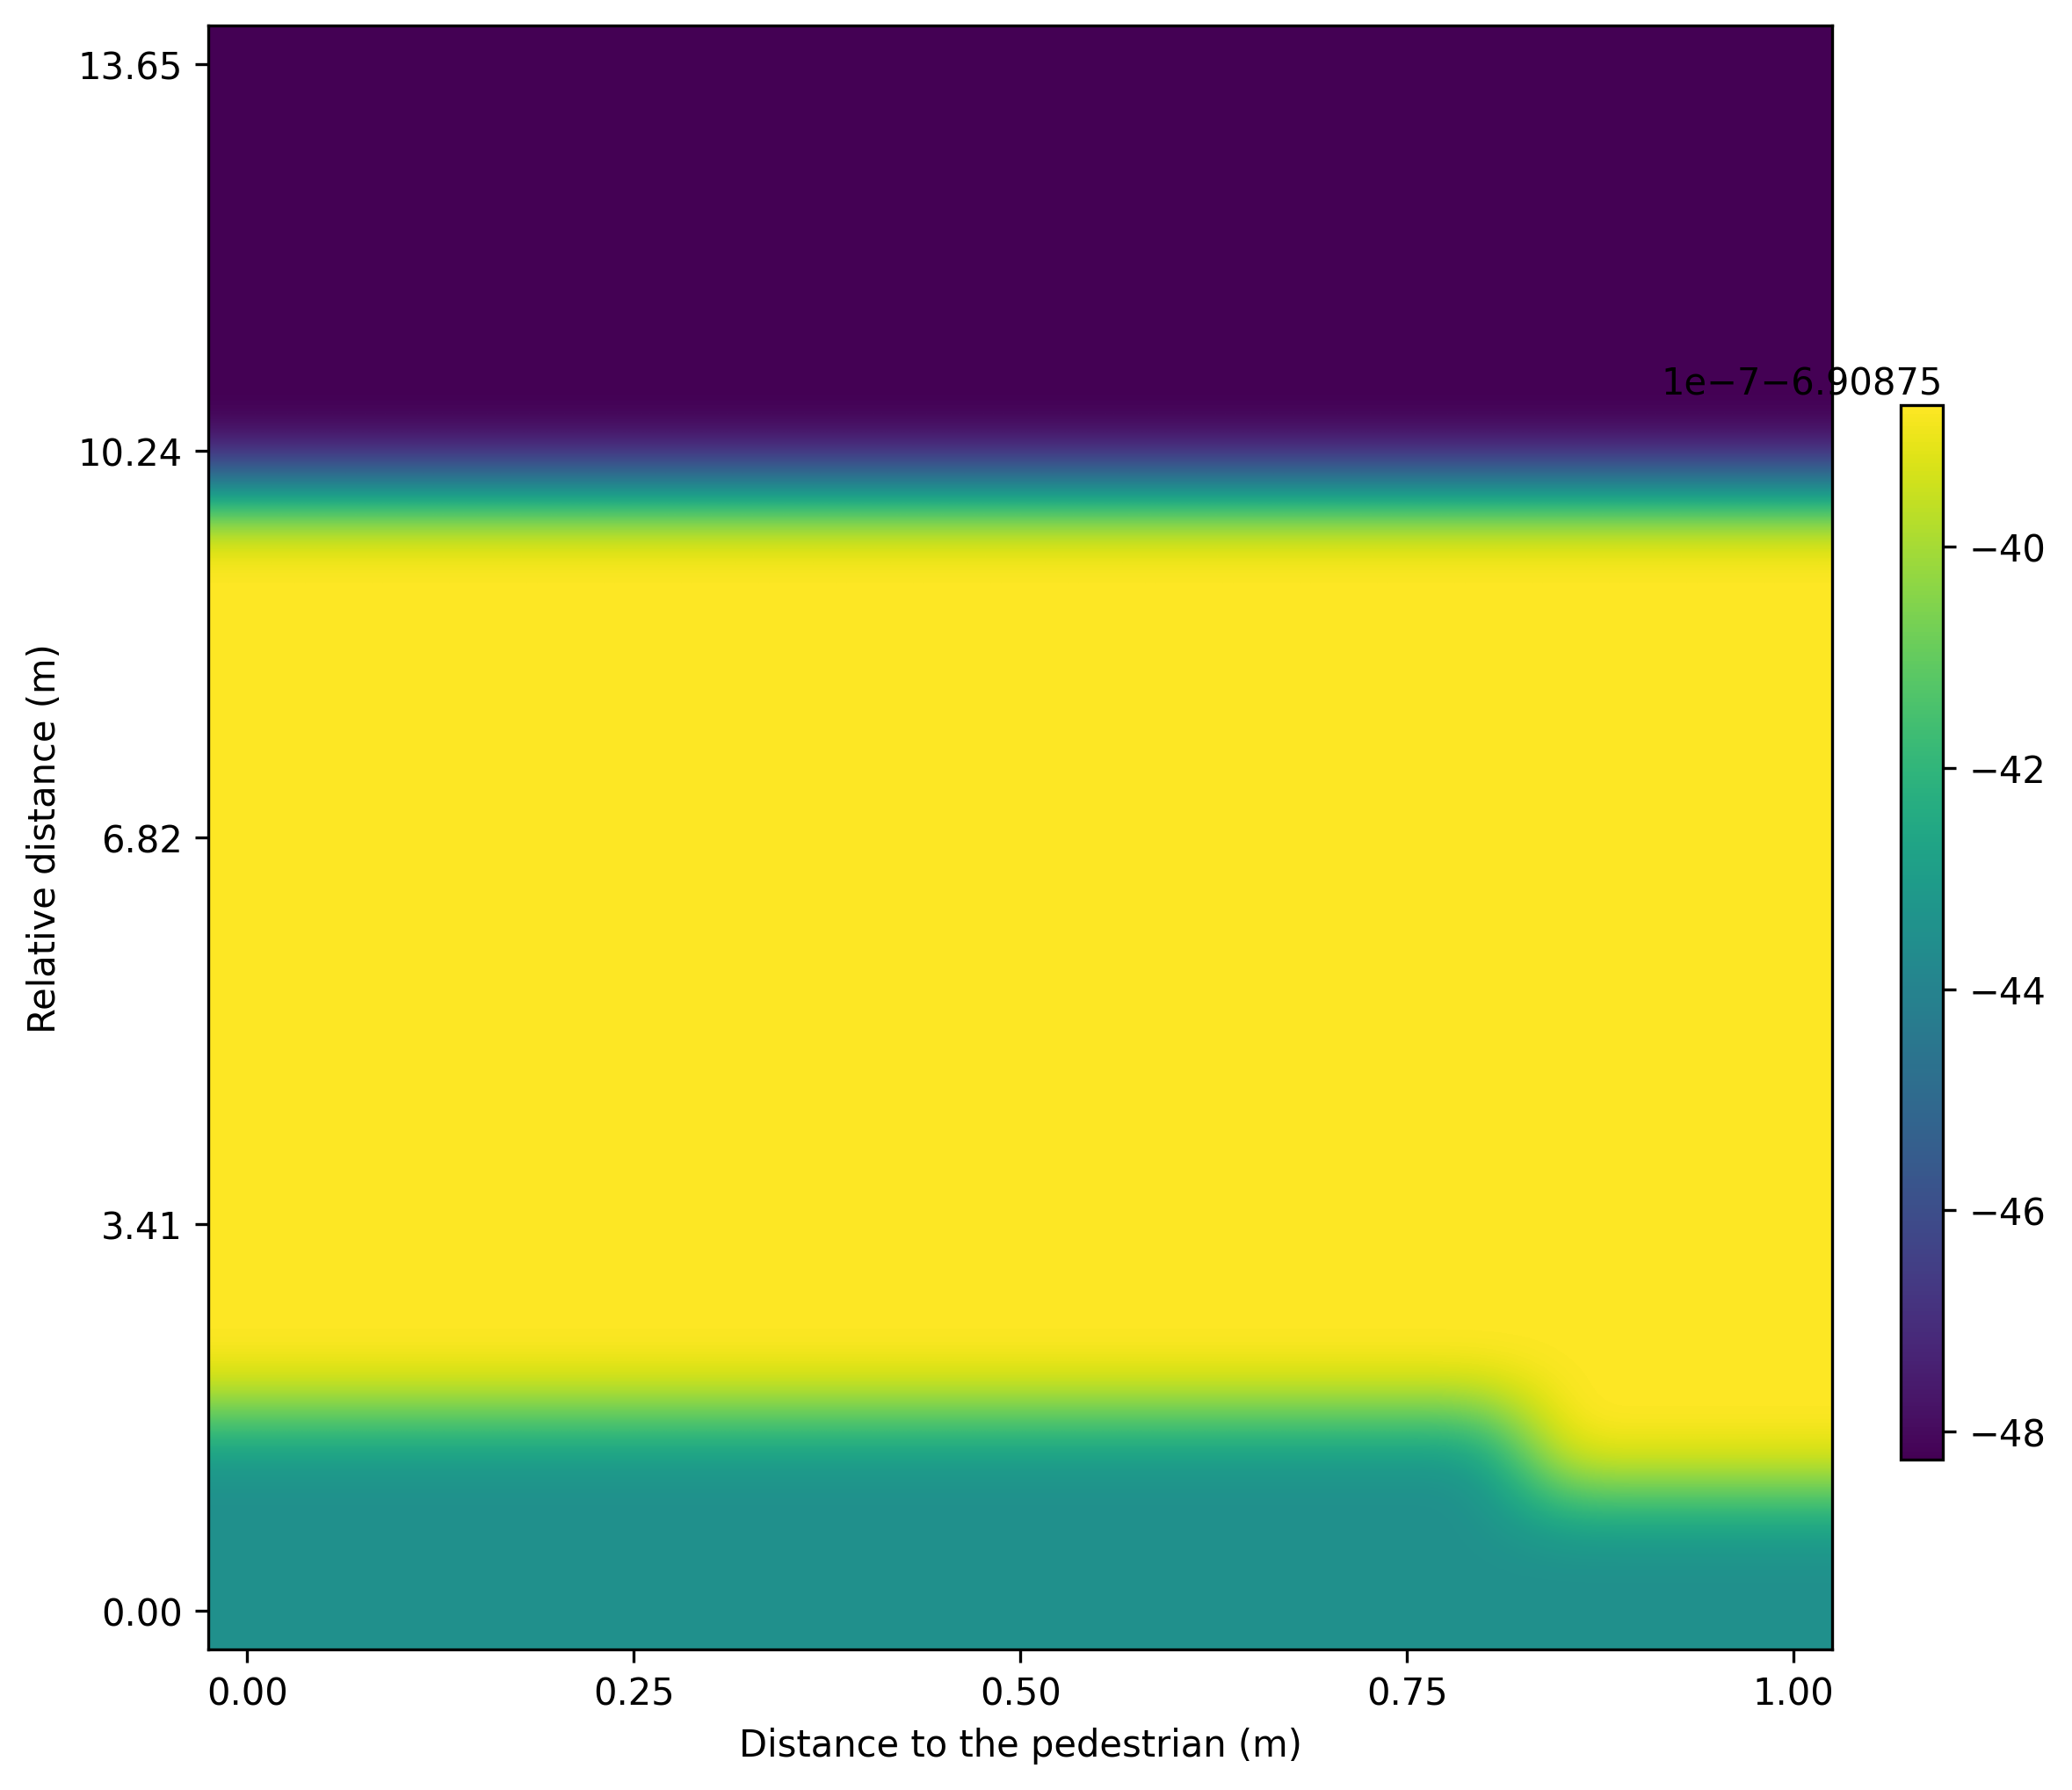

In [65]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
plt.imshow(record, cmap='viridis', interpolation='bicubic')
plt.xlabel('Distance to the pedestrian (m)')
plt.ylabel('Relative distance (m)')
plt.xticks(np.arange(0,21,5),[f"{(i) * 1 / 20:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{math.sqrt(((20 - i)* gap_y)**2 + ((20 - i)* gap_x)**2) / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gap-distance-one.jpg')

plt.show()


## 四等环绕灵敏度

In [66]:
## 横向速度、横向距离
record = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        import numpy as np

        # 假设原行人的位置为 (gap_x, gap_y)
        original_position = (0, 0)

        # 半径
        radius = 1 * (changex + 0.1) / 10  # 可以根据需要调整

        # 计算四个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 5)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angle), original_position[1] + radius * np.sin(angle)) for angle in angles]

        state_flat, all_state = env.reset()

        ## 初始值设置
        v_x_pedestrian = 0
        v_y_pedestrian = 0
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = 0
        position_y_pedestrian = 0
        position_x_vehicle = -gap_x * (20 - changey) / 10
        position_y_vehicle = -gap_y * (20 - changey) / 10 

        pedestrian_num = 5
        vehicle_num = 6

        # 行人状态设置
        all_state[0][0][5:, :] = 0
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1:5, 0] = all_state[0][0][0, 0]
        all_state[0][0][1:5, 1] = all_state[0][0][0, 1]
        all_state[0][0][1:5, 2] = all_state[0][0][0, 2]
        all_state[0][0][1:5, 3] = v_x_pedestrian
        all_state[0][0][1:5, 4] = v_y_pedestrian
        all_state[0][0][1:5, 5] = a_x_pedestrian
        all_state[0][0][1:5, 6] = a_y_pedestrian
        all_state[0][0][1:5, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        # all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        all_state[0][2][5:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1:5, :]  = np.array(new_positions)

        ## 车辆位置设置
        # all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        state_flat[40:48] = 0
        # state_flat[64:96] = 0
        state_flat[106:108] = 0
        # state_flat[112:] = 0

        ## 行人设置
        state_flat[0:40:8] = state_flat[0]
        state_flat[1:40:8] = state_flat[1]
        state_flat[2:40:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:40:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:40:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:40:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:40:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:40:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:106] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/163698902.py:135: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


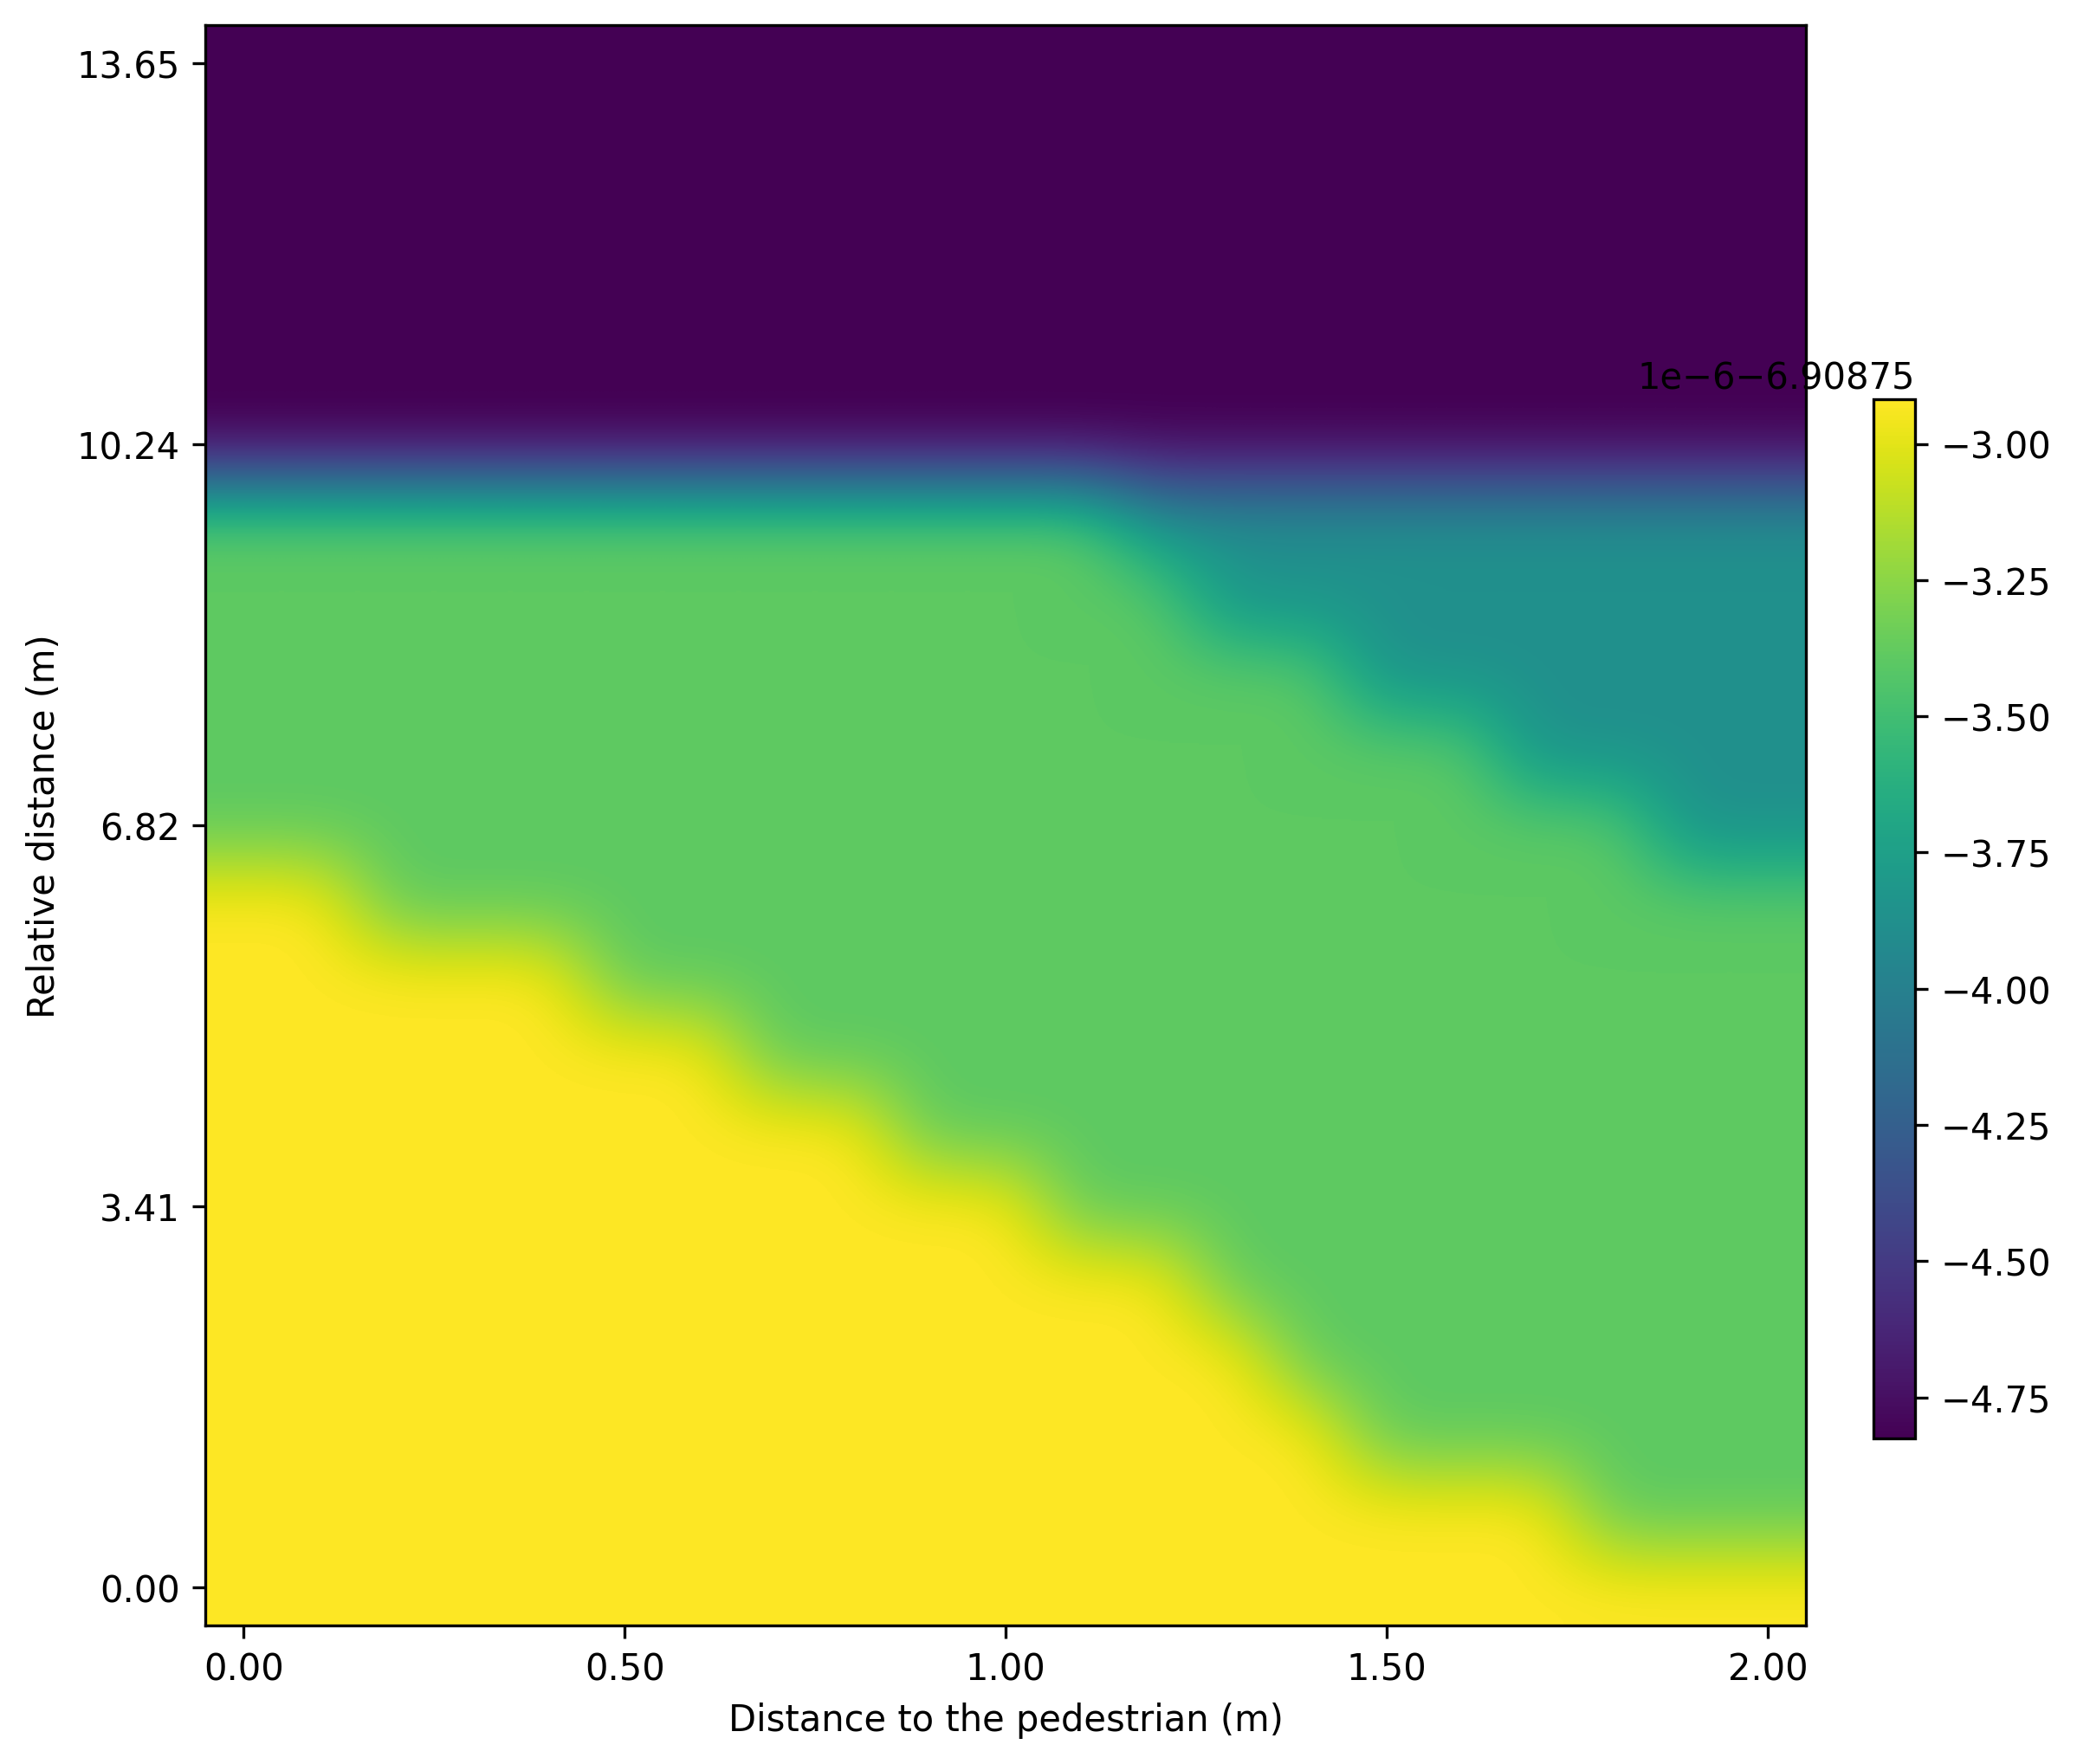

In [67]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
plt.imshow(record, cmap='viridis', interpolation='bicubic')
plt.xlabel('Distance to the pedestrian (m)')
plt.ylabel('Relative distance (m)')
plt.xticks(np.arange(0,21,5),[f"{(i) * 1 / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{math.sqrt(((20 - i)* gap_y)**2 + ((20 - i)* gap_x)**2) / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gap-distance-four.jpg')

plt.show()


## 五等环绕灵敏度

In [68]:
## 横向速度、横向距离
record = np.zeros((21,21))
for changey in range(0,21):
    for changex in range(0,21):
        import numpy as np

        # 假设原行人的位置为 (gap_x, gap_y)
        original_position = (0, 0)

        # 半径
        radius = 1 * (changex + 0.1) / 10  # 可以根据需要调整

        # 计算五个新行人的位置
        angles = np.linspace(0, 2 * np.pi, 6)[:-1]  # 0 到 2π 之间的五个等分角度
        new_positions = [(original_position[0] + radius * np.cos(angle), original_position[1] + radius * np.sin(angle)) for angle in angles]

        state_flat, all_state = env.reset()

        ## 初始值设置
        v_x_pedestrian = 0
        v_y_pedestrian = 0
        # a_x_pedestrian = 0
        # a_y_pedestrian = 0
        speed_x_pedestrian = v_x_pedestrian
        speed_y_pedestrian = v_y_pedestrian
        speed_x_vehicle = v_x_vehicle
        speed_y_vehicle = v_y_vehicle

        position_x_pedestrian = 0
        position_y_pedestrian = 0
        position_x_vehicle = -gap_x * (20 - changey) / 10
        position_y_vehicle = -gap_y * (20 - changey) / 10 

        pedestrian_num = 6
        vehicle_num = 6

        # 行人状态设置
        all_state[0][0][0, 3] = speed_x_pedestrian
        all_state[0][0][0, 4] = speed_y_pedestrian
        all_state[0][0][0, 5] = a_x_pedestrian
        all_state[0][0][0, 6] = a_y_pedestrian
        all_state[0][0][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))


        all_state[0][0][1:, 0] = all_state[0][0][0, 0]
        all_state[0][0][1:, 1] = all_state[0][0][0, 1]
        all_state[0][0][1:, 2] = all_state[0][0][0, 2]
        all_state[0][0][1:, 3] = v_x_pedestrian
        all_state[0][0][1:, 4] = v_y_pedestrian
        all_state[0][0][1:, 5] = a_x_pedestrian
        all_state[0][0][1:, 6] = a_y_pedestrian
        all_state[0][0][1:, 7] = (math.atan2(v_y_pedestrian, v_x_pedestrian))

        # 车辆状态设置
        # all_state[0][1][2:,:] = 0
        all_state[0][1][0, 3] = speed_x_pedestrian
        all_state[0][1][0, 4] = speed_y_pedestrian
        all_state[0][1][0, 5] = a_x_pedestrian
        all_state[0][1][0, 6] = a_y_pedestrian
        all_state[0][1][0, 7] = (math.atan2(speed_y_pedestrian, speed_x_pedestrian))
        all_state[0][1][1, 3] = speed_x_vehicle
        all_state[0][1][1, 4] = speed_y_vehicle
        all_state[0][1][1, 5] = a_x_vehicle
        all_state[0][1][1, 6] = a_y_vehicle
        all_state[0][1][1, 7] = math.atan2(speed_y_vehicle, speed_x_vehicle)

        ## 行人位置设置
        # all_state[0][2][1:,:] = 0
        all_state[0][2][0, 0] = position_x_pedestrian
        all_state[0][2][0, 1] = position_y_pedestrian
        all_state[0][2][1:, :]  = np.array(new_positions)

        ## 车辆位置设置
        # all_state[0][3][2:,:] = 0
        all_state[0][3][0, 0] = position_x_pedestrian
        all_state[0][3][0, 1] = position_y_pedestrian
        all_state[0][3][1,0] = position_x_vehicle
        all_state[0][3][1,1] = position_y_vehicle

        ## 行人数量设置
        all_state[0][4] = pedestrian_num

        ## 车辆数量设置
        all_state[0][5] = vehicle_num

        ##清空
        # state_flat[8:48] = 0
        # state_flat[64:96] = 0
        # state_flat[98:108] = 0
        # state_flat[112:] = 0

        ## 行人设置
        state_flat[0:48:8] = state_flat[0]
        state_flat[1:48:8] = state_flat[1]
        state_flat[2:48:8] = state_flat[2]
        state_flat[3],state_flat[51] = [speed_x_pedestrian]*2 #x速度
        state_flat[11:48:8] = v_x_pedestrian
        state_flat[4],state_flat[52] = [(speed_y_pedestrian)]*2 #y速度
        state_flat[12:48:8] = v_y_pedestrian
        state_flat[5],state_flat[53]= [(a_x_pedestrian)]*2 #x加速度
        state_flat[5:48:8] = a_x_pedestrian
        state_flat[6],state_flat[54]= [(a_y_pedestrian)]*2 #y加速度
        state_flat[6:48:8] = a_y_pedestrian
        state_flat[7],state_flat[55]= [(math.atan2(state_flat[4], state_flat[3]))]*2 #朝向
        state_flat[7:48:8] = math.atan2(v_y_pedestrian, v_x_pedestrian)

        ## 行人位置设置
        state_flat[96]=position_x_pedestrian #x位置
        state_flat[97]=position_y_pedestrian   #y位置
        state_flat[98:108] = np.array(new_positions).flatten()


        state_flat[108]=position_x_pedestrian #x位置
        state_flat[109]=position_y_pedestrian   #y位置

        ## 车辆设置
        state_flat[59]=speed_x_vehicle #x速度
        state_flat[60]=speed_y_vehicle  #y速度
        state_flat[61]=a_x_vehicle  #x加速度
        state_flat[62]=a_y_vehicle  #y加速度
        state_flat[63]=math.atan2(state_flat[60], state_flat[59])  #朝向

        ## 车辆位置设置
        state_flat[110]=position_x_vehicle #x位置
        state_flat[111]=position_y_vehicle   #y位置

        ##奖励值获取
        keep = True
        torch.manual_seed(0)
        # while keep:
        action, log_prob = agent.get_action(torch.from_numpy(state_flat).float().to(device))
            # if (action[0][0] > 0).cpu().detach().numpy() & (action[0][1] < 0).cpu().detach().numpy():
            #     keep = False
        # action = agent.get_action(torch.from_numpy(state_flat).float().to(device))

        action = torch.tensor(action).cpu().detach().numpy()[0]
        log_prob = log_prob.to(device)
        ##状态更新
        next_state_flat = update(action,state_flat)
        done = False
        reward = discriminator.get_reward( \
                    log_prob,
                    all_state,
                    torch.tensor(state_flat).unsqueeze(0).float().to(device),action,\
                    torch.tensor(next_state_flat).unsqueeze(0).float().to(device),\
                                            torch.tensor(done).unsqueeze(0)\
                                            ).item()
        record[changey,changex] = reward

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)
/tmp/ipykernel_32910/2804478873.py:136: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action = torch.tensor(action).cpu().detach().numpy()[0]


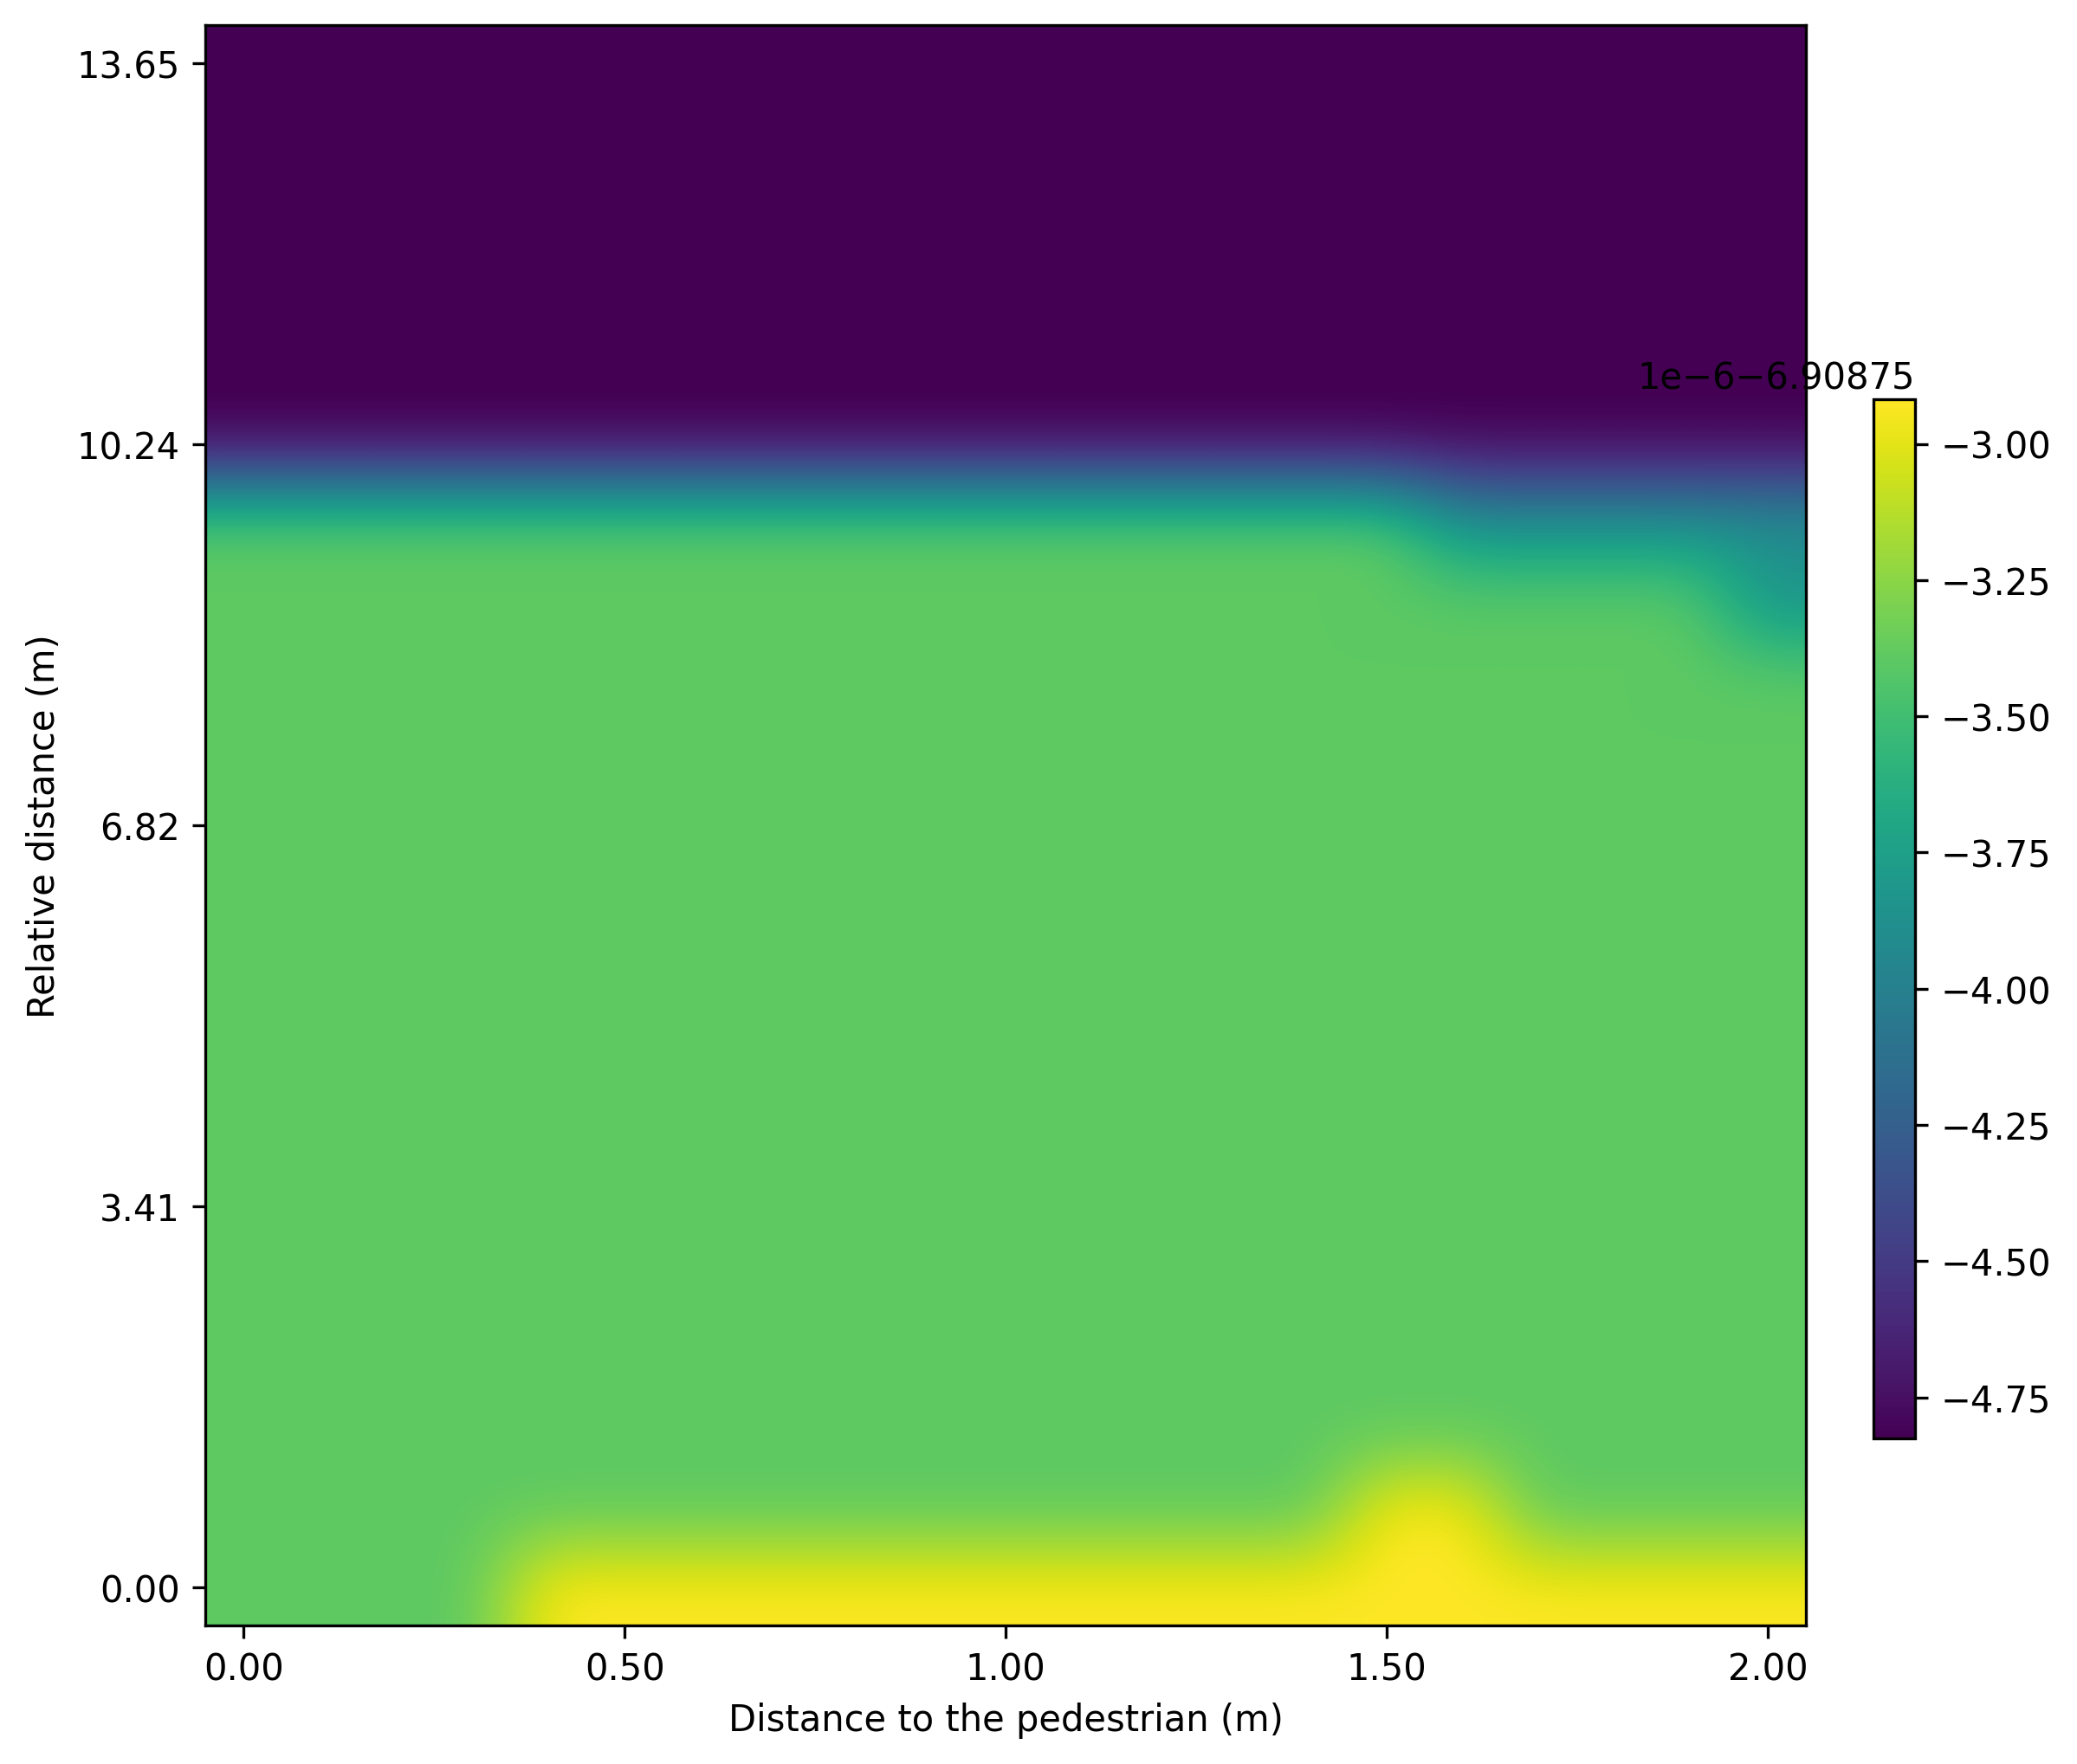

In [69]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
plt.imshow(record, cmap='viridis', interpolation='bicubic')
plt.xlabel('Distance to the pedestrian (m)')
plt.ylabel('Relative distance (m)')
plt.xticks(np.arange(0,21,5),[f"{(i) * 1 / 10:.2f}" for i in np.arange(0,21,5)])
plt.yticks(np.arange(0,21,5),[f"{math.sqrt(((20 - i)* gap_y)**2 + ((20 - i)* gap_x)**2) / 10:.2f}" for i in np.arange(0,21,5)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')
plt.savefig('figs/gap-distance-five.jpg')

plt.show()


# 参与者关系图构建

In [70]:
## 98的时候（平行）、148（交叉）、221相反
env.current_scene = 221
state_flat, all_state = env.reset()
data_pedestrain = (all_state[:, 0], all_state[:, 2],
                           all_state[:, 4])

discriminator.g_p.get_relation_graph(data_pedestrain, type='pedestrian')

/mnt/d/OneDrive/Python scripts for big data/2024_05 重点研发/2024_07 行人交互机理分析/InverseRL-Pytorch-main-group-AIRL-SAC-修改记忆池逻辑-更改训练逻辑-修改博弈-滤波数据/InverseRL-Pytorch-main/envDesign/environment.py:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return self.state, np.array(self.all_state).reshape(1, -1)


tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.7545, 0.2455, 0.0000, 0.0000],
         [0.0000, 0.2090, 0.7910, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 1.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 1.0000]]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)

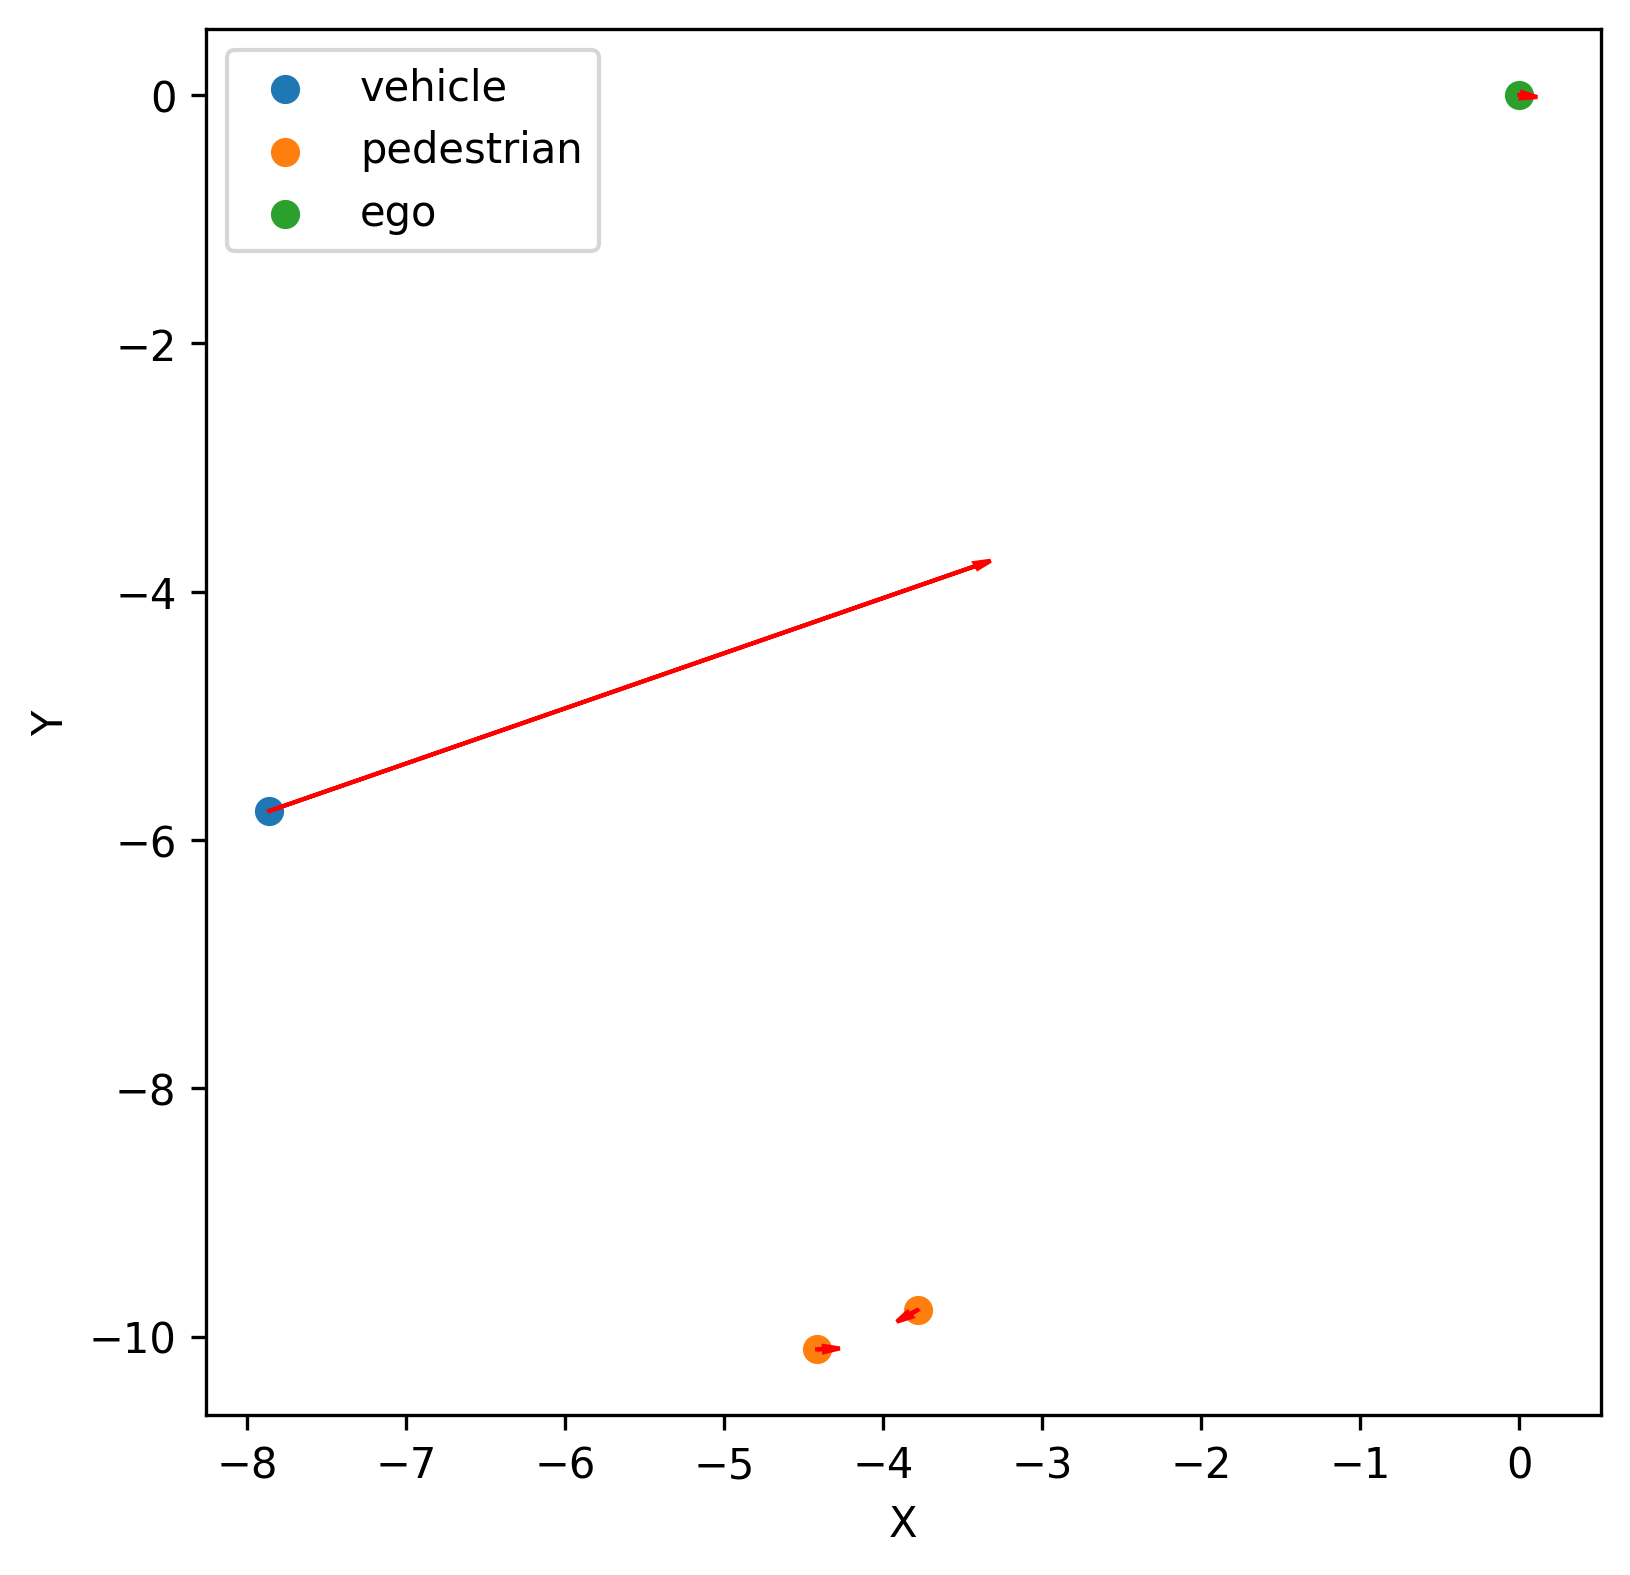

In [71]:
import matplotlib.pyplot as plt

# 假设 all_state 是已经定义的变量
# all_state = ...

# 提取位置和速度
positions = all_state[:, 2][0][:3,:]
velocities = all_state[:, 0][0][:3, 3:5]

# 创建图形
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

# 绘制位置

ax.scatter(all_state[:, 3][0][1,0], all_state[:, 3][0][1,1], label='vehicle')
ax.scatter(positions[1:all_state[0][4], 0], positions[1:all_state[0][4], 1], label='pedestrian')
ax.scatter(positions[0, 0], positions[0, 1], label='ego')
ax.arrow(all_state[:, 3][0][1,0],all_state[:, 3][0][1,1], all_state[:, 1][0][1, 0], all_state[:, 1][0][1, 1], head_width=0.05, head_length=0.1, fc='r', ec='r')

# 绘制速度箭头
for i in range(len(positions)):
    ax.arrow(positions[i, 0], positions[i, 1], velocities[i, 0], velocities[i, 1], head_width=0.05, head_length=0.1, fc='r', ec='r')

# 设置标题和标签
# ax.set_title('Positions and Velocities')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()

# 显示图像
plt.show()

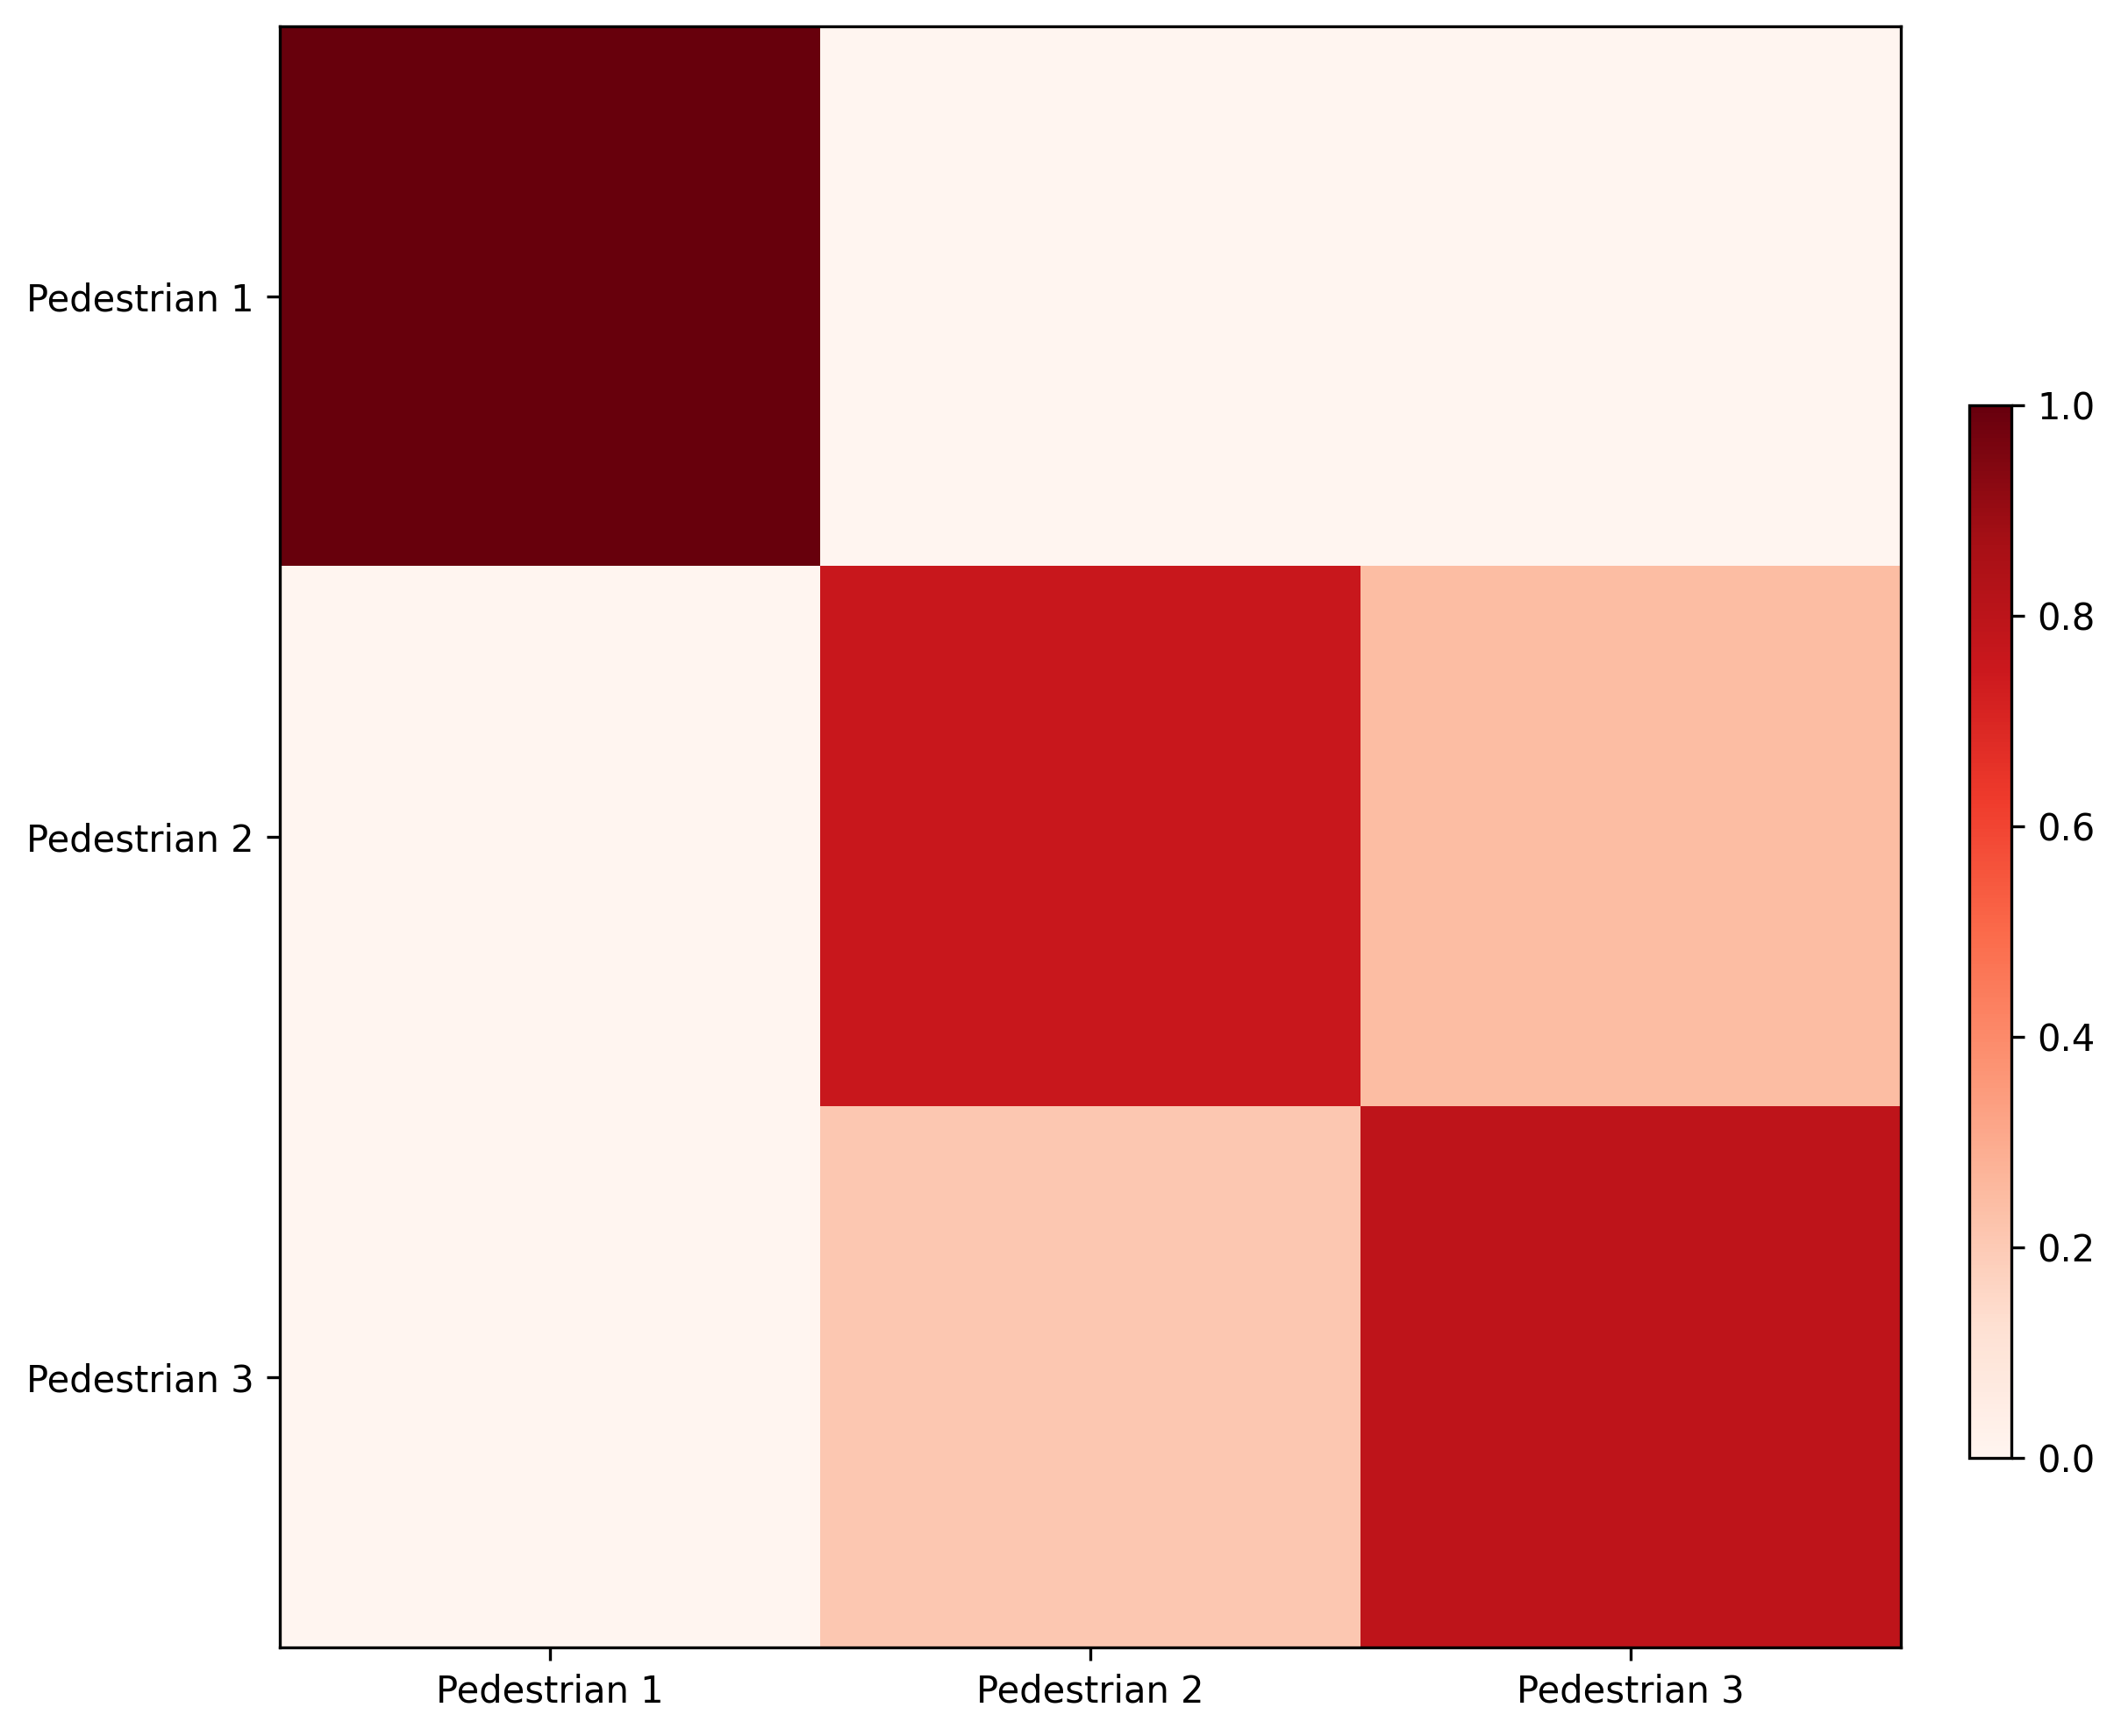

In [72]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
plt.imshow(discriminator.g_p.get_relation_graph(data_pedestrain, type='pedestrian').cpu().detach().numpy()[0][:3,:3], cmap='Reds')
# plt.xlabel('Distance')
# plt.ylabel('Gap_Y')
plt.xticks(np.arange(0,3,1),[f"Pedestrian {i+1}" for i in np.arange(0,3,1)])
plt.yticks(np.arange(0,3,1),[f"Pedestrian {i+1}" for i in np.arange(0,3,1)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')

plt.show()


In [73]:
## 98的时候（平行）、148（交叉）、221相反
env.current_scene = 148
state_flat, all_state = env.reset()
data_pedestrain = (all_state[:, 0], all_state[:, 2],
                           all_state[:, 4])

discriminator.g_p.get_relation_graph(data_pedestrain, type='pedestrian')

tensor([[[1., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0.],
         [0., 0., 1., 0., 0.],
         [0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 1.]]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

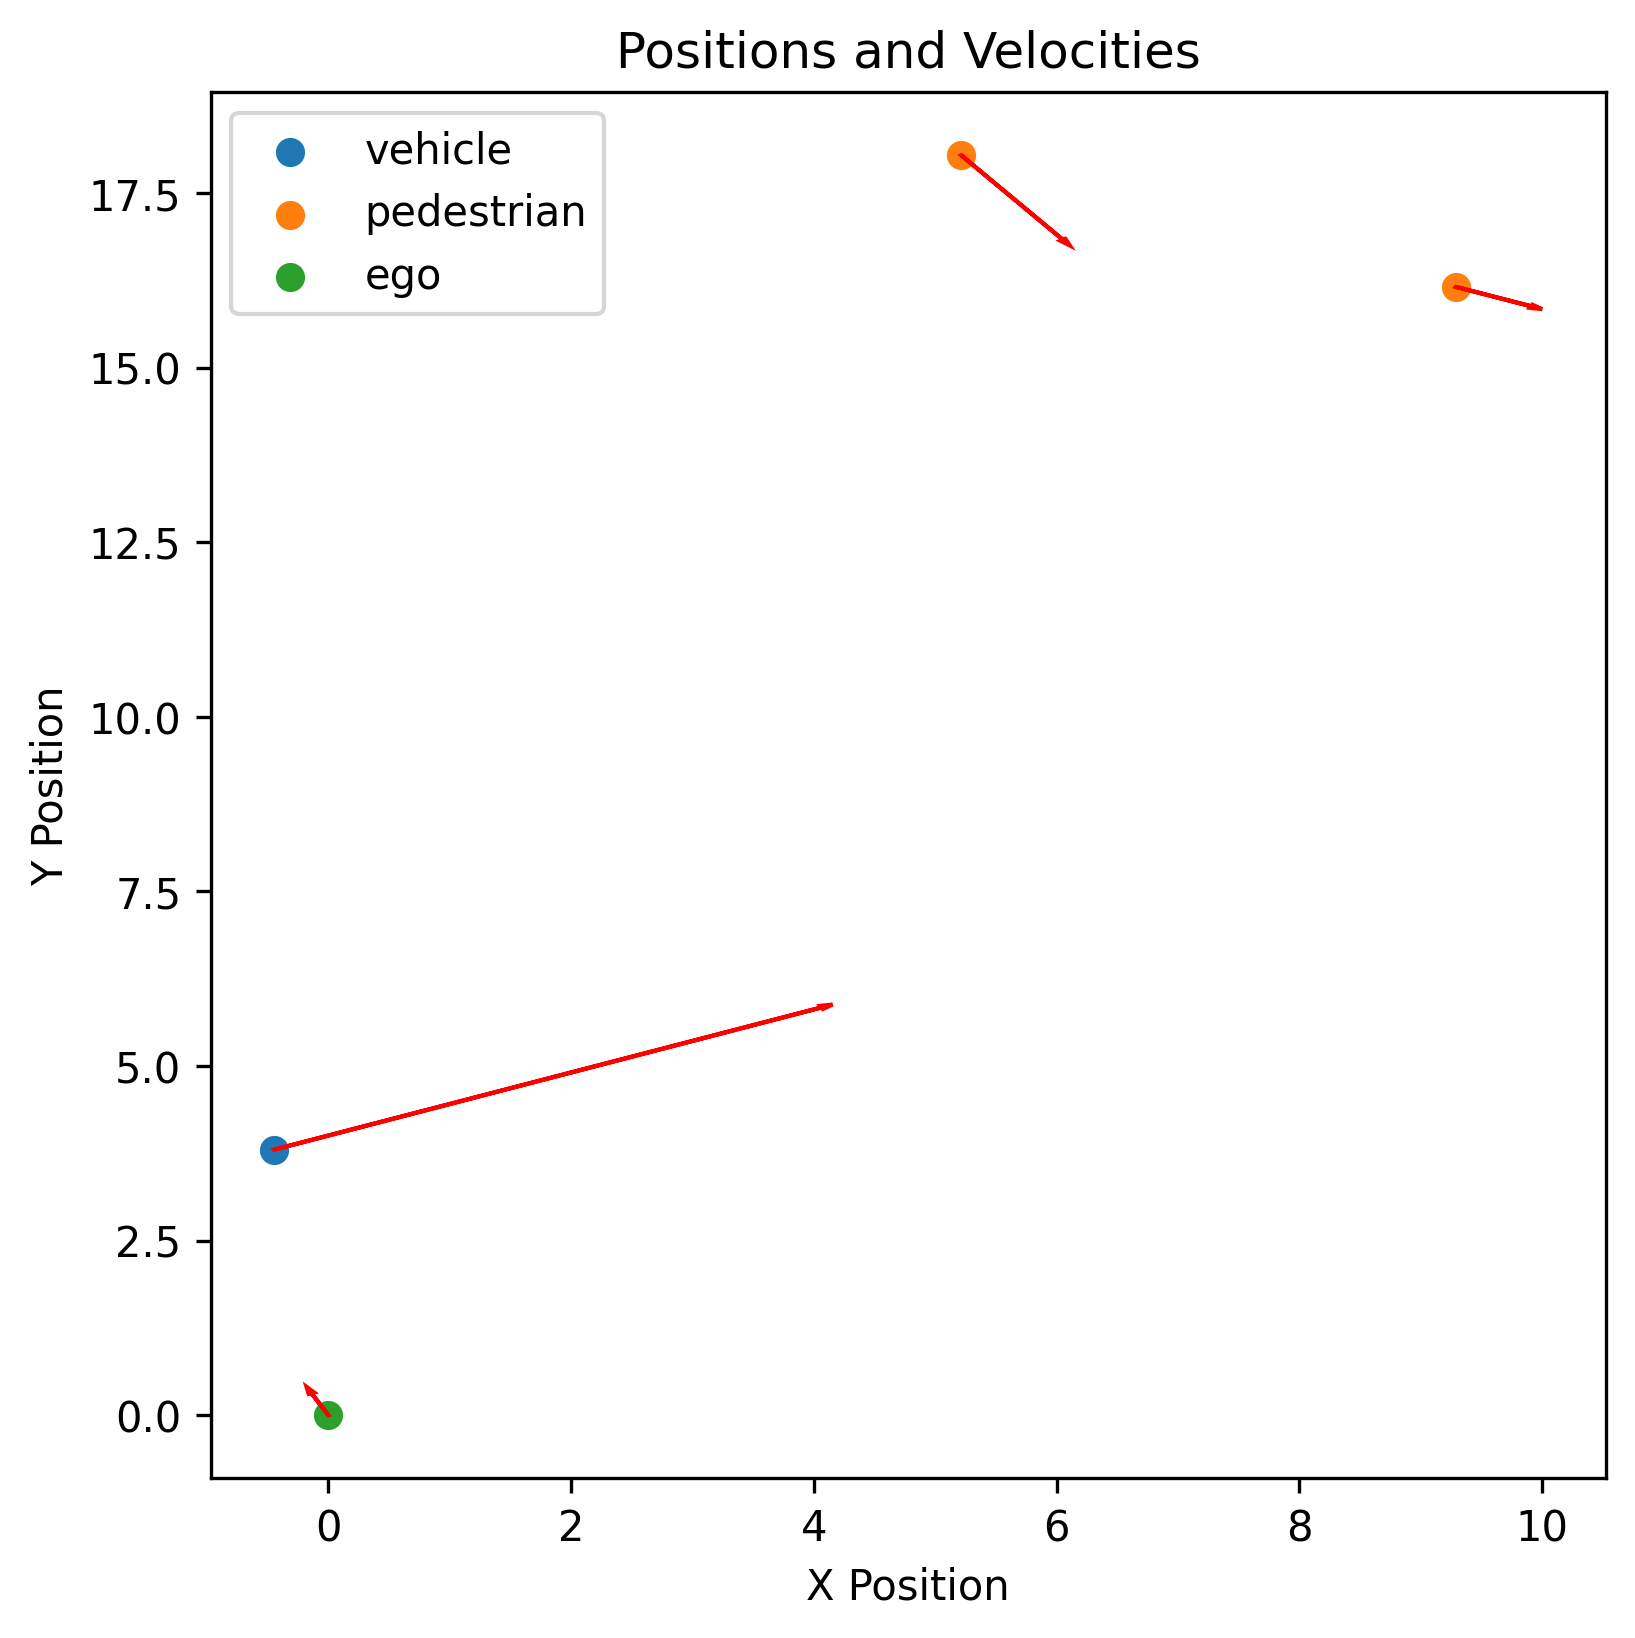

In [74]:
import matplotlib.pyplot as plt

# 假设 all_state 是已经定义的变量
# all_state = ...

# 提取位置和速度
positions = all_state[:, 2][0][:3,:]
velocities = all_state[:, 0][0][:3, 3:5]

# 创建图形
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

# 绘制位置

ax.scatter(all_state[:, 3][0][1,0], all_state[:, 3][0][1,1], label='vehicle')
ax.scatter(positions[1:all_state[0][4], 0], positions[1:all_state[0][4], 1], label='pedestrian')
ax.scatter(positions[0, 0], positions[0, 1], label='ego')
ax.arrow(all_state[:, 3][0][1,0],all_state[:, 3][0][1,1], all_state[:, 1][0][1, 0], all_state[:, 1][0][1, 1], head_width=0.05, head_length=0.1, fc='r', ec='r')

# 绘制速度箭头
for i in range(len(positions)):
    ax.arrow(positions[i, 0], positions[i, 1], velocities[i, 0], velocities[i, 1], head_width=0.05, head_length=0.1, fc='r', ec='r')

# 设置标题和标签
ax.set_title('Positions and Velocities')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.legend()

# 显示图像
plt.show()

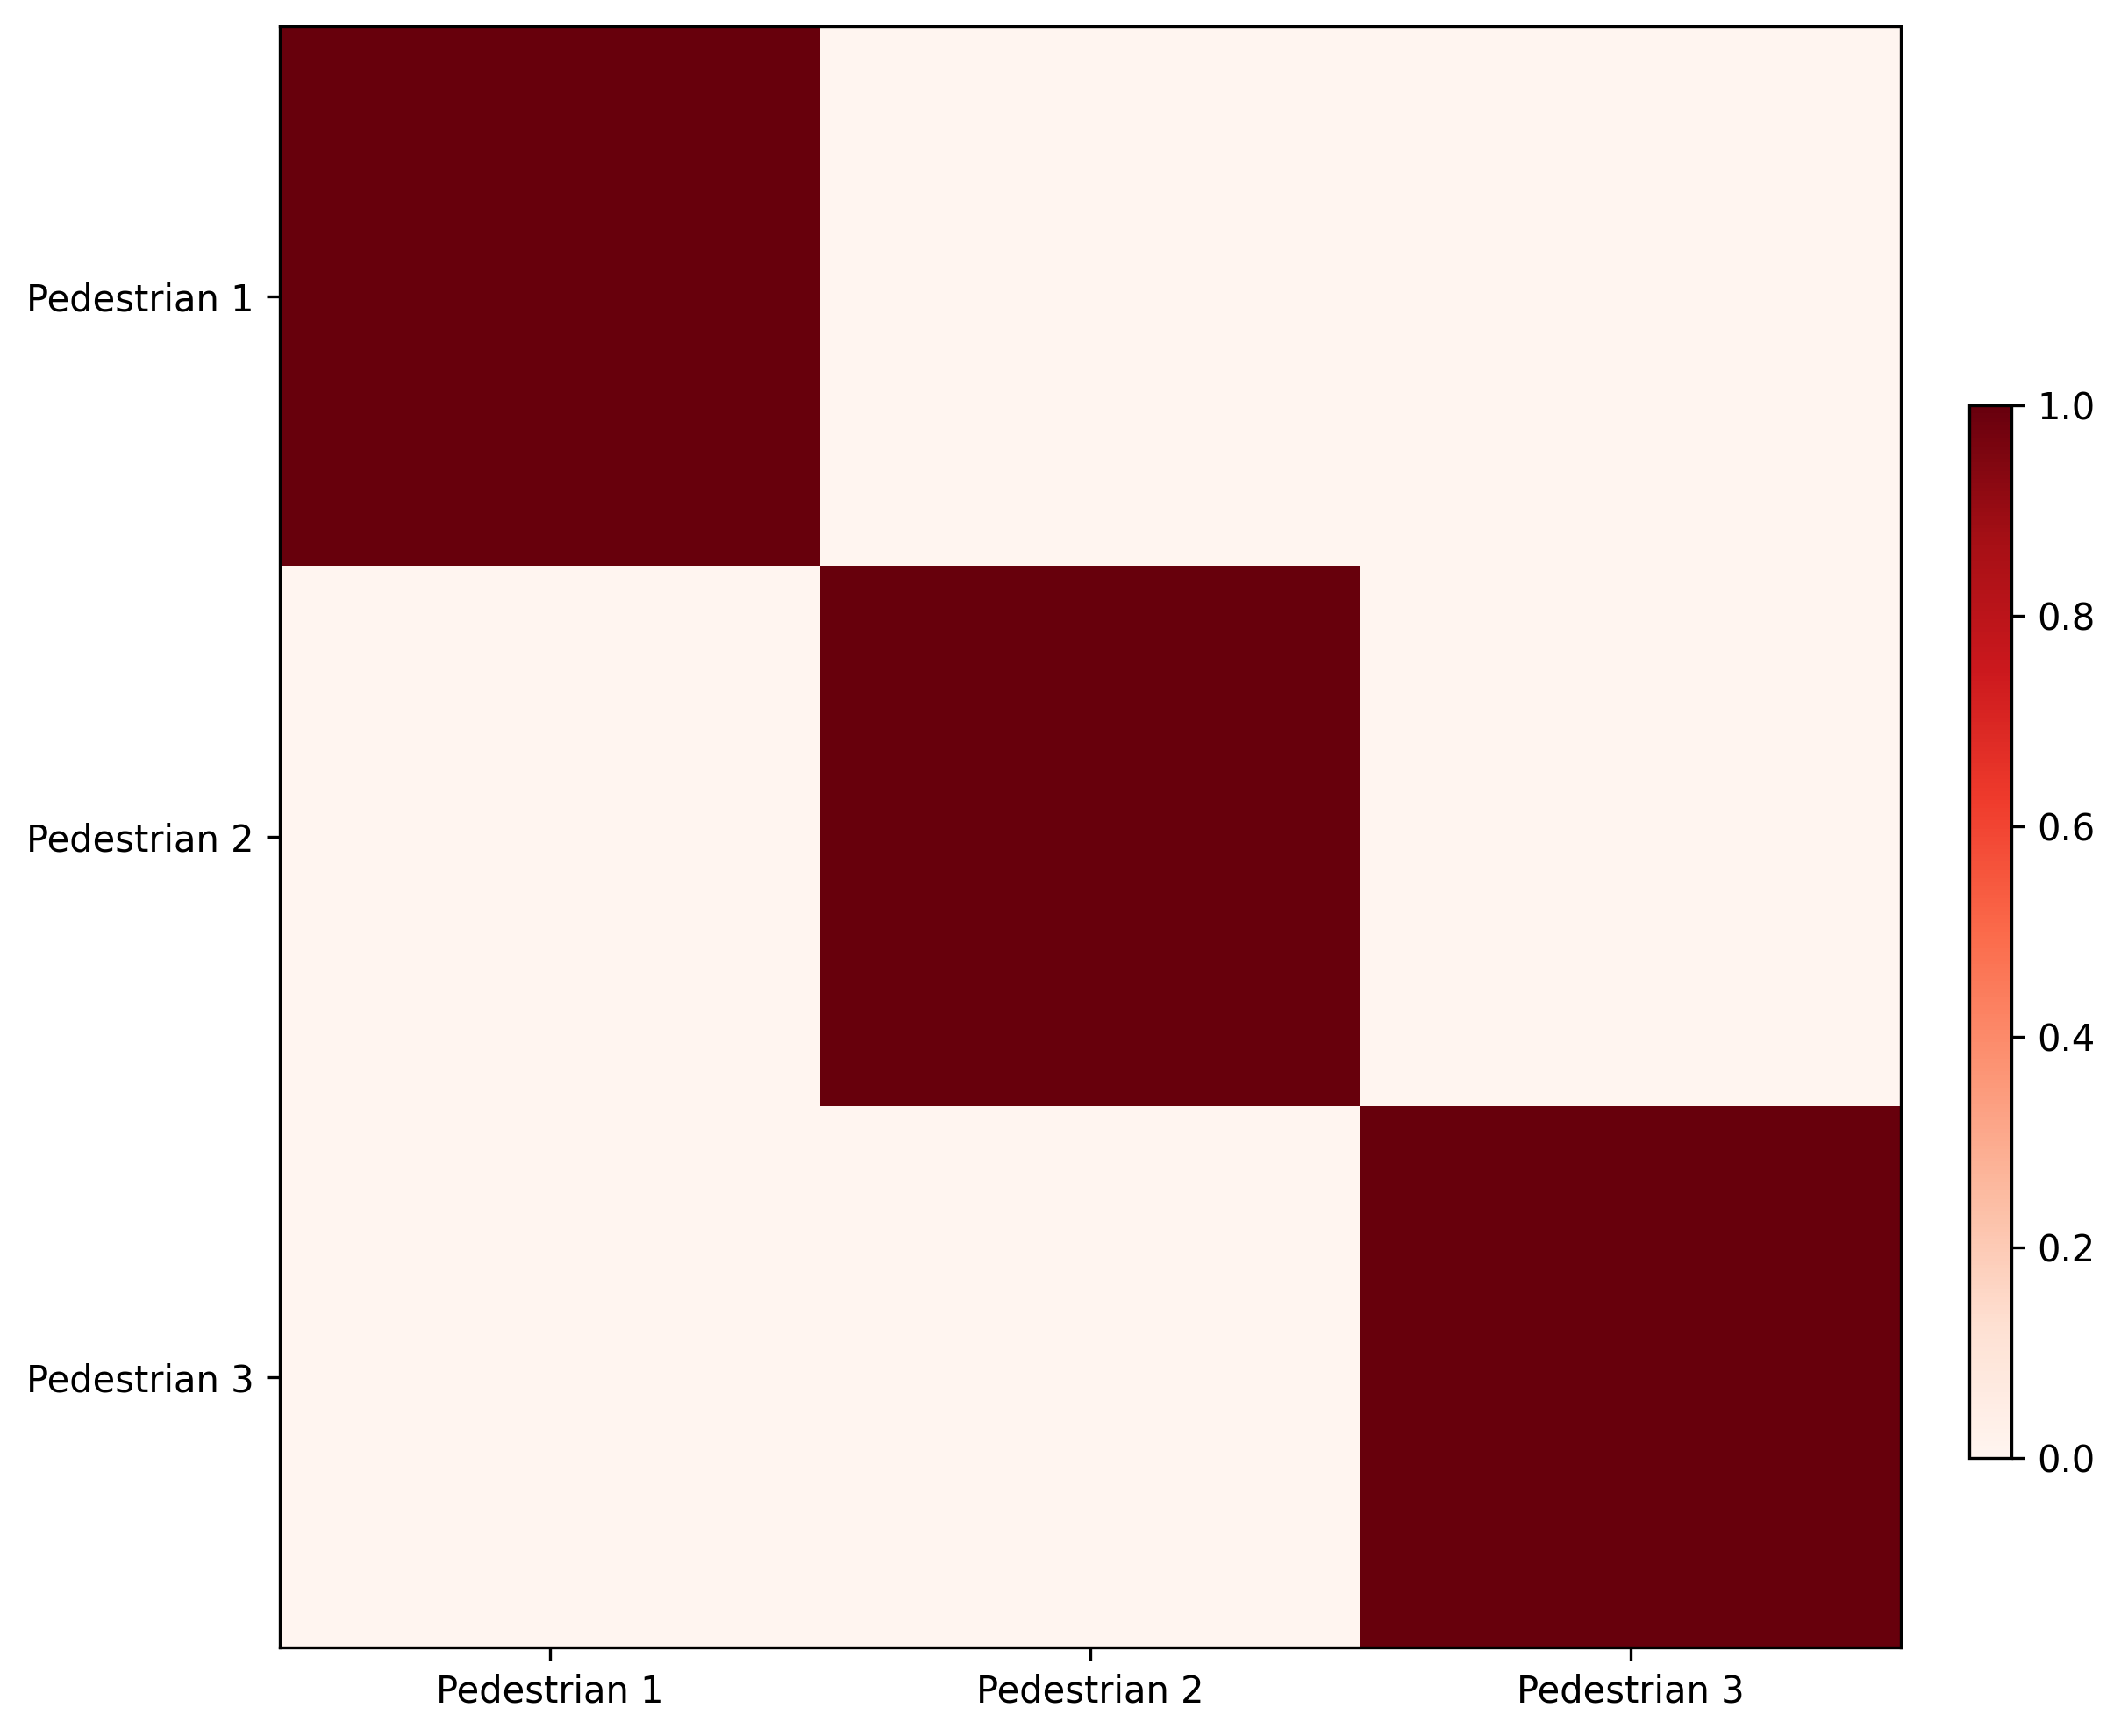

In [75]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
plt.imshow(discriminator.g_p.get_relation_graph(data_pedestrain, type='pedestrian').cpu().detach().numpy()[0][:3,:3], cmap='Reds')
# plt.xlabel('Distance')
# plt.ylabel('Gap_Y')
plt.xticks(np.arange(0,3,1),[f"Pedestrian {i+1}" for i in np.arange(0,3,1)])
plt.yticks(np.arange(0,3,1),[f"Pedestrian {i+1}" for i in np.arange(0,3,1)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')

plt.show()


In [76]:
## 309的时候（平行）、148（交叉）、221相反
env.current_scene = 309
state_flat, all_state = env.reset()
data_pedestrain = (all_state[:, 0], all_state[:, 2],
                           all_state[:, 4])

discriminator.g_p.get_relation_graph(data_pedestrain, type='pedestrian')

tensor([[[0.6857, 0.3143, 0.0000, 0.0000, 0.0000],
         [0.3921, 0.6079, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 1.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 1.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 1.0000]]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)

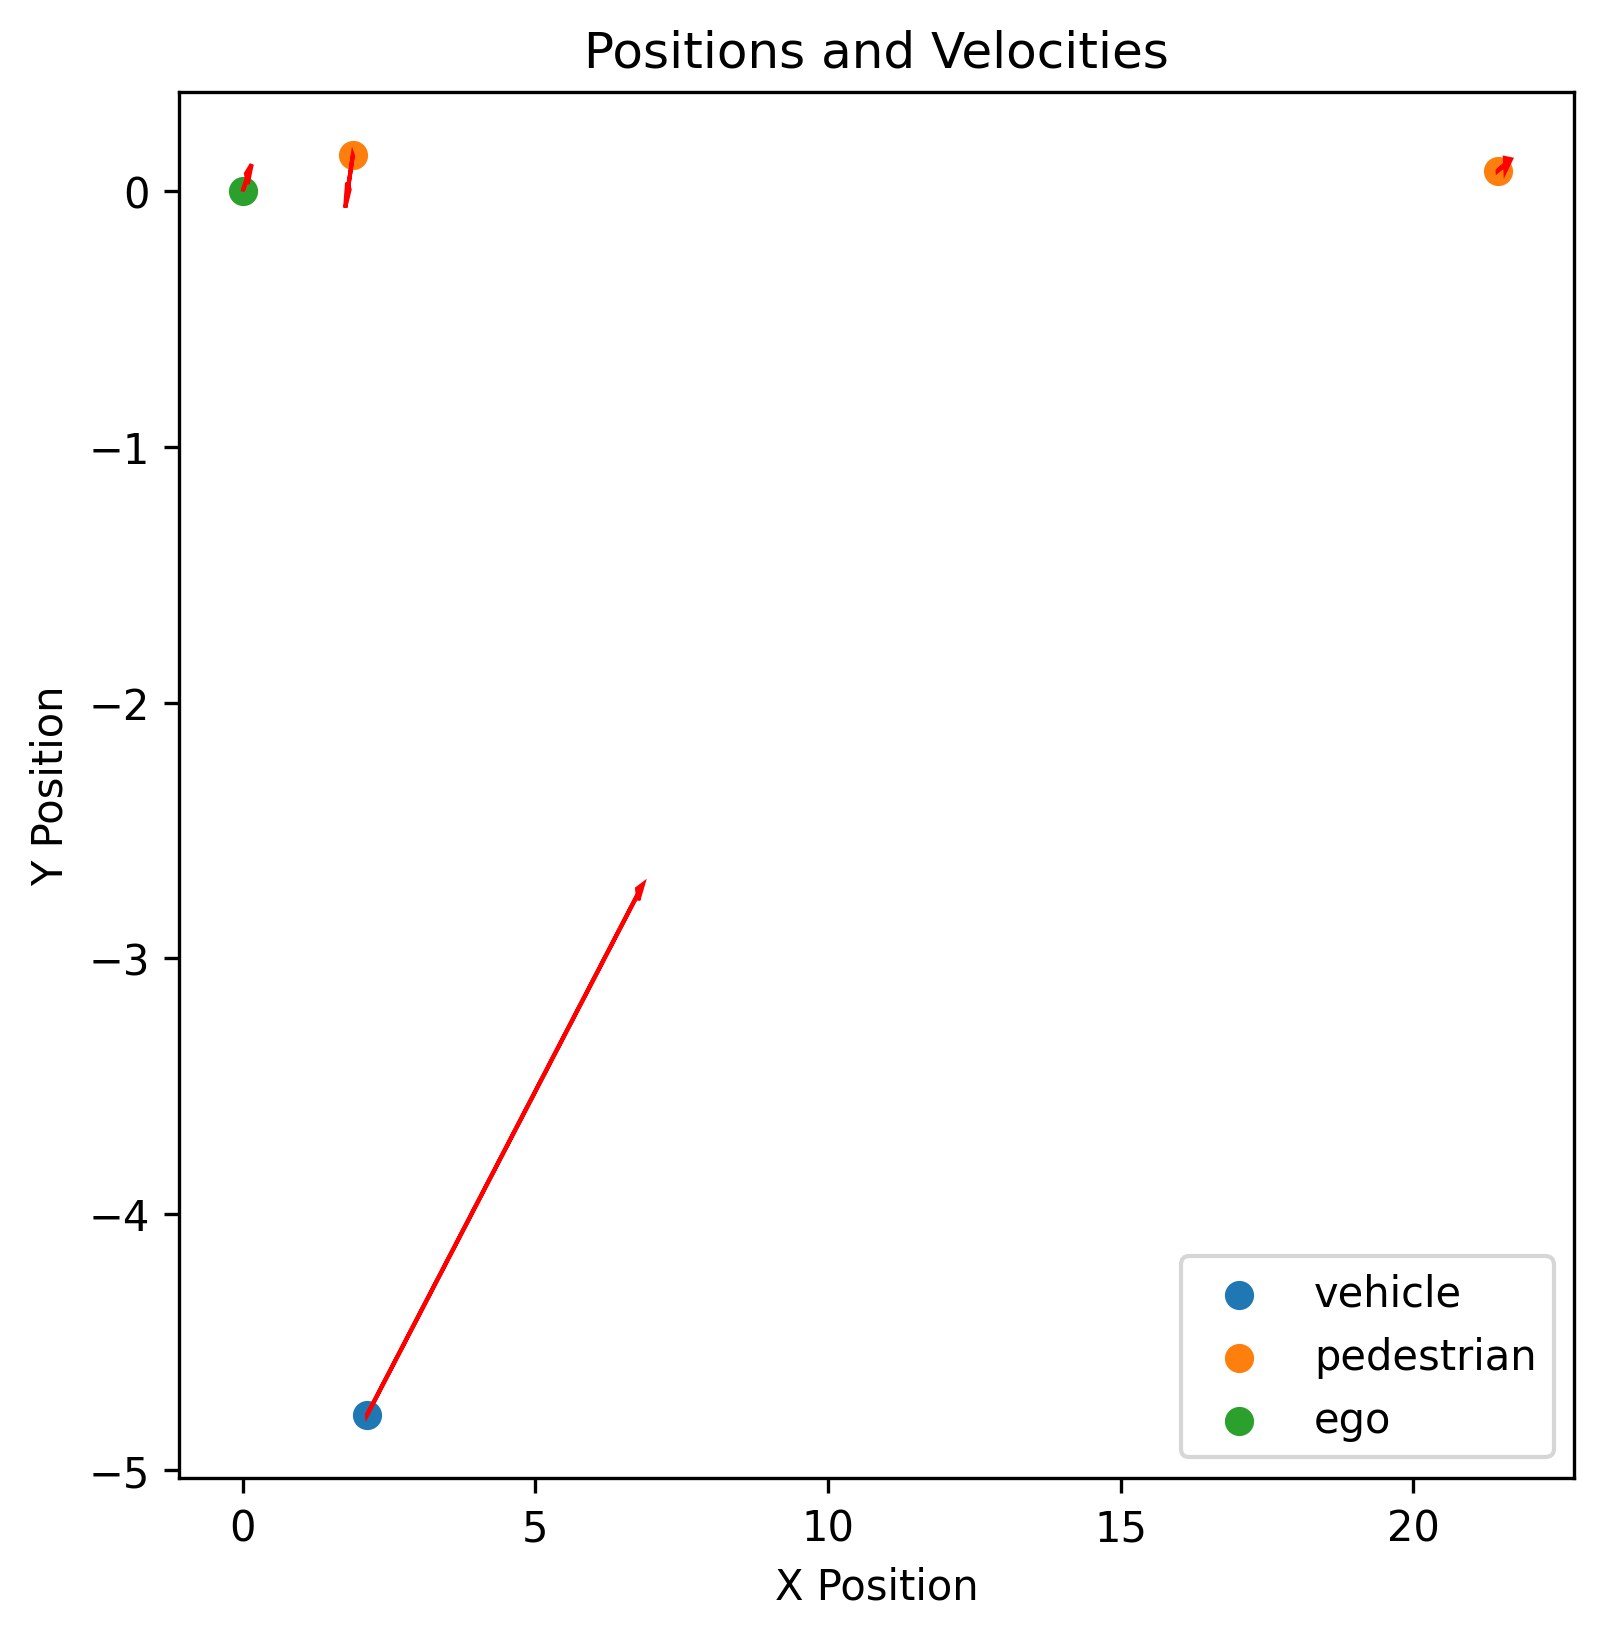

In [77]:
import matplotlib.pyplot as plt

# 假设 all_state 是已经定义的变量
# all_state = ...

# 提取位置和速度
positions = all_state[:, 2][0][:3,:]
velocities = all_state[:, 0][0][:3, 3:5]

# 创建图形
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

# 绘制位置

ax.scatter(all_state[:, 3][0][1,0], all_state[:, 3][0][1,1], label='vehicle')
ax.scatter(positions[1:all_state[0][4], 0], positions[1:all_state[0][4], 1], label='pedestrian')
ax.scatter(positions[0, 0], positions[0, 1], label='ego')
ax.arrow(all_state[:, 3][0][1,0],all_state[:, 3][0][1,1], all_state[:, 1][0][1, 0], all_state[:, 1][0][1, 1], head_width=0.05, head_length=0.1, fc='r', ec='r')

# 绘制速度箭头
for i in range(len(positions)):
    ax.arrow(positions[i, 0], positions[i, 1], velocities[i, 0], velocities[i, 1], head_width=0.05, head_length=0.1, fc='r', ec='r')

# 设置标题和标签
ax.set_title('Positions and Velocities')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.legend()

# 显示图像
plt.show()

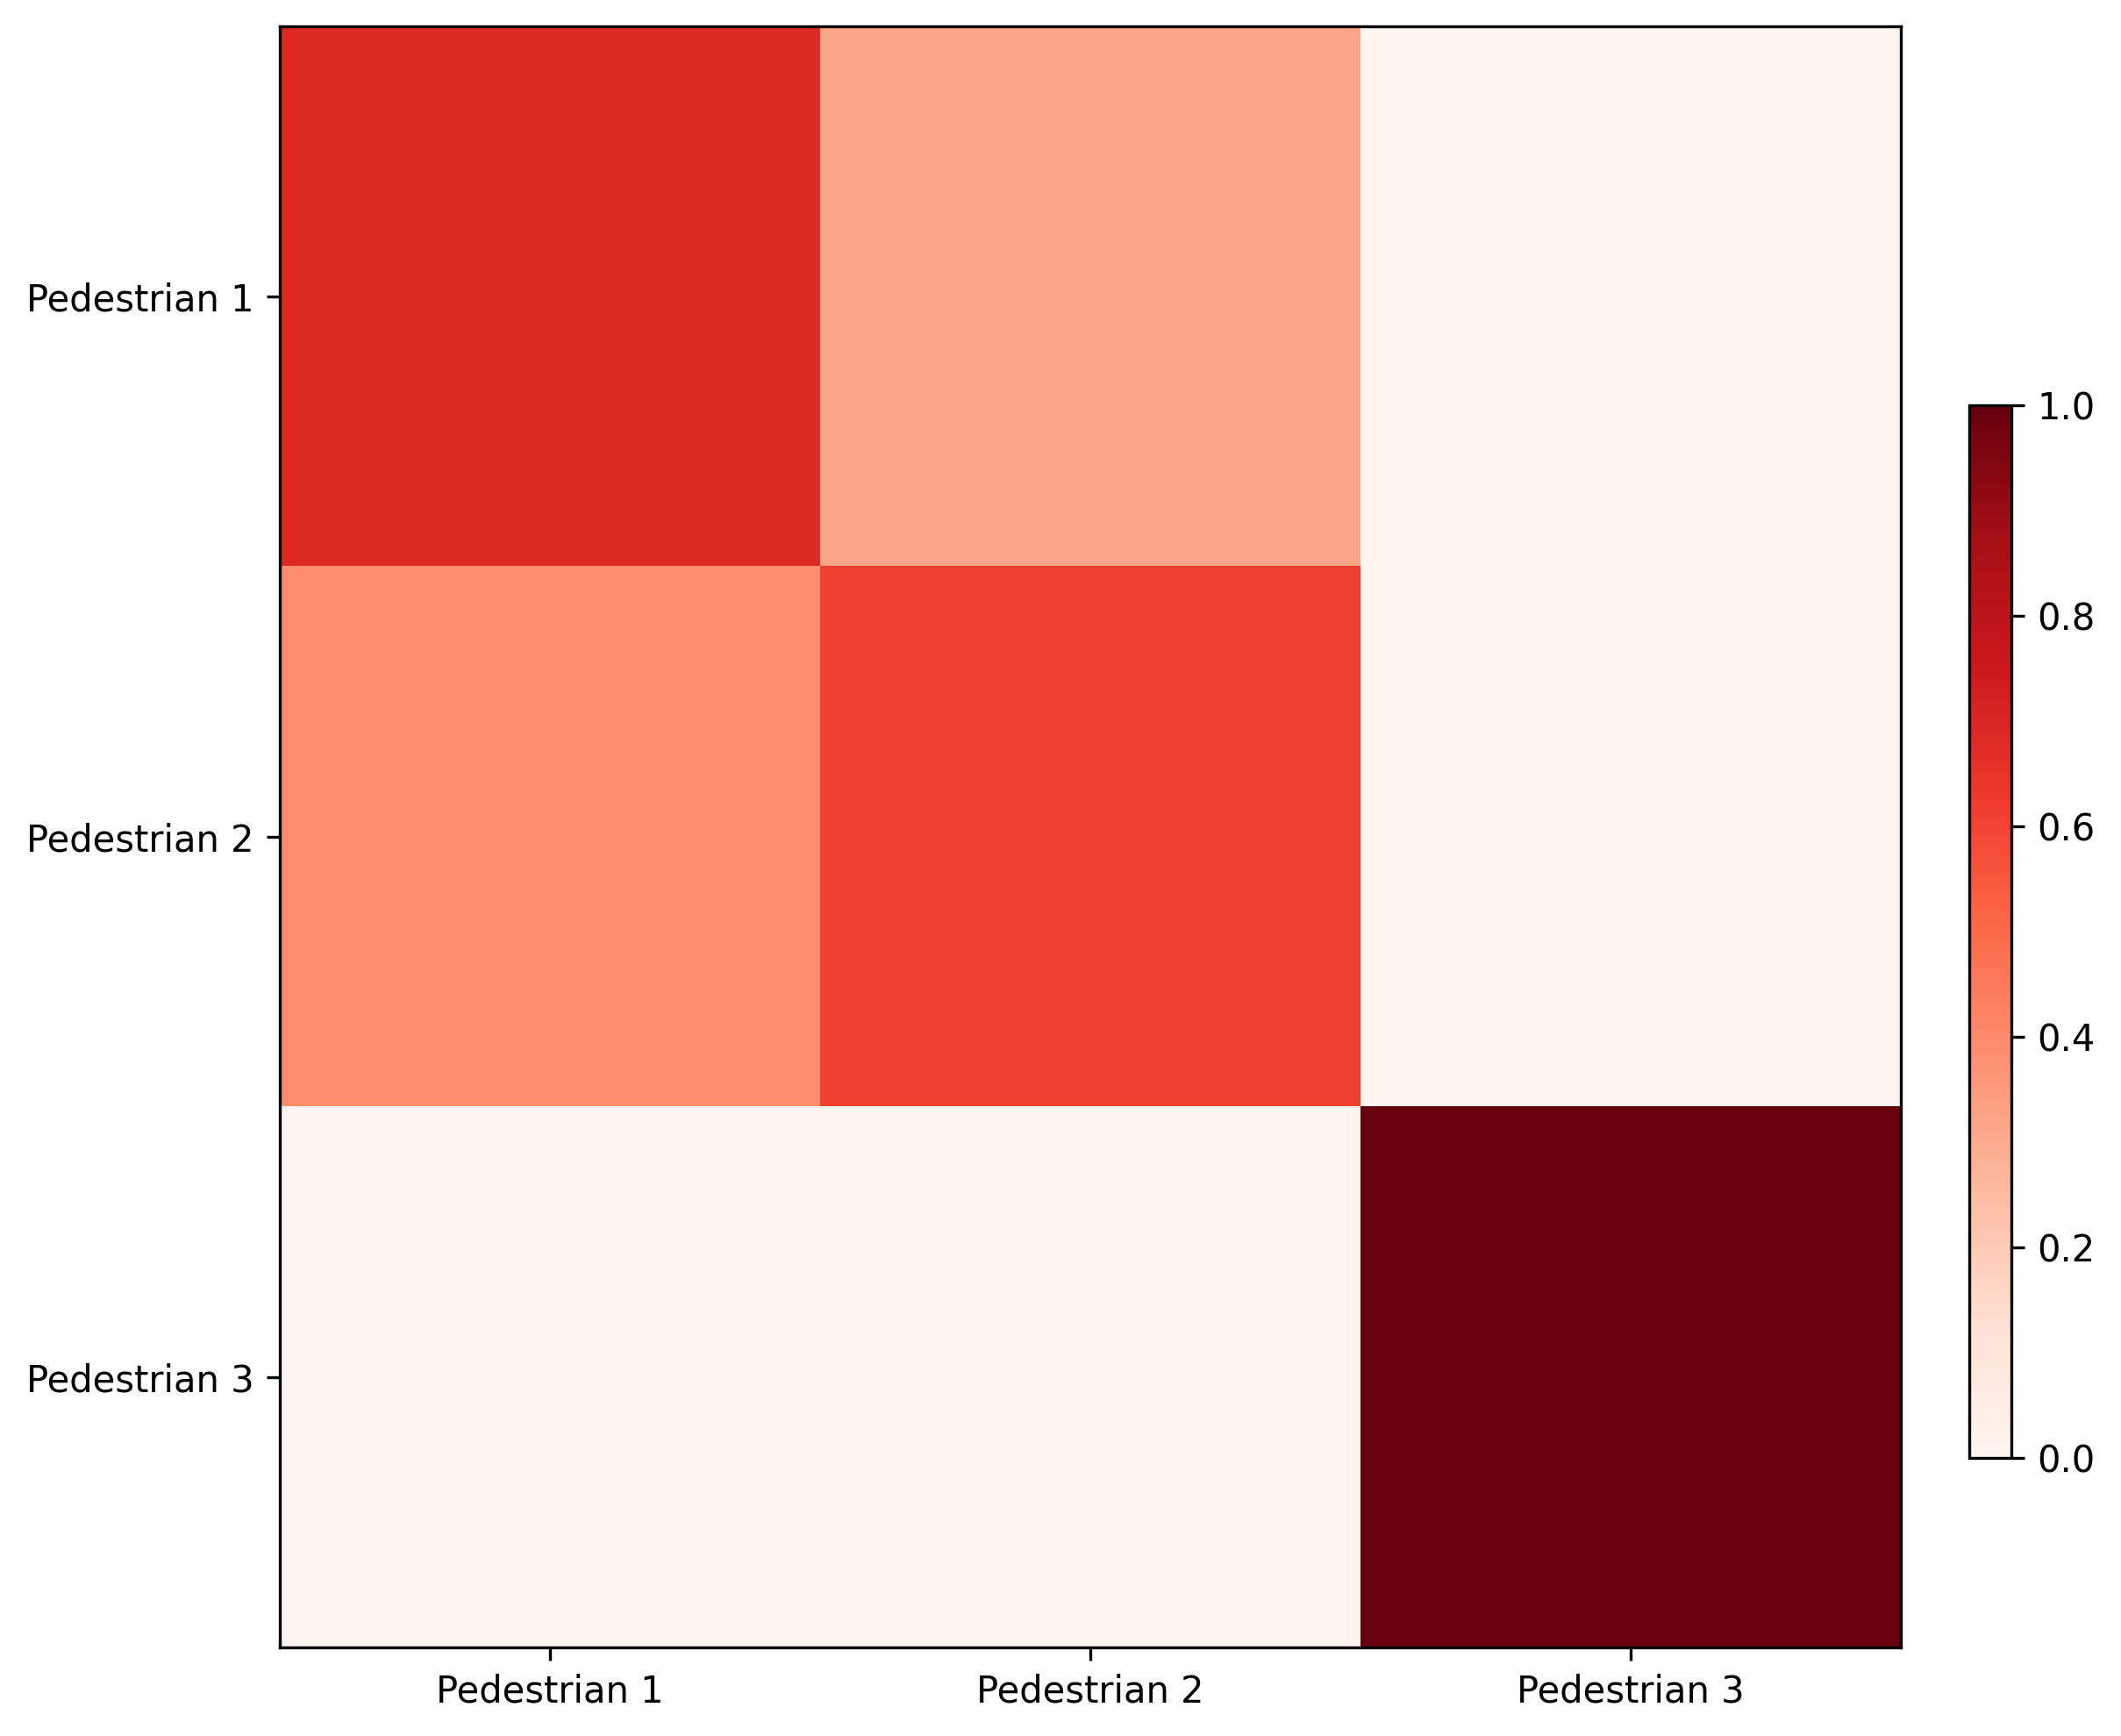

In [78]:
## 人在前面
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(1,(8,8), dpi=300)
ax = fig.add_subplot(111)
plt.imshow(discriminator.g_p.get_relation_graph(data_pedestrain, type='pedestrian').cpu().detach().numpy()[0][:3,:3], cmap='Reds')
# plt.xlabel('Distance')
# plt.ylabel('Gap_Y')
plt.xticks(np.arange(0,3,1),[f"Pedestrian {i+1}" for i in np.arange(0,3,1)])
plt.yticks(np.arange(0,3,1),[f"Pedestrian {i+1}" for i in np.arange(0,3,1)])
cax = plt.axes([0.93, 0.20, 0.02, 0.5])
plt.colorbar(cax = cax)
# plt.title('Heatmap Example')

plt.show()
